# Final Thesis Regression Stack — White-Paper Clean Version

This notebook preserves the regression, robustness, WCB/Wald, and diagnostic logic of the original workflow. The edits here are limited to navigation and presentation: section headlines, figure backgrounds, color palette, gridlines, legends, and exported visual readability.

**Reader guide**

- **A. Setup and panel preparation** — imports, paths, helpers, canonical variables, and final samples.
- **B. Sample diagnostics and descriptive figures** — coverage, correlations, deposit composition, and policy-rate context.
- **C. Main aggregate results** — customer-deposit ASYM specifications, macro controls, expanded controls, and common-sample bridge.
- **D. Deposit-composition mechanism** — Demand/Sight versus Time/Savings models, Wald differential, stress-regime split, and rolling-window figure.
- **E. Robustness and sensitivity checks** — loan-share horse race, continuous exposure, alternative slopes, two-way clustering, residual correlation, leave-one-out, and winsorization.
- **F. Appendix and global diagnostics** — generic slope baseline, bank-FE-only, HHI, post-FE VIF, model-run summary, and global Wald tests.

**Revision note — standalone exposure controls added**

All regression designs that include a `HighCustDep` interaction now include the standalone `HighCustDep` level control. Mechanism specifications using `High Demand/Sight` and `High Time/Savings` interactions now include the corresponding standalone composition dummies. Outputs have been cleared so rerunning the notebook produces internally consistent tables after these specification changes.



> **Data availability:** The underlying bank-level dataset is not included because it contains licensed Refinitiv Datastream/Worldscope and BvD OSIRIS data. The notebook retains selected outputs for transparency. Authorised users can place `final_panel.csv` in `data/processed/`.


## A.1 Settings, imports, and white-paper theme

Edit this cell to change paths, the sample window, clustering defaults, bootstrap settings, optional appendix blocks, and the global figure design.


In [1]:

# ============================================================
# A.1 SETTINGS, IMPORTS, AND WHITE-PAPER THEME
# ============================================================

from pathlib import Path
from dataclasses import dataclass, field
import math
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# White-paper figure theme
# ------------------------------------------------------------------

WP_FIG_BG = "#FFFFFF"
WP_AX_BG = "#FFFFFF"
WP_TEXT = "#1F2933"
WP_MUTED = "#5B6770"
WP_GRID = "#D5DAE0"
WP_BORDER = "#C8CDD2"
WP_EDGE = "#E9EDF2"
WP_NAVY = "#0B2D5B"
WP_BLUE = "#2F6B9A"
WP_TEAL = "#168C8C"
WP_GREEN = "#4D7C59"
WP_PURPLE = "#6C5B7B"
WP_SLATE = "#4B5563"
WP_RED = "#A94442"
WP_SHADE_BLUE = "#8BAAC2"
WP_SHADE_TEAL = "#8CC7C7"
WP_SHADE_PURPLE = "#B5A6C2"
WP_PALETTE = [WP_NAVY, WP_BLUE, WP_TEAL, WP_GREEN, WP_PURPLE, WP_SLATE]

plt.rcParams.update({
    "figure.facecolor": WP_FIG_BG,
    "axes.facecolor": WP_AX_BG,
    "axes.edgecolor": WP_BORDER,
    "axes.labelcolor": WP_TEXT,
    "axes.titlecolor": WP_TEXT,
    "text.color": WP_TEXT,
    "xtick.color": WP_MUTED,
    "ytick.color": WP_MUTED,
    "grid.color": WP_GRID,
    "grid.alpha": 0.45,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "savefig.facecolor": WP_FIG_BG,
    "savefig.edgecolor": WP_FIG_BG,
    "savefig.dpi": 240,
})
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=WP_PALETTE)


def style_whitepaper_axes(ax, grid_axis="both"):
    """Apply the shared white-paper axis style without changing plotted data."""
    ax.set_facecolor(WP_AX_BG)
    ax.tick_params(axis="both", colors=WP_MUTED)
    ax.grid(True, axis=grid_axis, color=WP_GRID, alpha=0.45, linewidth=0.8)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(WP_BORDER)
        ax.spines[spine].set_linewidth(0.8)
    return ax


pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 240)

try:
    from IPython.display import display
except Exception:
    display = None

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    stats = None
    SCIPY_AVAILABLE = False

try:
    from linearmodels.panel import PanelOLS
    LINEARMODELS_AVAILABLE = True
except Exception:
    PanelOLS = None
    LINEARMODELS_AVAILABLE = False

# ------------------------------------------------------------------
# User-editable paths and sample settings
# ------------------------------------------------------------------

PANEL_PATH = None   # Set to Path("...") if auto-detection should be bypassed.

SAMPLE_START = pd.Timestamp("2011-04-30")
SAMPLE_END = pd.Timestamp("2024-12-31")
DEPENDENT_VAR = "r_excess"

OUTPUT_FOLDER_SUFFIX = "refactored"

# ------------------------------------------------------------------
# Estimation defaults
# ------------------------------------------------------------------

# "auto" uses linearmodels.PanelOLS if installed, otherwise the built-in within estimator.
# "linearmodels" requires linearmodels. "within_numpy" always uses the built-in estimator.
ESTIMATOR_ENGINE = "auto"

# Main tables use bank-clustered SE by default. Table R4 explicitly reruns key models with two-way SE.
BASE_CLUSTER_ENTITY = True
BASE_CLUSTER_TIME = False

# Optional one-way bank wild-cluster bootstrap p-values for focal coefficients.
# Leave False while drafting; set True for final inference reruns.
RUN_KEY_WCB = True
RUN_WALD_WCB = True
WCB_REPS = 999
WCB_SEED = 42

# Main sample policy.
# df_quality is the canonical thesis sample.
RUN_BROAD_UNIVERSE_COMPARISON = True

# WCB for CISS-split regressions.
RUN_CISS_WCB = True

# Optional heavier blocks.
RUN_CISS_REGIME = True
RUN_ROLLING_WINDOWS = True
RUN_TWO_WAY_SE_ROBUSTNESS = True
RUN_STABILITY_CHECKS = True
RUN_BANK_FE_ONLY_APPENDIX = True
RUN_HHI_APPENDIX = True

# Rolling-window settings.
ROLLING_WINDOW_MONTHS = 60
ROLLING_STEP_MONTHS = 3
ROLLING_MIN_BANKS = 8
ROLLING_MIN_OBS = 300
ROLLING_INCLUDE_FLATTENING = True
SHOW_ROLLING_UNDERLYING_COEFFICIENTS = True

print(f"linearmodels available : {LINEARMODELS_AVAILABLE}")
print(f"scipy available        : {SCIPY_AVAILABLE}")
print(f"estimator engine       : {ESTIMATOR_ENGINE}")
print(f"main sample            : {SAMPLE_START:%Y-%m} to {SAMPLE_END:%Y-%m}")
print(f"main SE default        : entity={BASE_CLUSTER_ENTITY}, time={BASE_CLUSTER_TIME}")
print(f"inline WCB p-values    : {RUN_KEY_WCB}")


linearmodels available : True
scipy available        : True
estimator engine       : auto
main sample            : 2011-04 to 2024-12
main SE default        : entity=True, time=False
inline WCB p-values    : True


## A.2 Load final panel

The notebook auto-detects `final_panel.csv` in common output locations. Set `PANEL_PATH` above when running from a custom directory.


In [ ]:

# ============================================================
# A.2 LOAD FINAL PANEL
# ============================================================

def show_df(obj):
    if display is not None:
        display(obj)
    else:
        if hasattr(obj, "to_string"):
            print(obj.to_string(index=False))
        else:
            print(obj)


def resolve_panel_path(user_path=None):
    candidates = []
    if user_path is not None:
        candidates.append(Path(user_path))

    cwd = Path.cwd()
    candidates.extend([
        cwd / "data" / "processed" / "final_panel.csv",
        cwd / "final panel" / "final_panel.csv",
        cwd / "final_panel.csv",
        cwd / "final_panel_refactored.csv",
        cwd.parent / "data" / "processed" / "final_panel.csv",
        cwd.parent / "final panel" / "final_panel.csv",
        cwd.parent / "final_panel.csv",
    ])

    for p in candidates:
        if p is not None and Path(p).exists():
            return Path(p)

    tried = "\n".join(str(p) for p in candidates)
    raise FileNotFoundError(
        "Could not find final_panel.csv. Set PANEL_PATH in the settings cell.\n\nTried:\n" + tried
    )


panel_path = resolve_panel_path(PANEL_PATH)
df_all = pd.read_csv(panel_path, low_memory=False)

OUT_DIR = panel_path.parent / f"steepening_regression_outputs_{SAMPLE_START:%Y%m}_{SAMPLE_END:%Y%m}_{OUTPUT_FOLDER_SUFFIX}"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = OUT_DIR

columns_available = pd.DataFrame({"column": df_all.columns})
columns_available.to_csv(OUT_DIR / "00_columns_available.csv", index=False)

print(f"Loaded panel from : {panel_path}")
print(f"Panel shape       : {df_all.shape[0]:,} rows x {df_all.shape[1]:,} columns")
print(f"Output directory  : {OUT_DIR.resolve()}")
print(f"Saved column list : {OUT_DIR / '00_columns_available.csv'}")


## A.3 General helpers

Reusable utilities for variable detection, transformations, sample construction, output saving, and figure export.


In [3]:

# ============================================================
# A.3 GENERAL HELPERS
# ============================================================

def warn_msg(message):
    print(f"WARNING: {message}")


def find_first(data, candidates):
    """Return the first existing column in candidates, case-insensitively."""
    lower_map = {str(c).lower(): c for c in data.columns}
    for cand in candidates:
        if cand is None:
            continue
        if cand in data.columns:
            return cand
        key = str(cand).lower()
        if key in lower_map:
            return lower_map[key]
    return None


def add_alias_if_missing(data, new_col, candidates, overwrite=False):
    if new_col in data.columns and not overwrite:
        return new_col
    src = find_first(data, candidates)
    if src is not None:
        data[new_col] = data[src]
        if src != new_col:
            print(f"Created alias: {new_col} from {src}")
        return new_col
    warn_msg(f"Could not create alias {new_col}; no source found among {candidates}")
    return None


def as_numeric(series):
    return pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)


def zscore(series):
    x = as_numeric(series)
    sd = x.std(skipna=True)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.nan, index=series.index, dtype="float64")
    return (x - x.mean(skipna=True)) / sd


def ensure_zstd(data, out_col, base_col, overwrite=False):
    if out_col in data.columns and not overwrite:
        return out_col
    if base_col is None or base_col not in data.columns:
        warn_msg(f"Cannot construct {out_col}; missing {base_col}")
        return None
    data[out_col] = zscore(data[base_col])
    return out_col


def ensure_interaction(data, out_col, left_col, right_col, overwrite=False, quiet=False):
    if out_col in data.columns and not overwrite:
        return out_col
    missing = [c for c in [left_col, right_col] if c is None or c not in data.columns]
    if missing:
        if not quiet:
            warn_msg(f"Cannot construct {out_col}; missing {missing}")
        return None
    data[out_col] = as_numeric(data[left_col]) * as_numeric(data[right_col])
    return out_col


def bank_pooled_high_dummy(data, base_col, bank_col):
    x = as_numeric(data[base_col])
    bank_avg = (
        pd.DataFrame({bank_col: data[bank_col].values, "_value": x.values})
        .groupby(bank_col, as_index=False)["_value"]
        .mean()
    )
    med = bank_avg["_value"].median(skipna=True)
    bank_avg["_high"] = np.where(
        bank_avg["_value"].notna() & pd.notna(med),
        (bank_avg["_value"] >= med).astype(float),
        np.nan,
    )
    out = data[[bank_col]].merge(bank_avg[[bank_col, "_high"]], on=bank_col, how="left", sort=False)["_high"]
    return pd.Series(out.to_numpy(), index=data.index, dtype="float64")


def ensure_bank_high_dummy(data, out_col, base_col, bank_col, overwrite=False):
    if out_col in data.columns and not overwrite:
        return out_col
    if base_col is None or base_col not in data.columns:
        warn_msg(f"Cannot construct {out_col}; missing {base_col}")
        return None
    data[out_col] = bank_pooled_high_dummy(data, base_col, bank_col)
    return out_col


def stars(p):
    if p is None or pd.isna(p):
        return ""
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""


def fmt_num(x, digits=4):
    if x is None or pd.isna(x):
        return ""
    return f"{x:,.{digits}f}"


def fmt_int(x):
    if x is None or pd.isna(x):
        return ""
    return f"{int(x):,}"


def fmt_p(x):
    if x is None or pd.isna(x):
        return ""
    return "<0.001" if x < 0.001 else f"{x:.4f}"


def fmt_date(x):
    if x is None or pd.isna(x):
        return ""
    return pd.Timestamp(x).strftime("%Y-%m")


def save_table(table, filename, display_table=True):
    path = OUT_DIR / filename
    table.to_csv(path, index=False)
    print(f"Saved: {path.resolve()}")
    if display_table:
        show_df(table)
    return path


def save_figure(fig, filename, dpi=240):
    path = OUT_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"Saved figure: {path.resolve()}")
    return path


def normal_pvalue(t_value):
    if pd.isna(t_value) or not np.isfinite(t_value):
        return np.nan
    if SCIPY_AVAILABLE:
        return float(2 * stats.norm.sf(abs(t_value)))
    return float(math.erfc(abs(t_value) / math.sqrt(2)))


def existing(cols, data=None):
    data = df_reg_full if data is None and "df_reg_full" in globals() else data
    return [c for c in cols if c is not None and data is not None and c in data.columns]


def complete_case_mask(data, cols):
    cols = [c for c in cols if c is not None]
    missing = [c for c in cols if c not in data.columns]
    if missing:
        raise KeyError(f"Missing complete-case columns: {missing}")

    work = data[cols].copy()
    id_cols = {globals().get("BANK_COL"), globals().get("MONTH_COL"), globals().get("DATE_COL")}
    if globals().get("COUNTRY_COL") is not None:
        id_cols.add(globals().get("COUNTRY_COL"))

    for c in cols:
        if c not in id_cols:
            work[c] = as_numeric(work[c])
    return work.replace([np.inf, -np.inf], np.nan).notna().all(axis=1)


def subset_complete_case(data, cols, label=None, allow_missing=False):
    cols = [c for c in cols if c is not None]
    missing = [c for c in cols if c not in data.columns]
    if missing:
        msg = f"{label or 'sample'} missing variables: {missing}"
        if allow_missing:
            warn_msg(msg)
            return data.iloc[0:0].copy()
        raise KeyError(msg)
    return data.loc[complete_case_mask(data, cols)].copy().reset_index(drop=True)


SAMPLE_REGISTRY = []


def sample_summary(label, data, required_vars=None, status="OK"):
    required_vars = [v for v in (required_vars or []) if v is not None]
    if data is None or data.empty:
        return {
            "sample": label,
            "status": status if status != "OK" else "empty",
            "observations": 0,
            "banks": 0,
            "months": 0,
            "start": "",
            "end": "",
            "required_vars": ", ".join(required_vars),
        }
    return {
        "sample": label,
        "status": status,
        "observations": int(len(data)),
        "banks": int(data[BANK_COL].nunique(dropna=True)),
        "months": int(data[MONTH_COL].nunique(dropna=True)),
        "start": fmt_date(data[MONTH_COL].min()),
        "end": fmt_date(data[MONTH_COL].max()),
        "required_vars": ", ".join(required_vars),
    }


def make_complete_sample(data, required_vars, label, allow_missing=True):
    required_vars = [v for v in required_vars if v is not None]
    missing = [v for v in required_vars if v not in data.columns]
    if missing:
        warn_msg(f"{label}: missing {missing}; returning empty sample.")
        out = data.iloc[0:0].copy()
        SAMPLE_REGISTRY.append(sample_summary(label, out, required_vars, status=f"missing {missing}"))
        return out
    out = subset_complete_case(data, [BANK_COL, MONTH_COL, DATE_COL, *required_vars], label=label, allow_missing=allow_missing)
    SAMPLE_REGISTRY.append(sample_summary(label, out, required_vars))
    return out


## A.4 Estimation helpers

All main models use bank and month fixed effects. The default standard-error choice is controlled in Settings; Table R4 explicitly reruns key models with two-way clustered SE.


In [4]:

# ============================================================
# A.4 ESTIMATION HELPERS
# ============================================================

def se_label(cluster_entity=True, cluster_time=False):
    if cluster_entity and cluster_time:
        return "Two-way clustered by bank and month"
    if cluster_entity:
        return "One-way clustered by bank"
    if cluster_time:
        return "One-way clustered by month"
    return "Heteroskedasticity-robust"


def _fe_label(entity_effects=True, time_effects=True):
    parts = []
    if entity_effects:
        parts.append("Bank")
    if time_effects:
        parts.append("month")
    return " + ".join(parts) if parts else "None"


def _empty_result(model_name, dep_var, regressors, reason, entity_effects=True, time_effects=True, cluster_entity=BASE_CLUSTER_ENTITY, cluster_time=BASE_CLUSTER_TIME):
    return {
        "ok": False,
        "model_name": model_name,
        "dep_var": dep_var,
        "regressors": list(regressors),
        "error": reason,
        "params": pd.Series(dtype=float),
        "std_errors": pd.Series(dtype=float),
        "tstats": pd.Series(dtype=float),
        "pvalues": pd.Series(dtype=float),
        "cov": pd.DataFrame(),
        "r2_within": np.nan,
        "nobs": np.nan,
        "n_banks": np.nan,
        "n_months": np.nan,
        "sample_start": pd.NaT,
        "sample_end": pd.NaT,
        "engine": None,
        "fe_label": _fe_label(entity_effects, time_effects),
        "se_label": se_label(cluster_entity, cluster_time),
        "dropped_absorbed": [],
        "wcb_pvalues": {},
    }


def _demean_by_codes(values, codes):
    Z = np.asarray(values, dtype=float)
    if Z.ndim == 1:
        Z = Z[:, None]
    n_groups = int(np.max(codes)) + 1
    sums = np.zeros((n_groups, Z.shape[1]), dtype=float)
    counts = np.bincount(codes, minlength=n_groups).astype(float)
    np.add.at(sums, codes, Z)
    means = sums[codes] / counts[codes, None]
    return Z - means


def within_transform(values, entity_codes, time_codes, entity_effects=True, time_effects=True, max_iter=100, tol=1e-10):
    Z = np.asarray(values, dtype=float)
    if Z.ndim == 1:
        Z = Z[:, None]
    Z = Z.copy()

    if entity_effects and not time_effects:
        return _demean_by_codes(Z, entity_codes)
    if time_effects and not entity_effects:
        return _demean_by_codes(Z, time_codes)
    if not entity_effects and not time_effects:
        return Z

    last = Z.copy()
    for _ in range(max_iter):
        Z = _demean_by_codes(Z, entity_codes)
        Z = _demean_by_codes(Z, time_codes)
        diff = np.nanmax(np.abs(Z - last))
        if diff < tol:
            break
        last = Z.copy()
    return Z


def _cluster_meat(X, resid, codes):
    codes = np.asarray(codes, dtype=int)
    n_groups = int(np.max(codes)) + 1
    scores = X * resid[:, None]
    summed_scores = np.zeros((n_groups, X.shape[1]), dtype=float)
    np.add.at(summed_scores, codes, scores)
    return summed_scores.T @ summed_scores, n_groups


def _small_sample_correction(n_clusters, nobs, nvars):
    if n_clusters > 1 and nobs > nvars:
        return (n_clusters / (n_clusters - 1)) * ((nobs - 1) / (nobs - nvars))
    return 1.0


def clustered_covariance(X, resid, bank_codes, month_codes, cluster_entity=True, cluster_time=True):
    nobs, nvars = X.shape
    XtX_inv = np.linalg.pinv(X.T @ X)

    if cluster_entity and cluster_time:
        meat_bank, n_banks = _cluster_meat(X, resid, bank_codes)
        meat_month, n_months = _cluster_meat(X, resid, month_codes)
        inter_codes = pd.Categorical(
            pd.Series(bank_codes).astype(str) + "_" + pd.Series(month_codes).astype(str)
        ).codes
        meat_inter, n_inter = _cluster_meat(X, resid, inter_codes)
        meat = (
            _small_sample_correction(n_banks, nobs, nvars) * meat_bank
            + _small_sample_correction(n_months, nobs, nvars) * meat_month
            - _small_sample_correction(n_inter, nobs, nvars) * meat_inter
        )
    elif cluster_entity:
        meat_bank, n_banks = _cluster_meat(X, resid, bank_codes)
        meat = _small_sample_correction(n_banks, nobs, nvars) * meat_bank
    elif cluster_time:
        meat_month, n_months = _cluster_meat(X, resid, month_codes)
        meat = _small_sample_correction(n_months, nobs, nvars) * meat_month
    else:
        meat = X.T @ np.diag(resid ** 2) @ X

    return XtX_inv @ meat @ XtX_inv


def _name_contains_any(name, tokens):
    text = str(name).lower()
    return any(token in text for token in tokens)


def _interaction_suffix(regressor):
    """Return the exposure suffix from common shock × exposure interaction names."""
    if not isinstance(regressor, str):
        return None
    for prefix in [
        "delta_slope_x_",
        "steepening_x_",
        "flattening_x_",
        "delta_short_x_",
        "delta_sovspread_x_",
        "delta_stress_x_",
    ]:
        if regressor.startswith(prefix):
            return regressor.replace(prefix, "", 1)
    return None


def _is_high_demand_sight_name(name):
    text = str(name).lower()
    return (
        ("high" in text)
        and (("demand" in text) or ("sight" in text) or ("non_maturity" in text) or ("transaction" in text))
        and ("_x_" not in text)
    )


def _is_high_time_savings_name(name):
    text = str(name).lower()
    return (
        ("high" in text)
        and (("time" in text) or ("saving" in text) or ("savings" in text) or ("term" in text))
        and ("_x_" not in text)
    )


def augment_exposure_main_effects(data, regressors):
    """
    Add standalone high-exposure level controls whenever their interaction terms
    are present in a specification.

    This is intentionally applied at the design-matrix level so it covers every
    regression path in the notebook: ModelSpec tables, WCB designs, Wald/WCB
    restriction designs, rolling-window fits, leave-one-out diagnostics, and any
    direct fit_panel calls.
    """
    regs = list(dict.fromkeys([r for r in regressors if r is not None]))
    data_cols = set(data.columns) if hasattr(data, "columns") else set()
    additions = []

    def add_if_available(var):
        if var is None:
            return
        if var in regs or var in additions:
            return
        if data_cols and var not in data_cols:
            return
        additions.append(var)

    # Aggregate customer-deposit dummy main effect for every HighCustDep interaction.
    if any(isinstance(r, str) and ("high_custdep" in r) and r != "high_custdep" for r in regs):
        add_if_available("high_custdep")

    # Composition mechanism dummies, inferred from the actual interaction suffixes.
    for r in regs:
        suffix = _interaction_suffix(r)
        if suffix is None:
            continue
        if _is_high_demand_sight_name(suffix):
            add_if_available(suffix)
        if _is_high_time_savings_name(suffix):
            add_if_available(suffix)

    return regs + additions


def _prepare_work(data, dep_var, regressors):
    regressors = augment_exposure_main_effects(data, regressors)
    needed = [dep_var, *regressors, BANK_COL, MONTH_COL, DATE_COL]
    missing = [c for c in needed if c not in data.columns]
    if missing:
        raise KeyError(f"Missing required variable(s): {missing}")

    cols = list(dict.fromkeys([BANK_COL, MONTH_COL, DATE_COL, dep_var, *regressors]))
    work = data.loc[:, cols].copy()
    work[MONTH_COL] = pd.to_datetime(work[MONTH_COL], errors="coerce")
    work[DATE_COL] = pd.to_datetime(work[DATE_COL], errors="coerce")

    for c in [dep_var, *regressors]:
        work[c] = as_numeric(work[c])

    work = work.replace([np.inf, -np.inf], np.nan)
    work = work.dropna(subset=[BANK_COL, MONTH_COL, dep_var, *regressors])
    return work, regressors


def _fit_within_numpy(work, dep_var, regressors, model_name, entity_effects=True, time_effects=True, cluster_entity=True, cluster_time=True):
    n_banks = work[BANK_COL].nunique(dropna=True)
    n_months = work[MONTH_COL].nunique(dropna=True)

    if work.empty:
        return _empty_result(model_name, dep_var, regressors, "No complete observations", entity_effects, time_effects, cluster_entity, cluster_time)
    if n_banks < 2 or n_months < 2:
        return _empty_result(model_name, dep_var, regressors, f"Insufficient clusters: banks={n_banks}, months={n_months}", entity_effects, time_effects, cluster_entity, cluster_time)

    bank_cat = pd.Categorical(work[BANK_COL].astype(str))
    month_cat = pd.Categorical(pd.to_datetime(work[MONTH_COL]).dt.strftime("%Y-%m"))
    bank_codes = bank_cat.codes
    month_codes = month_cat.codes

    y = work[dep_var].to_numpy(dtype=float)
    X = work[regressors].to_numpy(dtype=float)

    y_w = within_transform(y, bank_codes, month_codes, entity_effects=entity_effects, time_effects=time_effects).ravel()
    X_w = within_transform(X, bank_codes, month_codes, entity_effects=entity_effects, time_effects=time_effects)

    col_norm = np.sqrt(np.sum(X_w ** 2, axis=0))
    keep = col_norm > 1e-12
    dropped = [r for r, k in zip(regressors, keep) if not k]
    kept_regs = [r for r, k in zip(regressors, keep) if k]

    if not kept_regs:
        return _empty_result(model_name, dep_var, regressors, "All regressors absorbed by fixed effects", entity_effects, time_effects, cluster_entity, cluster_time)

    X_w = X_w[:, keep]
    XtX_inv = np.linalg.pinv(X_w.T @ X_w)
    beta = XtX_inv @ (X_w.T @ y_w)
    resid = y_w - X_w @ beta

    cov = clustered_covariance(X_w, resid, bank_codes, month_codes, cluster_entity=cluster_entity, cluster_time=cluster_time)
    variances = np.diag(cov)
    se = np.sqrt(np.maximum(variances, 0))
    with np.errstate(divide="ignore", invalid="ignore"):
        tstats = beta / se
    pvalues = np.array([normal_pvalue(t) for t in tstats], dtype=float)

    params = pd.Series(beta, index=kept_regs).reindex(regressors)
    std_errors = pd.Series(se, index=kept_regs).reindex(regressors)
    tstats = pd.Series(tstats, index=kept_regs).reindex(regressors)
    pvalues = pd.Series(pvalues, index=kept_regs).reindex(regressors)
    cov_df = pd.DataFrame(cov, index=kept_regs, columns=kept_regs).reindex(index=regressors, columns=regressors)

    ssr = float(np.sum(resid ** 2))
    sst = float(np.sum((y_w - np.mean(y_w)) ** 2))
    r2_within = 1 - ssr / sst if sst > 0 else np.nan

    return {
        "ok": True,
        "model_name": model_name,
        "dep_var": dep_var,
        "regressors": list(regressors),
        "error": "",
        "params": params,
        "std_errors": std_errors,
        "tstats": tstats,
        "pvalues": pvalues,
        "cov": cov_df,
        "r2_within": r2_within,
        "nobs": int(len(work)),
        "n_banks": int(n_banks),
        "n_months": int(n_months),
        "sample_start": work[MONTH_COL].min(),
        "sample_end": work[MONTH_COL].max(),
        "engine": "within_numpy",
        "fe_label": _fe_label(entity_effects, time_effects),
        "se_label": se_label(cluster_entity, cluster_time),
        "dropped_absorbed": dropped,
        "wcb_pvalues": {},
    }


def _fit_linearmodels(work, dep_var, regressors, model_name, entity_effects=True, time_effects=True, cluster_entity=True, cluster_time=True):
    if not LINEARMODELS_AVAILABLE:
        raise RuntimeError("linearmodels is not installed")

    panel = work.set_index([BANK_COL, MONTH_COL]).sort_index()
    y = panel[dep_var]
    X = panel[regressors]

    try:
        mod = PanelOLS(
            y,
            X,
            entity_effects=entity_effects,
            time_effects=time_effects,
            drop_absorbed=True,
            check_rank=False,
        )
    except TypeError:
        mod = PanelOLS(
            y,
            X,
            entity_effects=entity_effects,
            time_effects=time_effects,
            drop_absorbed=True,
        )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = mod.fit(cov_type="clustered", cluster_entity=cluster_entity, cluster_time=cluster_time)

    return {
        "ok": True,
        "model_name": model_name,
        "dep_var": dep_var,
        "regressors": list(regressors),
        "error": "",
        "model": res,
        "params": res.params.reindex(regressors),
        "std_errors": res.std_errors.reindex(regressors),
        "tstats": res.tstats.reindex(regressors),
        "pvalues": res.pvalues.reindex(regressors),
        "cov": res.cov.reindex(index=regressors, columns=regressors),
        "r2_within": getattr(res, "rsquared_within", np.nan),
        "nobs": int(res.nobs),
        "n_banks": int(work[BANK_COL].nunique()),
        "n_months": int(work[MONTH_COL].nunique()),
        "sample_start": work[MONTH_COL].min(),
        "sample_end": work[MONTH_COL].max(),
        "engine": "linearmodels.PanelOLS",
        "fe_label": _fe_label(entity_effects, time_effects),
        "se_label": se_label(cluster_entity, cluster_time),
        "dropped_absorbed": [],
        "wcb_pvalues": {},
    }


def fit_panel(
    data,
    dep_var,
    regressors,
    model_name="",
    entity_effects=True,
    time_effects=True,
    cluster_entity=BASE_CLUSTER_ENTITY,
    cluster_time=BASE_CLUSTER_TIME,
    verbose=True,
):
    regressors = list(dict.fromkeys([r for r in regressors if r is not None]))

    try:
        work, regressors = _prepare_work(data, dep_var, regressors)
    except Exception as exc:
        reason = str(exc)
        if verbose:
            warn_msg(f"[{model_name or dep_var}] {reason}. Skipping.")
        return _empty_result(model_name, dep_var, regressors, reason, entity_effects, time_effects, cluster_entity, cluster_time)

    if work.empty:
        reason = "No complete observations after dropping missing values"
        if verbose:
            warn_msg(f"[{model_name or dep_var}] {reason}. Skipping.")
        return _empty_result(model_name, dep_var, regressors, reason, entity_effects, time_effects, cluster_entity, cluster_time)

    engine = ESTIMATOR_ENGINE
    if engine == "auto":
        engine = "linearmodels" if LINEARMODELS_AVAILABLE else "within_numpy"

    try:
        if engine == "linearmodels":
            return _fit_linearmodels(work, dep_var, regressors, model_name, entity_effects, time_effects, cluster_entity, cluster_time)
        if engine == "within_numpy":
            return _fit_within_numpy(work, dep_var, regressors, model_name, entity_effects, time_effects, cluster_entity, cluster_time)
        raise ValueError("ESTIMATOR_ENGINE must be 'auto', 'linearmodels', or 'within_numpy'.")
    except Exception as exc:
        if ESTIMATOR_ENGINE == "auto" and engine == "linearmodels":
            warn_msg(f"[{model_name or dep_var}] linearmodels failed; falling back to built-in within estimator. Error: {exc}")
            return _fit_within_numpy(work, dep_var, regressors, model_name, entity_effects, time_effects, cluster_entity, cluster_time)
        reason = str(exc)
        if verbose:
            warn_msg(f"[{model_name or dep_var}] Regression failed: {reason}. Skipping.")
        return _empty_result(model_name, dep_var, regressors, reason, entity_effects, time_effects, cluster_entity, cluster_time)


## A.5 Table, WCB, and Wald helpers

The table formatter preserves the existing regression output structure: coefficient row, standard-error row, p-value row, optional WCB p-value row, and model diagnostics.


In [5]:

# ============================================================
# A.5 TABLE + WCB/WALD HELPERS
# ============================================================

@dataclass
class ModelSpec:
    data: pd.DataFrame
    dep: str
    regs: list
    model_name: str = ""
    keys: list = field(default_factory=list)
    entity_effects: bool = True
    time_effects: bool = True
    cluster_entity: bool = BASE_CLUSTER_ENTITY
    cluster_time: bool = BASE_CLUSTER_TIME


def get_stat(res, var, stat):
    if res is None or not res.get("ok", False) or var is None:
        return np.nan
    series = {
        "coef": res.get("params", pd.Series(dtype=float)),
        "se": res.get("std_errors", pd.Series(dtype=float)),
        "t": res.get("tstats", pd.Series(dtype=float)),
        "p": res.get("pvalues", pd.Series(dtype=float)),
    }.get(stat)
    if series is None:
        return np.nan
    return series.get(var, np.nan)


def fmt_coef_with_stars(res, var, digits=4):
    if res is None:
        return ""
    if not res.get("ok", False):
        return "SKIPPED"
    if var is None:
        return ""
    coef = get_stat(res, var, "coef")
    pval = get_stat(res, var, "p")
    if pd.isna(coef):
        return "—"
    return f"{coef:.{digits}f}{stars(pval)}"


def fmt_se_parentheses(res, var, digits=4):
    if res is None or not res.get("ok", False) or var is None:
        return ""
    se = get_stat(res, var, "se")
    if pd.isna(se):
        return ""
    return f"({se:.{digits}f})"


def fmt_p_brackets(res, var, digits=3):
    if res is None or not res.get("ok", False) or var is None:
        return ""
    pval = get_stat(res, var, "p")
    if pd.isna(pval):
        return ""
    p_str = "0.000" if pval < 0.0005 else f"{pval:.{digits}f}"
    return f"[p={p_str}]"


def get_wcb_p(res, var):
    if res is None or not res.get("ok", False) or var is None:
        return np.nan
    return res.get("wcb_pvalues", {}).get(var, np.nan)


def fmt_wcb_brackets(res, var, digits=3):
    pval = get_wcb_p(res, var)
    if pd.isna(pval):
        return ""
    p_str = "0.000" if pval < 0.0005 else f"{pval:.{digits}f}"
    return f"[WCB p={p_str}]"


def numbered_model_labels(model_order):
    return {model_key: f"({i + 1}) {model_key}" for i, model_key in enumerate(model_order)}


def _summary_value(res, metric):
    if res is None:
        return ""
    if metric == "Status":
        return "OK" if res.get("ok", False) else f"SKIPPED — {res.get('error', '')}"
    if not res.get("ok", False):
        return ""
    if metric == "Within R2":
        return fmt_num(res.get("r2_within"))
    if metric == "Observations":
        return fmt_int(res.get("nobs"))
    if metric == "Banks":
        return fmt_int(res.get("n_banks"))
    if metric == "Months":
        return fmt_int(res.get("n_months"))
    if metric == "Sample start":
        return fmt_date(res.get("sample_start"))
    if metric == "Sample end":
        return fmt_date(res.get("sample_end"))
    if metric == "Fixed effects":
        return res.get("fe_label", "")
    if metric == "Std. errors":
        return res.get("se_label", "")
    if metric == "Engine":
        return res.get("engine", "")
    return ""


def _var_for_model(row_spec, model_key):
    if isinstance(row_spec, dict):
        return row_spec.get(model_key)
    return row_spec


def _row_specs_contain_var(coef_rows, var):
    if var is None:
        return True
    for spec in coef_rows.values():
        if isinstance(spec, dict):
            if var in [v for v in spec.values() if v is not None]:
                return True
        elif spec == var:
            return True
    return False


def _result_uses_regressor(res_dict, model_order, var):
    if var is None:
        return False
    for model_key in model_order:
        res = res_dict.get(model_key, {})
        if var in res.get("regressors", []):
            return True
    return False


def _augment_table_rows_with_exposure_levels(res_dict, model_order, coef_rows, row_labels):
    """Append rows for standalone exposure dummies when the fitted model uses them."""
    coef_rows = dict(coef_rows)
    row_labels = dict(row_labels)

    def add_row(row_key, var, label):
        if var is None:
            return
        if _row_specs_contain_var(coef_rows, var):
            return
        if not _result_uses_regressor(res_dict, model_order, var):
            return
        coef_rows[row_key] = var
        row_labels[row_key] = label

    add_row("high_custdep_level", "high_custdep", "HighCustDep")
    add_row("high_demand_sight_level", globals().get("HIGH_DEMAND", globals().get("demand_high")), "High Demand/Sight")
    add_row("high_time_savings_level", globals().get("HIGH_TIME_SAVINGS", globals().get("time_high")), "High Time/Savings")

    return coef_rows, row_labels


def make_multi_table(res_dict, model_order, coef_rows, row_labels, include_summary=True):
    model_order = [m for m in model_order if m in res_dict]
    coef_rows, row_labels = _augment_table_rows_with_exposure_levels(res_dict, model_order, coef_rows, row_labels)
    model_labels = numbered_model_labels(model_order)
    rows = []

    for row_key, row_spec in coef_rows.items():
        label = row_labels.get(row_key, row_key)
        coef_row = {"Variable": label}
        se_row = {"Variable": ""}
        p_row = {"Variable": ""}
        wcb_row = {"Variable": ""}
        has_wcb = False

        for model_key in model_order:
            var = _var_for_model(row_spec, model_key)
            label_col = model_labels[model_key]
            res = res_dict.get(model_key)

            coef_row[label_col] = fmt_coef_with_stars(res, var)
            se_row[label_col] = fmt_se_parentheses(res, var)
            p_row[label_col] = fmt_p_brackets(res, var)

            wcb_text = fmt_wcb_brackets(res, var)
            wcb_row[label_col] = wcb_text
            has_wcb = has_wcb or bool(wcb_text)

        rows.extend([coef_row, se_row, p_row])
        if has_wcb:
            rows.append(wcb_row)

    if include_summary:
        sep = {"Variable": "---"}
        for model_key in model_order:
            sep[model_labels[model_key]] = "---"
        rows.append(sep)

        summary_metrics = [
            ("Banks", "Banks"),
            ("Months", "Months"),
            ("Observations", "Observations"),
            ("R² (within)", "Within R2"),
            ("Sample start", "Sample start"),
            ("Sample end", "Sample end"),
            ("Fixed effects", "Fixed effects"),
            ("Std. errors", "Std. errors"),
            ("Engine", "Engine"),
            ("Status", "Status"),
        ]

        for display_name, metric in summary_metrics:
            row = {"Variable": display_name}
            for model_key in model_order:
                row[model_labels[model_key]] = _summary_value(res_dict.get(model_key), metric)
            rows.append(row)

    return pd.DataFrame(rows)


def table_to_text(table, title, note=None):
    table_str = table.to_string(index=False)
    width = min(max(len(title), 100), 170)
    lines = ["=" * width, title]
    if note:
        lines.append(note)
    lines.append("*** p<0.01   ** p<0.05   * p<0.10")
    lines.append("=" * width)
    lines.append(table_str)
    lines.append("=" * width)
    return "\n".join(lines)


def regression_table_note(res_dict, model_order):
    for m in model_order:
        res = res_dict.get(m)
        if isinstance(res, dict) and res.get("ok", False):
            return f"Dep. var.: {res.get('dep_var', '')} | Fixed effects: {res.get('fe_label', '')} | Std. errors: {res.get('se_label', '')}"
    return "No model estimated successfully."


def print_multi_table(res_dict, model_order, coef_rows, row_labels, title, filename=None, include_summary=True):
    model_order = [m for m in model_order if m in res_dict]
    table = make_multi_table(res_dict, model_order, coef_rows, row_labels, include_summary=include_summary)
    note = regression_table_note(res_dict, model_order)
    text_output = table_to_text(table, title, note)
    print("\n" + text_output)

    if filename is not None:
        csv_path = OUT_DIR / filename
        txt_path = csv_path.with_suffix(".txt")
        table.to_csv(csv_path, index=False)
        txt_path.write_text(text_output, encoding="utf-8")
        print(f"\nSaved CSV: {csv_path.resolve()}")
        print(f"Saved TXT: {txt_path.resolve()}")

    return table


def prepare_wcb_design(data, dep_var, regressors, entity_effects=True, time_effects=True):
    work, regressors = _prepare_work(data, dep_var, regressors)
    if work.empty:
        raise ValueError("No complete-case observations.")

    bank_cat = pd.Categorical(work[BANK_COL].astype(str))
    month_cat = pd.Categorical(pd.to_datetime(work[MONTH_COL]).dt.strftime("%Y-%m"))
    bank_codes = bank_cat.codes
    month_codes = month_cat.codes

    y = work[dep_var].to_numpy(dtype=float)
    X = work[regressors].to_numpy(dtype=float)

    y_w = within_transform(y, bank_codes, month_codes, entity_effects=entity_effects, time_effects=time_effects).ravel()
    X_w = within_transform(X, bank_codes, month_codes, entity_effects=entity_effects, time_effects=time_effects)

    keep = np.sqrt(np.sum(X_w ** 2, axis=0)) > 1e-12
    kept_regs = [r for r, k in zip(regressors, keep) if k]

    return {
        "work": work,
        "regressors": kept_regs,
        "y_w": y_w,
        "X_w": X_w[:, keep],
        "bank_codes": bank_codes,
        "month_codes": month_codes,
        "n_banks": len(bank_cat.categories),
    }


def fast_one_way_bank_wcb(data, dep_var, full_regs, key_var, B=WCB_REPS, seed=WCB_SEED, entity_effects=True, time_effects=True):
    full_regs = list(dict.fromkeys([r for r in full_regs if r is not None]))
    if key_var not in full_regs:
        return np.nan

    try:
        d = prepare_wcb_design(data, dep_var, full_regs, entity_effects=entity_effects, time_effects=time_effects)
        names = d["regressors"]
        if key_var not in names:
            return np.nan

        y = d["y_w"]
        X = d["X_w"]
        bank_codes = d["bank_codes"]
        month_codes = d["month_codes"]
        key_idx = names.index(key_var)

        XtX_inv = np.linalg.pinv(X.T @ X)
        beta = XtX_inv @ (X.T @ y)
        resid = y - X @ beta

        cov = clustered_covariance(X, resid, bank_codes, month_codes, cluster_entity=True, cluster_time=False)
        se = np.sqrt(np.maximum(np.diag(cov), 0))
        obs_t = beta[key_idx] / se[key_idx] if se[key_idx] > 0 else np.nan
        if not np.isfinite(obs_t):
            return np.nan

        rest_idx = [i for i, name in enumerate(names) if name != key_var]
        if not rest_idx:
            return np.nan

        X_rest = X[:, rest_idx]
        beta_rest = np.linalg.pinv(X_rest.T @ X_rest) @ (X_rest.T @ y)
        fitted_rest = X_rest @ beta_rest
        resid_rest = y - fitted_rest

        rng = np.random.default_rng(seed)
        boot_t = []

        for _ in range(B):
            w = rng.choice([-1.0, 1.0], size=d["n_banks"])[bank_codes]
            y_star = fitted_rest + resid_rest * w
            beta_b = XtX_inv @ (X.T @ y_star)
            resid_b = y_star - X @ beta_b
            cov_b = clustered_covariance(X, resid_b, bank_codes, month_codes, cluster_entity=True, cluster_time=False)
            se_b = np.sqrt(np.maximum(np.diag(cov_b), 0))
            if se_b[key_idx] > 0 and np.isfinite(se_b[key_idx]):
                boot_t.append(beta_b[key_idx] / se_b[key_idx])

        boot_t = np.asarray(boot_t, dtype=float)
        return float(np.mean(np.abs(boot_t) >= abs(obs_t))) if len(boot_t) else np.nan

    except Exception as exc:
        warn_msg(f"WCB failed for {key_var}: {exc}")
        return np.nan


def attach_wcb_pvalues(res_dict, specs, B=WCB_REPS, seed=WCB_SEED):
    if not RUN_KEY_WCB:
        return res_dict

    counter = 0
    for model_key, spec in specs.items():
        if model_key not in res_dict:
            continue
        keys = spec.keys
        if isinstance(keys, str):
            keys = [keys]
        res_dict[model_key].setdefault("wcb_pvalues", {})
        for key_var in [k for k in keys if k is not None]:
            counter += 1
            print(f"WCB: {model_key} | {key_var}")
            res_dict[model_key]["wcb_pvalues"][key_var] = fast_one_way_bank_wcb(
                spec.data,
                spec.dep,
                spec.regs,
                key_var,
                B=B,
                seed=seed + counter,
                entity_effects=spec.entity_effects,
                time_effects=spec.time_effects,
            )
    return res_dict


def run_model_specs(specs, attach_wcb=True):
    results = {}
    for model_key, spec in specs.items():
        results[model_key] = fit_panel(
            spec.data,
            spec.dep,
            spec.regs,
            model_name=spec.model_name or model_key,
            entity_effects=spec.entity_effects,
            time_effects=spec.time_effects,
            cluster_entity=spec.cluster_entity,
            cluster_time=spec.cluster_time,
        )
    if attach_wcb:
        attach_wcb_pvalues(results, specs)
    return results


def wald_equal_coefficients(res, var_a, var_b, label=""):
    out = {
        "test": label or f"{var_a} = {var_b}",
        "var_a": var_a,
        "var_b": var_b,
        "ok": False,
        "diff": np.nan,
        "se_diff": np.nan,
        "t_stat": np.nan,
        "p_value": np.nan,
        "stars": "",
        "error": "",
    }

    if res is None or not res.get("ok", False):
        out["error"] = "Model not estimated"
        return out

    if var_a is None or var_b is None or var_a not in res["params"].index or var_b not in res["params"].index:
        out["error"] = "One or both variables absent from estimated params"
        return out

    cov = res.get("cov", pd.DataFrame())
    if cov is None or cov.empty:
        out["error"] = "Covariance matrix unavailable"
        return out

    try:
        b_a = res["params"].loc[var_a]
        b_b = res["params"].loc[var_b]
        diff = b_a - b_b
        var_diff = cov.loc[var_a, var_a] + cov.loc[var_b, var_b] - 2 * cov.loc[var_a, var_b]
        se_diff = np.sqrt(max(var_diff, 0))
        if se_diff == 0 or pd.isna(se_diff):
            out["error"] = "Non-positive standard error of coefficient difference"
            return out
        t_stat = diff / se_diff
        p_value = normal_pvalue(t_stat)
        out.update({"ok": True, "diff": diff, "se_diff": se_diff, "t_stat": t_stat, "p_value": p_value, "stars": stars(p_value)})
        return out
    except Exception as exc:
        out["error"] = str(exc)
        return out


def fast_one_way_bank_wcb_linear_restriction(
    data,
    dep_var,
    full_regs,
    var_a,
    var_b,
    label,
    B=WCB_REPS,
    seed=WCB_SEED,
    entity_effects=True,
    time_effects=True,
):
    """One-way bank wild cluster bootstrap for H0: beta_a - beta_b = 0."""
    full_regs = list(dict.fromkeys([r for r in full_regs if r is not None]))
    try:
        work, full_regs = _prepare_work(data, dep_var, full_regs)
        if var_a not in full_regs or var_b not in full_regs:
            return {"test": label, "ok": False, "error": "var_a or var_b not in full_regs"}

        bank_cat = pd.Categorical(work[BANK_COL].astype(str))
        month_cat = pd.Categorical(pd.to_datetime(work[MONTH_COL]).dt.strftime("%Y-%m"))
        bank_codes = bank_cat.codes
        month_codes = month_cat.codes
        y = work[dep_var].to_numpy(float)

        X_full_raw = work[full_regs].to_numpy(float)
        y_w = within_transform(y, bank_codes, month_codes, entity_effects, time_effects).ravel()
        X_full = within_transform(X_full_raw, bank_codes, month_codes, entity_effects, time_effects)

        keep = np.sqrt((X_full ** 2).sum(axis=0)) > 1e-12
        regs_kept = [r for r, k in zip(full_regs, keep) if k]
        X_full = X_full[:, keep]
        if var_a not in regs_kept or var_b not in regs_kept:
            return {"test": label, "ok": False, "error": "var_a or var_b absorbed"}

        idx_a = regs_kept.index(var_a)
        idx_b = regs_kept.index(var_b)
        XtX_inv = np.linalg.pinv(X_full.T @ X_full)
        beta = XtX_inv @ X_full.T @ y_w
        resid = y_w - X_full @ beta
        cov = clustered_covariance(X_full, resid, bank_codes, month_codes, True, False)
        diff = beta[idx_a] - beta[idx_b]
        var_diff = cov[idx_a, idx_a] + cov[idx_b, idx_b] - 2 * cov[idx_a, idx_b]
        se_diff = np.sqrt(max(var_diff, 0))
        obs_t = diff / se_diff if se_diff > 0 else np.nan
        analytic_p = normal_pvalue(obs_t)

        rest = work[full_regs].copy()
        rest["_restriction_sum"] = rest[var_a] + rest[var_b]
        restricted_regs = [r for r in full_regs if r not in [var_a, var_b]] + ["_restriction_sum"]
        X_rest_raw = rest[restricted_regs].to_numpy(float)
        X_rest = within_transform(X_rest_raw, bank_codes, month_codes, entity_effects, time_effects)
        keep_r = np.sqrt((X_rest ** 2).sum(axis=0)) > 1e-12
        X_rest = X_rest[:, keep_r]
        beta_r = np.linalg.pinv(X_rest.T @ X_rest) @ X_rest.T @ y_w
        fitted_r = X_rest @ beta_r
        resid_r = y_w - fitted_r

        rng = np.random.default_rng(seed)
        boot_t = []
        for _ in range(B):
            w = rng.choice([-1.0, 1.0], size=len(bank_cat.categories))[bank_codes]
            y_star = fitted_r + resid_r * w
            beta_b = XtX_inv @ X_full.T @ y_star
            resid_b = y_star - X_full @ beta_b
            cov_b = clustered_covariance(X_full, resid_b, bank_codes, month_codes, True, False)
            diff_b = beta_b[idx_a] - beta_b[idx_b]
            var_diff_b = cov_b[idx_a, idx_a] + cov_b[idx_b, idx_b] - 2 * cov_b[idx_a, idx_b]
            se_diff_b = np.sqrt(max(var_diff_b, 0))
            if se_diff_b > 0 and np.isfinite(se_diff_b):
                boot_t.append(diff_b / se_diff_b)

        boot_t = np.asarray(boot_t, dtype=float)
        wcb_p = float(np.mean(np.abs(boot_t) >= abs(obs_t))) if len(boot_t) else np.nan

        return {
            "test": label,
            "ok": True,
            "var_a": var_a,
            "var_b": var_b,
            "diff": diff,
            "se_diff": se_diff,
            "t_stat": obs_t,
            "analytic_p": analytic_p,
            "wcb_p": wcb_p,
            "stars_analytic": stars(analytic_p),
            "stars_wcb": stars(wcb_p),
            "boot_draws": B,
            "successful_draws": len(boot_t),
            "nobs": len(work),
            "n_banks": work[BANK_COL].nunique(),
            "n_months": work[MONTH_COL].nunique(),
            "error": "",
        }
    except Exception as exc:
        return {
            "test": label,
            "ok": False,
            "var_a": var_a,
            "var_b": var_b,
            "diff": np.nan,
            "se_diff": np.nan,
            "t_stat": np.nan,
            "analytic_p": np.nan,
            "wcb_p": np.nan,
            "stars_analytic": "",
            "stars_wcb": "",
            "boot_draws": B,
            "successful_draws": 0,
            "nobs": np.nan,
            "n_banks": np.nan,
            "n_months": np.nan,
            "error": str(exc),
        }


def wald_result_table(wald_rows, filename=None, display_table=True):
    rows = []
    for r in wald_rows:
        p = r.get("p_value", r.get("analytic_p", np.nan))
        wcb = r.get("wcb_p", np.nan)
        rows.append({
            "Test": r.get("test", ""),
            "Contrast": f"{r.get('var_a', '')} − {r.get('var_b', '')}",
            "Difference": f"{r.get('diff', np.nan):.4f}{stars(wcb if not pd.isna(wcb) else p)}" if not pd.isna(r.get("diff", np.nan)) else "",
            "SE(diff)": f"({r.get('se_diff', np.nan):.4f})" if not pd.isna(r.get("se_diff", np.nan)) else "",
            "t-stat": f"{r.get('t_stat', np.nan):.3f}" if not pd.isna(r.get("t_stat", np.nan)) else "",
            "Analytic p": fmt_p(p),
            "WCB p": fmt_p(wcb),
            "Bootstrap draws": f"{int(r.get('successful_draws', 0))}/{int(r.get('boot_draws', 0))}" if not pd.isna(r.get("boot_draws", np.nan)) and r.get("boot_draws", 0) else "",
            "Observations": fmt_int(r.get("nobs", np.nan)),
            "Banks": fmt_int(r.get("n_banks", np.nan)),
            "Months": fmt_int(r.get("n_months", np.nan)),
            "Status": "OK" if r.get("ok", False) else r.get("error", ""),
        })
    table = pd.DataFrame(rows)
    if filename is not None:
        save_table(table, filename, display_table=display_table)
    elif display_table:
        show_df(table)
    return table


def wald_rows_for_table(wald_by_model, model_order):
    model_labels = numbered_model_labels(model_order)
    rows = []
    for test_label, by_model in wald_by_model.items():
        coef_row = {"Variable": test_label}
        se_row = {"Variable": ""}
        p_row = {"Variable": ""}
        wcb_row = {"Variable": ""}
        has_wcb = False
        for model_key in model_order:
            r = by_model.get(model_key, {})
            col = model_labels[model_key]
            p = r.get("p_value", r.get("analytic_p", np.nan))
            wcb = r.get("wcb_p", np.nan)
            star_p = wcb if not pd.isna(wcb) else p
            coef_row[col] = f"{r.get('diff', np.nan):.4f}{stars(star_p)}" if r.get("ok", False) else "SKIPPED"
            se_row[col] = f"({r.get('se_diff', np.nan):.4f})" if r.get("ok", False) else ""
            p_row[col] = f"[p={p:.3f}]" if r.get("ok", False) and not pd.isna(p) else ""
            if r.get("ok", False) and not pd.isna(wcb):
                wcb_row[col] = f"[WCB p={wcb:.3f}]"
                has_wcb = True
            else:
                wcb_row[col] = ""
        rows.extend([coef_row, se_row, p_row])
        if has_wcb:
            rows.append(wcb_row)
    return rows


all_results = {}
all_tables = {}
all_wald = {}


## A.6 Prepare canonical regression panel

This section standardizes IDs, dates, aliases, lags, slope decompositions, aggregate deposit interactions, loan-share interactions, and the CISS/stress regime flag.


In [6]:

# ============================================================
# A.6 PREPARE CANONICAL REGRESSION PANEL
# ============================================================

BANK_CANDIDATES = ["bank_id", "isin", "orbis_id", "bank_name", "ric", "ticker"]
DATE_CANDIDATES = ["date", "month_date", "month_end", "datadate"]
COUNTRY_CANDIDATES = ["country", "country_hq", "country_key", "sov_country", "reference_area"]

BANK_COL = find_first(df_all, BANK_CANDIDATES)
DATE_COL = find_first(df_all, DATE_CANDIDATES)
COUNTRY_COL = find_first(df_all, COUNTRY_CANDIDATES)

if DATE_COL is None and {"year", "month"}.issubset(df_all.columns):
    DATE_COL = "_date_from_year_month"
    df_all[DATE_COL] = pd.to_datetime(
        {
            "year": pd.to_numeric(df_all["year"], errors="coerce"),
            "month": pd.to_numeric(df_all["month"], errors="coerce"),
            "day": 1,
        },
        errors="coerce",
    ) + pd.offsets.MonthEnd(0)

if BANK_COL is None:
    raise ValueError("Could not identify bank/entity column.")
if DATE_COL is None:
    raise ValueError("Could not identify or construct date/month column.")

df_all[DATE_COL] = pd.to_datetime(df_all[DATE_COL], errors="coerce").dt.to_period("M").dt.to_timestamp("M")
MONTH_COL = "_month_fe"
df_all[MONTH_COL] = df_all[DATE_COL]
df_all = df_all.sort_values([BANK_COL, DATE_COL]).reset_index(drop=True)

print("Detected panel columns:")
print(f"Bank/entity column : {BANK_COL}")
print(f"Date column        : {DATE_COL}")
print(f"Month FE column    : {MONTH_COL}")
print(f"Country column     : {COUNTRY_COL if COUNTRY_COL is not None else 'not found'}")

# ------------------------------------------------------------------
# Canonical aliases
# ------------------------------------------------------------------

add_alias_if_missing(df_all, "delta_slope", ["delta_slope_10y_2y", "delta_10y_2y", "slope_delta", "delta_slope_10y2y"])
add_alias_if_missing(df_all, "delta_short", ["delta_short_rate", "delta_1m_short_rate", "delta_1m", "delta_2y", "delta_dfr", "delta_policy_rate", "delta_eonia"])
add_alias_if_missing(df_all, "delta_stress", ["delta_ciss", "delta_fin_stress", "delta_financial_stress", "stress_delta"])
add_alias_if_missing(df_all, "delta_sovspread", ["delta_sov_spread", "delta_sovereign_spread", "sovspread_delta", "delta_sov_spread_10y"])
add_alias_if_missing(df_all, "loan_share_reg", ["loan_share_reg", "loan_share_lag", "loans_share_reg", "loan_asset_share_reg"])

if DEPENDENT_VAR not in df_all.columns and {"r", "rf"}.issubset(df_all.columns):
    df_all[DEPENDENT_VAR] = as_numeric(df_all["r"]) - as_numeric(df_all["rf"])
    print(f"Constructed {DEPENDENT_VAR} = r - rf")

# ------------------------------------------------------------------
# Fallback lag construction only if final-panel lagged columns are absent.
# ------------------------------------------------------------------

def ensure_month_lag(data, out_col, source_candidates, lag_months=12):
    if out_col in data.columns:
        return out_col
    src = find_first(data, source_candidates)
    if src is None:
        warn_msg(f"Could not construct {out_col}; no source found among {source_candidates}")
        return None

    tmp = data[[BANK_COL, DATE_COL, src]].copy()
    tmp[DATE_COL] = tmp[DATE_COL] + pd.DateOffset(months=lag_months)
    tmp = tmp.rename(columns={src: out_col})
    merged = data[[BANK_COL, DATE_COL]].merge(tmp, on=[BANK_COL, DATE_COL], how="left", sort=False)
    data[out_col] = as_numeric(merged[out_col])
    print(f"Constructed fallback {out_col} from {src} lagged by {lag_months} months")
    return out_col


ensure_month_lag(df_all, "custdep_ratio_reg", ["custdep_ratio", "customer_deposits_assets", "custdep_assets"], 12)
ensure_month_lag(df_all, "bankdep_ratio_reg", ["bankdep_ratio", "bank_deposits_assets", "interbank_dep_ratio"], 12)
ensure_month_lag(df_all, "loan_share_reg", ["loan_share", "customer_loans_assets", "loans_to_assets"], 12)
ensure_month_lag(df_all, "credit_risk_reg", ["credit_risk", "data995030", "npl_ratio"], 12)
ensure_month_lag(df_all, "tier1_ratio_reg", ["tier1_ratio", "tier1_ratio_hybrid", "tier1"], 12)
ensure_month_lag(df_all, "total_assets_reg", ["total_assets", "total_assets_hybrid", "assets"], 12)

if "size_reg" not in df_all.columns:
    if "total_assets_reg" in df_all.columns:
        df_all["size_reg"] = np.where(as_numeric(df_all["total_assets_reg"]) > 0, np.log(as_numeric(df_all["total_assets_reg"])), np.nan)
        print("Constructed fallback size_reg = log(total_assets_reg)")
    else:
        ensure_month_lag(df_all, "size_reg", ["size", "size_hybrid", "log_total_assets"], 12)

if "roaa_reg" not in df_all.columns:
    if "roaa_pct_lag1yr" in df_all.columns:
        df_all["roaa_reg"] = as_numeric(df_all["roaa_pct_lag1yr"])
        print("Created roaa_reg = roaa_pct_lag1yr")
    else:
        ensure_month_lag(df_all, "roaa_reg", ["roaa_pct", "roa", "data995905"], 12)

# ------------------------------------------------------------------
# Full thesis window, before table-specific complete-case restrictions.
# ------------------------------------------------------------------

sample_mask = df_all[DATE_COL].between(SAMPLE_START, SAMPLE_END)
df_reg_full = df_all.loc[sample_mask].copy().reset_index(drop=True)

if df_reg_full.empty:
    raise ValueError(f"No rows in configured sample: {SAMPLE_START:%Y-%m} to {SAMPLE_END:%Y-%m}")
if "delta_slope" not in df_reg_full.columns:
    raise KeyError("delta_slope is missing and could not be constructed from aliases.")

# Baseline 10Y–2Y decomposition.
df_reg_full["delta_slope"] = as_numeric(df_reg_full["delta_slope"])
df_reg_full["steepening"] = df_reg_full["delta_slope"].clip(lower=0)
df_reg_full["flattening"] = df_reg_full["delta_slope"].clip(upper=0)

# Main controls.
CONTROLS_MAIN = [c for c in ["tier1_ratio_reg", "size_reg"] if c in df_reg_full.columns]
CONTROLS_QUALITY = [c for c in ["credit_risk_reg", "roaa_reg", "tier1_ratio_reg", "size_reg"] if c in df_reg_full.columns]

# Main high/low and continuous aggregate deposit variables.
ensure_bank_high_dummy(df_reg_full, "high_custdep", "custdep_ratio_reg", BANK_COL)
ensure_bank_high_dummy(df_reg_full, "high_bankdep", "bankdep_ratio_reg", BANK_COL)

HIGH_CUSTDEP = "high_custdep"
HIGH_BANKDEP = "high_bankdep"
ensure_zstd(df_reg_full, "custdep_zstd", "custdep_ratio_reg")
ensure_zstd(df_reg_full, "bankdep_zstd", "bankdep_ratio_reg")
ensure_zstd(df_reg_full, "loan_share_zstd", "loan_share_reg")

# Aggregate customer-deposit interactions.
for shock in ["steepening", "flattening", "delta_slope", "delta_short", "delta_sovspread", "delta_stress"]:
    for exposure in ["high_custdep", "high_bankdep"]:
        if shock in df_reg_full.columns and exposure in df_reg_full.columns:
            ensure_interaction(df_reg_full, f"{shock}_x_{exposure}", shock, exposure, overwrite=True, quiet=True)

for shock in ["steepening", "flattening"]:
    if "custdep_zstd" in df_reg_full.columns:
        ensure_interaction(df_reg_full, f"{shock}_x_custdep_zstd", shock, "custdep_zstd", overwrite=True, quiet=True)
    if "loan_share_zstd" in df_reg_full.columns:
        ensure_interaction(df_reg_full, f"{shock}_x_loan_share_zstd", shock, "loan_share_zstd", overwrite=True, quiet=True)

# CISS/stress regime flag for Table 6.
CISS_LEVEL_COL = find_first(df_reg_full, [
    "ciss", "ciss_level", "ciss_index", "financial_stress", "financial_stress_index",
    "stress", "stress_level", "stress_index", "ciss_reg",
])
CISS_REGIME_SOURCE = CISS_LEVEL_COL

if CISS_LEVEL_COL is None and "delta_stress" in df_reg_full.columns:
    CISS_LEVEL_COL = "delta_stress"
    CISS_REGIME_SOURCE = "delta_stress fallback"
    warn_msg("No CISS/stress level column found; CISS regimes will use delta_stress as a fallback.")

if CISS_LEVEL_COL is not None:
    monthly_stress = (
        df_reg_full[[MONTH_COL, CISS_LEVEL_COL]]
        .assign(_stress=lambda x: as_numeric(x[CISS_LEVEL_COL]))
        .groupby(MONTH_COL, as_index=False)["_stress"]
        .mean()
    )
    cutoff = monthly_stress["_stress"].median(skipna=True)
    monthly_stress["ciss_regime"] = np.where(monthly_stress["_stress"] >= cutoff, "High CISS", "Low CISS")
    monthly_stress = monthly_stress[[MONTH_COL, "ciss_regime"]]
    df_reg_full = df_reg_full.drop(columns=["ciss_regime"], errors="ignore").merge(monthly_stress, on=MONTH_COL, how="left", sort=False)
    print(f"CISS/stress regime source: {CISS_REGIME_SOURCE}; median split applied by month.")
else:
    warn_msg("No CISS/stress level or delta_stress variable found. Table 6 will be skipped unless a regime column is added.")

# Key aliases used throughout the notebook.
STEPP_CUST = "steepening_x_high_custdep"
FLAT_CUST = "flattening_x_high_custdep"
SHORT_CUST = "delta_short_x_high_custdep"
SOV = "delta_sovspread"
STRESS_CUST = "delta_stress_x_high_custdep"
DELTA_SLOPE_CUST = "delta_slope_x_high_custdep"
DELTA_SLOPE_BANKDEP = "delta_slope_x_high_bankdep"

print("\nFull regression window:")
print(f"Rows      : {len(df_reg_full):,}")
print(f"Banks     : {df_reg_full[BANK_COL].nunique():,}")
print(f"Months    : {df_reg_full[MONTH_COL].nunique():,}")
print(f"Date range: {df_reg_full[DATE_COL].min():%Y-%m} to {df_reg_full[DATE_COL].max():%Y-%m}")
print(f"Main controls: {CONTROLS_MAIN}")
print(f"Quality controls available: {CONTROLS_QUALITY}")

key_check = [
    DEPENDENT_VAR, "delta_slope", "steepening", "flattening",
    "high_custdep", "high_bankdep", "custdep_zstd", "bankdep_zstd",
    "tier1_ratio_reg", "size_reg", "loan_share_reg", "loan_share_zstd", "credit_risk_reg", "roaa_reg",
    "delta_short", "delta_stress", "delta_sovspread", "ciss_regime",
    "delta_slope_5y_2y", "delta_slope_10y_shadow_dfr",
]

availability = pd.DataFrame({
    "variable": key_check,
    "exists": [v in df_reg_full.columns for v in key_check],
    "nonmissing": [int(df_reg_full[v].notna().sum()) if v in df_reg_full.columns else 0 for v in key_check],
})
save_table(availability, "01_key_variable_availability.csv")


Detected panel columns:
Bank/entity column : bank_id
Date column        : date
Month FE column    : _month_fe
Country column     : country
CISS/stress regime source: ciss_level; median split applied by month.

Full regression window:
Rows      : 5,940
Banks     : 36
Months    : 165
Date range: 2011-04 to 2024-12
Main controls: ['tier1_ratio_reg', 'size_reg']
Quality controls available: ['credit_risk_reg', 'roaa_reg', 'tier1_ratio_reg', 'size_reg']
Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\01_key_variable_availability.csv


,variable,exists,nonmissing
0,r_excess,True,5921
1,delta_slope,True,5940
2,steepening,True,5940
3,flattening,True,5940
4,high_custdep,True,5676
5,high_bankdep,True,5631
6,custdep_zstd,True,5672
7,bankdep_zstd,True,5614
8,tier1_ratio_reg,True,5757
9,size_reg,True,5940


WindowsPath('c:/Users/rijul/OneDrive/Desktop/Thesis Mid/Thesis Code Consolidated/final panel/steepening_regression_outputs_201104_202412_refactored/01_key_variable_availability.csv')

## A.7 Deposit-composition variable detection

The mechanism module uses the first detected Demand/Sight and Time/Savings variables, then constructs binary high-bank indicators, z-scores, and steepening/flattening interactions.


In [7]:

# ============================================================
# A.7 DEPOSIT-COMPOSITION VARIABLE DETECTION
# ============================================================

demand_base = find_first(df_reg_full, [
    "demand_dep_share_py", "demand_dep_share_reg", "demand_dep_share",
    "sight_dep_share_reg", "sight_dep_share", "sight_dep_ratio_reg", "sight_dep_ratio",
    "non_maturity_dep_share_reg", "non_maturity_dep_share",
    "transaction_dep_share_reg", "transaction_dep_share",
])

time_base = find_first(df_reg_full, [
    "savings_dep_share_py", "savings_dep_share_reg", "savings_dep_share",
    "time_dep_share_reg", "time_dep_share", "time_savings_dep_share_reg", "time_savings_dep_share",
    "term_dep_share_reg", "term_dep_share", "fixed_term_dep_share_reg", "fixed_term_dep_share",
])

demand_high = find_first(df_reg_full, [
    "high_demand_dep_share", "high_sight_dep_share", "high_sight_dep_ratio",
    "high_non_maturity_dep_share", "high_transaction_dep_share",
])

time_high = find_first(df_reg_full, [
    "high_time_savings_dep_share", "high_savings_dep_share", "high_time_dep_share",
    "high_term_dep_share", "high_fixed_term_dep_share",
])

demand_z = find_first(df_reg_full, [
    "demand_dep_share_zstd", "sight_dep_share_zstd", "sight_dep_ratio_zstd",
    "non_maturity_dep_share_zstd", "transaction_dep_share_zstd",
])

time_z = find_first(df_reg_full, [
    "time_savings_dep_share_zstd", "savings_dep_share_zstd", "time_dep_share_zstd",
    "term_dep_share_zstd", "fixed_term_dep_share_zstd",
])

if demand_base is not None and demand_high is None:
    demand_high = ensure_bank_high_dummy(df_reg_full, "high_demand_dep_share", demand_base, BANK_COL)
if time_base is not None and time_high is None:
    time_high = ensure_bank_high_dummy(df_reg_full, "high_time_savings_dep_share", time_base, BANK_COL)
if demand_base is not None and demand_z is None:
    demand_z = ensure_zstd(df_reg_full, "demand_dep_share_zstd", demand_base)
if time_base is not None and time_z is None:
    time_z = ensure_zstd(df_reg_full, "time_savings_dep_share_zstd", time_base)

HIGH_DEMAND = demand_high
HIGH_TIME_SAVINGS = time_high

# Mechanism interactions: steepening and flattening, binary and continuous.
DEMAND_STEEP = ensure_interaction(df_reg_full, f"steepening_x_{demand_high}", "steepening", demand_high, overwrite=True, quiet=True) if demand_high else None
TIME_STEEP = ensure_interaction(df_reg_full, f"steepening_x_{time_high}", "steepening", time_high, overwrite=True, quiet=True) if time_high else None
DEMAND_FLAT = ensure_interaction(df_reg_full, f"flattening_x_{demand_high}", "flattening", demand_high, overwrite=True, quiet=True) if demand_high else None
TIME_FLAT = ensure_interaction(df_reg_full, f"flattening_x_{time_high}", "flattening", time_high, overwrite=True, quiet=True) if time_high else None

DEMAND_Z_STEEP = ensure_interaction(df_reg_full, f"steepening_x_{demand_z}", "steepening", demand_z, overwrite=True, quiet=True) if demand_z else None
TIME_Z_STEEP = ensure_interaction(df_reg_full, f"steepening_x_{time_z}", "steepening", time_z, overwrite=True, quiet=True) if time_z else None
DEMAND_Z_FLAT = ensure_interaction(df_reg_full, f"flattening_x_{demand_z}", "flattening", demand_z, overwrite=True, quiet=True) if demand_z else None
TIME_Z_FLAT = ensure_interaction(df_reg_full, f"flattening_x_{time_z}", "flattening", time_z, overwrite=True, quiet=True) if time_z else None

MECH_READY = all(v is not None and v in df_reg_full.columns for v in [DEMAND_STEEP, TIME_STEEP, DEMAND_FLAT, TIME_FLAT])

DEPOSIT_VARS = {
    "Demand/Sight": {"base": demand_base, "high": demand_high, "z": demand_z, "steep": DEMAND_STEEP, "flat": DEMAND_FLAT},
    "Time/Savings": {"base": time_base, "high": time_high, "z": time_z, "steep": TIME_STEEP, "flat": TIME_FLAT},
}

deposit_var_table = pd.DataFrame([{"deposit_bucket": k, **v} for k, v in DEPOSIT_VARS.items()])
save_table(deposit_var_table, "02_deposit_variable_detection.csv")

print("Mechanism readiness:", MECH_READY)
print(f"Demand/Sight steepening interaction : {DEMAND_STEEP}")
print(f"Time/Savings steepening interaction : {TIME_STEEP}")
print(f"Demand/Sight flattening interaction : {DEMAND_FLAT}")
print(f"Time/Savings flattening interaction : {TIME_FLAT}")


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\02_deposit_variable_detection.csv


,deposit_bucket,base,high,z,steep,flat
0,Demand/Sight,demand_dep_share_py,high_demand_dep_share,demand_dep_share_zstd,steepening_x_high_demand_dep_share,flattening_x_high_demand_dep_share
1,Time/Savings,savings_dep_share_py,high_savings_dep_share,savings_dep_share_zstd,steepening_x_high_savings_dep_share,flattening_x_high_savings_dep_share


Mechanism readiness: True
Demand/Sight steepening interaction : steepening_x_high_demand_dep_share
Time/Savings steepening interaction : steepening_x_high_savings_dep_share
Demand/Sight flattening interaction : flattening_x_high_demand_dep_share
Time/Savings flattening interaction : flattening_x_high_savings_dep_share


## A.8 Define regression samples

The sample objects are intentionally explicit:

- `df_reg_full`: full 2011-04 to 2024-12 window.
- `df_asym`: broad aggregate ASYM sample.
- `df_main`: final quality-controlled thesis sample.
- `df_mech`: Demand/Sight + Time/Savings mechanism sample.
- `df_common`: aggregate ASYM rerun on the mechanism sample.


In [8]:
# ============================================================
# A.8 DEFINE REGRESSION SAMPLES — QUALITY SAMPLE AS MAIN SAMPLE
# ============================================================

ASYM_BASE_VARS = [DEPENDENT_VAR, HIGH_CUSTDEP, STEPP_CUST, FLAT_CUST, *CONTROLS_MAIN]
ASYM_RATE_SOV_VARS = [DEPENDENT_VAR, HIGH_CUSTDEP, STEPP_CUST, FLAT_CUST, SHORT_CUST, SOV, *CONTROLS_MAIN]
ASYM_FULL_MACRO_VARS = [DEPENDENT_VAR, HIGH_CUSTDEP, STEPP_CUST, FLAT_CUST, SHORT_CUST, SOV, STRESS_CUST, *CONTROLS_MAIN]

MECH_BASE_VARS = [DEPENDENT_VAR, HIGH_DEMAND, HIGH_TIME_SAVINGS, DEMAND_STEEP, TIME_STEEP, DEMAND_FLAT, TIME_FLAT, *CONTROLS_MAIN] if MECH_READY else []

QUALITY_CONTROL_VARS = [
    DEPENDENT_VAR,
    HIGH_CUSTDEP,
    STEPP_CUST,
    FLAT_CUST,
    SHORT_CUST,
    SOV,
    STRESS_CUST,
    *CONTROLS_QUALITY,
]

LOAN_SHARE_VARS = [
    DEPENDENT_VAR,
    HIGH_CUSTDEP,
    STEPP_CUST,
    FLAT_CUST,
    "loan_share_zstd",
    "steepening_x_loan_share_zstd",
    "flattening_x_loan_share_zstd",
    *CONTROLS_MAIN,
]

# ------------------------------------------------------------
# Canonical samples
# ------------------------------------------------------------

SAMPLE_REGISTRY.clear()
SAMPLE_REGISTRY.append(sample_summary("df_reg_full — full thesis window", df_reg_full, []))

# Broad universe is retained only as comparison / appendix material.
df_asym = make_complete_sample(
    df_reg_full,
    ASYM_BASE_VARS,
    "df_asym — broad aggregate ASYM sample, comparison only",
)

# Main thesis sample.
df_quality = make_complete_sample(
    df_reg_full,
    QUALITY_CONTROL_VARS,
    "df_quality — MAIN quality-controlled ASYM sample",
)

df_main = df_quality
MAIN_SAMPLE_LABEL = "df_quality — main quality-controlled sample"

if df_main.empty:
    raise ValueError(
        "df_quality is empty. Check QUALITY_CONTROL_VARS, especially delta_stress, "
        "delta_sovspread, credit_risk_reg, roaa_reg, tier1_ratio_reg, and size_reg."
    )

# Mechanism sample is now nested inside df_quality.
if MECH_READY:
    df_mech = make_complete_sample(
        df_main,
        MECH_BASE_VARS,
        "df_mech — mechanism sample nested inside df_quality",
    )

    df_common = make_complete_sample(
        df_mech,
        ASYM_BASE_VARS,
        "df_common — aggregate ASYM rerun on nested mechanism sample",
    )
else:
    warn_msg("Mechanism variables are incomplete. df_mech and df_common are empty; mechanism tables will be skipped.")
    df_mech = df_main.iloc[0:0].copy()
    df_common = df_main.iloc[0:0].copy()
    SAMPLE_REGISTRY.append(sample_summary("df_mech — mechanism sample nested inside df_quality", df_mech, MECH_BASE_VARS, status="mechanism variables incomplete"))
    SAMPLE_REGISTRY.append(sample_summary("df_common — aggregate ASYM rerun on nested mechanism sample", df_common, ASYM_BASE_VARS, status="mechanism variables incomplete"))

# Loan-share horse-race is now nested inside df_quality.
df_loan = make_complete_sample(
    df_main,
    LOAN_SHARE_VARS,
    "df_loan — loan-share horse-race sample nested inside df_quality",
)

sample_table = pd.DataFrame(SAMPLE_REGISTRY)
save_table(sample_table, "03_regression_sample_definitions.csv")

print("\nSample objects created:")
for name, data in [
    ("df_reg_full", df_reg_full),
    ("df_asym", df_asym),
    ("df_quality", df_quality),
    ("df_main", df_main),
    ("df_mech", df_mech),
    ("df_common", df_common),
    ("df_loan", df_loan),
]:
    print(
        f"{name:<12} obs={len(data):>6,} "
        f"banks={data[BANK_COL].nunique() if not data.empty else 0:>3} "
        f"months={data[MONTH_COL].nunique() if not data.empty else 0:>3}"
    )


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\03_regression_sample_definitions.csv


,sample,status,observations,banks,months,start,end,required_vars
0,df_reg_full — full thesis window,OK,5940,36,165,2011-04,2024-12,
1,"df_asym — broad aggregate ASYM sample, compari...",OK,5474,36,165,2011-04,2024-12,"r_excess, high_custdep, steepening_x_high_cust..."
2,df_quality — MAIN quality-controlled ASYM sample,OK,5318,36,165,2011-04,2024-12,"r_excess, high_custdep, steepening_x_high_cust..."
3,df_mech — mechanism sample nested inside df_qu...,OK,3386,31,165,2011-04,2024-12,"r_excess, high_demand_dep_share, high_savings_..."
4,df_common — aggregate ASYM rerun on nested mec...,OK,3386,31,165,2011-04,2024-12,"r_excess, high_custdep, steepening_x_high_cust..."
5,df_loan — loan-share horse-race sample nested ...,OK,5318,36,165,2011-04,2024-12,"r_excess, high_custdep, steepening_x_high_cust..."



Sample objects created:
df_reg_full  obs= 5,940 banks= 36 months=165
df_asym      obs= 5,474 banks= 36 months=165
df_quality   obs= 5,318 banks= 36 months=165
df_main      obs= 5,318 banks= 36 months=165
df_mech      obs= 3,386 banks= 31 months=165
df_common    obs= 3,386 banks= 31 months=165
df_loan      obs= 5,318 banks= 36 months=165


# B. Sample diagnostics and descriptive figures

Use this section to audit sample coverage, country composition, key variable moments, correlations, and deposit-composition coverage before reading the regression tables.


## B.1 Context figure — Policy rates and 10Y–2Y slope

White-paper styled overview of the ECB deposit facility rate, 2Y/10Y OIS rates, and the 10Y–2Y slope over the thesis window.


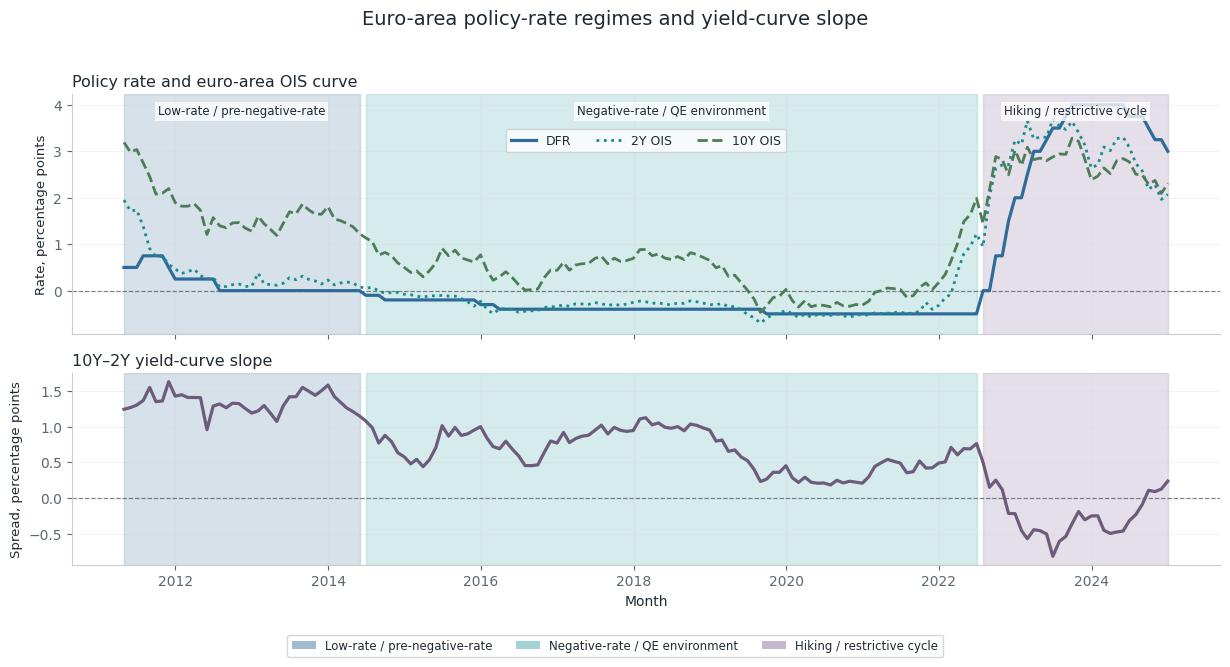

Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\04z_background_policy_curve_and_10y2y_slope.png
DFR column used: dfr
2Y OIS column used: oieur2y
10Y OIS column used: oieu10y
Slope source used: oieu10y − oieur2y


In [9]:
# %%
# ============================================================
# BACKGROUND FIGURE — ECB POLICY RATE, 2Y/10Y OIS AND 10Y–2Y SLOPE
# ============================================================

import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

BG, AX_BG = WP_FIG_BG, WP_AX_BG
BLUE, TEAL, GREEN, PURPLE = WP_BLUE, WP_TEAL, WP_GREEN, WP_PURPLE
GRID, TEXT = WP_GRID, WP_TEXT

d = df_reg_full.copy()
d[MONTH_COL] = pd.to_datetime(d[MONTH_COL]).dt.to_period("M").dt.to_timestamp("M")

# -----------------------------
# Detect columns
# -----------------------------

dfr_col = find_first(d, [
    "dfr", "DFR", "deposit_facility_rate", "ecb_dfr", "ecb_deposit_facility_rate"
])

ois_2y_col = find_first(d, [
    "OIEUR2Y", "oieur2y", "ois_2y", "eur_ois_2y", "euro_ois_2y"
])

ois_10y_col = find_first(d, [
    "OIEUR10Y", "OIEU10Y", "oieur10y", "oieu10y", "ois_10y", "eur_ois_10y", "euro_ois_10y"
])

slope_col = find_first(d, [
    "slope_10y_2y", "ois_slope_10y_2y", "term_spread_10y_2y", "slope"
])

cols = [c for c in [dfr_col, ois_2y_col, ois_10y_col, slope_col, "delta_slope"] if c is not None and c in d.columns]

macro = (
    d[[MONTH_COL, *cols]]
    .drop_duplicates()
    .groupby(MONTH_COL, as_index=False)
    .mean(numeric_only=True)
    .sort_values(MONTH_COL)
)

# -----------------------------
# Helper: convert decimals to percentage points when needed
# -----------------------------

def rate_to_pp(x):
    x = as_numeric(x)
    med_abs = x.abs().median(skipna=True)
    if pd.notna(med_abs) and med_abs < 0.20:
        return x * 100
    return x

# -----------------------------
# Build series
# -----------------------------

if dfr_col is not None:
    macro["dfr_plot"] = rate_to_pp(macro[dfr_col])
else:
    macro["dfr_plot"] = np.nan

if ois_2y_col is not None:
    macro["ois_2y_plot"] = rate_to_pp(macro[ois_2y_col])
else:
    macro["ois_2y_plot"] = np.nan

if ois_10y_col is not None:
    macro["ois_10y_plot"] = rate_to_pp(macro[ois_10y_col])
else:
    macro["ois_10y_plot"] = np.nan

# Prefer slope computed from 10Y and 2Y if both are available.
# Otherwise use existing slope column. Otherwise use cumulative ΔSlope as last fallback.
if ois_10y_col is not None and ois_2y_col is not None:
    macro["slope_plot"] = macro["ois_10y_plot"] - macro["ois_2y_plot"]
    slope_source = f"{ois_10y_col} − {ois_2y_col}"
elif slope_col is not None:
    macro["slope_plot"] = rate_to_pp(macro[slope_col])
    slope_source = slope_col
else:
    macro["slope_plot"] = as_numeric(macro["delta_slope"]).cumsum()
    slope_source = "cumulative ΔSlope fallback"

# -----------------------------
# Regime shading
# -----------------------------

regimes = [
    ("Low-rate / pre-negative-rate", "2011-04-30", "2014-05-31", WP_SHADE_BLUE),
    ("Negative-rate / QE environment", "2014-06-30", "2022-06-30", WP_SHADE_TEAL),
    ("Hiking / restrictive cycle", "2022-07-31", "2024-12-31", WP_SHADE_PURPLE),
]

# -----------------------------
# Plot
# -----------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12.4, 6.6),
    sharex=True,
    gridspec_kw={"height_ratios": [1.25, 1.0]},
)

fig.patch.set_facecolor(BG)

for ax in axes:
    ax.set_facecolor(AX_BG)

    for label, start, end, shade in regimes:
        ax.axvspan(
            pd.Timestamp(start),
            pd.Timestamp(end),
            color=shade,
            alpha=0.35,
            zorder=0,
        )

    ax.axhline(0, color=TEXT, ls="--", lw=0.85, alpha=0.55)
    ax.grid(True, color=GRID, alpha=0.30)

    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

# Panel A: rate levels
axes[0].plot(
    macro[MONTH_COL],
    macro["dfr_plot"],
    color=BLUE,
    lw=2.3,
    label="DFR",
    zorder=3,
)

axes[0].plot(
    macro[MONTH_COL],
    macro["ois_2y_plot"],
    color=TEAL,
    lw=2.0,
    ls=":",
    label="2Y OIS",
    zorder=3,
)

axes[0].plot(
    macro[MONTH_COL],
    macro["ois_10y_plot"],
    color=GREEN,
    lw=2.0,
    ls="--",
    label="10Y OIS",
    zorder=3,
)

axes[0].set_title("Policy rate and euro-area OIS curve", loc="left", fontsize=11.5, pad=5)
axes[0].set_ylabel("Rate, percentage points", fontsize=9.5)

# Regime labels only once
for label, start, end, shade in regimes:
    start, end = pd.Timestamp(start), pd.Timestamp(end)
    mid = start + (end - start) / 2

    axes[0].text(
        mid,
        0.955,
        label,
        transform=axes[0].get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=8.5,
        color=TEXT,
        bbox=dict(facecolor=AX_BG, edgecolor="none", alpha=0.78, pad=2.0),
    )

# Panel B: slope
axes[1].plot(
    macro[MONTH_COL],
    macro["slope_plot"],
    color=PURPLE,
    lw=2.3,
    label="10Y–2Y slope",
    zorder=3,
)

axes[1].set_title("10Y–2Y yield-curve slope", loc="left", fontsize=11.5, pad=5)
axes[1].set_ylabel("Spread, percentage points", fontsize=9.5)
axes[1].set_xlabel("Month")

axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Legends
axes[0].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 0.88),
    frameon=True,
    facecolor=AX_BG,
    edgecolor=WP_BORDER,
    fontsize=9,
    ncol=3,
)

regime_handles = [
    Patch(facecolor=c, alpha=0.8, label=l)
    for l, _, _, c in regimes
]

fig.legend(
    handles=regime_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.005),
    ncol=3,
    frameon=True,
    facecolor=AX_BG,
    edgecolor=WP_BORDER,
    fontsize=8.5,
)

fig.suptitle(
    "Euro-area policy-rate regimes and yield-curve slope",
    fontsize=14,
    y=0.985,
)

fig.tight_layout(rect=[0, 0.055, 1, 0.96])

fig_path = OUT_DIR / "04z_background_policy_curve_and_10y2y_slope.png"

fig.savefig(
    fig_path,
    dpi=240,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

plt.show()

print(f"Saved figure: {fig_path.resolve()}")
print(f"DFR column used: {dfr_col}")
print(f"2Y OIS column used: {ois_2y_col}")
print(f"10Y OIS column used: {ois_10y_col}")
print(f"Slope source used: {slope_source}")


## B.2 Sample coverage tables and core descriptives

Exports country counts, monthly bank counts, and descriptive statistics for core return, slope, deposit, loan-share, and control variables.


In [10]:

# ============================================================
# B.1 SAMPLE / DESCRIPTIVE DIAGNOSTICS
# ============================================================

# Banks by country for the main quality-controlled sample.
if COUNTRY_COL is not None and COUNTRY_COL in df_main.columns and not df_main.empty:
    banks_by_country = (
        df_main[[COUNTRY_COL, BANK_COL]]
        .dropna()
        .drop_duplicates()
        .groupby(COUNTRY_COL)[BANK_COL]
        .nunique()
        .reset_index(name="banks")
        .sort_values("banks", ascending=False)
    )
    save_table(banks_by_country, "04a_banks_by_country_df_main.csv")
else:
    warn_msg("Country column unavailable or df_main empty; banks-by-country diagnostic skipped.")

# Monthly bank counts for key samples.
monthly_count_rows = []
for sample_name, data in [
    ("df_asym_broad_comparison", df_asym),
    ("df_main_quality", df_main),
    ("df_mech_nested", df_mech),
    ("df_common_nested", df_common),
    ("df_loan_nested", df_loan),
]:
    if data is None or data.empty:
        continue
    tmp = data.groupby(MONTH_COL)[BANK_COL].nunique().reset_index(name="banks")
    tmp["sample"] = sample_name
    monthly_count_rows.append(tmp)

if monthly_count_rows:
    monthly_bank_counts = pd.concat(monthly_count_rows, ignore_index=True)
    monthly_bank_counts[MONTH_COL] = pd.to_datetime(monthly_bank_counts[MONTH_COL]).dt.strftime("%Y-%m")
    save_table(monthly_bank_counts[["sample", MONTH_COL, "banks"]], "04b_monthly_bank_counts_key_samples.csv", display_table=False)

# Core descriptive statistics from the full thesis window.
core_vars = [
    DEPENDENT_VAR, "r", "rf", "mkt",
    "delta_slope", "steepening", "flattening", "delta_short", "delta_stress", "delta_sovspread",
    "high_custdep", "high_bankdep", "custdep_ratio_reg", "bankdep_ratio_reg", "custdep_zstd",
    "tier1_ratio_reg", "size_reg", "loan_share_reg", "loan_share_zstd", "credit_risk_reg", "roaa_reg",
    demand_base, time_base, demand_high, time_high, demand_z, time_z,
]
core_vars = list(dict.fromkeys([v for v in core_vars if v is not None and v in df_reg_full.columns]))

VAR_LABELS_DESC = {
    DEPENDENT_VAR: "Monthly bank excess return",
    "r": "Monthly bank equity return",
    "rf": "Monthly risk-free rate",
    "mkt": "Euro Stoxx 50 monthly return",
    "delta_slope": "Change in 10Y–2Y slope",
    "steepening": "Positive change in 10Y–2Y slope",
    "flattening": "Negative change in 10Y–2Y slope",
    "delta_short": "Change in short rate",
    "delta_stress": "Change in financial stress/CISS",
    "delta_sovspread": "Change in sovereign spread",
    "high_custdep": "High customer-deposit bank dummy",
    "high_bankdep": "High bank-deposit bank dummy",
    "custdep_ratio_reg": "Customer deposits / assets, lagged",
    "bankdep_ratio_reg": "Bank deposits / assets, lagged",
    "tier1_ratio_reg": "Tier 1 ratio, lagged",
    "size_reg": "Size, lagged",
    "loan_share_reg": "Customer loans / assets, lagged",
    "credit_risk_reg": "Credit risk, lagged",
    "roaa_reg": "ROAA, lagged",
}


def descriptive_row(var, data=df_reg_full):
    x = as_numeric(data[var])
    valid = data.loc[x.notna(), [BANK_COL, MONTH_COL, DATE_COL]].copy()
    return {
        "variable": var,
        "label": VAR_LABELS_DESC.get(var, var),
        "n": int(x.notna().sum()),
        "banks": int(valid[BANK_COL].nunique()) if not valid.empty else 0,
        "months": int(valid[MONTH_COL].nunique()) if not valid.empty else 0,
        "mean": x.mean(),
        "sd": x.std(),
        "min": x.min(),
        "p1": x.quantile(0.01),
        "p25": x.quantile(0.25),
        "median": x.quantile(0.50),
        "p75": x.quantile(0.75),
        "p99": x.quantile(0.99),
        "max": x.max(),
        "first_nonmissing": valid[DATE_COL].min() if not valid.empty else pd.NaT,
        "last_nonmissing": valid[DATE_COL].max() if not valid.empty else pd.NaT,
    }


descriptive_stats = pd.DataFrame([descriptive_row(v) for v in core_vars])
for c in ["first_nonmissing", "last_nonmissing"]:
    descriptive_stats[c] = pd.to_datetime(descriptive_stats[c], errors="coerce").dt.strftime("%Y-%m")
for c in ["mean", "sd", "min", "p1", "p25", "median", "p75", "p99", "max"]:
    descriptive_stats[c] = pd.to_numeric(descriptive_stats[c], errors="coerce").round(4)
save_table(descriptive_stats, "04c_descriptive_stats_core_variables.csv")


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\04a_banks_by_country_df_main.csv


,country,banks
5,Italy,9
0,Austria,5
11,Spain,5
2,France,3
4,Ireland,3
3,Germany,3
1,Finland,2
7,Malta,2
6,Lithuania,1
8,Netherlands,1


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\04b_monthly_bank_counts_key_samples.csv
Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\04c_descriptive_stats_core_variables.csv


,variable,label,n,banks,months,mean,sd,min,p1,p25,median,p75,p99,max,first_nonmissing,last_nonmissing
0,r_excess,Monthly bank excess return,5921,36,165,0.0074,0.1180,-0.7441,-0.2874,-0.0391,0.0036,0.0553,0.3097,3.9950,2011-04,2024-12
1,r,Monthly bank equity return,5921,36,165,0.0078,0.1181,-0.7430,-0.2876,-0.0390,0.0040,0.0559,0.3113,3.9947,2011-04,2024-12
2,rf,Monthly risk-free rate,5940,36,165,0.0004,0.0011,-0.0004,-0.0004,-0.0003,-0.0001,0.0003,0.0033,0.0033,2011-04,2024-12
3,mkt,Euro Stoxx 50 monthly return,5940,36,165,0.0073,0.0471,-0.1618,-0.1368,-0.0255,0.0116,0.0398,0.1037,0.1809,2011-04,2024-12
4,delta_slope,Change in 10Y–2Y slope,5940,36,165,-0.0067,0.1212,-0.4493,-0.3482,-0.0830,-0.0006,0.0683,0.3075,0.3310,2011-04,2024-12
5,steepening,Positive change in 10Y–2Y slope,5940,36,165,0.0427,0.0664,0.0000,0.0000,0.0000,0.0000,0.0683,0.3075,0.3310,2011-04,2024-12
6,flattening,Negative change in 10Y–2Y slope,5940,36,165,-0.0495,0.0779,-0.4493,-0.3482,-0.0830,-0.0006,0.0000,0.0000,0.0000,2011-04,2024-12
7,delta_short,Change in short rate,5940,36,165,0.0124,0.1176,-0.2950,-0.2920,-0.0114,-0.0010,0.0070,0.4204,0.6956,2011-04,2024-12
8,delta_stress,Change in financial stress/CISS,5940,36,165,-0.0016,0.0966,-0.2866,-0.2858,-0.0386,-0.0048,0.0228,0.3781,0.4974,2011-04,2024-12
9,delta_sovspread,Change in sovereign spread,5940,36,165,-0.0058,0.2018,-2.3500,-0.6800,-0.0552,-0.0048,0.0350,0.7970,2.8400,2011-04,2024-12


WindowsPath('c:/Users/rijul/OneDrive/Desktop/Thesis Mid/Thesis Code Consolidated/final panel/steepening_regression_outputs_201104_202412_refactored/04c_descriptive_stats_core_variables.csv')

## B.3 Summary statistics table

Main regression-variable moments, with steepening/flattening reported conditionally where appropriate.


In [11]:
# %%
# ============================================================
# TABLE X — SUMMARY STATISTICS FOR MAIN REGRESSION VARIABLES
# Steepening/Flattening reported conditional on non-zero months
# ============================================================

SUMMARY_DIGITS = 4

# ------------------------------------------------------------
# 1. Choose final samples
# ------------------------------------------------------------

df_summary_main = df_main.copy()
df_summary_mech = df_mech.copy() if "df_mech" in globals() and not df_mech.empty else df_summary_main.copy()
df_summary_loan = df_loan.copy() if "df_loan" in globals() and not df_loan.empty else df_summary_main.copy()

# If HHI appendix sample exists later in the notebook, use it.
# Otherwise compute HHI stats on the main final sample.
df_summary_hhi = df_hhi.copy() if "df_hhi" in globals() and not df_hhi.empty else df_summary_main.copy()

# ------------------------------------------------------------
# 2. Detect variable columns
# ------------------------------------------------------------

DEMAND_SHARE_COL = globals().get("demand_base", None)

if DEMAND_SHARE_COL is None or DEMAND_SHARE_COL not in df_summary_mech.columns:
    DEMAND_SHARE_COL = find_first(df_summary_mech, [
        "demand_dep_share_py",
        "demand_dep_share_reg",
        "demand_dep_share",
        "sight_dep_share_reg",
        "sight_dep_share",
        "sight_dep_ratio_reg",
        "sight_dep_ratio",
        "non_maturity_dep_share_reg",
        "non_maturity_dep_share",
        "transaction_dep_share_reg",
        "transaction_dep_share",
        "WC15179",
        "wc15179",
    ])

SAVINGS_SHARE_COL = globals().get("time_base", None)

if SAVINGS_SHARE_COL is None or SAVINGS_SHARE_COL not in df_summary_mech.columns:
    SAVINGS_SHARE_COL = find_first(df_summary_mech, [
        "savings_dep_share_py",
        "savings_dep_share_reg",
        "savings_dep_share",
        "time_dep_share_reg",
        "time_dep_share",
        "time_savings_dep_share_reg",
        "time_savings_dep_share",
        "term_dep_share_reg",
        "term_dep_share",
        "fixed_term_dep_share_reg",
        "fixed_term_dep_share",
        "WC15184",
        "wc15184",
    ])

CISS_COL = find_first(df_summary_main, [
    "ciss",
    "ciss_level",
    "ciss_index",
    "financial_stress",
    "financial_stress_index",
    "stress",
    "stress_level",
    "stress_index",
])

CISS_LABEL = "CISS"

if CISS_COL is None:
    CISS_COL = find_first(df_summary_main, [
        "delta_stress",
        "delta_ciss",
        "delta_fin_stress",
        "delta_financial_stress",
        "stress_delta",
    ])
    CISS_LABEL = "ΔCISS / stress change"

HHI_COL = find_first(df_summary_hhi, [
    "hhi_assets_country",
    "hhi_assets_country_lag1",
    "hhi_reg",
    "banking_hhi",
    "market_hhi",
    "hhi_assets_country_zstd",
    "hhi_zstd",
])

# ------------------------------------------------------------
# 3. Define Table X variables
# ------------------------------------------------------------

summary_specs = [
    ("Monthly excess returns", DEPENDENT_VAR, df_summary_main, "Main sample", False),
    ("ΔSlope", "delta_slope", df_summary_main, "Main sample", False),

    # Conditional stats avoid the zero-censoring problem.
    ("Steepening | ΔSlope > 0", "steepening", df_summary_main, "Main sample", True),
    ("Flattening | ΔSlope < 0", "flattening", df_summary_main, "Main sample", True),

    ("Customer-deposit ratio", "custdep_ratio_reg", df_summary_main, "Main sample", False),
    ("Bank-deposit ratio", "bankdep_ratio_reg", df_summary_main, "Main sample", False),

    ("Demand share", DEMAND_SHARE_COL, df_summary_mech, "Mechanism sample", False),
    ("Savings share", SAVINGS_SHARE_COL, df_summary_mech, "Mechanism sample", False),

    ("Tier 1 ratio", "tier1_ratio_reg", df_summary_main, "Main sample", False),
    ("Size", "size_reg", df_summary_main, "Main sample", False),
    ("Loan share", "loan_share_reg", df_summary_loan, "Loan-share sample", False),
    ("Credit risk", "credit_risk_reg", df_summary_main, "Main sample", False),
    ("ROAA", "roaa_reg", df_summary_main, "Main sample", False),

    (CISS_LABEL, CISS_COL, df_summary_main, "Main sample", False),
    ("Sovereign-spread change", "delta_sovspread", df_summary_main, "Main sample", False),
    ("HHI", HHI_COL, df_summary_hhi, "Main/HHI sample", False),
]

# ------------------------------------------------------------
# 4. Build summary-statistics rows
# ------------------------------------------------------------

def summary_stat_row(label, col, data, sample_name, nonzero_only=False):
    if col is None or col not in data.columns:
        return {
            "Variable": label,
            "Sample": sample_name,
            "Column used": "NOT FOUND",
            "Mean": np.nan,
            "Median": np.nan,
            "Std. dev.": np.nan,
            "Minimum": np.nan,
            "Maximum": np.nan,
            "Observations": 0,
            "Banks": 0,
            "Months": 0,
            "Status": "Missing variable",
        }

    x = as_numeric(data[col])

    if nonzero_only:
        valid = x.notna() & (x != 0)
        status = "OK, non-zero months only"
    else:
        valid = x.notna()
        status = "OK"

    valid_data = data.loc[valid].copy()
    x = x.loc[valid]

    return {
        "Variable": label,
        "Sample": sample_name,
        "Column used": col,
        "Mean": x.mean(),
        "Median": x.median(),
        "Std. dev.": x.std(ddof=1),
        "Minimum": x.min(),
        "Maximum": x.max(),
        "Observations": int(valid.sum()),
        "Banks": int(valid_data[BANK_COL].nunique()) if BANK_COL in valid_data.columns else np.nan,
        "Months": int(valid_data[MONTH_COL].nunique()) if MONTH_COL in valid_data.columns else np.nan,
        "Status": status,
    }

table_x_audit = pd.DataFrame([
    summary_stat_row(label, col, data, sample_name, nonzero_only)
    for label, col, data, sample_name, nonzero_only in summary_specs
])

# ------------------------------------------------------------
# 5. Create thesis-ready rounded table
# ------------------------------------------------------------

table_x_summary_stats = table_x_audit.copy()

for c in ["Mean", "Median", "Std. dev.", "Minimum", "Maximum"]:
    table_x_summary_stats[c] = (
        pd.to_numeric(table_x_summary_stats[c], errors="coerce")
        .round(SUMMARY_DIGITS)
    )

table_x_summary_stats = table_x_summary_stats[
    [
        "Variable",
        "Sample",
        "Mean",
        "Median",
        "Std. dev.",
        "Minimum",
        "Maximum",
        "Observations",
    ]
]

# ------------------------------------------------------------
# 6. Save outputs
# ------------------------------------------------------------

save_table(
    table_x_audit,
    "04x_table_x_summary_statistics_audit.csv",
    display_table=True,
)

save_table(
    table_x_summary_stats,
    "04x_table_x_summary_statistics_thesis_ready.csv",
    display_table=True,
)

# ------------------------------------------------------------
# 7. Suggested thesis table note
# ------------------------------------------------------------

table_x_note = (
    "Note: Steepening and Flattening are reported conditional on non-zero months "
    "because they are constructed as censored components of ΔSlope. ΔSlope itself "
    "is reported unconditionally. All other variables are reported on their relevant "
    "final regression sample."
)

print("\nSuggested table note:")
print(table_x_note)


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\04x_table_x_summary_statistics_audit.csv


,Variable,Sample,Column used,Mean,Median,Std. dev.,Minimum,Maximum,Observations,Banks,Months,Status
0,Monthly excess returns,Main sample,r_excess,0.008165,0.004161,0.114698,-0.685416,3.995010,5318,36,165,OK
1,ΔSlope,Main sample,delta_slope,-0.006777,-0.000600,0.120010,-0.449300,0.331000,5318,36,165,OK
2,Steepening | ΔSlope > 0,Main sample,steepening,0.086113,0.069900,0.069854,0.000200,0.331000,2618,36,81,"OK, non-zero months only"
3,Flattening | ΔSlope < 0,Main sample,flattening,-0.096847,-0.083000,0.084592,-0.449300,-0.000100,2700,36,84,"OK, non-zero months only"
4,Customer-deposit ratio,Main sample,custdep_ratio_reg,0.560280,0.569531,0.186358,0.026484,1.370805,5318,36,165,OK
5,Bank-deposit ratio,Main sample,bankdep_ratio_reg,0.088225,0.086521,0.057047,0.000044,0.303355,5260,36,165,OK
6,Demand share,Mechanism sample,demand_dep_share_py,0.672464,0.708000,0.235478,0.067800,1.000000,3328,31,165,OK
7,Savings share,Mechanism sample,savings_dep_share_py,0.277499,0.247400,0.197472,0.000400,0.800500,3306,31,165,OK
8,Tier 1 ratio,Main sample,tier1_ratio_reg,13.523612,13.280514,2.780615,6.707350,22.661015,5318,36,165,OK
9,Size,Main sample,size_reg,18.551393,18.608181,2.017224,13.640179,22.683292,5318,36,165,OK


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\04x_table_x_summary_statistics_thesis_ready.csv


,Variable,Sample,Mean,Median,Std. dev.,Minimum,Maximum,Observations
0,Monthly excess returns,Main sample,0.0082,0.0042,0.1147,-0.6854,3.9950,5318
1,ΔSlope,Main sample,-0.0068,-0.0006,0.1200,-0.4493,0.3310,5318
2,Steepening | ΔSlope > 0,Main sample,0.0861,0.0699,0.0699,0.0002,0.3310,2618
3,Flattening | ΔSlope < 0,Main sample,-0.0968,-0.0830,0.0846,-0.4493,-0.0001,2700
4,Customer-deposit ratio,Main sample,0.5603,0.5695,0.1864,0.0265,1.3708,5318
5,Bank-deposit ratio,Main sample,0.0882,0.0865,0.0570,0.0000,0.3034,5260
6,Demand share,Mechanism sample,0.6725,0.7080,0.2355,0.0678,1.0000,3328
7,Savings share,Mechanism sample,0.2775,0.2474,0.1975,0.0004,0.8005,3306
8,Tier 1 ratio,Main sample,13.5236,13.2805,2.7806,6.7073,22.6610,5318
9,Size,Main sample,18.5514,18.6082,2.0172,13.6402,22.6833,5318



Suggested table note:
Note: Steepening and Flattening are reported conditional on non-zero months because they are constructed as censored components of ΔSlope. ΔSlope itself is reported unconditionally. All other variables are reported on their relevant final regression sample.


## B.4 Raw correlation matrix and top correlations

Self-contained correlation table and heatmap for the thesis variables, with overlap/construction flags for easier visual checking.


Correlation sample used: df_main
Rows available before pairwise deletion: 5,318

Correlation variable source audit:


,Label,Column used,Non-missing,Included
0,Excess return,r_excess,5318,True
1,ΔSlope,delta_slope,5318,True
2,ΔShort,delta_short,5318,True
3,ΔSovSpread,delta_sovspread,5318,True
4,ΔCISS / Stress,delta_stress,5318,True
5,CustDep ratio,custdep_ratio_reg,5318,True
6,BankDep ratio,bankdep_ratio_reg,5260,True
7,Demand/Sight share,demand_dep_share_py,4071,True
8,Time/Savings share,savings_dep_share_py,4186,True
9,Tier 1 ratio,tier1_ratio_reg,5318,True



Raw pairwise correlation matrix:


,Excess return,ΔSlope,ΔShort,ΔSovSpread,ΔCISS / Stress,CustDep ratio,BankDep ratio,Demand/Sight share,Time/Savings share,Tier 1 ratio,Size,Loan share,Credit risk,ROAA,HHI
Excess return,1.000,0.032,0.077,-0.218,-0.304,0.018,-0.012,0.007,-0.013,0.048,-0.008,0.001,-0.062,0.025,0.014
ΔSlope,0.032,1.000,-0.258,0.073,0.194,0.001,-0.019,-0.007,-0.005,0.006,0.000,-0.003,-0.006,0.007,-0.005
ΔShort,0.077,-0.258,1.000,-0.045,-0.021,0.047,-0.025,0.088,-0.057,0.188,0.026,-0.026,-0.109,0.025,0.059
ΔSovSpread,-0.218,0.073,-0.045,1.000,0.217,-0.015,0.014,-0.003,-0.020,-0.012,0.005,-0.000,-0.026,0.058,-0.005
ΔCISS / Stress,-0.304,0.194,-0.021,0.217,1.000,0.006,-0.002,0.013,-0.010,0.005,-0.004,0.003,0.008,-0.003,0.006
CustDep ratio,0.018,0.001,0.047,-0.015,0.006,1.000,-0.146,0.165,-0.149,0.103,-0.643,0.608,0.011,0.264,0.137
BankDep ratio,-0.012,-0.019,-0.025,0.014,-0.002,-0.146,1.000,0.077,-0.247,-0.264,-0.093,0.318,0.172,-0.186,-0.365
Demand/Sight share,0.007,-0.007,0.088,-0.003,0.013,0.165,0.077,1.000,-0.717,0.268,0.028,0.318,0.119,0.002,0.242
Time/Savings share,-0.013,-0.005,-0.057,-0.020,-0.010,-0.149,-0.247,-0.717,1.000,-0.055,0.170,-0.411,-0.105,0.022,0.328
Tier 1 ratio,0.048,0.006,0.188,-0.012,0.005,0.103,-0.264,0.268,-0.055,1.000,0.055,-0.187,-0.280,0.225,0.333



Pairwise observation counts:


,Excess return,ΔSlope,ΔShort,ΔSovSpread,ΔCISS / Stress,CustDep ratio,BankDep ratio,Demand/Sight share,Time/Savings share,Tier 1 ratio,Size,Loan share,Credit risk,ROAA,HHI
Excess return,5318,5318,5318,5318,5318,5318,5260,4071,4186,5318,5318,5318,5318,5318,5318
ΔSlope,5318,5318,5318,5318,5318,5318,5260,4071,4186,5318,5318,5318,5318,5318,5318
ΔShort,5318,5318,5318,5318,5318,5318,5260,4071,4186,5318,5318,5318,5318,5318,5318
ΔSovSpread,5318,5318,5318,5318,5318,5318,5260,4071,4186,5318,5318,5318,5318,5318,5318
ΔCISS / Stress,5318,5318,5318,5318,5318,5318,5260,4071,4186,5318,5318,5318,5318,5318,5318
CustDep ratio,5318,5318,5318,5318,5318,5318,5260,4071,4186,5318,5318,5318,5318,5318,5318
BankDep ratio,5260,5260,5260,5260,5260,5260,5260,4049,4128,5260,5260,5260,5260,5260,5260
Demand/Sight share,4071,4071,4071,4071,4071,4071,4049,4071,3259,4071,4071,4071,4071,4071,4071
Time/Savings share,4186,4186,4186,4186,4186,4186,4128,3259,4186,4186,4186,4186,4186,4186,4186
Tier 1 ratio,5318,5318,5318,5318,5318,5318,5260,4071,4186,5318,5318,5318,5318,5318,5318


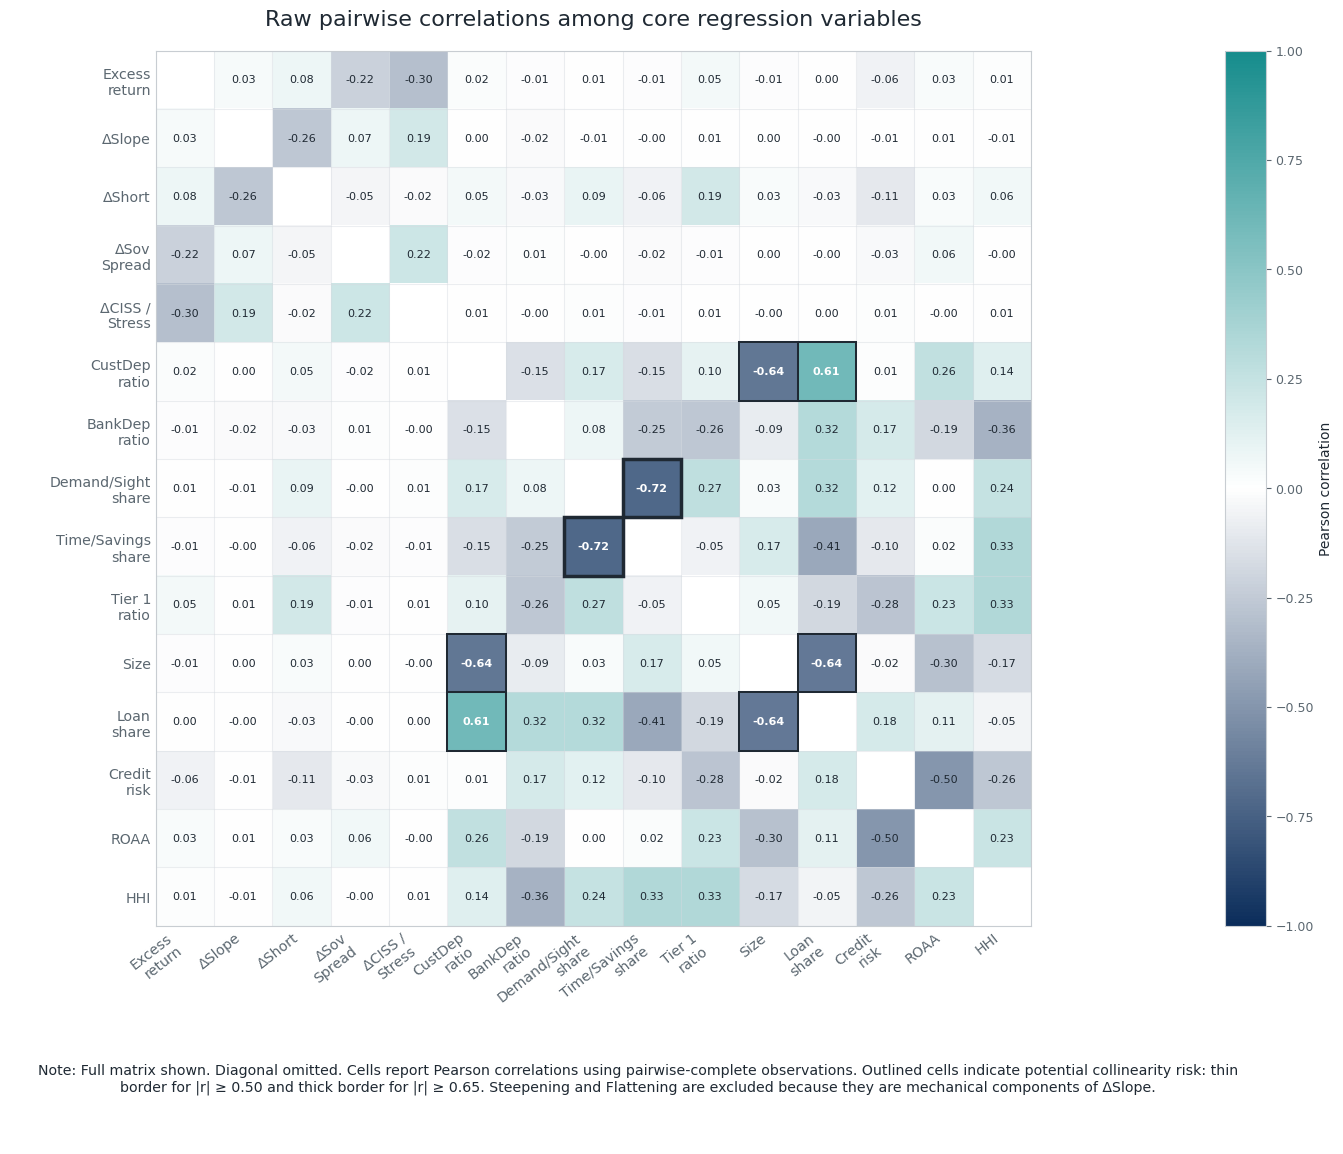

Saved heatmap figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\correlation_diagnostics\04y_figure_raw_pairwise_correlation_heatmap.png

Largest raw pairwise correlations:


,Variable A,Variable B,Correlation,Abs correlation,Pairwise observations,Construction-driven overlap
0,Time/Savings share,Demand/Sight share,-0.7173,0.7173,3259,True
1,Size,CustDep ratio,-0.6427,0.6427,5318,True
2,Loan share,Size,-0.6353,0.6353,5318,True
3,Loan share,CustDep ratio,0.6079,0.6079,5318,True
4,ROAA,Credit risk,-0.4990,0.4990,5318,False
5,Loan share,Time/Savings share,-0.4115,0.4115,4186,False
6,HHI,BankDep ratio,-0.3646,0.3646,5260,False
7,HHI,Tier 1 ratio,0.3326,0.3326,5318,False
8,HHI,Time/Savings share,0.3284,0.3284,4186,False
9,Loan share,Demand/Sight share,0.3185,0.3185,4071,False


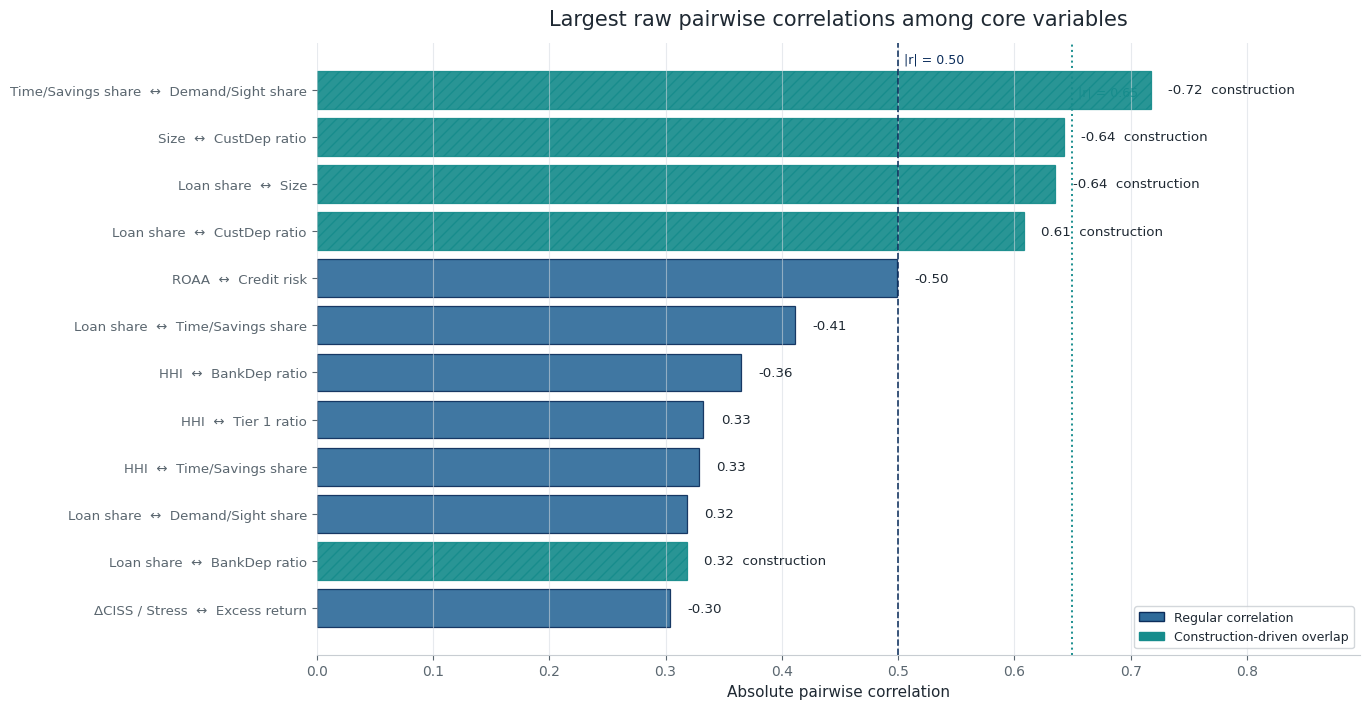

Saved flagged top-correlation figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\correlation_diagnostics\04y_figure_top_pairwise_correlations_flagged_blue_theme.png


In [12]:
# ============================================================
# RAW CORRELATION MATRIX + HEATMAP — SELF-CONTAINED
# Builds corr_matrix first, then plots heatmap + top correlations
# ============================================================

from pathlib import Path
from matplotlib.patches import Rectangle, Patch
from matplotlib.colors import LinearSegmentedColormap
from textwrap import fill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 0. Output folder
# -----------------------------

OUT_DIR_CORR = OUT_DIR / "correlation_diagnostics" if "OUT_DIR" in globals() else Path("correlation_diagnostics")
OUT_DIR_CORR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1. Safe helpers
# -----------------------------

def corr_as_numeric(x):
    if "as_numeric" in globals():
        return as_numeric(x)
    return pd.to_numeric(x, errors="coerce").replace([np.inf, -np.inf], np.nan)

def corr_find_first(data, candidates):
    if "find_first" in globals():
        return find_first(data, candidates)

    lower_map = {str(c).lower(): c for c in data.columns}
    for cand in candidates:
        if cand is None:
            continue
        if cand in data.columns:
            return cand
        key = str(cand).lower()
        if key in lower_map:
            return lower_map[key]
    return None

def corr_show(obj):
    if "show_df" in globals():
        show_df(obj)
    else:
        print(obj.to_string(index=False) if hasattr(obj, "to_string") else obj)

# -----------------------------
# 2. Choose sample
# -----------------------------

if "df_main" in globals() and isinstance(df_main, pd.DataFrame) and not df_main.empty:
    corr_source = df_main.copy()
    CORR_SAMPLE_USED = "df_main"
elif "df_reg_full" in globals() and isinstance(df_reg_full, pd.DataFrame) and not df_reg_full.empty:
    corr_source = df_reg_full.copy()
    CORR_SAMPLE_USED = "df_reg_full"
else:
    raise ValueError("No usable regression dataframe found. Run after df_main or df_reg_full is created.")

print(f"Correlation sample used: {CORR_SAMPLE_USED}")
print(f"Rows available before pairwise deletion: {len(corr_source):,}")

# -----------------------------
# 3. Detect columns
# -----------------------------

dep_col = globals().get("DEPENDENT_VAR", "r_excess")

demand_col = globals().get("demand_base", None)
if demand_col is None or demand_col not in corr_source.columns:
    demand_col = corr_find_first(corr_source, [
        "demand_dep_share_py",
        "demand_dep_share_reg",
        "demand_dep_share",
        "sight_dep_share_reg",
        "sight_dep_share",
        "sight_dep_ratio_reg",
        "sight_dep_ratio",
        "non_maturity_dep_share_reg",
        "non_maturity_dep_share",
        "transaction_dep_share_reg",
        "transaction_dep_share",
        "WC15179",
        "wc15179",
    ])

time_col = globals().get("time_base", None)
if time_col is None or time_col not in corr_source.columns:
    time_col = corr_find_first(corr_source, [
        "savings_dep_share_py",
        "savings_dep_share_reg",
        "savings_dep_share",
        "time_dep_share_reg",
        "time_dep_share",
        "time_savings_dep_share_reg",
        "time_savings_dep_share",
        "term_dep_share_reg",
        "term_dep_share",
        "fixed_term_dep_share_reg",
        "fixed_term_dep_share",
        "WC15184",
        "wc15184",
    ])

hhi_col = corr_find_first(corr_source, [
    "hhi_zstd",
    "hhi_assets_country_zstd",
    "hhi_assets_country_lag1_zstd",
    "hhi_assets_country",
    "hhi_reg",
    "banking_hhi",
    "market_hhi",
])

# -----------------------------
# 4. Build correlation dataframe
# -----------------------------

corr_specs = [
    ("Excess return", dep_col),
    ("ΔSlope", "delta_slope"),
    ("ΔShort", "delta_short"),
    ("ΔSovSpread", "delta_sovspread"),
    ("ΔCISS / Stress", "delta_stress"),

    ("CustDep ratio", "custdep_ratio_reg"),
    ("BankDep ratio", "bankdep_ratio_reg"),
    ("Demand/Sight share", demand_col),
    ("Time/Savings share", time_col),

    ("Tier 1 ratio", "tier1_ratio_reg"),
    ("Size", "size_reg"),
    ("Loan share", "loan_share_reg"),
    ("Credit risk", "credit_risk_reg"),
    ("ROAA", "roaa_reg"),
    ("HHI", hhi_col),
]

MIN_NONMISSING = 30
MIN_PAIRWISE_OBS = 30

corr_data = pd.DataFrame(index=corr_source.index)
source_rows = []

for label, col in corr_specs:
    if col is None or col not in corr_source.columns:
        source_rows.append({
            "Label": label,
            "Column used": "NOT FOUND",
            "Non-missing": 0,
            "Included": False,
        })
        continue

    x = corr_as_numeric(corr_source[col])
    nonmissing = int(x.notna().sum())

    include = nonmissing >= MIN_NONMISSING

    source_rows.append({
        "Label": label,
        "Column used": col,
        "Non-missing": nonmissing,
        "Included": include,
    })

    if include:
        corr_data[label] = x

corr_variable_sources = pd.DataFrame(source_rows)

print("\nCorrelation variable source audit:")
corr_show(corr_variable_sources)

corr_variable_sources.to_csv(
    OUT_DIR_CORR / "04y_correlation_variable_sources.csv",
    index=False,
)

if corr_data.shape[1] < 2:
    raise ValueError("Fewer than two usable variables for correlation matrix.")

corr_matrix = corr_data.corr(method="pearson", min_periods=MIN_PAIRWISE_OBS)
corr_pairwise_n = corr_data.notna().astype(int).T @ corr_data.notna().astype(int)

corr_matrix.round(4).to_csv(
    OUT_DIR_CORR / "04y_raw_pairwise_correlation_matrix.csv"
)

corr_pairwise_n.to_csv(
    OUT_DIR_CORR / "04y_pairwise_observation_counts.csv"
)

print("\nRaw pairwise correlation matrix:")
corr_show(corr_matrix.round(3))

print("\nPairwise observation counts:")
corr_show(corr_pairwise_n)

# ============================================================
# 5. FULL CORRELATION HEATMAP — ALL NUMBERS + HIGHLIGHT BIG ONES
# ============================================================

BG = WP_FIG_BG
AX_BG = WP_AX_BG
NAVY = WP_NAVY
BLUE = WP_BLUE
TEAL = WP_TEAL
GRID = WP_GRID
TEXT = WP_TEXT

corr_cmap = LinearSegmentedColormap.from_list(
    "navy_white_teal",
    [
        (0.00, NAVY),
        (0.50, WP_AX_BG),
        (1.00, TEAL),
    ],
)

RISK_THRESHOLD = 0.50
HIGH_RISK_THRESHOLD = 0.65

label_map = {
    "Excess return": "Excess\nreturn",
    "CustDep ratio": "CustDep\nratio",
    "BankDep ratio": "BankDep\nratio",
    "Demand/Sight share": "Demand/Sight\nshare",
    "Time/Savings share": "Time/Savings\nshare",
    "Tier 1 ratio": "Tier 1\nratio",
    "Loan share": "Loan\nshare",
    "Credit risk": "Credit\nrisk",
    "ΔCISS / Stress": "ΔCISS /\nStress",
    "ΔSovSpread": "ΔSov\nSpread",
}

labels_raw = corr_matrix.index.tolist()
labels = [label_map.get(x, x) for x in labels_raw]

C = corr_matrix.to_numpy(float)
C_plot = C.copy()
np.fill_diagonal(C_plot, np.nan)

cmap = corr_cmap.copy()
cmap.set_bad(color=AX_BG)

fig = plt.figure(figsize=(16.2, 14.2), facecolor=BG)

gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[36, 1.25],
    height_ratios=[36, 3.8],
    wspace=0.08,
    hspace=0.26,
)

ax = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])
note_ax = fig.add_subplot(gs[1, :])
note_ax.axis("off")

ax.set_facecolor(AX_BG)

im = ax.imshow(
    C_plot,
    vmin=-1,
    vmax=1,
    cmap=cmap,
    aspect="equal",
)

n = len(labels)

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(labels, rotation=38, ha="right", fontsize=10.2)
ax.set_yticklabels(labels, fontsize=10.2)

ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color=GRID, linestyle="-", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

for i in range(n):
    for j in range(n):

        if i == j:
            continue

        val = C[i, j]

        if pd.isna(val):
            continue

        abs_val = abs(val)

        if abs_val >= RISK_THRESHOLD:
            ax.add_patch(
                Rectangle(
                    (j - 0.5, i - 0.5),
                    1,
                    1,
                    fill=False,
                    edgecolor=WP_TEXT,
                    linewidth=2.5 if abs_val >= HIGH_RISK_THRESHOLD else 1.45,
                    zorder=4,
                )
            )

        ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=8.0,
            color="white" if abs_val >= 0.55 else TEXT,
            fontweight="bold" if abs_val >= RISK_THRESHOLD else "normal",
            zorder=5,
        )

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Pearson correlation", fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_title(
    "Raw pairwise correlations among core regression variables",
    fontsize=16,
    pad=18,
)

note = (
    "Note: Full matrix shown. Diagonal omitted. Cells report Pearson correlations using pairwise-complete observations. "
    "Outlined cells indicate potential collinearity risk: thin border for |r| ≥ 0.50 and thick border for |r| ≥ 0.65. "
    "Steepening and Flattening are excluded because they are mechanical components of ΔSlope."
)

note_ax.text(
    0.50,
    0.70,
    fill(note, width=175),
    ha="center",
    va="center",
    fontsize=10.2,
    color=TEXT,
)

heatmap_path = OUT_DIR_CORR / "04y_figure_raw_pairwise_correlation_heatmap.png"

fig.savefig(
    heatmap_path,
    dpi=260,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

plt.show()

print(f"Saved heatmap figure: {heatmap_path.resolve()}")

# ============================================================
# 6. HIGHEST CORRELATIONS — FLAG CONSTRUCTION-DRIVEN OVERLAP
# ============================================================

def is_construction_overlap(a, b):
    pair = {a, b}

    construction_pairs = [
        {"Demand/Sight share", "Time/Savings share"},
        {"CustDep ratio", "Loan share"},
        {"CustDep ratio", "BankDep ratio"},
        {"BankDep ratio", "Loan share"},
        {"Size", "CustDep ratio"},
        {"Size", "Loan share"},
        {"Size", "BankDep ratio"},
    ]

    return any(pair == p for p in construction_pairs)

pairs = []

for i, var_i in enumerate(corr_matrix.index):
    for j, var_j in enumerate(corr_matrix.columns):

        if j >= i:
            continue

        r = corr_matrix.loc[var_i, var_j]

        if pd.isna(r):
            continue

        pairs.append({
            "Variable A": var_i,
            "Variable B": var_j,
            "Correlation": r,
            "Abs correlation": abs(r),
            "Pairwise observations": int(corr_pairwise_n.loc[var_i, var_j]),
            "Construction-driven overlap": is_construction_overlap(var_i, var_j),
        })

corr_pairs = (
    pd.DataFrame(pairs)
    .sort_values("Abs correlation", ascending=False)
    .reset_index(drop=True)
)

corr_pairs.round(4).to_csv(
    OUT_DIR_CORR / "04y_ranked_pairwise_correlations_core_variables_flagged.csv",
    index=False,
)

print("\nLargest raw pairwise correlations:")
corr_show(corr_pairs.head(20).round(4))

if corr_pairs.empty:
    print("No valid pairwise correlations available for top-correlation plot.")

else:
    TOP_N = 12

    top_pairs = corr_pairs.head(TOP_N).sort_values("Abs correlation", ascending=True).copy()
    top_pairs["Pair"] = top_pairs["Variable A"] + "  ↔  " + top_pairs["Variable B"]

    fig, ax = plt.subplots(figsize=(13.8, max(6.2, 0.60 * len(top_pairs))))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(AX_BG)

    y = np.arange(len(top_pairs))

    bar_colors = np.where(
        top_pairs["Construction-driven overlap"],
        TEAL,
        BLUE,
    )

    edge_colors = np.where(
        top_pairs["Construction-driven overlap"],
        WP_TEAL,
        NAVY,
    )

    bars = ax.barh(
        y,
        top_pairs["Abs correlation"],
        color=bar_colors,
        alpha=0.92,
        edgecolor=edge_colors,
        linewidth=0.9,
    )

    for bar, construction_flag in zip(bars, top_pairs["Construction-driven overlap"]):
        if construction_flag:
            bar.set_hatch("///")

    for i, (_, row) in enumerate(top_pairs.iterrows()):
        label = f"{row['Correlation']:.2f}"
        if row["Construction-driven overlap"]:
            label += "  construction"

        ax.text(
            row["Abs correlation"] + 0.015,
            i,
            label,
            va="center",
            ha="left",
            fontsize=9.6,
            color=TEXT,
        )

    ax.axvline(0.50, color=NAVY, linestyle="--", linewidth=1.25, alpha=0.90)
    ax.axvline(0.65, color=TEAL, linestyle=":", linewidth=1.45, alpha=0.95)

    ax.text(
        0.505,
        len(top_pairs) - 0.35,
        "|r| = 0.50",
        fontsize=9,
        color=NAVY,
        va="center",
    )

    ax.text(
        0.655,
        len(top_pairs) - 1.05,
        "|r| = 0.65",
        fontsize=9,
        color=TEAL,
        va="center",
    )

    ax.set_yticks(y)
    ax.set_yticklabels(top_pairs["Pair"], fontsize=9.6)
    ax.set_xlabel("Absolute pairwise correlation", fontsize=11)
    ax.set_title(
        "Largest raw pairwise correlations among core variables",
        fontsize=15,
        pad=13,
    )

    x_max = min(1.0, max(0.75, top_pairs["Abs correlation"].max() + 0.18))
    ax.set_xlim(0, x_max)
    ax.grid(True, axis="x", color=GRID, alpha=0.55)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    legend_items = [
        Patch(facecolor=BLUE, edgecolor=NAVY, label="Regular correlation"),
        Patch(facecolor=TEAL, edgecolor=WP_TEAL, hatch="///", label="Construction-driven overlap"),
    ]

    ax.legend(
        handles=legend_items,
        loc="lower right",
        frameon=True,
        facecolor=AX_BG,
        edgecolor=WP_BORDER,
        fontsize=9,
    )

    fig.tight_layout()

    bar_path = OUT_DIR_CORR / "04y_figure_top_pairwise_correlations_flagged_blue_theme.png"

    fig.savefig(
        bar_path,
        dpi=260,
        bbox_inches="tight",
        facecolor=fig.get_facecolor(),
    )

    plt.show()

    print(f"Saved flagged top-correlation figure: {bar_path.resolve()}")


## B.5 Figure — Banks by country

Country-level bank counts in the final main sample.


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\04a_banks_by_country_df_main.csv


,country,banks
5,Italy,9
0,Austria,5
11,Spain,5
2,France,3
4,Ireland,3
3,Germany,3
7,Malta,2
1,Finland,2
8,Netherlands,1
9,Portugal,1


Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\04a_figure_banks_by_country_df_main.png


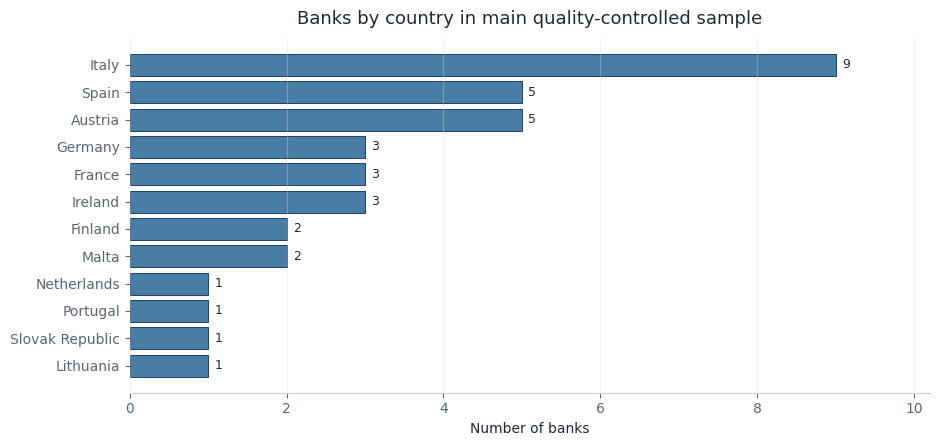

In [13]:
# ============================================================
# 8A. FIGURE — BANKS BY COUNTRY, MAIN SAMPLE
# ============================================================

if COUNTRY_COL is not None and COUNTRY_COL in df_main.columns and not df_main.empty:

    banks_by_country = (
        df_main[[COUNTRY_COL, BANK_COL]]
        .dropna()
        .drop_duplicates()
        .groupby(COUNTRY_COL)[BANK_COL]
        .nunique()
        .reset_index(name="banks")
        .sort_values("banks", ascending=True)
    )

    save_table(
        banks_by_country.sort_values("banks", ascending=False),
        "04a_banks_by_country_df_main.csv",
        display_table=True,
    )

    fig, ax = plt.subplots(figsize=(9.5, max(4.5, 0.38 * len(banks_by_country))))
    fig.patch.set_facecolor(WP_FIG_BG)
    ax.set_facecolor(WP_AX_BG)

    ax.barh(
        banks_by_country[COUNTRY_COL],
        banks_by_country["banks"],
        color=WP_BLUE,
        alpha=0.88,
        edgecolor=WP_NAVY,
        linewidth=0.7,
    )

    for i, v in enumerate(banks_by_country["banks"]):
        ax.text(
            v + 0.08,
            i,
            str(int(v)),
            va="center",
            ha="left",
            fontsize=9,
            color=WP_TEXT,
        )

    ax.set_title("Banks by country in main quality-controlled sample", fontsize=13, pad=10)
    ax.set_xlabel("Number of banks")
    ax.set_ylabel("")
    ax.set_xlim(0, banks_by_country["banks"].max() + 1.2)
    ax.grid(True, axis="x", color=WP_GRID, alpha=0.35)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    fig.tight_layout()

    fig_path = OUT_DIR / "04a_figure_banks_by_country_df_main.png"
    fig.savefig(fig_path, dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"Saved figure: {fig_path.resolve()}")

else:
    warn_msg("Country column unavailable or df_main empty; banks-by-country figure skipped.")


## B.6 Figure — Main versus mechanism country coverage

Compares country coverage between the main aggregate sample and the nested mechanism sample.


,country,Main,Mechanism,Lost,Retention %
0,Italy,9,9,0,100.000000
1,Austria,5,5,0,100.000000
2,Spain,5,5,0,100.000000
3,France,3,3,0,100.000000
4,Ireland,3,2,1,66.666667
5,Germany,3,3,0,100.000000
6,Malta,2,0,2,0.000000
7,Finland,2,0,2,0.000000
8,Netherlands,1,1,0,100.000000
9,Portugal,1,1,0,100.000000


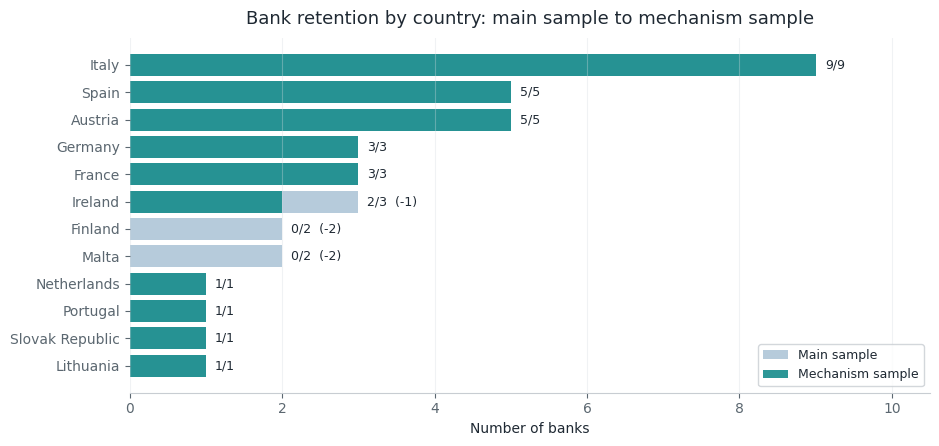

In [14]:
# Banks by country: main vs mechanism sample, display only

def country_bank_counts(d, label):
    return (d[[COUNTRY_COL, BANK_COL]]
            .dropna().drop_duplicates()
            .groupby(COUNTRY_COL)[BANK_COL].nunique()
            .rename(label))

counts = pd.concat([
    country_bank_counts(df_main, "Main"),
    country_bank_counts(df_mech, "Mechanism")
], axis=1).fillna(0).astype(int)

counts["Lost"] = counts["Main"] - counts["Mechanism"]
counts["Retention %"] = np.where(counts["Main"] > 0, 100 * counts["Mechanism"] / counts["Main"], np.nan)
counts = counts.sort_values("Main", ascending=True)

show_df(counts.sort_values("Main", ascending=False).reset_index())

fig, ax = plt.subplots(figsize=(9.5, max(4.5, 0.38 * len(counts))))
fig.patch.set_facecolor(WP_FIG_BG)
ax.set_facecolor(WP_AX_BG)

y = np.arange(len(counts))

# Main sample = full base bar
ax.barh(y, counts["Main"], color=WP_BLUE, alpha=0.35, label="Main sample")

# Mechanism sample = retained overlay
ax.barh(y, counts["Mechanism"], color=WP_TEAL, alpha=0.90, label="Mechanism sample")

for i, (main, mech, lost) in enumerate(zip(counts["Main"], counts["Mechanism"], counts["Lost"])):
    label = f"{mech}/{main}"
    if lost > 0:
        label += f"  (-{lost})"
    ax.text(main + 0.12, i, label, va="center", fontsize=9, color=WP_TEXT)

ax.set_yticks(y)
ax.set_yticklabels(counts.index)
ax.set_xlabel("Number of banks")
ax.set_title("Bank retention by country: main sample to mechanism sample", fontsize=13, pad=10)
ax.set_xlim(0, counts["Main"].max() + 1.5)
ax.grid(axis="x", color=WP_GRID, alpha=0.35)

for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)

ax.legend(loc="lower right", frameon=True, facecolor=WP_AX_BG, edgecolor=WP_BORDER)
plt.tight_layout()
plt.show()


## B.7 Figure — Final sample-window coverage diagnostic

Visual check of bank coverage and the selected 2011-04 starting point.


Stable ≥25 coverage starts: 2011-01
Final sample starts: 2011-04


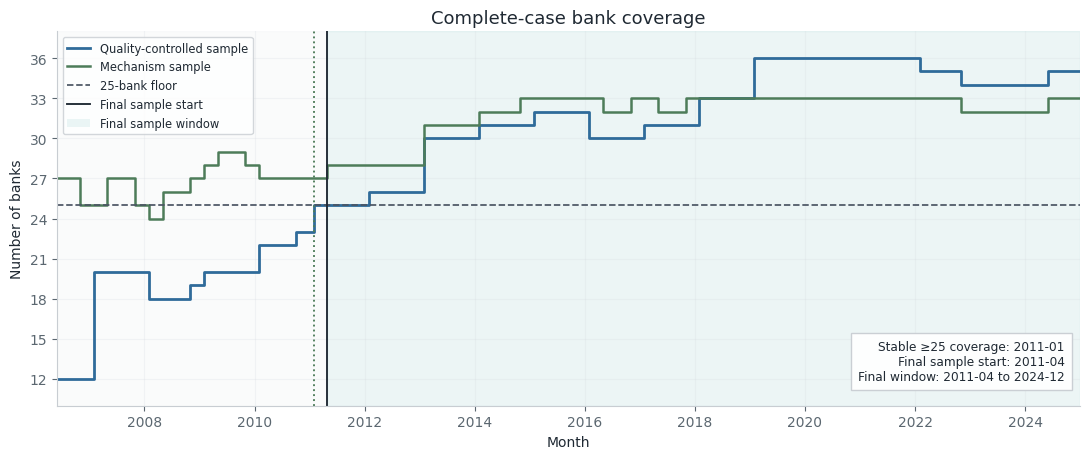

In [15]:
# %%
# ============================================================
# FIGURE — CLEAN COVERAGE DIAGNOSTIC
# ============================================================

from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

threshold = 25
coverage_start = pd.Timestamp("2006-05-31")
coverage_end = pd.Timestamp("2024-12-31")
chosen_start = pd.Timestamp("2011-04-30")

d = df_all.copy()
d[DATE_COL] = pd.to_datetime(d[DATE_COL], errors="coerce").dt.to_period("M").dt.to_timestamp("M")
d[MONTH_COL] = d[DATE_COL]
d = d[d[DATE_COL].between(coverage_start, coverage_end)].copy()

# Core interactions
d["steepening"] = as_numeric(d["delta_slope"]).clip(lower=0)
d["flattening"] = as_numeric(d["delta_slope"]).clip(upper=0)

if "high_custdep" not in d.columns:
    d["high_custdep"] = bank_pooled_high_dummy(d, "custdep_ratio_reg", BANK_COL)

for shock in ["steepening", "flattening", "delta_short", "delta_sovspread", "delta_stress"]:
    if shock in d.columns:
        d[f"{shock}_x_high_custdep"] = as_numeric(d[shock]) * as_numeric(d["high_custdep"])

# Mechanism interactions
demand_col = find_first(d, ["demand_dep_share_py", "demand_dep_share_reg", "demand_dep_share", "WC15179", "wc15179"])
time_col = find_first(d, ["savings_dep_share_py", "savings_dep_share_reg", "savings_dep_share", "time_dep_share", "time_savings_dep_share"])

if demand_col:
    d["high_demand_dep_share"] = bank_pooled_high_dummy(d, demand_col, BANK_COL)
    d["steepening_x_high_demand_dep_share"] = d["steepening"] * d["high_demand_dep_share"]
    d["flattening_x_high_demand_dep_share"] = d["flattening"] * d["high_demand_dep_share"]

if time_col:
    d["high_time_savings_dep_share"] = bank_pooled_high_dummy(d, time_col, BANK_COL)
    d["steepening_x_high_time_savings_dep_share"] = d["steepening"] * d["high_time_savings_dep_share"]
    d["flattening_x_high_time_savings_dep_share"] = d["flattening"] * d["high_time_savings_dep_share"]

samples = {
    "Quality-controlled sample": [
        DEPENDENT_VAR, "steepening_x_high_custdep", "flattening_x_high_custdep",
        "delta_short_x_high_custdep", "delta_sovspread_x_high_custdep", "delta_stress_x_high_custdep",
        "roaa_reg", "credit_risk_reg", "tier1_ratio_reg", "size_reg",
    ],
    "Mechanism sample": [
        DEPENDENT_VAR,
        "steepening_x_high_demand_dep_share", "steepening_x_high_time_savings_dep_share",
        "flattening_x_high_demand_dep_share", "flattening_x_high_time_savings_dep_share",
        "tier1_ratio_reg", "size_reg",
    ],
}

months = pd.period_range(coverage_start, coverage_end, freq="M").to_timestamp("M")
counts = pd.DataFrame({MONTH_COL: months})

for name, vars_ in samples.items():
    vars_ = [v for v in vars_ if v in d.columns]
    counts[name] = (
        d.loc[complete_case_mask(d, [BANK_COL, MONTH_COL, *vars_]), [MONTH_COL, BANK_COL]]
        .drop_duplicates()
        .groupby(MONTH_COL)[BANK_COL]
        .nunique()
        .reindex(months, fill_value=0)
        .values
    )

future_min = counts["Quality-controlled sample"][::-1].cummin()[::-1]
stable_start = counts.loc[future_min >= threshold, MONTH_COL].iloc[0]

# -----------------------------
# Plot
# -----------------------------

fig, ax = plt.subplots(figsize=(11, 4.7))
fig.patch.set_facecolor(WP_FIG_BG)
ax.set_facecolor(WP_AX_BG)

# Background
ax.axvspan(coverage_start, chosen_start, color=WP_GRID, alpha=0.10)
ax.axvspan(chosen_start, coverage_end, color=WP_TEAL, alpha=0.08)

# Coverage lines
ax.step(
    counts[MONTH_COL],
    counts["Quality-controlled sample"],
    where="post",
    color=WP_BLUE,
    lw=2.0,
)

ax.step(
    counts[MONTH_COL],
    counts["Mechanism sample"],
    where="post",
    color=WP_GREEN,
    lw=1.8,
)

# Threshold and dates
ax.axhline(threshold, color=WP_SLATE, ls="--", lw=1.25)
ax.axvline(stable_start, color=WP_GREEN, ls=":", lw=1.35)
ax.axvline(chosen_start, color=WP_TEXT, lw=1.35)

# Single consolidated info box
info = (
    f"Stable ≥25 coverage: {stable_start:%Y-%m}\n"
    f"Final sample start: {chosen_start:%Y-%m}\n"
    f"Final window: {chosen_start:%Y-%m} to {coverage_end:%Y-%m}"
)

ax.text(
    0.985,
    0.06,
    info,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8.7,
    color=WP_TEXT,
    bbox=dict(facecolor=WP_AX_BG, edgecolor=WP_BORDER, alpha=0.95, pad=5),
)

# Legend
legend_items = [
    Line2D([0], [0], color=WP_BLUE, lw=2.0, label="Quality-controlled sample"),
    Line2D([0], [0], color=WP_GREEN, lw=1.8, label="Mechanism sample"),
    Line2D([0], [0], color=WP_SLATE, lw=1.25, ls="--", label="25-bank floor"),
    Line2D([0], [0], color=WP_TEXT, lw=1.35, label="Final sample start"),
    Patch(facecolor=WP_TEAL, alpha=0.08, label="Final sample window"),
]

ax.legend(
    handles=legend_items,
    loc="upper left",
    frameon=True,
    facecolor=WP_AX_BG,
    edgecolor=WP_BORDER,
    fontsize=8.3,
)

ax.set(
    title="Complete-case bank coverage",
    xlabel="Month",
    ylabel="Number of banks",
    xlim=(coverage_start, coverage_end),
    ylim=(max(0, counts[["Quality-controlled sample", "Mechanism sample"]].min().min() - 2),
          counts[["Quality-controlled sample", "Mechanism sample"]].max().max() + 2),
)

ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, color=WP_GRID, alpha=0.26)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(
    OUT_DIR / "04x_figure_clean_complete_case_coverage.png",
    dpi=220,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

print(f"Stable ≥{threshold} coverage starts: {stable_start:%Y-%m}")
print(f"Final sample starts: {chosen_start:%Y-%m}")


## B.8 Table — Sample-definition coverage diagnostic

Checks which complete-case sample definitions support the 2011-04 thesis start date.


In [16]:
# %%
# ============================================================
# DIAGNOSTIC — WHICH SAMPLE DEFINITION JUSTIFIES 2011-04?
# ============================================================

threshold = 25
coverage_start = pd.Timestamp("2004-01-31")
coverage_end = pd.Timestamp("2024-12-31")

d = df_all.copy()
d[DATE_COL] = pd.to_datetime(d[DATE_COL], errors="coerce").dt.to_period("M").dt.to_timestamp("M")
d[MONTH_COL] = d[DATE_COL]
d = d[d[DATE_COL].between(coverage_start, coverage_end)].copy()

# Recreate ASYM variables if needed
if "delta_slope" in d.columns:
    d["delta_slope"] = as_numeric(d["delta_slope"])
    d["steepening"] = d["delta_slope"].clip(lower=0)
    d["flattening"] = d["delta_slope"].clip(upper=0)

if "high_custdep" not in d.columns and "custdep_ratio_reg" in d.columns:
    d["high_custdep"] = bank_pooled_high_dummy(d, "custdep_ratio_reg", BANK_COL)

for shock in ["steepening", "flattening", "delta_short", "delta_sovspread", "delta_stress"]:
    if shock in d.columns and "high_custdep" in d.columns:
        d[f"{shock}_x_high_custdep"] = as_numeric(d[shock]) * as_numeric(d["high_custdep"])

sample_blocks = {
    "Base ASYM": [
        DEPENDENT_VAR,
        "steepening_x_high_custdep",
        "flattening_x_high_custdep",
        "tier1_ratio_reg",
        "size_reg",
    ],
    "ASYM + rate + sovereign": [
        DEPENDENT_VAR,
        "steepening_x_high_custdep",
        "flattening_x_high_custdep",
        "delta_short_x_high_custdep",
        "delta_sovspread_x_high_custdep",
        "tier1_ratio_reg",
        "size_reg",
    ],
    "Full macro / stress": [
        DEPENDENT_VAR,
        "steepening_x_high_custdep",
        "flattening_x_high_custdep",
        "delta_short_x_high_custdep",
        "delta_sovspread_x_high_custdep",
        "delta_stress_x_high_custdep",
        "tier1_ratio_reg",
        "size_reg",
    ],
    "Quality-controlled main sample": [
        DEPENDENT_VAR,
        "steepening_x_high_custdep",
        "flattening_x_high_custdep",
        "delta_short_x_high_custdep",
        "delta_sovspread_x_high_custdep",
        "delta_stress_x_high_custdep",
        "roaa_reg",
        "credit_risk_reg",
        "tier1_ratio_reg",
        "size_reg",
    ],
}

rows = []

for block, vars_ in sample_blocks.items():
    vars_ = [v for v in vars_ if v in d.columns]
    
    complete = d.loc[
        complete_case_mask(d, [BANK_COL, MONTH_COL, *vars_]),
        [MONTH_COL, BANK_COL]
    ].drop_duplicates()

    counts = (
        complete
        .groupby(MONTH_COL)[BANK_COL]
        .nunique()
        .reindex(pd.period_range(coverage_start, coverage_end, freq="M").to_timestamp("M"), fill_value=0)
        .rename("banks")
        .reset_index()
        .rename(columns={"index": MONTH_COL})
    )

    counts["future_min"] = counts["banks"][::-1].cummin()[::-1]
    stable = counts[counts["future_min"] >= threshold]

    rows.append({
        "sample_block": block,
        "variables_used": ", ".join(vars_),
        "first_month_ever_25": counts.loc[counts["banks"] >= threshold, MONTH_COL].min(),
        "first_month_stays_25": stable[MONTH_COL].min() if not stable.empty else pd.NaT,
        "banks_at_2011_04": int(counts.loc[counts[MONTH_COL].eq(pd.Timestamp("2011-04-30")), "banks"].iloc[0])
            if counts[MONTH_COL].eq(pd.Timestamp("2011-04-30")).any() else np.nan,
        "min_after_2011_04": int(counts.loc[counts[MONTH_COL] >= pd.Timestamp("2011-04-30"), "banks"].min()),
    })

diagnostic = pd.DataFrame(rows)

for c in ["first_month_ever_25", "first_month_stays_25"]:
    diagnostic[c] = pd.to_datetime(diagnostic[c], errors="coerce").dt.strftime("%Y-%m")

show_df(diagnostic)


,sample_block,variables_used,first_month_ever_25,first_month_stays_25,banks_at_2011_04,min_after_2011_04
0,Base ASYM,"r_excess, steepening_x_high_custdep, flattenin...",2009-01,2009-01,26,26
1,ASYM + rate + sovereign,"r_excess, steepening_x_high_custdep, flattenin...",2009-01,2009-01,26,26
2,Full macro / stress,"r_excess, steepening_x_high_custdep, flattenin...",2009-01,2009-01,26,26
3,Quality-controlled main sample,"r_excess, steepening_x_high_custdep, flattenin...",2011-01,2011-01,25,25


## B.9 Figure — Deposit amount share by country

Country-level deposit-weight diagnostic for the main sample.


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\04d_deposit_amount_share_by_country_df_main.csv


,country,deposit_amount,deposit_share,deposit_share_pct
2,France,5.482499e+08,0.357561,35.756082
11,Spain,2.905749e+08,0.189509,18.950883
5,Italy,2.698110e+08,0.175967,17.596691
3,Germany,1.521927e+08,0.099258,9.925792
1,Finland,1.172016e+08,0.076437,7.643725
8,Netherlands,9.621508e+07,0.062750,6.275011
0,Austria,3.696730e+07,0.024110,2.410955
4,Ireland,1.526676e+07,0.009957,0.995677
9,Portugal,4.795150e+06,0.003127,0.312733
10,Slovak Republic,1.737673e+06,0.001133,0.113329


Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\04d_figure_deposit_amount_share_by_country_df_main.png


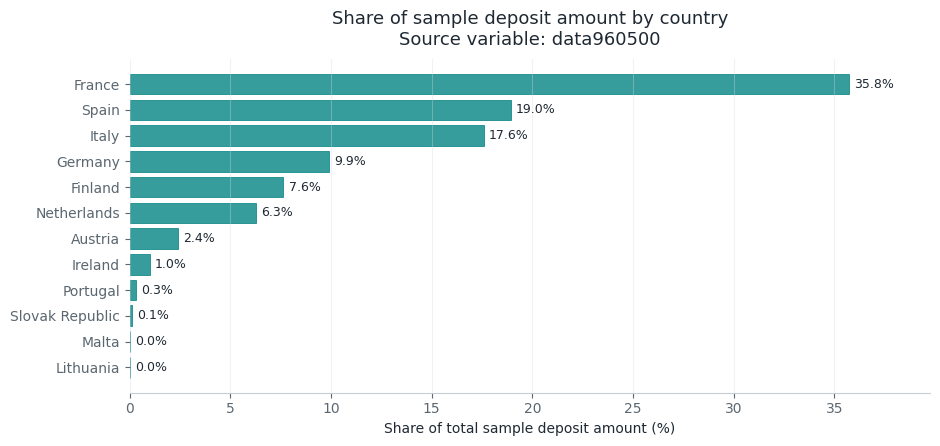

In [17]:
# ============================================================
# 8B. FIGURE — DEPOSIT AMOUNT SHARE BY COUNTRY, MAIN SAMPLE
# ============================================================

deposit_amount_col = find_first(df_main, [
    "data960500",              # total deposits, if available
    "data960300",              # customer deposits
    "customer_deposits",
    "total_customer_deposits",
    "cust_deposits",
    "deposits_total",
    "total_deposits",
])

if COUNTRY_COL is None or COUNTRY_COL not in df_main.columns or df_main.empty:
    warn_msg("Country column unavailable or df_main empty; deposit-share figure skipped.")

elif deposit_amount_col is None:
    warn_msg("No deposit amount column found; deposit-share figure skipped.")

else:
    bank_country_deposits = (
        df_main[[COUNTRY_COL, BANK_COL, deposit_amount_col]]
        .assign(deposit_amount=lambda x: as_numeric(x[deposit_amount_col]))
        .dropna(subset=[COUNTRY_COL, BANK_COL, "deposit_amount"])
        .groupby([COUNTRY_COL, BANK_COL], as_index=False)["deposit_amount"]
        .mean()
    )

    deposits_by_country = (
        bank_country_deposits
        .groupby(COUNTRY_COL, as_index=False)["deposit_amount"]
        .sum()
        .assign(
            deposit_share=lambda x: x["deposit_amount"] / x["deposit_amount"].sum(),
            deposit_share_pct=lambda x: 100 * x["deposit_share"],
        )
        .sort_values("deposit_share_pct", ascending=True)
    )

    save_table(
        deposits_by_country.sort_values("deposit_share_pct", ascending=False),
        "04d_deposit_amount_share_by_country_df_main.csv",
        display_table=True,
    )

    fig, ax = plt.subplots(figsize=(9.5, max(4.5, 0.38 * len(deposits_by_country))))
    fig.patch.set_facecolor(WP_FIG_BG)
    ax.set_facecolor(WP_AX_BG)

    ax.barh(
        deposits_by_country[COUNTRY_COL],
        deposits_by_country["deposit_share_pct"],
        color=WP_TEAL,
        alpha=0.86,
        edgecolor=WP_TEAL,
        linewidth=0.7,
    )

    for i, v in enumerate(deposits_by_country["deposit_share_pct"]):
        ax.text(
            v + 0.25,
            i,
            f"{v:.1f}%",
            va="center",
            ha="left",
            fontsize=9,
            color=WP_TEXT,
        )

    ax.set_title(
        f"Share of sample deposit amount by country\nSource variable: {deposit_amount_col}",
        fontsize=13,
        pad=10,
    )
    ax.set_xlabel("Share of total sample deposit amount (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, deposits_by_country["deposit_share_pct"].max() + 4)
    ax.grid(True, axis="x", color=WP_GRID, alpha=0.35)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    fig.tight_layout()

    fig_path = OUT_DIR / "04d_figure_deposit_amount_share_by_country_df_main.png"
    fig.savefig(fig_path, dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"Saved figure: {fig_path.resolve()}")


## B.10 Figure — Bank coverage over time

Small-multiple coverage figure for the key regression samples.


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\04e_bank_counts_over_time_key_regression_samples.csv
Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\04f_bank_coverage_summary_key_regression_samples.csv


,sample,min_banks,median_banks,max_banks,first_month,last_month
1,Loan-share sample,25,33.0,36,2011-04,2024-12
2,Main quality sample,25,33.0,36,2011-04,2024-12
0,Common mechanism bridge,18,21.0,25,2011-04,2024-12
3,Mechanism sample,18,21.0,25,2011-04,2024-12


Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\04e_figure_bank_coverage_over_time_small_multiples.png


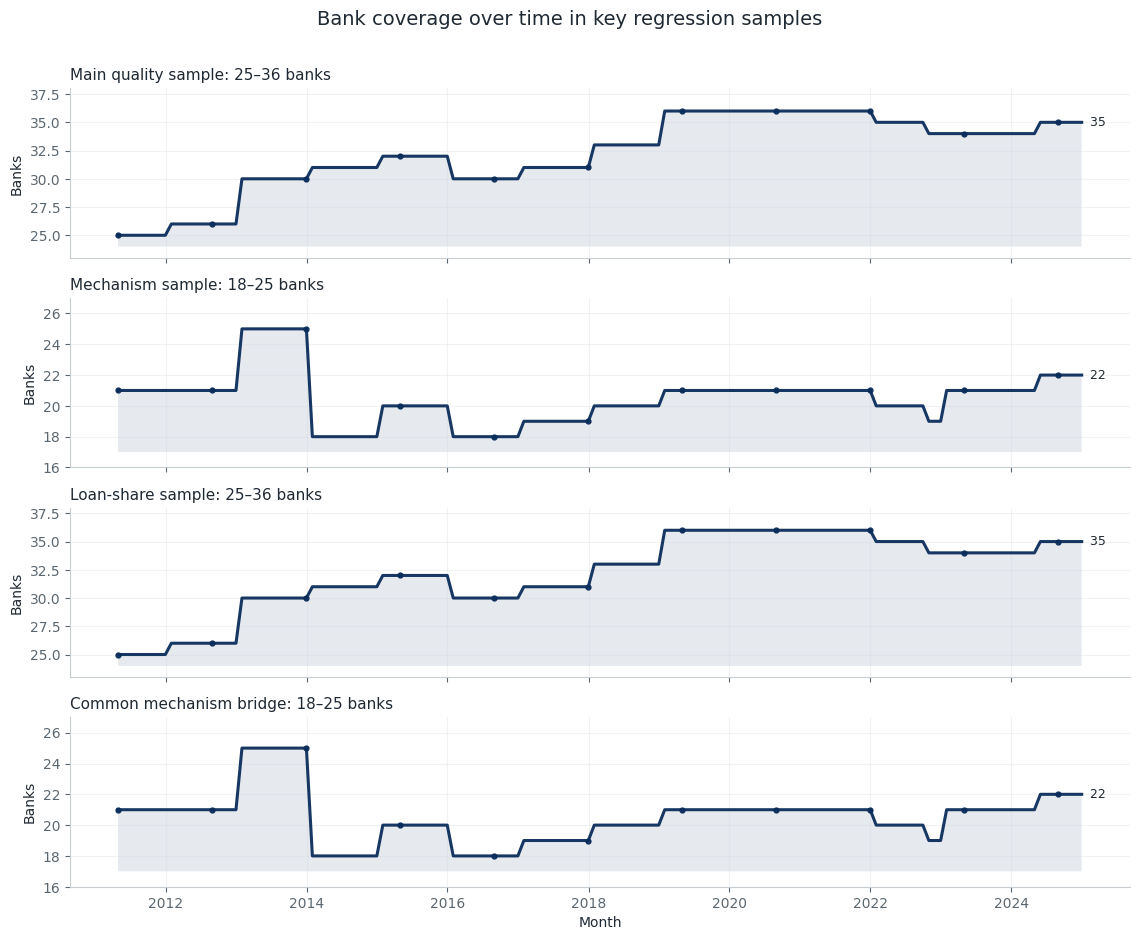

In [18]:
# ============================================================
# B.6 FIGURE — BANK COVERAGE OVER TIME BY KEY REGRESSION SAMPLE
# ============================================================

BANK_COUNT_SAMPLES = {
    "Main quality sample": df_main,
    "Mechanism sample": df_mech,
    "Loan-share sample": df_loan,
    "Common mechanism bridge": df_common,
}

bank_count_rows = []

for sample_name, data in BANK_COUNT_SAMPLES.items():
    if data is None or data.empty:
        continue

    tmp = (
        data
        .dropna(subset=[BANK_COL, MONTH_COL])
        .groupby(MONTH_COL)[BANK_COL]
        .nunique()
        .reset_index(name="banks")
        .assign(sample=sample_name)
    )

    bank_count_rows.append(tmp)

if bank_count_rows:

    bank_counts_over_time = pd.concat(bank_count_rows, ignore_index=True)
    bank_counts_over_time[MONTH_COL] = pd.to_datetime(bank_counts_over_time[MONTH_COL])

    bank_counts_export = (
        bank_counts_over_time
        .assign(month=lambda x: x[MONTH_COL].dt.strftime("%Y-%m"))
        [["sample", "month", "banks"]]
    )

    save_table(
        bank_counts_export,
        "04e_bank_counts_over_time_key_regression_samples.csv",
        display_table=False,
    )

    coverage_summary = (
        bank_counts_over_time
        .groupby("sample")["banks"]
        .agg(
            min_banks="min",
            median_banks="median",
            max_banks="max",
            first_month=lambda x: bank_counts_over_time.loc[x.index, MONTH_COL].min().strftime("%Y-%m"),
            last_month=lambda x: bank_counts_over_time.loc[x.index, MONTH_COL].max().strftime("%Y-%m"),
        )
        .reset_index()
        .sort_values("max_banks", ascending=False)
    )

    save_table(
        coverage_summary,
        "04f_bank_coverage_summary_key_regression_samples.csv",
        display_table=True,
    )

    samples = list(BANK_COUNT_SAMPLES.keys())
    samples = [s for s in samples if s in bank_counts_over_time["sample"].unique()]

    fig, axes = plt.subplots(
        nrows=len(samples),
        ncols=1,
        figsize=(11.5, 2.35 * len(samples)),
        sharex=True,
    )

    if len(samples) == 1:
        axes = [axes]

    fig.patch.set_facecolor(WP_FIG_BG)

    for ax, sample_name in zip(axes, samples):
        d = (
            bank_counts_over_time
            .loc[lambda x: x["sample"].eq(sample_name)]
            .sort_values(MONTH_COL)
            .copy()
        )

        ax.set_facecolor(WP_AX_BG)

        ax.plot(
            d[MONTH_COL],
            d["banks"],
            linewidth=2.2,
            marker="o",
            markersize=3.5,
            markevery=max(1, len(d) // 10),
            alpha=0.95,
        )

        ax.fill_between(
            d[MONTH_COL],
            d["banks"],
            d["banks"].min() - 1,
            alpha=0.10,
        )

        ax.set_title(
            f"{sample_name}: {int(d['banks'].min())}–{int(d['banks'].max())} banks",
            loc="left",
            fontsize=11,
            pad=6,
        )

        ax.set_ylabel("Banks")
        ax.grid(True, color=WP_GRID, alpha=0.35)

        ax.set_ylim(
            max(0, d["banks"].min() - 2),
            d["banks"].max() + 2,
        )

        ax.text(
            d[MONTH_COL].max(),
            d["banks"].iloc[-1],
            f"  {int(d['banks'].iloc[-1])}",
            va="center",
            ha="left",
            fontsize=9,
        )

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    axes[-1].set_xlabel("Month")

    fig.suptitle(
        "Bank coverage over time in key regression samples",
        fontsize=14,
        y=0.995,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.985])

    fig_path = OUT_DIR / "04e_figure_bank_coverage_over_time_small_multiples.png"
    fig.savefig(fig_path, dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"Saved figure: {fig_path.resolve()}")

else:
    warn_msg("Bank-count-over-time figure skipped because all key regression samples are empty.")


## B.11 Figure — Bank-level deposit composition

Bank-level Demand/Sight versus Time/Savings composition, paired with each bank's sample deposit weight.


Deposit-composition sample used: df_mech
Rows before cleaning: 3,386
Demand/Sight column used: demand_dep_share_py
Time/Savings column used: savings_dep_share_py
Bank-name column used: bank_name
Deposit amount column used: data960500
Saved audit table: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\deposit_composition_diagnostics\bank_deposit_composition_audit.csv


C:\Users\rijul\AppData\Local\Temp\ipykernel_4556\2788395784.py:466: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.02, 0.075, 1, 0.94])


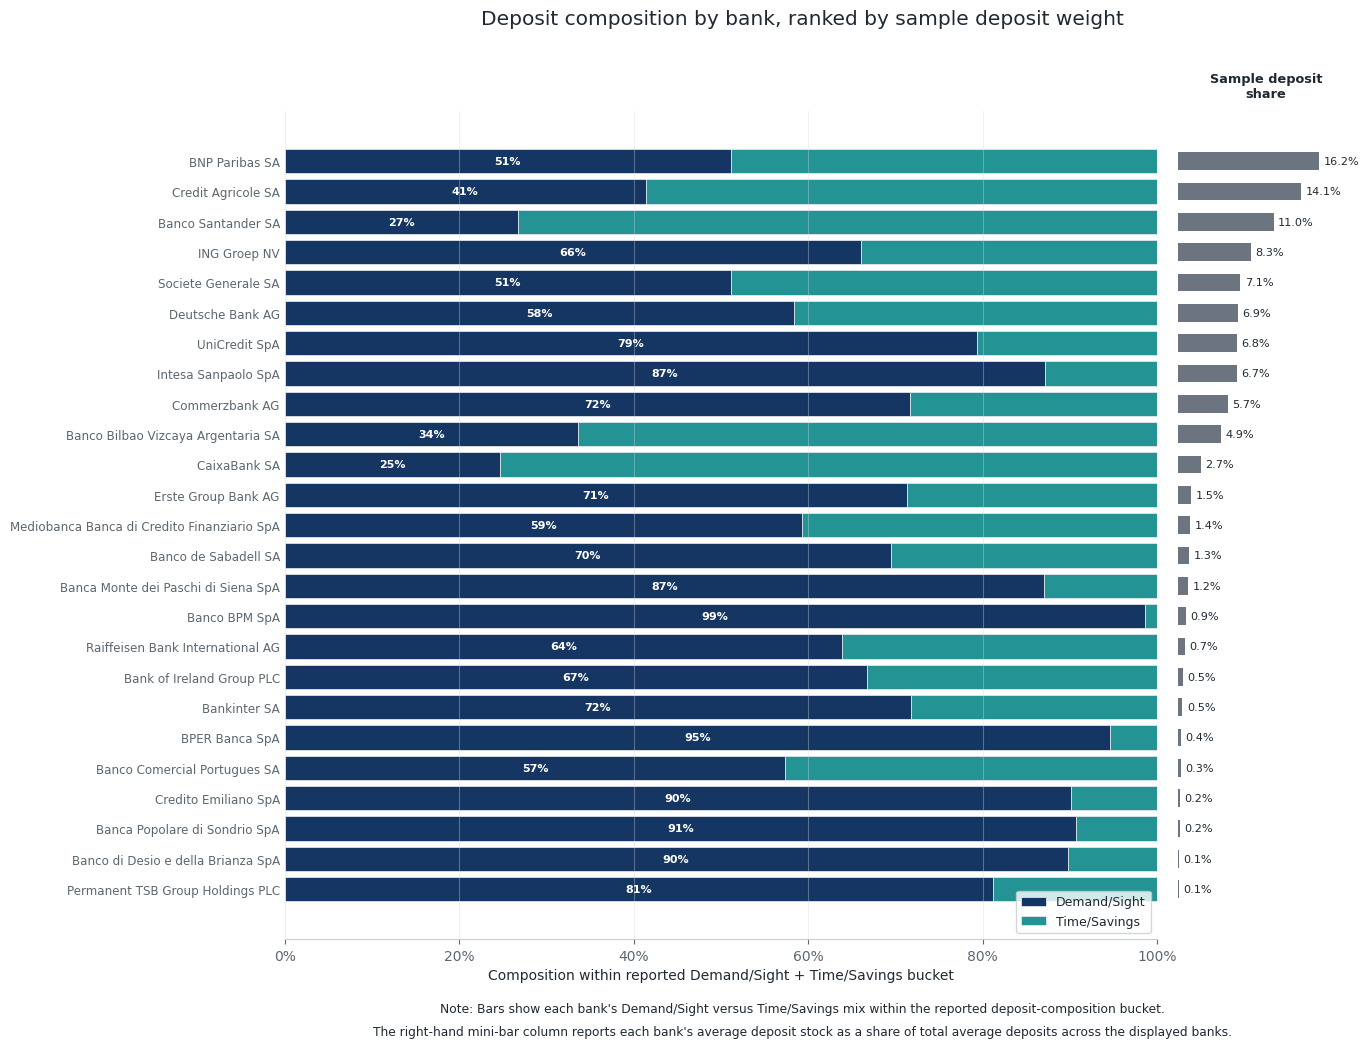

Saved clean deposit-composition figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\deposit_composition_diagnostics\deposit_composition_clean_with_weight_column.png
Banks plotted: 25


In [19]:
# ============================================================
# B.11 FIGURE — BANK-LEVEL DEPOSIT COMPOSITION
# Left = Demand/Sight vs Time/Savings split
# Right = sample deposit share
# Self-contained version: builds all required objects inside the block.
# ============================================================

from pathlib import Path
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PLOT_TOP_N = 25  # Set to None to show all banks

# ------------------------------------------------------------
# 0. Output folder
# ------------------------------------------------------------

OUT_DIR_DEPCOMP = OUT_DIR / "deposit_composition_diagnostics"
OUT_DIR_DEPCOMP.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Safe local helpers
# ------------------------------------------------------------

def depcomp_safe_num(x):
    if "as_numeric" in globals():
        return as_numeric(x)
    return pd.to_numeric(x, errors="coerce").replace([np.inf, -np.inf], np.nan)


def depcomp_find_first(data, candidates):
    if "find_first" in globals():
        return find_first(data, candidates)

    lower_map = {str(c).lower(): c for c in data.columns}
    for cand in candidates:
        if cand is None:
            continue
        if cand in data.columns:
            return cand
        key = str(cand).lower()
        if key in lower_map:
            return lower_map[key]
    return None


# ------------------------------------------------------------
# 2. Choose source dataframe
# ------------------------------------------------------------

if "df_mech" in globals() and isinstance(df_mech, pd.DataFrame) and not df_mech.empty:
    d_comp = df_mech.copy()
    DEPCOMP_SAMPLE_USED = "df_mech"
elif "df_main" in globals() and isinstance(df_main, pd.DataFrame) and not df_main.empty:
    d_comp = df_main.copy()
    DEPCOMP_SAMPLE_USED = "df_main"
elif "df_reg_full" in globals() and isinstance(df_reg_full, pd.DataFrame) and not df_reg_full.empty:
    d_comp = df_reg_full.copy()
    DEPCOMP_SAMPLE_USED = "df_reg_full"
else:
    raise ValueError("No usable dataframe found. Run this after df_mech, df_main, or df_reg_full is created.")

print(f"Deposit-composition sample used: {DEPCOMP_SAMPLE_USED}")
print(f"Rows before cleaning: {len(d_comp):,}")

# ------------------------------------------------------------
# 3. Detect Demand/Sight and Time/Savings columns
# ------------------------------------------------------------

DEMAND_SHARE_COL = globals().get("demand_base", None)

if DEMAND_SHARE_COL is None or DEMAND_SHARE_COL not in d_comp.columns:
    DEMAND_SHARE_COL = depcomp_find_first(d_comp, [
        "demand_dep_share_py",
        "demand_dep_share_reg",
        "demand_dep_share",
        "sight_dep_share_reg",
        "sight_dep_share",
        "sight_dep_ratio_reg",
        "sight_dep_ratio",
        "non_maturity_dep_share_reg",
        "non_maturity_dep_share",
        "transaction_dep_share_reg",
        "transaction_dep_share",
        "WC15179",
        "wc15179",
    ])

SAVINGS_SHARE_COL = globals().get("time_base", None)

if SAVINGS_SHARE_COL is None or SAVINGS_SHARE_COL not in d_comp.columns:
    SAVINGS_SHARE_COL = depcomp_find_first(d_comp, [
        "savings_dep_share_py",
        "savings_dep_share_reg",
        "savings_dep_share",
        "time_dep_share_reg",
        "time_dep_share",
        "time_savings_dep_share_reg",
        "time_savings_dep_share",
        "term_dep_share_reg",
        "term_dep_share",
        "fixed_term_dep_share_reg",
        "fixed_term_dep_share",
        "WC15184",
        "wc15184",
    ])

if DEMAND_SHARE_COL is None:
    raise KeyError(
        "No Demand/Sight deposit-composition column found. "
        "Check demand_base or columns like demand_dep_share_py / WC15179."
    )

if SAVINGS_SHARE_COL is None:
    raise KeyError(
        "No Time/Savings deposit-composition column found. "
        "Check time_base or columns like savings_dep_share_py / WC15184."
    )

print(f"Demand/Sight column used: {DEMAND_SHARE_COL}")
print(f"Time/Savings column used: {SAVINGS_SHARE_COL}")

# ------------------------------------------------------------
# 4. Detect bank-name and deposit-amount columns
# ------------------------------------------------------------

bank_name_col = depcomp_find_first(d_comp, [
    "bank_name",
    "name",
    "company_name",
    "bank",
    "Bank",
])

DEPOSIT_AMOUNT_COL = depcomp_find_first(d_comp, [
    "data960500",              # total deposits, if available
    "data960300",              # customer deposits
    "customer_deposits",
    "total_customer_deposits",
    "cust_deposits",
    "deposits_total",
    "total_deposits",
    "deposit_amount",
    "total_deposits_reg",
    "custdep_amount_reg",
])

if DEPOSIT_AMOUNT_COL is None:
    raise KeyError(
        "No deposit amount column found. The figure needs a deposit stock variable "
        "to compute the right-hand sample deposit-share column."
    )

print(f"Bank-name column used: {bank_name_col if bank_name_col is not None else BANK_COL}")
print(f"Deposit amount column used: {DEPOSIT_AMOUNT_COL}")

# ------------------------------------------------------------
# 5. Clean composition inputs
# ------------------------------------------------------------

d_comp["demand_raw"] = depcomp_safe_num(d_comp[DEMAND_SHARE_COL])
d_comp["savings_raw"] = depcomp_safe_num(d_comp[SAVINGS_SHARE_COL])

# Convert percentage-style shares to decimals if needed.
# Example: 42 becomes 0.42, while 0.42 stays 0.42.
for col in ["demand_raw", "savings_raw"]:
    med_abs = d_comp[col].abs().median(skipna=True)
    if pd.notna(med_abs) and med_abs > 1.5:
        d_comp[col] = d_comp[col] / 100.0

# Remove impossible or uninformative values.
d_comp.loc[d_comp["demand_raw"] < 0, "demand_raw"] = np.nan
d_comp.loc[d_comp["savings_raw"] < 0, "savings_raw"] = np.nan

d_comp["reported_bucket_sum"] = d_comp["demand_raw"] + d_comp["savings_raw"]
d_comp.loc[d_comp["reported_bucket_sum"] <= 0, "reported_bucket_sum"] = np.nan

# Composition within the reported Demand/Sight + Time/Savings bucket.
d_comp["demand_share_of_reported_bucket"] = d_comp["demand_raw"] / d_comp["reported_bucket_sum"]
d_comp["savings_share_of_reported_bucket"] = d_comp["savings_raw"] / d_comp["reported_bucket_sum"]

# Deposit amount for economic-weight column.
d_comp["deposit_amount"] = depcomp_safe_num(d_comp[DEPOSIT_AMOUNT_COL])
d_comp.loc[d_comp["deposit_amount"] <= 0, "deposit_amount"] = np.nan

# ------------------------------------------------------------
# 6. Build bank-level summary
# ------------------------------------------------------------

agg_dict = {
    "demand_share_of_reported_bucket_mean": (
        "demand_share_of_reported_bucket",
        "mean",
    ),
    "savings_share_of_reported_bucket_mean": (
        "savings_share_of_reported_bucket",
        "mean",
    ),
    "deposit_composition_obs": (
        "demand_share_of_reported_bucket",
        "count",
    ),
    "deposit_amount_mean": (
        "deposit_amount",
        "mean",
    ),
    "deposit_amount_obs": (
        "deposit_amount",
        "count",
    ),
}

if bank_name_col is not None and bank_name_col in d_comp.columns:
    agg_dict[bank_name_col] = (bank_name_col, "first")

bank_deposit_composition = (
    d_comp
    .dropna(subset=[
        BANK_COL,
        "demand_share_of_reported_bucket",
        "savings_share_of_reported_bucket",
    ])
    .groupby(BANK_COL, as_index=False)
    .agg(**agg_dict)
)

if bank_deposit_composition.empty:
    raise ValueError(
        "bank_deposit_composition is empty after cleaning. "
        "Check whether Demand/Sight and Time/Savings columns contain valid non-missing values."
    )

total_sample_deposits = bank_deposit_composition["deposit_amount_mean"].sum(skipna=True)

if pd.isna(total_sample_deposits) or total_sample_deposits <= 0:
    raise ValueError(
        "Total sample deposits are missing or non-positive. "
        "Check the deposit amount column used for weighting."
    )

bank_deposit_composition["sample_deposit_share_pct"] = (
    100
    * bank_deposit_composition["deposit_amount_mean"]
    / total_sample_deposits
)

# Save audit table
audit_path = OUT_DIR_DEPCOMP / "bank_deposit_composition_audit.csv"
bank_deposit_composition.to_csv(audit_path, index=False)
print(f"Saved audit table: {audit_path.resolve()}")

# ------------------------------------------------------------
# 7. Clean and sort plotting dataframe
# ------------------------------------------------------------

plot_df = bank_deposit_composition.dropna(
    subset=[
        "demand_share_of_reported_bucket_mean",
        "savings_share_of_reported_bucket_mean",
        "sample_deposit_share_pct",
    ]
).copy()

plot_df = plot_df.sort_values("sample_deposit_share_pct", ascending=False)

if PLOT_TOP_N is not None:
    plot_df = plot_df.head(PLOT_TOP_N).copy()

plot_df = plot_df.reset_index(drop=True)

if plot_df.empty:
    raise ValueError("No banks remain for plotting after applying required non-missing filters.")

label_col = bank_name_col if bank_name_col is not None and bank_name_col in plot_df.columns else BANK_COL

# Ensure plotted composition sums exactly to 1 after bank averaging.
row_sum = (
    plot_df["demand_share_of_reported_bucket_mean"]
    + plot_df["savings_share_of_reported_bucket_mean"]
)

plot_df["demand_plot_share"] = plot_df["demand_share_of_reported_bucket_mean"] / row_sum
plot_df["savings_plot_share"] = plot_df["savings_share_of_reported_bucket_mean"] / row_sum

# ------------------------------------------------------------
# 8. Theme
# ------------------------------------------------------------

BG = WP_FIG_BG if "WP_FIG_BG" in globals() else "#FFFFFF"
AX_BG = WP_AX_BG if "WP_AX_BG" in globals() else "#FFFFFF"
TEXT = WP_TEXT if "WP_TEXT" in globals() else "#1F2933"
GRID = WP_GRID if "WP_GRID" in globals() else "#D5DAE0"
BORDER = WP_BORDER if "WP_BORDER" in globals() else "#C8CDD2"

DEMAND_COLOR = WP_NAVY if "WP_NAVY" in globals() else "#0B2D5B"
SAVINGS_COLOR = WP_TEAL if "WP_TEAL" in globals() else "#168C8C"
WEIGHT_COLOR = WP_SLATE if "WP_SLATE" in globals() else "#4B5563"
EDGE = WP_EDGE if "WP_EDGE" in globals() else "#E9EDF2"

# ------------------------------------------------------------
# 9. Figure layout
# ------------------------------------------------------------

fig, (ax, ax_w) = plt.subplots(
    ncols=2,
    sharey=True,
    figsize=(13.8, max(7.0, 0.43 * len(plot_df))),
    gridspec_kw={"width_ratios": [5.2, 1.05], "wspace": 0.04},
)

fig.patch.set_facecolor(BG)

for a in [ax, ax_w]:
    a.set_facecolor(AX_BG)
    a.tick_params(axis="y", length=0)
    for spine in ["top", "right", "left"]:
        a.spines[spine].set_visible(False)

y = np.arange(len(plot_df))

# ------------------------------------------------------------
# 10. Main stacked composition bars
# ------------------------------------------------------------

ax.barh(
    y,
    plot_df["demand_plot_share"],
    label="Demand/Sight",
    color=DEMAND_COLOR,
    alpha=0.96,
    edgecolor=EDGE,
    linewidth=0.55,
)

ax.barh(
    y,
    plot_df["savings_plot_share"],
    left=plot_df["demand_plot_share"],
    label="Time/Savings",
    color=SAVINGS_COLOR,
    alpha=0.94,
    edgecolor=EDGE,
    linewidth=0.55,
)

# Demand share labels
for i, (_, row) in enumerate(plot_df.iterrows()):
    demand_pct = 100 * row["demand_plot_share"]
    x = row["demand_plot_share"]

    if x >= 0.14:
        ax.text(
            x / 2,
            i,
            f"{demand_pct:.0f}%",
            va="center",
            ha="center",
            fontsize=8.0,
            color="white",
            fontweight="bold",
        )
    else:
        ax.text(
            x + 0.015,
            i,
            f"{demand_pct:.0f}%",
            va="center",
            ha="left",
            fontsize=8.0,
            color=TEXT,
            fontweight="bold",
        )

ax.set_yticks(y)
ax.set_yticklabels(plot_df[label_col].astype(str), fontsize=8.6)

ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{100*x:.0f}%"))

ax.set_xlabel("Composition within reported Demand/Sight + Time/Savings bucket")
ax.grid(True, axis="x", color=GRID, alpha=0.36)

ax.legend(
    loc="lower right",
    frameon=True,
    facecolor=AX_BG,
    edgecolor=BORDER,
    fontsize=9,
)

# Largest bank at top
ax.invert_yaxis()

# ------------------------------------------------------------
# 11. Sample-deposit-share mini-bar column
# ------------------------------------------------------------

max_share = plot_df["sample_deposit_share_pct"].max()
xmax = max_share * 1.25 if pd.notna(max_share) and max_share > 0 else 1.0

ax_w.barh(
    y,
    plot_df["sample_deposit_share_pct"],
    color=WEIGHT_COLOR,
    alpha=0.82,
    height=0.58,
)

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax_w.text(
        row["sample_deposit_share_pct"] + xmax * 0.025,
        i,
        f"{row['sample_deposit_share_pct']:.1f}%",
        va="center",
        ha="left",
        fontsize=8.1,
        color=TEXT,
    )

ax_w.set_xlim(0, xmax)
ax_w.set_xticks([])
ax_w.set_xlabel("")
ax_w.set_title(
    "Sample deposit\nshare",
    fontsize=9.3,
    fontweight="bold",
    pad=10,
)

ax_w.grid(False)
ax_w.spines["bottom"].set_visible(False)
ax_w.tick_params(axis="y", labelleft=False)

# ------------------------------------------------------------
# 12. Title and notes
# ------------------------------------------------------------

fig.suptitle(
    "Deposit composition by bank, ranked by sample deposit weight",
    fontsize=14.5,
    y=0.975,
)

fig.text(
    0.5,
    0.045,
    "Note: Bars show each bank's Demand/Sight versus Time/Savings mix within the reported deposit-composition bucket.",
    ha="center",
    va="center",
    fontsize=8.8,
    color=TEXT,
)

fig.text(
    0.5,
    0.024,
    "The right-hand mini-bar column reports each bank's average deposit stock as a share of total average deposits across the displayed banks.",
    ha="center",
    va="center",
    fontsize=8.8,
    color=TEXT,
)

fig.tight_layout(rect=[0.02, 0.075, 1, 0.94])

fig_path = OUT_DIR_DEPCOMP / "deposit_composition_clean_with_weight_column.png"

fig.savefig(
    fig_path,
    dpi=260,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

plt.show()

print(f"Saved clean deposit-composition figure: {fig_path.resolve()}")
print(f"Banks plotted: {len(plot_df)}")

Main-sample banks      : 36
Mechanism-sample banks : 31
Dropped banks          : 5
Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\04z_dropped_banks_from_mechanism_sample_by_deposit_share.csv


,bank_id,deposit_amount_mean,deposit_obs,bank_label,country,main_sample_deposit_share_pct
0,FI4000297767,1.146523e+08,84,Nordea Bank Abp,Finland,7.477382
1,IE00BF0L3536,5.895286e+06,84,AIB Group PLC,Ireland,0.384478
2,FI4000058870,2.549356e+06,165,Aktia Bank Abp,Finland,0.166264
3,MT0000020116,1.700188e+05,117,Bank of Valletta PLC,Malta,0.011088


Total deposit share lost: 8.04%
Deposit amount source: data960500


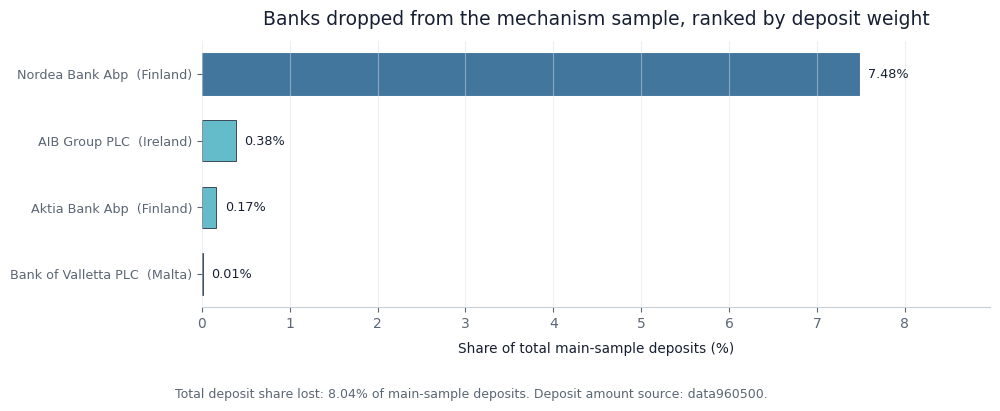

Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\deposit_composition_diagnostics\figure_dropped_banks_by_deposit_share.png


In [20]:
# ------------------------------------------------------------
# 7. Figure B — Dropped banks by deposit share
# Self-contained version: builds dropped_table first
# ------------------------------------------------------------

# ------------------------------------------------------------
# 0. Output folder
# ------------------------------------------------------------

OUT_DIR_DEPCOMP = OUT_DIR / "deposit_composition_diagnostics"
OUT_DIR_DEPCOMP.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Detect bank label, country, and deposit amount columns
# ------------------------------------------------------------

bank_name_col = find_first(df_main, [
    "bank_name",
    "name",
    "company_name",
    "bank",
    "Bank",
])

country_col = COUNTRY_COL if "COUNTRY_COL" in globals() and COUNTRY_COL in df_main.columns else find_first(df_main, [
    "country",
    "country_hq",
    "country_key",
    "sov_country",
    "reference_area",
])

deposit_amount_col = find_first(df_main, [
    "data960500",              # total deposits, if available
    "data960300",              # customer deposits
    "customer_deposits",
    "total_customer_deposits",
    "cust_deposits",
    "deposits_total",
    "total_deposits",
    "deposit_amount",
    "total_deposits_reg",
    "custdep_amount_reg",
])

if deposit_amount_col is None:
    raise KeyError(
        "No deposit amount column found. Need a deposit stock variable to compute dropped-bank deposit share."
    )

# ------------------------------------------------------------
# 2. Identify banks in main sample but missing from mechanism sample
# ------------------------------------------------------------

main_banks = set(df_main[BANK_COL].dropna().unique())
mech_banks = set(df_mech[BANK_COL].dropna().unique()) if "df_mech" in globals() and not df_mech.empty else set()

dropped_banks = sorted(main_banks - mech_banks)

print(f"Main-sample banks      : {len(main_banks)}")
print(f"Mechanism-sample banks : {len(mech_banks)}")
print(f"Dropped banks          : {len(dropped_banks)}")

# ------------------------------------------------------------
# 3. Build bank-level deposit-weight table from main sample
# ------------------------------------------------------------

cols = [BANK_COL, deposit_amount_col]
if bank_name_col is not None:
    cols.append(bank_name_col)
if country_col is not None:
    cols.append(country_col)

bank_deposit_weights = (
    df_main[cols]
    .copy()
    .assign(deposit_amount=lambda x: as_numeric(x[deposit_amount_col]))
    .dropna(subset=[BANK_COL, "deposit_amount"])
)

bank_deposit_weights = bank_deposit_weights.loc[
    bank_deposit_weights["deposit_amount"] > 0
].copy()

agg_dict = {
    "deposit_amount_mean": ("deposit_amount", "mean"),
    "deposit_obs": ("deposit_amount", "count"),
}

if bank_name_col is not None:
    agg_dict["bank_label"] = (bank_name_col, "first")
else:
    agg_dict["bank_label"] = (BANK_COL, "first")

if country_col is not None:
    agg_dict["country"] = (country_col, "first")

bank_deposit_weights = (
    bank_deposit_weights
    .groupby(BANK_COL, as_index=False)
    .agg(**agg_dict)
)

total_main_sample_deposits = bank_deposit_weights["deposit_amount_mean"].sum(skipna=True)

if pd.isna(total_main_sample_deposits) or total_main_sample_deposits <= 0:
    raise ValueError("Total main-sample deposits are missing or non-positive.")

bank_deposit_weights["main_sample_deposit_share_pct"] = (
    100 * bank_deposit_weights["deposit_amount_mean"] / total_main_sample_deposits
)

# ------------------------------------------------------------
# 4. Build dropped_table
# ------------------------------------------------------------

dropped_table = (
    bank_deposit_weights
    .loc[bank_deposit_weights[BANK_COL].isin(dropped_banks)]
    .copy()
    .sort_values("main_sample_deposit_share_pct", ascending=False)
    .reset_index(drop=True)
)

dropped_share = dropped_table["main_sample_deposit_share_pct"].sum(skipna=True)

save_table(
    dropped_table,
    "04z_dropped_banks_from_mechanism_sample_by_deposit_share.csv",
    display_table=True,
)

print(f"Total deposit share lost: {dropped_share:.2f}%")
print(f"Deposit amount source: {deposit_amount_col}")

# ------------------------------------------------------------
# 5. Plot dropped banks by deposit share
# ------------------------------------------------------------

if dropped_table.empty:
    print("No banks dropped from the mechanism sample. Dropped-bank figure skipped.")

else:
    plot_df = dropped_table.sort_values("main_sample_deposit_share_pct", ascending=True).copy()

    # Add country to label if available
    if "country" in plot_df.columns:
        plot_df["plot_label"] = (
            plot_df["bank_label"].astype(str)
            + "  ("
            + plot_df["country"].astype(str)
            + ")"
        )
    else:
        plot_df["plot_label"] = plot_df["bank_label"].astype(str)

    # -----------------------------
    # Refined colors
    # -----------------------------

    BG = "#FFFFFF"
    AX_BG = "#FFFFFF"
    TEXT = "#172033"
    MUTED = "#5B6675"
    GRID = "#D9DEE7"
    EDGE = "#2B3445"

    BAR_MAIN = "#5AB7C7"
    BAR_ACCENT = "#3F739B"

    fig, ax = plt.subplots(figsize=(10.8, max(4.5, 0.50 * len(plot_df))))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(AX_BG)

    y = np.arange(len(plot_df))

    bars = ax.barh(
        y,
        plot_df["main_sample_deposit_share_pct"],
        color=BAR_MAIN,
        alpha=0.94,
        edgecolor=EDGE,
        linewidth=0.65,
        height=0.62,
    )

    # Highlight largest dropped bank slightly
    max_idx = plot_df["main_sample_deposit_share_pct"].idxmax()

    for i, bar in enumerate(bars):
        if plot_df.index[i] == max_idx:
            bar.set_color(BAR_ACCENT)
            bar.set_alpha(0.98)

    for i, (_, row) in enumerate(plot_df.iterrows()):
        ax.text(
            row["main_sample_deposit_share_pct"] + 0.10,
            i,
            f"{row['main_sample_deposit_share_pct']:.2f}%",
            va="center",
            ha="left",
            fontsize=9.2,
            color=TEXT,
        )

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["plot_label"], fontsize=9.2, color=MUTED)

    ax.set_xlabel(
        "Share of total main-sample deposits (%)",
        fontsize=9.8,
        color=TEXT,
        labelpad=8,
    )

    ax.set_title(
        "Banks dropped from the mechanism sample, ranked by deposit weight",
        fontsize=13.5,
        color=TEXT,
        pad=12,
    )

    ax.grid(True, axis="x", color=GRID, alpha=0.48, linewidth=0.8)
    ax.grid(False, axis="y")

    xmax = plot_df["main_sample_deposit_share_pct"].max()
    ax.set_xlim(0, xmax * 1.20 if xmax > 0 else 1)

    ax.tick_params(axis="x", colors=MUTED)
    ax.tick_params(axis="y", colors=MUTED)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.spines["bottom"].set_color("#C7CED8")
    ax.spines["bottom"].set_linewidth(0.8)

    note = (
        f"Total deposit share lost: {dropped_share:.2f}% of main-sample deposits. "
        f"Deposit amount source: {deposit_amount_col}."
    )

    fig.subplots_adjust(left=0.25, right=0.98, top=0.86, bottom=0.27)

    fig.text(
        0.50,
        0.075,
        note,
        ha="center",
        va="center",
        fontsize=9.0,
        color=MUTED,
    )

    fig_path = OUT_DIR_DEPCOMP / "figure_dropped_banks_by_deposit_share.png"

    fig.savefig(
        fig_path,
        dpi=260,
        bbox_inches="tight",
        facecolor=fig.get_facecolor(),
    )

    plt.show()

    print(f"Saved figure: {fig_path.resolve()}")

## Italy as % of total demand + savings exposure across sample.

Columns used:
  Sample dataframe     : df_mech
  Bank column          : bank_id
  Country column       : country
  Demand share column  : demand_dep_share_py
  Savings share column : savings_dep_share_py
  Deposit amount source: data960300

Italy diagnostic:
  Mechanism observation share : 42.50%
  Mechanism bank share        : 29.03%
  Demand + Savings exposure   : 17.32%

Saved country diagnostic table: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\mechanism_country_contribution_diagnostic\country_mechanism_contribution_diagnostic.csv
Saved bank exposure audit table: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\mechanism_country_contribution_diagnostic\bank_mechanism_exposure_audit.csv


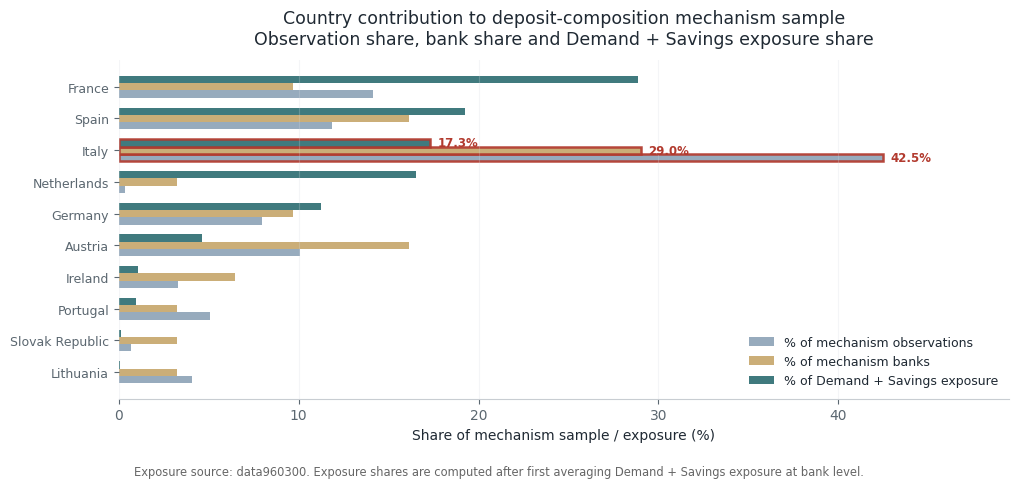

Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\mechanism_country_contribution_diagnostic\figure_country_mechanism_contribution_diagnostic.png


In [21]:
# ============================================================
# FIGURE — COUNTRY CONTRIBUTION TO MECHANISM-SAMPLE IDENTIFICATION
# Metrics:
#   1. % of mechanism observations
#   2. % of mechanism banks
#   3. % of Demand + Savings exposure
#
# Purpose:
#   Diagnostic figure for explaining why Italy can widen LOCO confidence intervals.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Output folder
# ------------------------------------------------------------

OUT_DIR_COUNTRY_DIAG = (
    OUT_DIR / "mechanism_country_contribution_diagnostic"
    if "OUT_DIR" in globals()
    else Path("mechanism_country_contribution_diagnostic")
)
OUT_DIR_COUNTRY_DIAG.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------

def _safe_num(x):
    if "as_numeric" in globals():
        return as_numeric(x)
    return pd.to_numeric(x, errors="coerce").replace([np.inf, -np.inf], np.nan)

def _find_first(data, candidates):
    if "find_first" in globals():
        return find_first(data, candidates)

    lower_map = {str(c).lower(): c for c in data.columns}
    for c in candidates:
        if c in data.columns:
            return c
        if str(c).lower() in lower_map:
            return lower_map[str(c).lower()]
    return None

def _to_decimal_share(s):
    s = _safe_num(s)
    med_abs = s.abs().median(skipna=True)

    # Convert percentages to decimals if needed.
    if pd.notna(med_abs) and med_abs > 1.5:
        s = s / 100.0

    return s

def _is_italy(x):
    s = str(x).strip().lower()
    return s in {"italy", "italia", "it", "ita"} or "italy" in s

# ------------------------------------------------------------
# 2. Select mechanism sample dataframe
# ------------------------------------------------------------

if "df_mech" in globals() and df_mech is not None and not df_mech.empty:
    d0 = df_mech.copy()
    sample_label = "df_mech"
elif "df_reg_full" in globals() and df_reg_full is not None and not df_reg_full.empty:
    d0 = df_reg_full.copy()
    sample_label = "df_reg_full filtered to mechanism variables"
elif "final_panel" in globals() and final_panel is not None and not final_panel.empty:
    d0 = final_panel.copy()
    sample_label = "final_panel filtered to mechanism variables"
else:
    raise NameError(
        "Could not find df_mech, df_reg_full, or final_panel. "
        "Run the panel-preparation cells first."
    )

# ------------------------------------------------------------
# 3. Detect key columns
# ------------------------------------------------------------

bank_col = globals().get("BANK_COL", None)
if bank_col is None or bank_col not in d0.columns:
    bank_col = _find_first(d0, [
        "bank_id", "isin", "orbis_id", "bank_name", "name", "ric", "ticker"
    ])

country_col = globals().get("COUNTRY_COL", None)
if country_col is None or country_col not in d0.columns:
    country_col = _find_first(d0, [
        "country", "country_hq", "country_key", "sov_country",
        "reference_area", "domicile_country"
    ])

demand_col = globals().get("demand_base", None)
if demand_col is None or demand_col not in d0.columns:
    demand_col = _find_first(d0, [
        "demand_dep_share_py",
        "demand_dep_share_reg",
        "demand_dep_share",
        "sight_dep_share_reg",
        "sight_dep_share",
        "sight_dep_ratio_reg",
        "sight_dep_ratio",
        "transaction_dep_share_reg",
        "transaction_dep_share",
        "WC15179",
        "wc15179",
    ])

savings_col = globals().get("time_base", None)
if savings_col is None or savings_col not in d0.columns:
    savings_col = _find_first(d0, [
        "savings_dep_share_py",
        "savings_dep_share_reg",
        "savings_dep_share",
        "time_dep_share_reg",
        "time_dep_share",
        "time_savings_dep_share_reg",
        "time_savings_dep_share",
        "term_dep_share_reg",
        "term_dep_share",
        "WC15184",
        "wc15184",
    ])

deposit_amount_col = _find_first(d0, [
    "customer_deposits",
    "total_customer_deposits",
    "cust_deposits",
    "deposits_total",
    "total_deposits",
    "deposit_amount",
    "total_deposits_reg",
    "custdep_amount_reg",
    "data960300",
    "data960500",
])

# Fallback: customer-deposit ratio × total assets.
if deposit_amount_col is None:
    total_assets_col = _find_first(d0, [
        "total_assets",
        "total_assets_reg",
        "assets",
        "data952600",
        "WC02999A",
        "wc02999a",
    ])

    custdep_ratio_col = _find_first(d0, [
        "custdep_ratio_reg",
        "custdep_ratio",
        "customer_deposit_ratio",
        "customer_deposits_assets",
        "custdep_assets",
    ])

    if total_assets_col is None or custdep_ratio_col is None:
        raise KeyError(
            "Could not find a deposit stock variable, and could not build fallback "
            "customer-deposit ratio × total assets."
        )

    d0["_deposit_amount_fallback"] = (
        _safe_num(d0[total_assets_col]) * _to_decimal_share(d0[custdep_ratio_col])
    )
    deposit_amount_col = "_deposit_amount_fallback"
    deposit_amount_source = f"{custdep_ratio_col} × {total_assets_col}"
else:
    deposit_amount_source = deposit_amount_col

required_cols = {
    "bank_col": bank_col,
    "country_col": country_col,
    "demand_col": demand_col,
    "savings_col": savings_col,
    "deposit_amount_col": deposit_amount_col,
}

missing = [k for k, v in required_cols.items() if v is None or v not in d0.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}. Detected: {required_cols}")

print("Columns used:")
print(f"  Sample dataframe     : {sample_label}")
print(f"  Bank column          : {bank_col}")
print(f"  Country column       : {country_col}")
print(f"  Demand share column  : {demand_col}")
print(f"  Savings share column : {savings_col}")
print(f"  Deposit amount source: {deposit_amount_source}")

# ------------------------------------------------------------
# 4. Build clean mechanism sample
# ------------------------------------------------------------

d = d0[[bank_col, country_col, demand_col, savings_col, deposit_amount_col]].copy()

d["demand_share"] = _to_decimal_share(d[demand_col])
d["savings_share"] = _to_decimal_share(d[savings_col])
d["deposit_amount"] = _safe_num(d[deposit_amount_col])

# Remove impossible values.
d.loc[d["demand_share"] < 0, "demand_share"] = np.nan
d.loc[d["savings_share"] < 0, "savings_share"] = np.nan
d.loc[d["deposit_amount"] <= 0, "deposit_amount"] = np.nan

# Mechanism rows need bank, country, demand, savings and deposit stock.
d = d.dropna(subset=[
    bank_col,
    country_col,
    "demand_share",
    "savings_share",
    "deposit_amount",
])

if d.empty:
    raise ValueError("No valid mechanism rows left after filtering.")

# Demand + Savings exposure.
d["demand_exposure"] = d["deposit_amount"] * d["demand_share"]
d["savings_exposure"] = d["deposit_amount"] * d["savings_share"]
d["demand_plus_savings_exposure"] = (
    d["demand_exposure"] + d["savings_exposure"]
)

# ------------------------------------------------------------
# 5. Compute country-level contribution metrics
# ------------------------------------------------------------

total_obs = len(d)
total_banks = d[bank_col].nunique()

# Observation and bank shares.
country_info = (
    d.groupby(country_col)
    .agg(
        mechanism_obs=(bank_col, "size"),
        mechanism_banks=(bank_col, "nunique"),
    )
    .reset_index()
)

country_info["obs_share_pct"] = 100 * country_info["mechanism_obs"] / total_obs
country_info["bank_share_pct"] = 100 * country_info["mechanism_banks"] / total_banks

# Exposure share:
# First average exposure at bank level, then sum by country.
# This avoids mechanically overweighting banks with more monthly rows.
bank_exposure = (
    d.groupby([country_col, bank_col], as_index=False)
    .agg(
        demand_exposure=("demand_exposure", "mean"),
        savings_exposure=("savings_exposure", "mean"),
        demand_plus_savings_exposure=("demand_plus_savings_exposure", "mean"),
        obs=("demand_plus_savings_exposure", "count"),
    )
)

country_exposure = (
    bank_exposure.groupby(country_col, as_index=False)
    .agg(
        demand_exposure=("demand_exposure", "sum"),
        savings_exposure=("savings_exposure", "sum"),
        demand_plus_savings_exposure=("demand_plus_savings_exposure", "sum"),
    )
)

total_exposure = country_exposure["demand_plus_savings_exposure"].sum()
country_exposure["exposure_share_pct"] = (
    100 * country_exposure["demand_plus_savings_exposure"] / total_exposure
)

# Merge all metrics.
country_diag = country_info.merge(country_exposure, on=country_col, how="left")
country_diag["is_italy"] = country_diag[country_col].apply(_is_italy)

country_diag = country_diag.sort_values(
    "exposure_share_pct",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 6. Print Italy diagnostic
# ------------------------------------------------------------

italy_rows = country_diag[country_diag["is_italy"]]

if italy_rows.empty:
    print("\nWARNING: Italy not detected. Country labels are:")
    print(country_diag[[country_col, "obs_share_pct", "bank_share_pct", "exposure_share_pct"]])
else:
    italy = italy_rows.iloc[0]
    print("\nItaly diagnostic:")
    print(f"  Mechanism observation share : {italy['obs_share_pct']:.2f}%")
    print(f"  Mechanism bank share        : {italy['bank_share_pct']:.2f}%")
    print(f"  Demand + Savings exposure   : {italy['exposure_share_pct']:.2f}%")

# ------------------------------------------------------------
# 7. Save audit tables
# ------------------------------------------------------------

country_csv = OUT_DIR_COUNTRY_DIAG / "country_mechanism_contribution_diagnostic.csv"
bank_csv = OUT_DIR_COUNTRY_DIAG / "bank_mechanism_exposure_audit.csv"

country_diag.to_csv(country_csv, index=False)
bank_exposure.to_csv(bank_csv, index=False)

print(f"\nSaved country diagnostic table: {country_csv.resolve()}")
print(f"Saved bank exposure audit table: {bank_csv.resolve()}")

# ------------------------------------------------------------
# 8. Plot: grouped horizontal bars by country
# ------------------------------------------------------------

plot_df = country_diag.sort_values("exposure_share_pct", ascending=True).copy()

metrics = [
    ("obs_share_pct", "% of mechanism observations"),
    ("bank_share_pct", "% of mechanism banks"),
    ("exposure_share_pct", "% of Demand + Savings exposure"),
]

countries = plot_df[country_col].astype(str).tolist()
y = np.arange(len(countries))
bar_h = 0.23

# Thesis-friendly colors.
COL_OBS = "#8EA4B8"
COL_BANKS = "#C7A76C"
COL_EXPOSURE = "#2F6F73"
ITALY_EDGE = "#B23A2E"

fig, ax = plt.subplots(figsize=(10.5, max(5.2, 0.42 * len(plot_df))))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for j, (col, label) in enumerate(metrics):
    offset = (j - 1) * bar_h

    bars = ax.barh(
        y + offset,
        plot_df[col],
        height=bar_h,
        label=label,
        color=[COL_OBS, COL_BANKS, COL_EXPOSURE][j],
        alpha=0.92,
        edgecolor=np.where(plot_df["is_italy"], ITALY_EDGE, "none"),
        linewidth=np.where(plot_df["is_italy"], 1.8, 0.0),
    )

# Add country labels and formatting.
ax.set_yticks(y)
ax.set_yticklabels(countries, fontsize=9)
ax.set_xlabel("Share of mechanism sample / exposure (%)", fontsize=10)

ax.set_title(
    "Country contribution to deposit-composition mechanism sample\n"
    "Observation share, bank share and Demand + Savings exposure share",
    fontsize=12.5,
    pad=12,
)

ax.grid(axis="x", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.legend(
    loc="lower right",
    frameon=False,
    fontsize=9,
)

# Add value labels for Italy only to avoid clutter.
for idx, row in plot_df.reset_index(drop=True).iterrows():
    if row["is_italy"]:
        for j, (col, label) in enumerate(metrics):
            offset = (j - 1) * bar_h
            val = row[col]
            ax.text(
                val + 0.4,
                idx + offset,
                f"{val:.1f}%",
                va="center",
                ha="left",
                fontsize=8.5,
                color=ITALY_EDGE,
                fontweight="bold",
            )

max_x = plot_df[[m[0] for m in metrics]].max().max()
ax.set_xlim(0, max_x + 7)

note = (
    f"Exposure source: {deposit_amount_source}. "
    "Exposure shares are computed after first averaging Demand + Savings exposure at bank level."
)

fig.text(
    0.5,
    0.025,
    note,
    ha="center",
    fontsize=8.3,
    color="#666666",
)

fig.tight_layout(rect=[0.02, 0.06, 1, 0.95])

fig_path = OUT_DIR_COUNTRY_DIAG / "figure_country_mechanism_contribution_diagnostic.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved figure: {fig_path.resolve()}")

## B.12 Figure — ECB deposit facility rate

Standalone policy-rate figure for thesis context or appendix use.


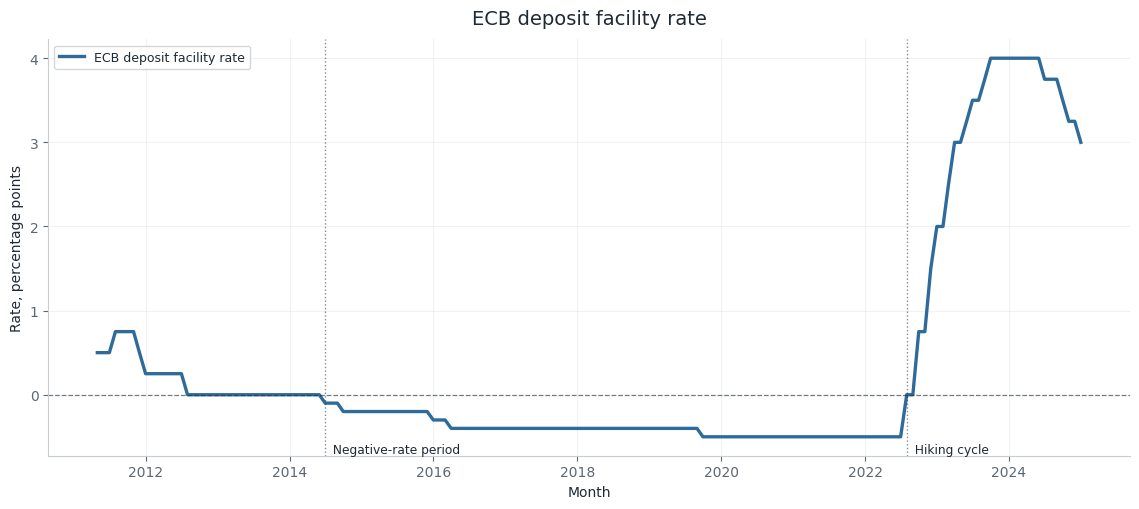

Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\ecb_deposit_facility_rate_201104_202412.png
DFR column used: dfr


In [22]:
# ============================================================
# FIGURE — ECB DEPOSIT FACILITY RATE, 2011-04 TO 2024-12
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

d = df_reg_full.copy()
d[MONTH_COL] = pd.to_datetime(d[MONTH_COL]).dt.to_period("M").dt.to_timestamp("M")

dfr_col = find_first(d, [
    "dfr",
    "DFR",
    "deposit_facility_rate",
    "ecb_dfr",
    "ecb_deposit_facility_rate",
    "deposit_rate",
])

if dfr_col is None:
    raise KeyError("No ECB DFR column found. Check your column names.")

macro = (
    d[[MONTH_COL, dfr_col]]
    .drop_duplicates()
    .groupby(MONTH_COL, as_index=False)
    .mean(numeric_only=True)
    .sort_values(MONTH_COL)
)

def to_percentage_points(x):
    x = as_numeric(x)
    if x.abs().median(skipna=True) < 0.20:
        return x * 100
    return x

macro["dfr_pp"] = to_percentage_points(macro[dfr_col])

macro = macro[
    macro[MONTH_COL].between(pd.Timestamp("2011-04-30"), pd.Timestamp("2024-12-31"))
].copy()

# -----------------------------
# Plot
# -----------------------------

BG = "#FFFFFF"
AX_BG = WP_AX_BG
BLUE = WP_BLUE
GRID = WP_GRID
TEXT = WP_TEXT

fig, ax = plt.subplots(figsize=(11.5, 5.2))
fig.patch.set_facecolor(BG)
ax.set_facecolor(AX_BG)

ax.plot(
    macro[MONTH_COL],
    macro["dfr_pp"],
    color=BLUE,
    lw=2.4,
    label="ECB deposit facility rate"
)

ax.axhline(0, color=TEXT, lw=0.9, linestyle="--", alpha=0.60)

# Optional regime markers
ax.axvline(pd.Timestamp("2014-06-30"), color=TEXT, lw=1.0, linestyle=":", alpha=0.55)
ax.axvline(pd.Timestamp("2022-07-31"), color=TEXT, lw=1.0, linestyle=":", alpha=0.55)

ax.text(
    pd.Timestamp("2014-06-30"),
    ax.get_ylim()[0],
    "  Negative-rate period",
    va="bottom",
    ha="left",
    fontsize=8.8,
    color=TEXT,
)

ax.text(
    pd.Timestamp("2022-07-31"),
    ax.get_ylim()[0],
    "  Hiking cycle",
    va="bottom",
    ha="left",
    fontsize=8.8,
    color=TEXT,
)

ax.set_title("ECB deposit facility rate", fontsize=14, pad=11)
ax.set_ylabel("Rate, percentage points")
ax.set_xlabel("Month")

ax.grid(True, color=GRID, alpha=0.35)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.legend(
    loc="best",
    frameon=True,
    facecolor=AX_BG,
    edgecolor=WP_BORDER,
    fontsize=9,
)

fig.tight_layout()

fig_path = OUT_DIR / "ecb_deposit_facility_rate_201104_202412.png"
fig.savefig(fig_path, dpi=240, bbox_inches="tight", facecolor=fig.get_facecolor())

plt.show()

print(f"Saved figure: {fig_path.resolve()}")
print(f"DFR column used: {dfr_col}")


# C. Main aggregate results

This block is the main empirical stack for aggregate customer-deposit exposure and curve-steepening asymmetry.


## C.1 Table 1 — Aggregate customer-deposit asymmetry

Preferred ASYM design plus macro-channel extensions. Main inference uses bank fixed effects, month fixed effects, lagged controls, and one-way bank-clustered SE unless stated otherwise.


In [23]:
# ============================================================
# 9. TABLE 1 — AGGREGATE CUSTOMER-DEPOSIT ASYMMETRY
# ============================================================

regs_asym_main = [HIGH_CUSTDEP, STEPP_CUST, FLAT_CUST, *CONTROLS_MAIN]
regs_asym_rate_sov = [HIGH_CUSTDEP, STEPP_CUST, FLAT_CUST, SHORT_CUST, SOV, *CONTROLS_MAIN]
regs_asym_full_macro = [HIGH_CUSTDEP, STEPP_CUST, FLAT_CUST, SHORT_CUST, SOV, STRESS_CUST, *CONTROLS_MAIN]

specs_table1 = {
    "Main ASYM": ModelSpec(
        df_main,
        DEPENDENT_VAR,
        regs_asym_main,
        "Table 1: Main ASYM on quality-controlled sample",
        keys=[STEPP_CUST],
    ),
    "+ short-rate + sovereign": ModelSpec(
        df_main,
        DEPENDENT_VAR,
        regs_asym_rate_sov,
        "Table 1: ASYM + short-rate and sovereign-spread channels on quality-controlled sample",
        keys=[STEPP_CUST],
    ),
    "+ full macro/stress": ModelSpec(
        df_main,
        DEPENDENT_VAR,
        regs_asym_full_macro,
        "Table 1: ASYM + short-rate, sovereign-spread, and stress channels on quality-controlled sample",
        keys=[STEPP_CUST],
    ),
}
res_table1 = run_model_specs(specs_table1)

coef_rows_table1 = {
    "steepening": STEPP_CUST,
    "flattening": FLAT_CUST,
    "short": SHORT_CUST,
    "sov_level": SOV,
    "stress": STRESS_CUST,
    "tier1": "tier1_ratio_reg",
    "size": "size_reg",
}
row_labels_table1 = {
    "steepening": "Steepening × HighCustDep",
    "flattening": "Flattening × HighCustDep",
    "short": "ΔShort × HighCustDep",
    "sov_level": "ΔSovSpread",
    "sov_interaction": "ΔSovSpread × HighCustDep",
    "stress": "ΔStress/CISS × HighCustDep",
    "tier1": "Tier 1 ratio",
    "size": "Size",
}

table1 = print_multi_table(
    res_table1,
    ["Main ASYM", "+ short-rate + sovereign", "+ full macro/stress"],
    coef_rows_table1,
    row_labels_table1,
    "TABLE 1 — AGGREGATE CUSTOMER-DEPOSIT ASYMMETRY",
    "05_table1_aggregate_customer_deposit_asymmetry.csv",
)

all_results["table1_aggregate_asymmetry"] = res_table1
all_tables["table1_aggregate_asymmetry"] = table1


WCB: Main ASYM | steepening_x_high_custdep
WCB: + short-rate + sovereign | steepening_x_high_custdep
WCB: + full macro/stress | steepening_x_high_custdep

TABLE 1 — AGGREGATE CUSTOMER-DEPOSIT ASYMMETRY
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
                  Variable             (1) Main ASYM (2) + short-rate + sovereign   (3) + full macro/stress
  Steepening × HighCustDep                  0.0810**                      0.0780*                    0.0624
                                            (0.0392)                     (0.0413)                  (0.0412)
                                           [p=0.039]                    [p=0.059]                 [p=0.130]
                                       [WCB p=0.050]                [WCB p=0.069]             [WCB p=0.154]
  Flattening × HighCustDep                   -0.0183                      -0.0386                   -0.0471
                         

## C.2 Table 1B — Aggregate asymmetry Wald tests

Tests the steepening-versus-flattening restriction for the aggregate ASYM specification.


In [24]:
# ============================================================
# 9B. TABLE 1B — WALD TESTS FOR AGGREGATE ASYMMETRY
# ============================================================

def wald_zero_linear_combo(res, weights, label):
    """
    Wald test for H0: sum_j weights[j] * beta_j = 0.
    Uses the model covariance matrix already stored in the regression result.
    """
    out = {
        "test": label,
        "ok": False,
        "estimate": np.nan,
        "se": np.nan,
        "t_stat": np.nan,
        "p_value": np.nan,
        "stars": "",
        "error": "",
    }

    if res is None or not res.get("ok", False):
        out["error"] = "Model not estimated"
        return out

    weights = {k: float(v) for k, v in weights.items() if k is not None and v != 0}
    vars_needed = list(weights.keys())

    missing = [
        v for v in vars_needed
        if v not in res.get("params", pd.Series(dtype=float)).index
        or pd.isna(res["params"].get(v, np.nan))
    ]

    if missing:
        out["error"] = f"Missing/absorbed coefficient(s): {missing}"
        return out

    cov = res.get("cov", pd.DataFrame())
    if cov is None or cov.empty:
        out["error"] = "Covariance matrix unavailable"
        return out

    try:
        b = res["params"].loc[vars_needed].to_numpy(float)
        V = cov.loc[vars_needed, vars_needed].to_numpy(float)
        w = np.array([weights[v] for v in vars_needed], dtype=float)

        estimate = float(w @ b)
        variance = float(w @ V @ w)
        se = math.sqrt(max(variance, 0.0))

        if se <= 0 or not np.isfinite(se):
            out["error"] = "Non-positive standard error"
            return out

        t_stat = estimate / se
        p_value = normal_pvalue(t_stat)

        out.update({
            "ok": True,
            "estimate": estimate,
            "se": se,
            "t_stat": t_stat,
            "p_value": p_value,
            "stars": stars(p_value),
            "error": "",
        })

        return out

    except Exception as exc:
        out["error"] = str(exc)
        return out


wald_asym_tests = {
    "Same-slope symmetry: β_steep − β_flat = 0": {
        STEPP_CUST: 1.0,
        FLAT_CUST: -1.0,
    },
    "Opposite-sign magnitude: β_steep + β_flat = 0": {
        STEPP_CUST: 1.0,
        FLAT_CUST: 1.0,
    },
}

table1_model_order = ["Main ASYM", "+ short-rate + sovereign", "+ full macro/stress"]

wald_asym_rows = []

for model_key in table1_model_order:
    res = res_table1.get(model_key)

    for test_label, weights in wald_asym_tests.items():
        r = wald_zero_linear_combo(res, weights, test_label)

        wald_asym_rows.append({
            "model": model_key,
            "test": test_label,
            "null": " = ".join([
                "β_steep − β_flat", "0"
            ]) if "−" in test_label else "β_steep + β_flat = 0",
            "estimate": r["estimate"],
            "se": r["se"],
            "t_stat": r["t_stat"],
            "p_value": r["p_value"],
            "stars": r["stars"],
            "observations": res.get("nobs", np.nan) if isinstance(res, dict) else np.nan,
            "banks": res.get("n_banks", np.nan) if isinstance(res, dict) else np.nan,
            "months": res.get("n_months", np.nan) if isinstance(res, dict) else np.nan,
            "status": "OK" if r["ok"] else r["error"],
        })

table1b_wald_asymmetry = pd.DataFrame(wald_asym_rows)

for c in ["estimate", "se", "t_stat", "p_value"]:
    table1b_wald_asymmetry[c] = pd.to_numeric(table1b_wald_asymmetry[c], errors="coerce").round(4)

save_table(
    table1b_wald_asymmetry,
    "05c_table1b_wald_aggregate_asymmetry_tests.csv",
)

all_wald["table1b_aggregate_asymmetry_tests"] = table1b_wald_asymmetry
all_tables["table1b_aggregate_asymmetry_tests"] = table1b_wald_asymmetry


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\05c_table1b_wald_aggregate_asymmetry_tests.csv


,model,test,null,estimate,se,t_stat,p_value,stars,observations,banks,months,status
0,Main ASYM,Same-slope symmetry: β_steep − β_flat = 0,β_steep − β_flat = 0,0.0994,0.0580,1.7126,0.0868,*,5318,36,165,OK
1,Main ASYM,Opposite-sign magnitude: β_steep + β_flat = 0,β_steep + β_flat = 0,0.0627,0.0426,1.4702,0.1415,,5318,36,165,OK
2,+ short-rate + sovereign,Same-slope symmetry: β_steep − β_flat = 0,β_steep − β_flat = 0,0.1166,0.0648,1.7991,0.0720,*,5318,36,165,OK
3,+ short-rate + sovereign,Opposite-sign magnitude: β_steep + β_flat = 0,β_steep + β_flat = 0,0.0394,0.0462,0.8530,0.3937,,5318,36,165,OK
4,+ full macro/stress,Same-slope symmetry: β_steep − β_flat = 0,β_steep − β_flat = 0,0.1095,0.0630,1.7391,0.0820,*,5318,36,165,OK
5,+ full macro/stress,Opposite-sign magnitude: β_steep + β_flat = 0,β_steep + β_flat = 0,0.0153,0.0530,0.2876,0.7736,,5318,36,165,OK


## C.3 Table 2 — Expanded Bank Quality and Macro Controls

Adds short-rate, sovereign-spread, stress, ROAA, and credit-risk controls to assess whether the aggregate steepening coefficient survives broader macro/bank-quality conditioning.


In [25]:
# ============================================================
# 10. TABLE 2 — AGGREGATE ASYM: QUALITY SAMPLE ONLY
# ============================================================

# Sovereign spread should be the monthly change, not the level
SOV_DELTA = "delta_sovspread"   # replace with exact column name if different


# ------------------------------------------------------------
# Helper: keep only valid regressors for df_quality
# ------------------------------------------------------------
def filter_regs(regs, df):
    return list(dict.fromkeys([
        r for r in regs
        if r is not None and r in df.columns
    ]))


# ------------------------------------------------------------
# 1. ASYM baseline on quality sample
# ------------------------------------------------------------
regs_asym_quality = [
    HIGH_CUSTDEP,
    STEPP_CUST,
    FLAT_CUST,
    *CONTROLS_MAIN,
]


# ------------------------------------------------------------
# 2. ASYM + bank-quality controls
# ------------------------------------------------------------
regs_bank_quality = [
    HIGH_CUSTDEP,
    STEPP_CUST,
    FLAT_CUST,
    "roaa_reg",
    "credit_risk_reg",
    *CONTROLS_MAIN,
]


# ------------------------------------------------------------
# 3. ASYM + macro controls
# ------------------------------------------------------------
regs_macro_quality = [
    HIGH_CUSTDEP,
    STEPP_CUST,
    FLAT_CUST,
    SHORT_CUST,
    SOV_DELTA,        # standalone Δ sovereign spread
    STRESS_CUST,
    *CONTROLS_MAIN,
]


# ------------------------------------------------------------
# 4. ASYM + macro + bank-quality controls
#    Optional saturated robustness column, still on same sample
# ------------------------------------------------------------
regs_full_quality = [
    HIGH_CUSTDEP,
    STEPP_CUST,
    FLAT_CUST,
    SHORT_CUST,
    SOV_DELTA,        # standalone Δ sovereign spread
    STRESS_CUST,
    "roaa_reg",
    "credit_risk_reg",
    *CONTROLS_MAIN,
]


# ------------------------------------------------------------
# Filter all regressors using df_quality only
# ------------------------------------------------------------
regs_asym_quality = filter_regs(regs_asym_quality, df_quality)
regs_bank_quality = filter_regs(regs_bank_quality, df_quality)
regs_macro_quality = filter_regs(regs_macro_quality, df_quality)
regs_full_quality = filter_regs(regs_full_quality, df_quality)


# ------------------------------------------------------------
# Table 2 specifications — all on df_quality
# ------------------------------------------------------------
specs_table2 = {
    "ASYM quality sample": ModelSpec(
        df_quality,
        DEPENDENT_VAR,
        regs_asym_quality,
        "Table 2: ASYM baseline on quality-control sample",
        keys=[STEPP_CUST],
    ),

    "+ bank-quality controls": ModelSpec(
        df_quality,
        DEPENDENT_VAR,
        regs_bank_quality,
        "Table 2: ASYM with ROAA and credit risk",
        keys=[STEPP_CUST],
    ),

    "+ macro controls": ModelSpec(
        df_quality,
        DEPENDENT_VAR,
        regs_macro_quality,
        "Table 2: ASYM with macro controls",
        keys=[STEPP_CUST],
    ),
}


# ------------------------------------------------------------
# Run models
# ------------------------------------------------------------
res_table2 = run_model_specs(specs_table2)


# ------------------------------------------------------------
# Coefficient rows
# ------------------------------------------------------------
coef_rows_table2 = {
    "steepening": STEPP_CUST,
    "flattening": FLAT_CUST,
    "short": SHORT_CUST,
    "sov_delta": SOV_DELTA,
    "stress": STRESS_CUST,
    "roaa": "roaa_reg",
    "credit": "credit_risk_reg",
    "tier1": "tier1_ratio_reg",
    "size": "size_reg",
}


row_labels_table2 = {
    "steepening": "Steepening × HighCustDep",
    "flattening": "Flattening × HighCustDep",
    "short": "Δ1M short-rate × HighCustDep",
    "sov_delta": "ΔSovereign spread",
    "stress": "ΔCISS/Stress × HighCustDep",
    "roaa": "ROAA",
    "credit": "Credit risk",
    "tier1": "Tier 1 ratio",
    "size": "Size",
}


# ------------------------------------------------------------
# Print / save table
# ------------------------------------------------------------
table2 = print_multi_table(
    res_table2,
    [
        "ASYM quality sample",
        "+ bank-quality controls",
        "+ macro controls",
        "+ macro + bank-quality controls",
    ],
    coef_rows_table2,
    row_labels_table2,
    "TABLE 2 — AGGREGATE ASYM WITH BANK-QUALITY AND MACRO CONTROLS, QUALITY SAMPLE",
    "06_table2_aggregate_asym_quality_sample_controls.csv",
)


# ------------------------------------------------------------
# Store results
# ------------------------------------------------------------
all_results["table2_quality_sample_controls"] = res_table2
all_tables["table2_quality_sample_controls"] = table2

WCB: ASYM quality sample | steepening_x_high_custdep
WCB: + bank-quality controls | steepening_x_high_custdep
WCB: + macro controls | steepening_x_high_custdep

TABLE 2 — AGGREGATE ASYM WITH BANK-QUALITY AND MACRO CONTROLS, QUALITY SAMPLE
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
                    Variable   (1) ASYM quality sample (2) + bank-quality controls      (3) + macro controls
    Steepening × HighCustDep                  0.0810**                    0.0793**                    0.0624
                                              (0.0392)                    (0.0398)                  (0.0412)
                                             [p=0.039]                   [p=0.046]                 [p=0.130]
                                         [WCB p=0.050]               [WCB p=0.055]             [WCB p=0.154]
    Flattening × HighCustDep                   -0.0183                     -0.0180         

## C.4 Table 3 — Common-sample bridge

Reruns the aggregate ASYM specification on the nested mechanism sample to separate composition-disclosure effects from sample-composition effects.


In [26]:
# ============================================================
# 11. TABLE 3 — MECHANISM-SAMPLE BRIDGE
# ============================================================

specs_table3 = {
    "Main quality sample": ModelSpec(
        df_main,
        DEPENDENT_VAR,
        regs_asym_main,
        "Table 3: aggregate ASYM on main quality-controlled sample",
        keys=[STEPP_CUST],
    ),
    "Nested mechanism sample": ModelSpec(
        df_common,
        DEPENDENT_VAR,
        regs_asym_main,
        "Table 3: aggregate ASYM on mechanism-nested sample",
        keys=[STEPP_CUST],
    ),
}

# No WCB needed here: this is a sample-composition diagnostic.
# Table 1 already carries the main inference burden.
res_table3 = run_model_specs(specs_table3, attach_wcb=False)

coef_rows_table3 = {
    "steepening": STEPP_CUST,
    "flattening": FLAT_CUST,
    "tier1": "tier1_ratio_reg",
    "size": "size_reg",
}

row_labels_table3 = {
    "steepening": "Steepening × HighCustDep",
    "flattening": "Flattening × HighCustDep",
    "tier1": "Tier 1 ratio",
    "size": "Size",
}

table3 = print_multi_table(
    res_table3,
    ["Main quality sample", "Nested mechanism sample"],
    coef_rows_table3,
    row_labels_table3,
    "TABLE 3 — MECHANISM-SAMPLE BRIDGE: AGGREGATE ASYM ON MAIN VS MECHANISM SAMPLE",
    "07_table3_mechanism_sample_bridge.csv",
)

all_results["table3_mechanism_sample_bridge"] = res_table3
all_tables["table3_mechanism_sample_bridge"] = table3



TABLE 3 — MECHANISM-SAMPLE BRIDGE: AGGREGATE ASYM ON MAIN VS MECHANISM SAMPLE
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
                Variable   (1) Main quality sample (2) Nested mechanism sample
Steepening × HighCustDep                  0.0810**                   0.1068***
                                          (0.0392)                    (0.0390)
                                         [p=0.039]                   [p=0.006]
Flattening × HighCustDep                   -0.0183                     -0.0395
                                          (0.0326)                    (0.0378)
                                         [p=0.573]                   [p=0.297]
            Tier 1 ratio                    0.0010                      0.0003
                                          (0.0009)                    (0.0018)
                                         [p=0.285]                   [p=0.876]
      

# D. Deposit-composition mechanism

This block checks whether the aggregate deposit-franchise result is sharper for Demand/Sight deposits relative to Time/Savings deposits.


## D.1 Table 4 — Demand/Sight versus Time/Savings mechanism

Binary deposit-composition interactions for steepening and flattening episodes in the mechanism sample.


In [27]:
# ============================================================
# 12. TABLE 4 — DEPOSIT-COMPOSITION MECHANISM
# ============================================================

if MECH_READY:
    regs_mech_combined_steep = [
        HIGH_DEMAND,
        HIGH_TIME_SAVINGS,
        DEMAND_STEEP,
        TIME_STEEP,
        *CONTROLS_MAIN,
    ]

    regs_mech_combined_asym = [
        HIGH_DEMAND,
        HIGH_TIME_SAVINGS,
        DEMAND_STEEP,
        TIME_STEEP,
        DEMAND_FLAT,
        TIME_FLAT,
        *CONTROLS_MAIN,
    ]

    specs_table4 = {
        "Preferred ASYM mechanism": ModelSpec(
            df_mech,
            DEPENDENT_VAR,
            regs_mech_combined_asym,
            "Table 4: preferred demand/sight and time/savings ASYM mechanism",
            keys=[DEMAND_STEEP, TIME_STEEP],
        ),
    }

    res_table4 = run_model_specs(specs_table4)

    coef_rows_table4 = {
        "demand_steep": DEMAND_STEEP,
        "time_steep": TIME_STEEP,
        "demand_flat": {"Preferred ASYM mechanism": DEMAND_FLAT},
        "time_flat": {"Preferred ASYM mechanism": TIME_FLAT},
        "tier1": "tier1_ratio_reg",
        "size": "size_reg",
    }

    row_labels_table4 = {
        "demand_steep": "Steepening × High Demand/Sight",
        "time_steep": "Steepening × High Time/Savings",
        "demand_flat": "Flattening × High Demand/Sight",
        "time_flat": "Flattening × High Time/Savings",
        "tier1": "Tier 1 ratio",
        "size": "Size",
    }

    table4 = print_multi_table(
        res_table4,
        ["Combined steepening", "Preferred ASYM mechanism"],
        coef_rows_table4,
        row_labels_table4,
        "TABLE 4 — DEPOSIT-COMPOSITION MECHANISM: DEMAND/SIGHT VS TIME/SAVINGS",
        "08_table4_deposit_composition_mechanism.csv",
    )

    all_results["table4_deposit_composition_mechanism"] = res_table4
    all_tables["table4_deposit_composition_mechanism"] = table4

else:
    warn_msg("Table 4 skipped because demand/sight and/or time/savings mechanism variables were not detected.")
    res_table4 = {}


WCB: Preferred ASYM mechanism | steepening_x_high_demand_dep_share
WCB: Preferred ASYM mechanism | steepening_x_high_savings_dep_share

TABLE 4 — DEPOSIT-COMPOSITION MECHANISM: DEMAND/SIGHT VS TIME/SAVINGS
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
                      Variable (1) Preferred ASYM mechanism
Steepening × High Demand/Sight                      -0.0057
                                                   (0.0587)
                                                  [p=0.922]
                                              [WCB p=0.928]
Steepening × High Time/Savings                    -0.1185**
                                                   (0.0493)
                                                  [p=0.016]
                                              [WCB p=0.020]
Flattening × High Demand/Sight                      -0.0118
                                                   (0.0916)
         

## D.2 Table 5 — Mechanism Wald differential tests

Formal Wald/WCB test of the Demand/Sight minus Time/Savings steepening differential.


In [28]:
# ============================================================
# 13. TABLE 5 — WALD DIFFERENTIAL TEST
# ============================================================

REPORT_FLATTENING_WALD = False  # Keep False for main thesis table. Set True for appendix diagnostic.

PREFERRED_MECH_MODEL = "Preferred ASYM mechanism"

if MECH_READY and PREFERRED_MECH_MODEL in res_table4:
    main_mech_res = res_table4[PREFERRED_MECH_MODEL]

    regs_mech_preferred_asym = [
        DEMAND_STEEP,
        TIME_STEEP,
        DEMAND_FLAT,
        TIME_FLAT,
        *CONTROLS_MAIN,
    ]

    wald_rows = []

    # Main mechanism test:
    # Is the steepening response different for demand/sight-heavy banks
    # relative to time/savings-heavy banks?
    if RUN_WALD_WCB:
        wald_steep = fast_one_way_bank_wcb_linear_restriction(
            df_mech,
            DEPENDENT_VAR,
            regs_mech_preferred_asym,
            DEMAND_STEEP,
            TIME_STEEP,
            "Steepening differential: Demand/Sight − Time/Savings",
            B=WCB_REPS,
            seed=WCB_SEED + 10_000,
        )
    else:
        wald_steep = wald_equal_coefficients(
            main_mech_res,
            DEMAND_STEEP,
            TIME_STEEP,
            label="Steepening differential: Demand/Sight − Time/Savings",
        )

    wald_rows.append(wald_steep)

    # Optional appendix-style diagnostic.
    # Not the core mechanism test.
    if REPORT_FLATTENING_WALD:
        if RUN_WALD_WCB:
            wald_flat = fast_one_way_bank_wcb_linear_restriction(
                df_mech,
                DEPENDENT_VAR,
                regs_mech_preferred_asym,
                DEMAND_FLAT,
                TIME_FLAT,
                "Flattening differential: Demand/Sight − Time/Savings",
                B=WCB_REPS,
                seed=WCB_SEED + 20_000,
            )
        else:
            wald_flat = wald_equal_coefficients(
                main_mech_res,
                DEMAND_FLAT,
                TIME_FLAT,
                label="Flattening differential: Demand/Sight − Time/Savings",
            )

        wald_rows.append(wald_flat)

    table5 = wald_result_table(
        wald_rows,
        "09_table5_wald_steepening_differential.csv",
    )

    all_wald["table5_mechanism_steepening_differential"] = wald_rows
    all_tables["table5_wald_steepening_differential"] = table5

else:
    warn_msg(
        f"Table 5 skipped because the preferred mechanism model "
        f"('{PREFERRED_MECH_MODEL}') is unavailable."
    )


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\09_table5_wald_steepening_differential.csv


,Test,Contrast,Difference,SE(diff),t-stat,Analytic p,WCB p,Bootstrap draws,Observations,Banks,Months,Status
0,Steepening differential: Demand/Sight − Time/S...,steepening_x_high_demand_dep_share − steepenin...,0.1127***,(0.0378),2.981,0.0029,0.0070,999/999,"3,386",31,165,OK


## D.3 Table 6 — CISS regime split

Runs the aggregate ASYM specification separately in low- and high-stress regimes.


In [29]:
# ============================================================
# 14. TABLE 6 — AGGREGATE ASYM BY CISS REGIME
# ============================================================

if RUN_CISS_REGIME and "ciss_regime" in df_main.columns:
    regimes = ["Low CISS", "High CISS"]

    ciss_asym_specs = {}

    for regime in regimes:
        d = df_main.loc[df_main["ciss_regime"] == regime].copy()

        ciss_asym_specs[regime] = ModelSpec(
            d,
            DEPENDENT_VAR,
            regs_asym_main,
            f"Table 6: Aggregate ASYM on main quality sample — {regime}",
            keys=[STEPP_CUST],
        )

    res_table6 = run_model_specs(
        ciss_asym_specs,
        attach_wcb=RUN_CISS_WCB,
    )

    coef_rows_table6 = {
        "steepening": STEPP_CUST,
        "flattening": FLAT_CUST,
        "tier1": "tier1_ratio_reg",
        "size": "size_reg",
    }

    row_labels_table6 = {
        "steepening": "Steepening × HighCustDep",
        "flattening": "Flattening × HighCustDep",
        "tier1": "Tier 1 ratio",
        "size": "Size",
    }

    table6 = print_multi_table(
        res_table6,
        regimes,
        coef_rows_table6,
        row_labels_table6,
        "TABLE 6 — AGGREGATE ASYM BY FINANCIAL-STRESS REGIME",
        "10_table6_aggregate_asym_by_ciss_regime.csv",
    )

    all_results["table6_ciss_aggregate_asym"] = res_table6
    all_tables["table6_ciss_aggregate_asym"] = table6

else:
    warn_msg(
        "Table 6 skipped. Set RUN_CISS_REGIME=True and make sure ciss_regime exists in df_main."
    )


WCB: Low CISS | steepening_x_high_custdep
WCB: High CISS | steepening_x_high_custdep

TABLE 6 — AGGREGATE ASYM BY FINANCIAL-STRESS REGIME
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
                Variable              (1) Low CISS             (2) High CISS
Steepening × HighCustDep                  -0.0859*                  0.1606**
                                          (0.0445)                  (0.0628)
                                         [p=0.054]                 [p=0.011]
                                     [WCB p=0.069]             [WCB p=0.018]
Flattening × HighCustDep                    0.0245                   -0.0358
                                          (0.0603)                  (0.0407)
                                         [p=0.685]                 [p=0.380]
            Tier 1 ratio                   0.0020*                    0.0004
                                          (0

## D.4 Figure 1 — Rolling-window mechanism differential

Descriptive rolling-window figure for the Demand/Sight minus Time/Savings contrast. Use this as time-variation evidence, not as a substitute for the full-sample mechanism tests.


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\11_figure1_rolling_mechanism_differential.csv
Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\11_figure1_rolling_mechanism_differential.png


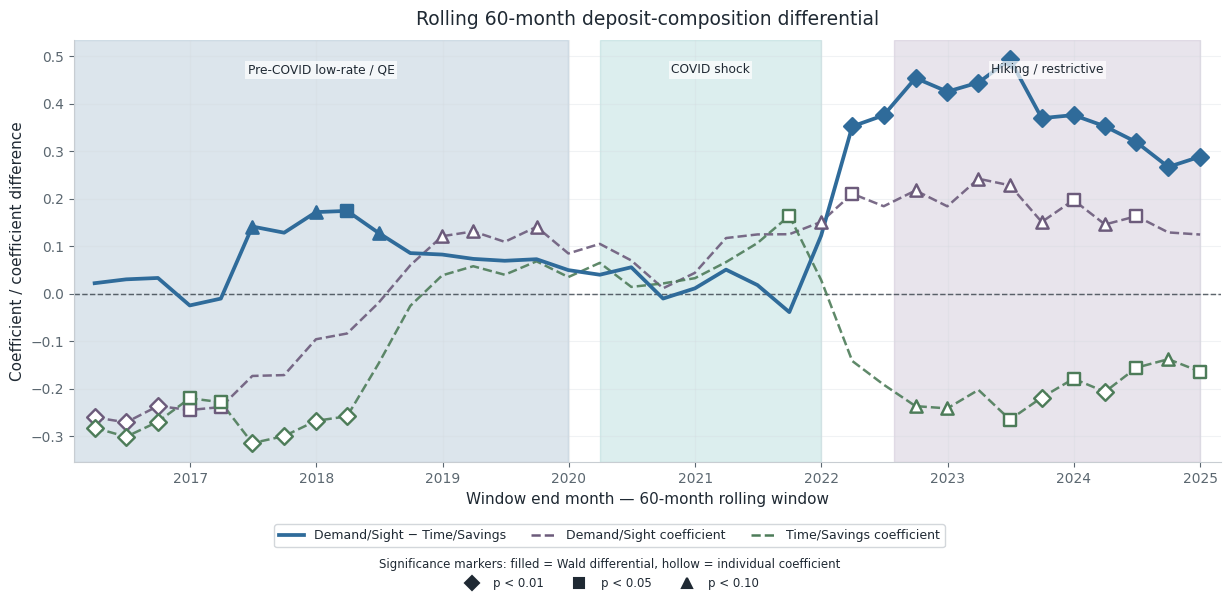

In [30]:
# ============================================================
# 15. FIGURE 1 — ROLLING-WINDOW MECHANISM DIFFERENTIAL
# ============================================================

from matplotlib.lines import Line2D

if RUN_ROLLING_WINDOWS and MECH_READY and not df_mech.empty:

    PLOT_START = pd.Timestamp("2016-01-31")
    SHOW_COEF_SIG = True

    REGIMES = [
        ("Pre-COVID low-rate / QE", "2016-01-31", "2019-12-31", WP_SHADE_BLUE),
        ("COVID shock", "2020-03-31", "2021-12-31", WP_SHADE_TEAL),
        ("Hiking / restrictive", "2022-07-31", "2024-12-31", WP_SHADE_PURPLE),
    ]

    SERIES = {
        "diff":   (WP_BLUE, "-",  2.7, "Demand/Sight − Time/Savings"),
        "demand": (WP_PURPLE, "--", 1.8, "Demand/Sight coefficient"),
        "time":   (WP_GREEN, "--", 1.8, "Time/Savings coefficient"),
    }

    SIG = [(0.01, "D", "p < 0.01"), (0.05, "s", "p < 0.05"), (0.10, "^", "p < 0.10")]

    def sig_level(p):
        return np.select([p < 0.01, p < 0.05, p < 0.10], ["1%", "5%", "10%"], default="")

    def add_sig(ax, d, y, p, color, filled=False, z=8):
        lo = 0.0
        for hi, marker, _ in SIG:
            s = d[d[p].notna() & (d[p] < hi) & (d[p] >= lo)]
            if not s.empty:
                ax.scatter(
                    s["window_end"], s[y],
                    marker=marker,
                    s=78 if marker != "D" else 72,
                    facecolor=color if filled else WP_AX_BG,
                    edgecolor=color,
                    linewidth=1.75,
                    zorder=z,
                )
            lo = hi

    # -----------------------------
    # Rolling joint regressions
    # -----------------------------

    months = pd.Series(sorted(pd.to_datetime(df_mech[MONTH_COL].dropna().unique())))

    rolling_regs = [HIGH_DEMAND, HIGH_TIME_SAVINGS, DEMAND_STEEP, TIME_STEEP, *CONTROLS_MAIN]
    if ROLLING_INCLUDE_FLATTENING:
        rolling_regs = [HIGH_DEMAND, HIGH_TIME_SAVINGS, DEMAND_STEEP, TIME_STEEP, DEMAND_FLAT, TIME_FLAT, *CONTROLS_MAIN]

    rows = []

    for end_i in range(ROLLING_WINDOW_MONTHS - 1, len(months), ROLLING_STEP_MONTHS):
        start = months.iloc[end_i - ROLLING_WINDOW_MONTHS + 1]
        end = months.iloc[end_i]

        window = df_mech[df_mech[MONTH_COL].between(start, end)].copy()
        needed = [DEPENDENT_VAR, *rolling_regs, BANK_COL, MONTH_COL, DATE_COL]

        if any(c not in window.columns for c in needed):
            continue

        work = subset_complete_case(window, needed, label=f"rolling {start:%Y-%m} to {end:%Y-%m}", allow_missing=True)

        if work[BANK_COL].nunique() < ROLLING_MIN_BANKS or len(work) < ROLLING_MIN_OBS:
            continue

        res = fit_panel(
            work,
            DEPENDENT_VAR,
            rolling_regs,
            model_name=f"Rolling joint mechanism: {start:%Y-%m} to {end:%Y-%m}",
            verbose=False,
        )

        w = wald_equal_coefficients(res, DEMAND_STEEP, TIME_STEEP, label="Rolling steepening differential")

        rows.append({
            "window_start": start,
            "window_end": end,

            "demand_coef": get_stat(res, DEMAND_STEEP, "coef"),
            "demand_se": get_stat(res, DEMAND_STEEP, "se"),
            "demand_p": get_stat(res, DEMAND_STEEP, "p"),

            "time_coef": get_stat(res, TIME_STEEP, "coef"),
            "time_se": get_stat(res, TIME_STEEP, "se"),
            "time_p": get_stat(res, TIME_STEEP, "p"),

            "diff": w.get("diff", np.nan),
            "se_diff": w.get("se_diff", np.nan),
            "t_stat": w.get("t_stat", np.nan),
            "diff_p": w.get("p_value", np.nan),

            "nobs": res.get("nobs", np.nan),
            "banks": res.get("n_banks", np.nan),
            "status": "OK" if res.get("ok", False) else res.get("error", ""),
        })

    rolling_window_table = pd.DataFrame(rows)

    if rolling_window_table.empty:
        warn_msg("Rolling-window table is empty; check mechanism variables and sample coverage.")

    else:
        for base in ["diff", "demand", "time"]:
            rolling_window_table[f"{base}_sig_level"] = sig_level(rolling_window_table[f"{base}_p"])

        out_csv = OUT_DIR / "11_figure1_rolling_mechanism_differential.csv"

        rolling_window_table.assign(
            window_start=lambda x: pd.to_datetime(x["window_start"]).dt.strftime("%Y-%m"),
            window_end=lambda x: pd.to_datetime(x["window_end"]).dt.strftime("%Y-%m"),
        ).to_csv(out_csv, index=False)

        print(f"Saved: {out_csv.resolve()}")

        plot_df = (
            rolling_window_table
            .sort_values("window_end")
            .loc[lambda x: x["window_end"] >= PLOT_START]
            .copy()
        )

        if plot_df.empty:
            warn_msg("No rolling-window observations remain after applying PLOT_START.")

        else:
            # -----------------------------
            # Plot
            # -----------------------------

            fig, ax = plt.subplots(figsize=(12.6, 6.3))
            fig.patch.set_facecolor(WP_FIG_BG)
            ax.set_facecolor(WP_AX_BG)

            xmax = plot_df["window_end"].max() + pd.DateOffset(months=2)

            for label, start, end, color in REGIMES:
                start = max(pd.Timestamp(start), PLOT_START)
                end = min(pd.Timestamp(end), xmax)

                if end <= start:
                    continue

                ax.axvspan(start, end, color=color, alpha=0.30, zorder=0)
                ax.text(
                    start + (end - start) / 2,
                    0.945,
                    label,
                    transform=ax.get_xaxis_transform(),
                    ha="center",
                    va="top",
                    fontsize=8.8,
                    color=WP_TEXT,
                    bbox=dict(facecolor=WP_AX_BG, edgecolor="none", alpha=0.70, pad=1.8),
                    zorder=10,
                )

            # Lines
            color, ls, lw, lab = SERIES["diff"]
            ax.plot(plot_df["window_end"], plot_df["diff"], color=color, linestyle=ls, linewidth=lw, label=lab, zorder=5)

            if SHOW_ROLLING_UNDERLYING_COEFFICIENTS:
                for key, y in [("demand", "demand_coef"), ("time", "time_coef")]:
                    color, ls, lw, lab = SERIES[key]
                    ax.plot(plot_df["window_end"], plot_df[y], color=color, linestyle=ls, linewidth=lw, alpha=0.90, label=lab, zorder=4)

            # Significance markers
            add_sig(ax, plot_df, "diff", "diff_p", SERIES["diff"][0], filled=True, z=9)

            if SHOW_ROLLING_UNDERLYING_COEFFICIENTS and SHOW_COEF_SIG:
                add_sig(ax, plot_df, "demand_coef", "demand_p", SERIES["demand"][0], filled=False, z=8)
                add_sig(ax, plot_df, "time_coef", "time_p", SERIES["time"][0], filled=False, z=8)

            # Formatting
            ax.axhline(0, color=WP_TEXT, linestyle="--", linewidth=1.05, alpha=0.70, zorder=2)
            ax.set_xlim(PLOT_START, xmax)
            ax.set_title("Rolling 60-month deposit-composition differential", fontsize=13.5, pad=11)
            ax.set_xlabel("Window end month — 60-month rolling window", fontsize=11)
            ax.set_ylabel("Coefficient / coefficient difference", fontsize=11)
            ax.grid(True, color=WP_GRID, alpha=0.34)

            for spine in ["top", "right"]:
                ax.spines[spine].set_visible(False)

            # Legends below figure
            series_handles = [
                Line2D([0], [0], color=SERIES[k][0], linestyle=SERIES[k][1], linewidth=SERIES[k][2], label=SERIES[k][3])
                for k in ["diff", "demand", "time"]
            ]

            sig_handles = [
                Line2D([0], [0], marker=m, color="none", markerfacecolor=WP_TEXT,
                       markeredgecolor=WP_TEXT, markeredgewidth=1.5, markersize=7, label=lab)
                for _, m, lab in SIG
            ]

            fig.legend(
                handles=series_handles,
                loc="lower center",
                bbox_to_anchor=(0.5, 0.08),
                ncol=3,
                frameon=True,
                facecolor=WP_AX_BG,
                edgecolor=WP_BORDER,
                fontsize=9,
            )

            fig.legend(
                handles=sig_handles,
                loc="lower center",
                bbox_to_anchor=(0.5, 0.005),
                ncol=3,
                frameon=False,
                fontsize=8.5,
                title="Significance markers: filled = Wald differential, hollow = individual coefficient",
                title_fontsize=8.5,
            )

            fig.subplots_adjust(left=0.075, right=0.985, top=0.895, bottom=0.225)

            fig_path = OUT_DIR / "11_figure1_rolling_mechanism_differential.png"
            fig.savefig(fig_path, dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())
            print(f"Saved figure: {fig_path.resolve()}")

else:
    print("Rolling-window mechanism plot skipped. Set RUN_ROLLING_WINDOWS=True and ensure mechanism variables are available.")


## ASYM Rolling Window

Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\11b_figure1b_rolling_main_asym_mechanism_sample.csv
Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\11b_figure1b_rolling_main_asym_mechanism_sample.png


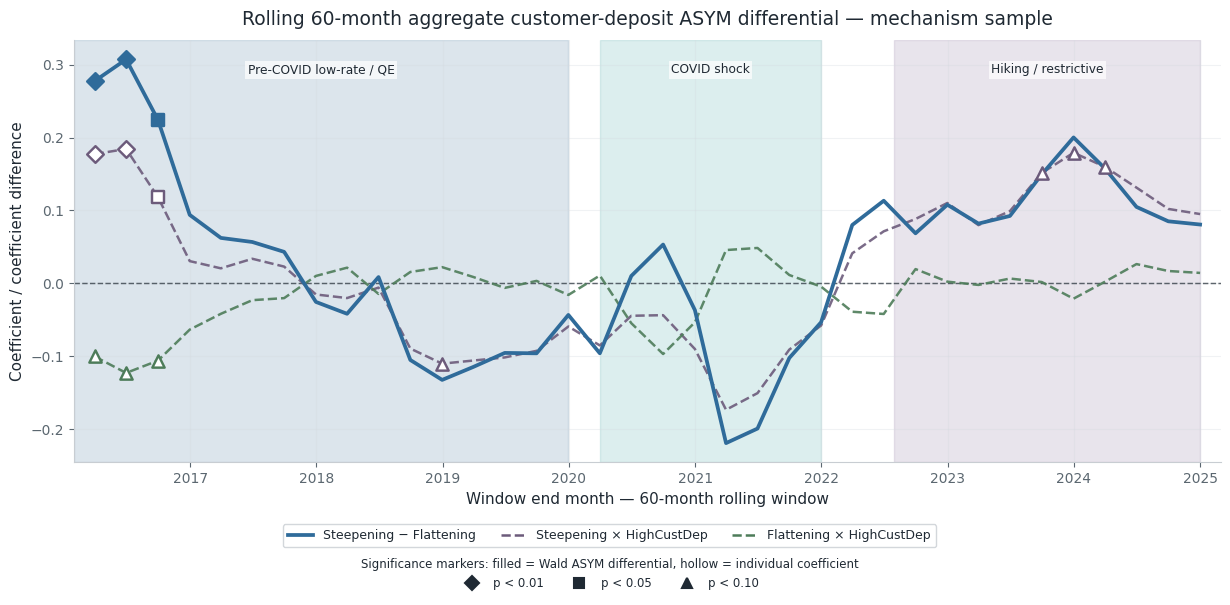

In [31]:
# ============================================================
# 15B. FIGURE 1B — ROLLING-WINDOW MAIN ASYM ON MECHANISM SAMPLE
# ============================================================

from matplotlib.lines import Line2D
import math

# Fallback only if this helper has not already been defined
if "wald_zero_linear_combo" not in globals():

    def wald_zero_linear_combo(res, weights, label):
        """
        Wald test for H0: sum_j weights[j] * beta_j = 0.
        Uses the model covariance matrix already stored in the regression result.
        """
        out = {
            "test": label,
            "ok": False,
            "estimate": np.nan,
            "se": np.nan,
            "t_stat": np.nan,
            "p_value": np.nan,
            "stars": "",
            "error": "",
        }

        if res is None or not res.get("ok", False):
            out["error"] = "Model not estimated"
            return out

        weights = {k: float(v) for k, v in weights.items() if k is not None and v != 0}
        vars_needed = list(weights.keys())

        missing = [
            v for v in vars_needed
            if v not in res.get("params", pd.Series(dtype=float)).index
            or pd.isna(res["params"].get(v, np.nan))
        ]

        if missing:
            out["error"] = f"Missing/absorbed coefficient(s): {missing}"
            return out

        cov = res.get("cov", pd.DataFrame())
        if cov is None or cov.empty:
            out["error"] = "Covariance matrix unavailable"
            return out

        try:
            b = res["params"].loc[vars_needed].to_numpy(float)
            V = cov.loc[vars_needed, vars_needed].to_numpy(float)
            w = np.array([weights[v] for v in vars_needed], dtype=float)

            estimate = float(w @ b)
            variance = float(w @ V @ w)
            se = math.sqrt(max(variance, 0.0))

            if se <= 0 or not np.isfinite(se):
                out["error"] = "Non-positive standard error"
                return out

            t_stat = estimate / se
            p_value = float(math.erfc(abs(t_stat) / math.sqrt(2.0)))

            out.update({
                "ok": True,
                "estimate": estimate,
                "se": se,
                "t_stat": t_stat,
                "p_value": p_value,
                "stars": stars(p_value) if "stars" in globals() else "",
                "error": "",
            })

            return out

        except Exception as exc:
            out["error"] = str(exc)
            return out


if (
    RUN_ROLLING_WINDOWS
    and MECH_READY
    and "df_mech" in globals()
    and isinstance(df_mech, pd.DataFrame)
    and not df_mech.empty
):

    PLOT_START = pd.Timestamp("2016-01-31")
    SHOW_COEF_SIG = True
    SHOW_UNDERLYING = globals().get("SHOW_ROLLING_UNDERLYING_COEFFICIENTS", True)

    REGIMES = [
        ("Pre-COVID low-rate / QE", "2016-01-31", "2019-12-31", WP_SHADE_BLUE),
        ("COVID shock", "2020-03-31", "2021-12-31", WP_SHADE_TEAL),
        ("Hiking / restrictive", "2022-07-31", "2024-12-31", WP_SHADE_PURPLE),
    ]

    SERIES = {
        "asym":  (WP_BLUE,   "-",  2.7, "Steepening − Flattening"),
        "steep": (WP_PURPLE, "--", 1.8, "Steepening × HighCustDep"),
        "flat":  (WP_GREEN,  "--", 1.8, "Flattening × HighCustDep"),
    }

    SIG = [(0.01, "D", "p < 0.01"), (0.05, "s", "p < 0.05"), (0.10, "^", "p < 0.10")]

    def sig_level(p):
        return np.select(
            [p < 0.01, p < 0.05, p < 0.10],
            ["1%", "5%", "10%"],
            default="",
        )

    def add_sig(ax, d, y, p, color, filled=False, z=8):
        lo = 0.0
        for hi, marker, _ in SIG:
            s = d[d[p].notna() & (d[p] < hi) & (d[p] >= lo)]
            if not s.empty:
                ax.scatter(
                    s["window_end"], s[y],
                    marker=marker,
                    s=78 if marker != "D" else 72,
                    facecolor=color if filled else WP_AX_BG,
                    edgecolor=color,
                    linewidth=1.75,
                    zorder=z,
                )
            lo = hi

    # -----------------------------
    # Same-sample setup
    # -----------------------------

    months = pd.Series(sorted(pd.to_datetime(df_mech[MONTH_COL].dropna().unique())))

    # Regression remains the aggregate ASYM specification
    rolling_regs = [HIGH_CUSTDEP, STEPP_CUST, FLAT_CUST, *CONTROLS_MAIN]

    # These variables force the aggregate ASYM test to use the same
    # mechanism-sample availability as the deposit-composition test.
    mech_sample_lock = [HIGH_DEMAND, HIGH_TIME_SAVINGS, DEMAND_STEEP, TIME_STEEP]

    if ROLLING_INCLUDE_FLATTENING:
        mech_sample_lock += [DEMAND_FLAT, TIME_FLAT]

    rows = []

    for end_i in range(ROLLING_WINDOW_MONTHS - 1, len(months), ROLLING_STEP_MONTHS):
        start = months.iloc[end_i - ROLLING_WINDOW_MONTHS + 1]
        end = months.iloc[end_i]

        window = df_mech[df_mech[MONTH_COL].between(start, end)].copy()

        needed = [
            DEPENDENT_VAR,
            *rolling_regs,
            *mech_sample_lock,
            BANK_COL,
            MONTH_COL,
            DATE_COL,
        ]

        missing = [c for c in needed if c not in window.columns]
        if missing:
            warn_msg(
                f"Rolling same-sample main ASYM skipped for {start:%Y-%m} to {end:%Y-%m}; "
                f"missing columns: {missing}"
            )
            continue

        work = subset_complete_case(
            window,
            needed,
            label=f"rolling same-sample main ASYM {start:%Y-%m} to {end:%Y-%m}",
            allow_missing=True,
        )

        if work[BANK_COL].nunique() < ROLLING_MIN_BANKS or len(work) < ROLLING_MIN_OBS:
            continue

        res = fit_panel(
            work,
            DEPENDENT_VAR,
            rolling_regs,
            model_name=f"Rolling same-sample main ASYM: {start:%Y-%m} to {end:%Y-%m}",
            verbose=False,
        )

        # Main H1-style differential:
        # H0: β_steep − β_flat = 0
        w_asym = wald_zero_linear_combo(
            res,
            {STEPP_CUST: 1.0, FLAT_CUST: -1.0},
            label="Rolling same-sample ASYM differential: β_steep − β_flat = 0",
        )

        # Optional extra test:
        # H0: β_steep + β_flat = 0
        w_opp = wald_zero_linear_combo(
            res,
            {STEPP_CUST: 1.0, FLAT_CUST: 1.0},
            label="Rolling same-sample opposite-sign magnitude: β_steep + β_flat = 0",
        )

        rows.append({
            "window_start": start,
            "window_end": end,

            "steep_coef": get_stat(res, STEPP_CUST, "coef"),
            "steep_se": get_stat(res, STEPP_CUST, "se"),
            "steep_p": get_stat(res, STEPP_CUST, "p"),

            "flat_coef": get_stat(res, FLAT_CUST, "coef"),
            "flat_se": get_stat(res, FLAT_CUST, "se"),
            "flat_p": get_stat(res, FLAT_CUST, "p"),

            "asym_diff": w_asym.get("estimate", np.nan),
            "asym_diff_se": w_asym.get("se", np.nan),
            "asym_diff_t": w_asym.get("t_stat", np.nan),
            "asym_diff_p": w_asym.get("p_value", np.nan),

            "opp_sign_mag": w_opp.get("estimate", np.nan),
            "opp_sign_mag_se": w_opp.get("se", np.nan),
            "opp_sign_mag_t": w_opp.get("t_stat", np.nan),
            "opp_sign_mag_p": w_opp.get("p_value", np.nan),

            "nobs": res.get("nobs", np.nan),
            "banks": res.get("n_banks", np.nan),
            "months": res.get("n_months", np.nan),
            "status": "OK" if res.get("ok", False) else res.get("error", ""),
            "wald_asym_status": "OK" if w_asym.get("ok", False) else w_asym.get("error", ""),
            "wald_opp_status": "OK" if w_opp.get("ok", False) else w_opp.get("error", ""),
        })

    rolling_asym_mechsample_table = pd.DataFrame(rows)

    if rolling_asym_mechsample_table.empty:
        warn_msg("Rolling-window same-sample main ASYM table is empty; check variables and sample coverage.")

    else:
        rolling_asym_mechsample_table["asym_sig_level"] = sig_level(
            rolling_asym_mechsample_table["asym_diff_p"]
        )
        rolling_asym_mechsample_table["steep_sig_level"] = sig_level(
            rolling_asym_mechsample_table["steep_p"]
        )
        rolling_asym_mechsample_table["flat_sig_level"] = sig_level(
            rolling_asym_mechsample_table["flat_p"]
        )
        rolling_asym_mechsample_table["opp_sign_mag_sig_level"] = sig_level(
            rolling_asym_mechsample_table["opp_sign_mag_p"]
        )

        out_csv = OUT_DIR / "11b_figure1b_rolling_main_asym_mechanism_sample.csv"

        rolling_asym_mechsample_table.assign(
            window_start=lambda x: pd.to_datetime(x["window_start"]).dt.strftime("%Y-%m"),
            window_end=lambda x: pd.to_datetime(x["window_end"]).dt.strftime("%Y-%m"),
        ).to_csv(out_csv, index=False)

        print(f"Saved: {out_csv.resolve()}")

        plot_df = (
            rolling_asym_mechsample_table
            .sort_values("window_end")
            .loc[lambda x: x["window_end"] >= PLOT_START]
            .copy()
        )

        if plot_df.empty:
            warn_msg("No rolling-window same-sample main ASYM observations remain after applying PLOT_START.")

        else:
            # -----------------------------
            # Plot
            # -----------------------------

            fig, ax = plt.subplots(figsize=(12.6, 6.3))
            fig.patch.set_facecolor(WP_FIG_BG)
            ax.set_facecolor(WP_AX_BG)

            xmax = plot_df["window_end"].max() + pd.DateOffset(months=2)

            for label, start, end, color in REGIMES:
                start = max(pd.Timestamp(start), PLOT_START)
                end = min(pd.Timestamp(end), xmax)

                if end <= start:
                    continue

                ax.axvspan(start, end, color=color, alpha=0.30, zorder=0)
                ax.text(
                    start + (end - start) / 2,
                    0.945,
                    label,
                    transform=ax.get_xaxis_transform(),
                    ha="center",
                    va="top",
                    fontsize=8.8,
                    color=WP_TEXT,
                    bbox=dict(facecolor=WP_AX_BG, edgecolor="none", alpha=0.70, pad=1.8),
                    zorder=10,
                )

            # Main same-sample ASYM differential
            color, ls, lw, lab = SERIES["asym"]
            ax.plot(
                plot_df["window_end"],
                plot_df["asym_diff"],
                color=color,
                linestyle=ls,
                linewidth=lw,
                label=lab,
                zorder=5,
            )

            # Underlying steepening and flattening coefficients
            if SHOW_UNDERLYING:
                for key, y in [("steep", "steep_coef"), ("flat", "flat_coef")]:
                    color, ls, lw, lab = SERIES[key]
                    ax.plot(
                        plot_df["window_end"],
                        plot_df[y],
                        color=color,
                        linestyle=ls,
                        linewidth=lw,
                        alpha=0.90,
                        label=lab,
                        zorder=4,
                    )

            # Significance markers
            add_sig(ax, plot_df, "asym_diff", "asym_diff_p", SERIES["asym"][0], filled=True, z=9)

            if SHOW_UNDERLYING and SHOW_COEF_SIG:
                add_sig(ax, plot_df, "steep_coef", "steep_p", SERIES["steep"][0], filled=False, z=8)
                add_sig(ax, plot_df, "flat_coef", "flat_p", SERIES["flat"][0], filled=False, z=8)

            # Formatting
            ax.axhline(0, color=WP_TEXT, linestyle="--", linewidth=1.05, alpha=0.70, zorder=2)
            ax.set_xlim(PLOT_START, xmax)
            ax.set_title(
                "Rolling 60-month aggregate customer-deposit ASYM differential — mechanism sample",
                fontsize=13.5,
                pad=11,
            )
            ax.set_xlabel("Window end month — 60-month rolling window", fontsize=11)
            ax.set_ylabel("Coefficient / coefficient difference", fontsize=11)
            ax.grid(True, color=WP_GRID, alpha=0.34)

            for spine in ["top", "right"]:
                ax.spines[spine].set_visible(False)

            series_keys = ["asym", "steep", "flat"] if SHOW_UNDERLYING else ["asym"]

            series_handles = [
                Line2D(
                    [0], [0],
                    color=SERIES[k][0],
                    linestyle=SERIES[k][1],
                    linewidth=SERIES[k][2],
                    label=SERIES[k][3],
                )
                for k in series_keys
            ]

            sig_handles = [
                Line2D(
                    [0], [0],
                    marker=m,
                    color="none",
                    markerfacecolor=WP_TEXT,
                    markeredgecolor=WP_TEXT,
                    markeredgewidth=1.5,
                    markersize=7,
                    label=lab,
                )
                for _, m, lab in SIG
            ]

            fig.legend(
                handles=series_handles,
                loc="lower center",
                bbox_to_anchor=(0.5, 0.08),
                ncol=len(series_handles),
                frameon=True,
                facecolor=WP_AX_BG,
                edgecolor=WP_BORDER,
                fontsize=9,
            )

            fig.legend(
                handles=sig_handles,
                loc="lower center",
                bbox_to_anchor=(0.5, 0.005),
                ncol=3,
                frameon=False,
                fontsize=8.5,
                title="Significance markers: filled = Wald ASYM differential, hollow = individual coefficient",
                title_fontsize=8.5,
            )

            fig.subplots_adjust(left=0.075, right=0.985, top=0.895, bottom=0.225)

            fig_path = OUT_DIR / "11b_figure1b_rolling_main_asym_mechanism_sample.png"
            fig.savefig(fig_path, dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())
            print(f"Saved figure: {fig_path.resolve()}")

else:
    print(
        "Rolling-window same-sample main ASYM plot skipped. "
        "Set RUN_ROLLING_WINDOWS=True and ensure MECH_READY=True and df_mech is available."
    )

# E. Robustness and sensitivity checks

This block is designed to make the caveats easy to audit: asset-side channels, continuous deposit exposure, alternative slope definitions, two-way clustering, residual correlation, leave-one-out, and winsorization.


## E.1 Table R1 — Loan-share / asset-side horse race

Compares the aggregate deposit channel with loan-share level and loan-share interaction specifications.


In [32]:

# ============================================================
# 16. TABLE R1 — LOAN-SHARE / ASSET-SIDE COMPARISON
# ============================================================

regs_loan_level = [HIGH_CUSTDEP, STEPP_CUST, FLAT_CUST, "loan_share_zstd", *CONTROLS_MAIN]
regs_loan_interactions = [HIGH_CUSTDEP, STEPP_CUST, FLAT_CUST, "loan_share_zstd", "steepening_x_loan_share_zstd", "flattening_x_loan_share_zstd", *CONTROLS_MAIN]

specs_r1 = {
    "Loan-share level": ModelSpec(df_loan, DEPENDENT_VAR, regs_loan_level, "R1: loan-share level control", keys=[STEPP_CUST]),
    "+ loan-share interactions": ModelSpec(df_loan, DEPENDENT_VAR, regs_loan_interactions, "R1: loan-share level + steep/flat interactions", keys=[STEPP_CUST]),
}
res_r1 = run_model_specs(specs_r1)

coef_rows_r1 = {
    "steepening": STEPP_CUST,
    "flattening": FLAT_CUST,
    "loan_level": "loan_share_zstd",
    "loan_steep": "steepening_x_loan_share_zstd",
    "loan_flat": "flattening_x_loan_share_zstd",
    "tier1": "tier1_ratio_reg",
    "size": "size_reg",
}
row_labels_r1 = {
    "steepening": "Steepening × HighCustDep",
    "flattening": "Flattening × HighCustDep",
    "loan_level": "Loan share z-score",
    "loan_steep": "Steepening × Loan share z-score",
    "loan_flat": "Flattening × Loan share z-score",
    "tier1": "Tier 1 ratio",
    "size": "Size",
}

table_r1 = print_multi_table(
    res_r1,
    ["Loan-share level", "+ loan-share interactions"],
    coef_rows_r1,
    row_labels_r1,
    "ROBUSTNESS TABLE R1 — LOAN-SHARE / ASSET-SIDE COMPARISON",
    "12_table_r1_loan_share_asset_side_comparison.csv",
)

all_results["table_r1_loan_share"] = res_r1
all_tables["table_r1_loan_share"] = table_r1


WCB: Loan-share level | steepening_x_high_custdep
WCB: + loan-share interactions | steepening_x_high_custdep

ROBUSTNESS TABLE R1 — LOAN-SHARE / ASSET-SIDE COMPARISON
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
                       Variable      (1) Loan-share level (2) + loan-share interactions
       Steepening × HighCustDep                  0.0811**                        0.0374
                                                 (0.0395)                      (0.0418)
                                                [p=0.040]                     [p=0.371]
                                            [WCB p=0.050]                 [WCB p=0.409]
       Flattening × HighCustDep                   -0.0184                        0.0085
                                                 (0.0325)                      (0.0358)
                                                [p=0.572]                     [p=0.813]
    

## Table R1b - Quadrant


ANNUAL BANK-YEAR QUADRANT SPLIT CHECK
Customer-deposit variable used : custdep_ratio_reg
Loan-share variable used       : loan_share_reg
Date variable used             : date
High-deposit and high-loan indicators are computed from bank-year medians.
Classification rule            : bank-year median >= yearly cross-bank median
Reference group                : Low deposit / Low loan

ANNUAL SPLIT THRESHOLDS


,year,custdep_yearly_cross_bank_median,loan_share_yearly_cross_bank_median
0,2011,0.406693,0.601447
1,2012,0.443464,0.571173
2,2013,0.488608,0.574214
3,2014,0.519286,0.590363
4,2015,0.566308,0.606301
5,2016,0.594368,0.603069
6,2017,0.587074,0.612818
7,2018,0.610295,0.640470
8,2019,0.633721,0.643673
9,2020,0.616410,0.611807


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\quadrant_annual_split_thresholds.csv

QUADRANT SAMPLE COVERAGE


,quadrant_label,observations,banks,months,mean_excess_return,mean_steepening,mean_custdep,mean_loan_share
0,Low deposit / Low loan,1824,17,165,0.006615,0.042199,0.393153,0.418793
1,High deposit / Low loan,804,12,165,0.009057,0.042773,0.730542,0.525771
2,Low deposit / High loan,800,14,165,0.007371,0.042959,0.484540,0.664715
3,High deposit / High loan,1890,19,165,0.009617,0.042179,0.681202,0.711448


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\quadrant_sample_coverage.csv
WCB: Quadrant split | steepening_x_highdep_highloan
WCB: Quadrant split | steepening_x_highdep_lowloan
WCB: Quadrant split | steepening_x_lowdep_highloan

ROBUSTNESS TABLE — CUSTDEP × LOANSHARE QUADRANT SPLIT
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
                             Variable        (1) Quadrant split
Steepening × High deposit / High loan                  0.1011**
                                                       (0.0437)
                                                      [p=0.021]
                                                  [WCB p=0.034]
 Steepening × High deposit / Low loan                   -0.0057
                                                       (0.0354)
                                               

,test,diff,se_diff,t_stat,p_value,stars,ok,error
0,HighDep/HighLoan − HighDep/LowLoan = 0,0.106850,0.045367,2.355232,0.018511,**,True,
1,HighDep/HighLoan − LowDep/HighLoan = 0,0.098343,0.057326,1.715502,0.086253,*,True,
2,HighDep/LowLoan − LowDep/HighLoan = 0,-0.008507,0.046552,-0.182745,0.854998,,True,


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\quadrant_split_wald_tests_fixed.csv

Typical positive steepening month: 0.0861

QUADRANT ECONOMIC MAGNITUDES


,quadrant,interaction,coef_vs_low_low,se,p_value,stars,effect_in_typical_steepening_month
0,Low deposit / Low loan,Reference,0.000000,NaN,NaN,,0.000000
1,High deposit / Low loan,steepening_x_highdep_lowloan,-0.005707,0.035441,0.872075,,-0.000491
2,Low deposit / High loan,steepening_x_lowdep_highloan,0.002800,0.041789,0.946579,,0.000241
3,High deposit / High loan,steepening_x_highdep_highloan,0.101143,0.043707,0.020701,**,0.008710


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\quadrant_split_economic_magnitudes.csv
Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\quadrant_split_steepening_premium.png


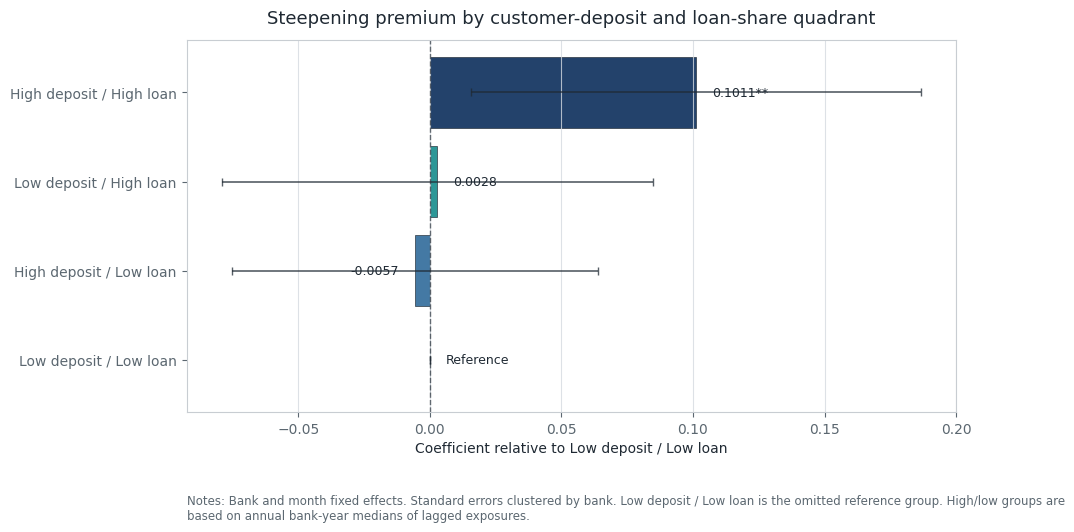

In [33]:
# ============================================================
# ROBUSTNESS / MECHANISM EXTENSION — CUSTDEP × LOANSHARE QUADRANT SPLIT
# Annual bank-year median construction:
#
#   X_tilde_{i,y} = Median_{t in y}(X_{i,t-12})
#   HighX_{i,y}   = 1[X_tilde_{i,y} >= Median_j(X_tilde_{j,y})]
#
# Tests whether the steepening premium is strongest when a bank has
# both high customer-deposit exposure and high loan-share exposure.
#
# Reference group: Low deposit / Low loan
# Coefficients are therefore relative to Low deposit / Low loan.
# ============================================================

RUN_QUADRANT_SPLIT = True
ATTACH_WCB_QUADRANT = True # Set True only for final/slower WCB run

if RUN_QUADRANT_SPLIT:

    # ------------------------------------------------------------
    # 0. Safe globals / setup
    # ------------------------------------------------------------
    all_results = globals().setdefault("all_results", {})
    all_tables = globals().setdefault("all_tables", {})
    all_wald = globals().setdefault("all_wald", {})

    def _qnum(x):
        if "as_numeric" in globals():
            return as_numeric(x)
        return pd.to_numeric(x, errors="coerce").replace([np.inf, -np.inf], np.nan)

    def _qstars(p):
        if "stars" in globals():
            return stars(p)
        if pd.isna(p):
            return ""
        return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""

    # Use loan-share sample if already created; otherwise fall back to main sample.
    df_quad_base = (
        df_loan.copy()
        if "df_loan" in globals() and isinstance(df_loan, pd.DataFrame) and not df_loan.empty
        else df_main.copy()
    )

    # ------------------------------------------------------------
    # 1. Detect required variables
    # ------------------------------------------------------------
    custdep_col = find_first(df_quad_base, [
        "custdep_ratio_reg",
        "custdep_zstd",
        "custdep_ratio",
        "customer_deposits_assets",
        "custdep_assets",
    ])

    loan_col = find_first(df_quad_base, [
        "loan_share_reg",
        "loan_share_zstd",
        "loan_asset_share_reg",
        "loans_share_reg",
        "loan_share",
    ])

    if custdep_col is None:
        raise KeyError("No customer-deposit exposure column found for quadrant split.")

    if loan_col is None:
        raise KeyError("No loan-share column found for quadrant split.")

    if "steepening" not in df_quad_base.columns:
        if "delta_slope" not in df_quad_base.columns:
            raise KeyError("Neither 'steepening' nor 'delta_slope' found.")
        df_quad_base["steepening"] = _qnum(df_quad_base["delta_slope"]).clip(lower=0)

    split_date_col = DATE_COL if DATE_COL in df_quad_base.columns else MONTH_COL

    controls_quad = [
        c for c in globals().get("CONTROLS_MAIN", ["tier1_ratio_reg", "size_reg"])
        if c in df_quad_base.columns
    ]

    required_pre = [
        DEPENDENT_VAR,
        "steepening",
        custdep_col,
        loan_col,
        *controls_quad,
    ]

    df_quad_base = subset_complete_case(
        df_quad_base,
        [BANK_COL, MONTH_COL, split_date_col, *required_pre],
        label="df_quadrant_pre_sample",
        allow_missing=False,
    ).copy()

    # ------------------------------------------------------------
    # 2. Annual bank-year median split
    # ------------------------------------------------------------
    def annual_bank_year_median_split(df, var_col, out_col, bank_col, date_col):
        """
        Creates annual high/low exposure dummy using the intended formula:

        Step 1:
            X_tilde_{i,y} = median of lagged exposure X_{i,t-12}
                             within bank i and year y.

        Step 2:
            HighX_{i,y} = 1 if X_tilde_{i,y} >= cross-sectional
                          median across banks in year y.

        Important:
        The cross-sectional yearly median is computed across unique bank-year
        observations, not across repeated monthly rows. This avoids giving
        extra weight to banks with more monthly observations.
        """

        x = _qnum(df[var_col])

        year_col = f"{out_col}_split_year"
        bank_year_median_col = f"{out_col}_bank_year_median"
        year_cross_median_col = f"{out_col}_year_cross_bank_median"

        df[year_col] = pd.to_datetime(df[date_col]).dt.year

        # Step 1: bank-year median of the lagged exposure variable
        df[bank_year_median_col] = (
            x.groupby([df[bank_col], df[year_col]]).transform("median")
        )

        # Build unique bank-year table to compute the yearly cross-bank median properly
        bank_year_table = (
            df[[bank_col, year_col, bank_year_median_col]]
            .dropna(subset=[bank_year_median_col])
            .drop_duplicates(subset=[bank_col, year_col])
            .copy()
        )

        yearly_thresholds = (
            bank_year_table
            .groupby(year_col, as_index=False)[bank_year_median_col]
            .median()
            .rename(columns={bank_year_median_col: year_cross_median_col})
        )

        df.drop(columns=[year_cross_median_col], errors="ignore", inplace=True)

        df.merge(
            yearly_thresholds,
            on=year_col,
            how="left",
            copy=False,
        )

        # The merge above does not modify df in place reliably, so assign explicitly
        df_threshold_map = yearly_thresholds.set_index(year_col)[year_cross_median_col]
        df[year_cross_median_col] = df[year_col].map(df_threshold_map)

        # Step 2: high dummy using >=, matching the thesis formula
        df[out_col] = np.where(
            df[bank_year_median_col].notna() & df[year_cross_median_col].notna(),
            (df[bank_year_median_col] >= df[year_cross_median_col]).astype(int),
            np.nan,
        )

        return out_col, year_col, bank_year_median_col, year_cross_median_col

    HIGH_DEP_DYNAMIC = "quad_high_dep_annual"
    HIGH_LOAN_DYNAMIC = "quad_high_loan_annual"

    (
        HIGH_DEP_DYNAMIC,
        DEP_YEAR_COL,
        DEP_BANK_YEAR_MEDIAN_COL,
        DEP_YEAR_CROSS_MEDIAN_COL,
    ) = annual_bank_year_median_split(
        df_quad_base,
        custdep_col,
        HIGH_DEP_DYNAMIC,
        BANK_COL,
        split_date_col,
    )

    (
        HIGH_LOAN_DYNAMIC,
        LOAN_YEAR_COL,
        LOAN_BANK_YEAR_MEDIAN_COL,
        LOAN_YEAR_CROSS_MEDIAN_COL,
    ) = annual_bank_year_median_split(
        df_quad_base,
        loan_col,
        HIGH_LOAN_DYNAMIC,
        BANK_COL,
        split_date_col,
    )

    # Complete cases after annual split construction
    required_quad = [
        DEPENDENT_VAR,
        "steepening",
        custdep_col,
        loan_col,
        HIGH_DEP_DYNAMIC,
        HIGH_LOAN_DYNAMIC,
        *controls_quad,
    ]

    df_quad = subset_complete_case(
        df_quad_base,
        [BANK_COL, MONTH_COL, split_date_col, *required_quad],
        label="df_quadrant_annual_bank_year_median_sample",
        allow_missing=False,
    ).copy()

    df_quad[HIGH_DEP_DYNAMIC] = df_quad[HIGH_DEP_DYNAMIC].astype(int)
    df_quad[HIGH_LOAN_DYNAMIC] = df_quad[HIGH_LOAN_DYNAMIC].astype(int)

    # ------------------------------------------------------------
    # 3. Four quadrant indicators
    # ------------------------------------------------------------
    Q_HH = "quad_highdep_highloan"
    Q_HL = "quad_highdep_lowloan"
    Q_LH = "quad_lowdep_highloan"
    Q_LL = "quad_lowdep_lowloan"      # omitted reference

    df_quad[Q_HH] = (
        (df_quad[HIGH_DEP_DYNAMIC] == 1) &
        (df_quad[HIGH_LOAN_DYNAMIC] == 1)
    ).astype(int)

    df_quad[Q_HL] = (
        (df_quad[HIGH_DEP_DYNAMIC] == 1) &
        (df_quad[HIGH_LOAN_DYNAMIC] == 0)
    ).astype(int)

    df_quad[Q_LH] = (
        (df_quad[HIGH_DEP_DYNAMIC] == 0) &
        (df_quad[HIGH_LOAN_DYNAMIC] == 1)
    ).astype(int)

    df_quad[Q_LL] = (
        (df_quad[HIGH_DEP_DYNAMIC] == 0) &
        (df_quad[HIGH_LOAN_DYNAMIC] == 0)
    ).astype(int)

    # Sanity check
    df_quad["quad_sum_check"] = df_quad[[Q_HH, Q_HL, Q_LH, Q_LL]].sum(axis=1)

    if not (df_quad["quad_sum_check"] == 1).all():
        raise ValueError(
            "Quadrant construction failed: some observations are not assigned to exactly one group."
        )

    df_quad["quadrant_label"] = np.select(
        [
            df_quad[Q_HH].eq(1),
            df_quad[Q_HL].eq(1),
            df_quad[Q_LH].eq(1),
            df_quad[Q_LL].eq(1),
        ],
        [
            "High deposit / High loan",
            "High deposit / Low loan",
            "Low deposit / High loan",
            "Low deposit / Low loan",
        ],
        default="Unassigned",
    )

    print("\nANNUAL BANK-YEAR QUADRANT SPLIT CHECK")
    print(f"Customer-deposit variable used : {custdep_col}")
    print(f"Loan-share variable used       : {loan_col}")
    print(f"Date variable used             : {split_date_col}")
    print("High-deposit and high-loan indicators are computed from bank-year medians.")
    print("Classification rule            : bank-year median >= yearly cross-bank median")
    print("Reference group                : Low deposit / Low loan")

    # ------------------------------------------------------------
    # 4. Split-threshold diagnostics
    # ------------------------------------------------------------
    split_thresholds = (
        df_quad[
            [
                DEP_YEAR_COL,
                DEP_YEAR_CROSS_MEDIAN_COL,
                LOAN_YEAR_CROSS_MEDIAN_COL,
            ]
        ]
        .drop_duplicates()
        .rename(columns={
            DEP_YEAR_COL: "year",
            DEP_YEAR_CROSS_MEDIAN_COL: "custdep_yearly_cross_bank_median",
            LOAN_YEAR_CROSS_MEDIAN_COL: "loan_share_yearly_cross_bank_median",
        })
        .sort_values("year")
        .reset_index(drop=True)
    )

    print("\nANNUAL SPLIT THRESHOLDS")
    show_df(split_thresholds)
    save_table(split_thresholds, "quadrant_annual_split_thresholds.csv", display_table=False)

    # ------------------------------------------------------------
    # 5. Steepening × quadrant interactions
    #    Low deposit / Low loan is omitted because with month FE,
    #    all four interactions sum to the common monthly steepening shock.
    # ------------------------------------------------------------
    S_HH = "steepening_x_highdep_highloan"
    S_HL = "steepening_x_highdep_lowloan"
    S_LH = "steepening_x_lowdep_highloan"

    df_quad[S_HH] = _qnum(df_quad["steepening"]) * df_quad[Q_HH]
    df_quad[S_HL] = _qnum(df_quad["steepening"]) * df_quad[Q_HL]
    df_quad[S_LH] = _qnum(df_quad["steepening"]) * df_quad[Q_LH]

    # Include quadrant level dummies as lower-order terms.
    # Low deposit / Low loan remains the omitted reference group.
    regs_quad = [
        Q_HH,
        Q_HL,
        Q_LH,
        S_HH,
        S_HL,
        S_LH,
        *controls_quad,
    ]

    df_quad = make_complete_sample(
        df_quad,
        [DEPENDENT_VAR, *regs_quad],
        "df_quadrant — annual CustDep × LoanShare quadrant sample",
    )

    # ------------------------------------------------------------
    # 6. Quadrant coverage table
    # ------------------------------------------------------------
    quad_counts = (
        df_quad
        .groupby("quadrant_label")
        .agg(
            observations=(DEPENDENT_VAR, "size"),
            banks=(BANK_COL, "nunique"),
            months=(MONTH_COL, "nunique"),
            mean_excess_return=(DEPENDENT_VAR, "mean"),
            mean_steepening=("steepening", "mean"),
            mean_custdep=(custdep_col, "mean"),
            mean_loan_share=(loan_col, "mean"),
        )
        .reset_index()
    )

    quad_order = [
        "Low deposit / Low loan",
        "High deposit / Low loan",
        "Low deposit / High loan",
        "High deposit / High loan",
    ]

    quad_counts["quadrant_label"] = pd.Categorical(
        quad_counts["quadrant_label"],
        categories=quad_order,
        ordered=True,
    )

    quad_counts = quad_counts.sort_values("quadrant_label").reset_index(drop=True)

    print("\nQUADRANT SAMPLE COVERAGE")
    show_df(quad_counts)
    save_table(quad_counts, "quadrant_sample_coverage.csv", display_table=False)

    # ------------------------------------------------------------
    # 7. Estimate quadrant regression
    # ------------------------------------------------------------
    specs_quad = {
        "Quadrant split": ModelSpec(
            df_quad,
            DEPENDENT_VAR,
            regs_quad,
            "Quadrant split: CustDep × LoanShare steepening exposure",
            keys=[S_HH, S_HL, S_LH],
        )
    }

    res_quad = run_model_specs(specs_quad, attach_wcb=ATTACH_WCB_QUADRANT)

    coef_rows_quad = {
        "s_hh": S_HH,
        "s_hl": S_HL,
        "s_lh": S_LH,
        "q_hh": Q_HH,
        "q_hl": Q_HL,
        "q_lh": Q_LH,
        "tier1": "tier1_ratio_reg",
        "size": "size_reg",
    }

    row_labels_quad = {
        "s_hh": "Steepening × High deposit / High loan",
        "s_hl": "Steepening × High deposit / Low loan",
        "s_lh": "Steepening × Low deposit / High loan",
        "q_hh": "High deposit / High loan dummy",
        "q_hl": "High deposit / Low loan dummy",
        "q_lh": "Low deposit / High loan dummy",
        "tier1": "Tier 1 ratio",
        "size": "Size",
    }

    table_quad = print_multi_table(
        res_quad,
        ["Quadrant split"],
        coef_rows_quad,
        row_labels_quad,
        "ROBUSTNESS TABLE — CUSTDEP × LOANSHARE QUADRANT SPLIT",
        "quadrant_split_custdep_loanshare.csv",
    )

    all_results["quadrant_split_custdep_loanshare"] = res_quad
    all_tables["quadrant_split_custdep_loanshare"] = table_quad
    
    # ============================================================
    # SAFE QUADRANT WALD TESTS
    # Fixes: 'dict' object has no attribute 'norm'
    # Cause: global name `stats` was overwritten somewhere.
    # ============================================================

    import math
    import numpy as np
    import pandas as pd

    try:
        from scipy import stats as sp_stats
        SCIPY_STATS_SAFE = True
    except Exception:
        SCIPY_STATS_SAFE = False


    def safe_norm_pvalue(t_value):
        if pd.isna(t_value) or not np.isfinite(t_value):
            return np.nan

        if SCIPY_STATS_SAFE:
            return float(2 * sp_stats.norm.sf(abs(t_value)))

        return float(math.erfc(abs(t_value) / math.sqrt(2)))


    def safe_stars(p):
        if pd.isna(p):
            return ""
        if p < 0.01:
            return "***"
        if p < 0.05:
            return "**"
        if p < 0.10:
            return "*"
        return ""


    def safe_wald_equal_coefficients(res, var_a, var_b, label=""):
        out = {
            "test": label or f"{var_a} − {var_b} = 0",
            "var_a": var_a,
            "var_b": var_b,
            "ok": False,
            "diff": np.nan,
            "se_diff": np.nan,
            "t_stat": np.nan,
            "p_value": np.nan,
            "stars": "",
            "error": "",
        }

        if res is None or not res.get("ok", False):
            out["error"] = "Model not estimated"
            return out

        params = res.get("params", pd.Series(dtype=float))
        cov = res.get("cov", pd.DataFrame())

        if var_a not in params.index or var_b not in params.index:
            out["error"] = "One or both variables absent from estimated parameters"
            return out

        if cov is None or cov.empty:
            out["error"] = "Covariance matrix unavailable"
            return out

        if var_a not in cov.index or var_b not in cov.index:
            out["error"] = "One or both variables absent from covariance matrix"
            return out

        try:
            beta_a = params.loc[var_a]
            beta_b = params.loc[var_b]

            diff = beta_a - beta_b

            var_diff = (
                cov.loc[var_a, var_a]
                + cov.loc[var_b, var_b]
                - 2 * cov.loc[var_a, var_b]
            )

            if pd.isna(var_diff) or var_diff <= 0:
                out["error"] = f"Invalid variance of difference: {var_diff}"
                return out

            se_diff = np.sqrt(var_diff)
            t_stat = diff / se_diff
            p_value = safe_norm_pvalue(t_stat)

            out.update({
                "ok": True,
                "diff": diff,
                "se_diff": se_diff,
                "t_stat": t_stat,
                "p_value": p_value,
                "stars": safe_stars(p_value),
                "error": "",
            })

            return out

        except Exception as exc:
            out["error"] = str(exc)
            return out


    quad_model = res_quad["Quadrant split"]

    quad_wald_fixed = pd.DataFrame([
        safe_wald_equal_coefficients(
            quad_model,
            S_HH,
            S_HL,
            "HighDep/HighLoan − HighDep/LowLoan = 0",
        ),
        safe_wald_equal_coefficients(
            quad_model,
            S_HH,
            S_LH,
            "HighDep/HighLoan − LowDep/HighLoan = 0",
        ),
        safe_wald_equal_coefficients(
            quad_model,
            S_HL,
            S_LH,
            "HighDep/LowLoan − LowDep/HighLoan = 0",
        ),
    ])

    quad_wald_fixed_display = quad_wald_fixed[
        [
            "test",
            "diff",
            "se_diff",
            "t_stat",
            "p_value",
            "stars",
            "ok",
            "error",
        ]
    ].copy()

    print("\nQUADRANT WALD TESTS — FIXED")
    show_df(quad_wald_fixed_display)

    save_table(
        quad_wald_fixed_display,
        "quadrant_split_wald_tests_fixed.csv",
        display_table=False,
    )

    all_wald["quadrant_split_custdep_loanshare_fixed"] = quad_wald_fixed_display

    # ------------------------------------------------------------
    # 8. Economic-magnitude table
    #    Coefficients are relative to LowDep/LowLoan.
    # ------------------------------------------------------------
    positive_steepening = _qnum(df_quad.loc[df_quad["steepening"] > 0, "steepening"])
    typical_steepening = positive_steepening.mean()

    def _coef(var):
        return get_stat(quad_model, var, "coef")

    def _se(var):
        return get_stat(quad_model, var, "se")

    def _p(var):
        return get_stat(quad_model, var, "p")

    quad_effect_rows = [
        {
            "quadrant": "Low deposit / Low loan",
            "interaction": "Reference",
            "coef_vs_low_low": 0.0,
            "se": np.nan,
            "p_value": np.nan,
            "stars": "",
            "effect_in_typical_steepening_month": 0.0,
        },
        {
            "quadrant": "High deposit / Low loan",
            "interaction": S_HL,
            "coef_vs_low_low": _coef(S_HL),
            "se": _se(S_HL),
            "p_value": _p(S_HL),
            "stars": _qstars(_p(S_HL)),
            "effect_in_typical_steepening_month": _coef(S_HL) * typical_steepening,
        },
        {
            "quadrant": "Low deposit / High loan",
            "interaction": S_LH,
            "coef_vs_low_low": _coef(S_LH),
            "se": _se(S_LH),
            "p_value": _p(S_LH),
            "stars": _qstars(_p(S_LH)),
            "effect_in_typical_steepening_month": _coef(S_LH) * typical_steepening,
        },
        {
            "quadrant": "High deposit / High loan",
            "interaction": S_HH,
            "coef_vs_low_low": _coef(S_HH),
            "se": _se(S_HH),
            "p_value": _p(S_HH),
            "stars": _qstars(_p(S_HH)),
            "effect_in_typical_steepening_month": _coef(S_HH) * typical_steepening,
        },
    ]

    quad_effects = pd.DataFrame(quad_effect_rows)

    quad_effects["quadrant"] = pd.Categorical(
        quad_effects["quadrant"],
        categories=quad_order,
        ordered=True,
    )

    quad_effects = quad_effects.sort_values("quadrant").reset_index(drop=True)

    print(f"\nTypical positive steepening month: {typical_steepening:.4f}")
    print("\nQUADRANT ECONOMIC MAGNITUDES")
    show_df(quad_effects)
    save_table(quad_effects, "quadrant_split_economic_magnitudes.csv", display_table=False)

    all_tables["quadrant_split_economic_magnitudes"] = quad_effects

    # ------------------------------------------------------------
    # 10. Thesis-ready coefficient plot
    # ------------------------------------------------------------
    import matplotlib.pyplot as plt

    plot_df = quad_effects.copy()

    plot_df["ci_low"] = plot_df["coef_vs_low_low"] - 1.96 * plot_df["se"]
    plot_df["ci_high"] = plot_df["coef_vs_low_low"] + 1.96 * plot_df["se"]

    # Reference group has no estimated CI
    plot_df.loc[
        plot_df["interaction"].eq("Reference"),
        ["ci_low", "ci_high"],
    ] = 0.0

    BG = globals().get("WP_FIG_BG", "#FFFFFF")
    AX_BG = globals().get("WP_AX_BG", "#F7F9FB")
    BLUE = globals().get("WP_BLUE", "#2F6B9A")
    TEAL = globals().get("WP_TEAL", "#2A9D8F")
    NAVY = globals().get("WP_NAVY", "#0B2D5B")
    MUTED = globals().get("WP_MUTED", "#5B6770")
    GRID = globals().get("WP_GRID", "#D8DEE9")
    TEXT = globals().get("WP_TEXT", "#1F2933")

    color_map = {
        "Low deposit / Low loan": MUTED,
        "High deposit / Low loan": BLUE,
        "Low deposit / High loan": TEAL,
        "High deposit / High loan": NAVY,
    }

    fig, ax = plt.subplots(figsize=(10.8, 5.4))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(AX_BG)

    y = np.arange(len(plot_df))

    ax.barh(
        y,
        plot_df["coef_vs_low_low"],
        color=[color_map[str(q)] for q in plot_df["quadrant"]],
        alpha=0.90,
        edgecolor=TEXT,
        linewidth=0.5,
    )

    ax.errorbar(
        plot_df["coef_vs_low_low"],
        y,
        xerr=[
            plot_df["coef_vs_low_low"] - plot_df["ci_low"],
            plot_df["ci_high"] - plot_df["coef_vs_low_low"],
        ],
        fmt="none",
        ecolor=TEXT,
        elinewidth=1.2,
        capsize=3,
        alpha=0.75,
    )

    ax.axvline(0, color=TEXT, linestyle="--", linewidth=1.0, alpha=0.65)

    for idx, row in plot_df.iterrows():
        coef = row["coef_vs_low_low"]
        pval = row["p_value"]

        if row["interaction"] == "Reference":
            label = "Reference"
        else:
            label = f"{coef:.4f}{_qstars(pval)}"

        x_offset = 0.006 if coef >= 0 else -0.006
        ha = "left" if coef >= 0 else "right"

        ax.text(
            coef + x_offset,
            idx,
            label,
            va="center",
            ha=ha,
            fontsize=9,
            color=TEXT,
        )

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["quadrant"], fontsize=10)

    ax.set_xlabel("Coefficient relative to Low deposit / Low loan", fontsize=10)

    ax.set_title(
        "Steepening premium by customer-deposit and loan-share quadrant",
        fontsize=13,
        pad=12,
        color=TEXT,
    )

    ax.grid(True, axis="x", color=GRID, linewidth=0.8, alpha=0.8)
    ax.grid(False, axis="y")

    note = (
        "Notes: Bank and month fixed effects. Standard errors clustered by bank. "
        "Low deposit / Low loan is the omitted reference group. "
        "High/low groups are based on annual bank-year medians of lagged exposures."
    )

    ax.text(
        0.0,
        -0.22,
        note,
        transform=ax.transAxes,
        fontsize=8.5,
        color=MUTED,
        ha="left",
        va="top",
        wrap=True,
    )

    fig.tight_layout()

    if "save_figure" in globals():
        save_figure(fig, "quadrant_split_steepening_premium.png")
    else:
        plt.savefig(
            "quadrant_split_steepening_premium.png",
            dpi=240,
            bbox_inches="tight",
        )

    plt.show()


ANNUAL BANK-YEAR QUADRANT SPLIT CHECK
Customer-deposit variable used : custdep_ratio_reg
Loan-share variable used       : loan_share_reg
Date variable used             : date
High-deposit and high-loan indicators are computed from bank-year medians.
Classification rule            : bank-year median >= yearly cross-bank median
Reference group                : Low deposit / Low loan

ANNUAL SPLIT THRESHOLDS


,year,custdep_yearly_cross_bank_median,loan_share_yearly_cross_bank_median
0,2011,0.406693,0.601447
1,2012,0.443464,0.571173
2,2013,0.488608,0.574214
3,2014,0.519286,0.590363
4,2015,0.566308,0.606301
5,2016,0.594368,0.603069
6,2017,0.587074,0.612818
7,2018,0.610295,0.640470
8,2019,0.633721,0.643673
9,2020,0.616410,0.611807


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\quadrant_annual_split_thresholds.csv

QUADRANT SAMPLE COVERAGE


,quadrant_label,observations,banks,months,mean_excess_return,mean_steepening,mean_flattening,mean_custdep,mean_loan_share
0,Low deposit / Low loan,1824,17,165,0.006615,0.042199,-0.048383,0.393153,0.418793
1,High deposit / Low loan,804,12,165,0.009057,0.042773,-0.050989,0.730542,0.525771
2,Low deposit / High loan,800,14,165,0.007371,0.042959,-0.050935,0.484540,0.664715
3,High deposit / High loan,1890,19,165,0.009617,0.042179,-0.048409,0.681202,0.711448


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\quadrant_sample_coverage.csv
WCB: Quadrant ASYM split | steepening_x_highdep_highloan
WCB: Quadrant ASYM split | steepening_x_highdep_lowloan
WCB: Quadrant ASYM split | steepening_x_lowdep_highloan
WCB: Quadrant ASYM split | flattening_x_highdep_highloan
WCB: Quadrant ASYM split | flattening_x_highdep_lowloan
WCB: Quadrant ASYM split | flattening_x_lowdep_highloan

ROBUSTNESS TABLE — CUSTDEP × LOANSHARE QUADRANT ASYM SPLIT
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
                             Variable   (1) Quadrant ASYM split
Steepening × High deposit / High loan                  0.1170**
                                                       (0.0466)
                                                      [p=0.012]
                                                  

,test,estimate,se,t_stat,p_value,stars,ok,error
0,Steepening: HighDep/HighLoan − HighDep/LowLoan...,0.113332,0.047562,2.382808,0.017181,**,True,
1,Steepening: HighDep/HighLoan − LowDep/HighLoan...,0.106514,0.054806,1.943467,0.051960,*,True,
2,Steepening: HighDep/LowLoan − LowDep/HighLoan = 0,-0.006818,0.046005,-0.148201,0.882184,,True,
3,Flattening: HighDep/HighLoan − HighDep/LowLoan...,-0.013412,0.038775,-0.345900,0.729418,,True,
4,Flattening: HighDep/HighLoan − LowDep/HighLoan...,-0.016738,0.039260,-0.426335,0.669864,,True,
5,Flattening: HighDep/LowLoan − LowDep/HighLoan = 0,-0.003326,0.051310,-0.064814,0.948322,,True,
6,ASYM: HighDep/HighLoan steepening − flattening...,0.149768,0.069319,2.160551,0.030730,**,True,
7,ASYM: HighDep/LowLoan steepening − flattening = 0,0.023024,0.076131,0.302425,0.762328,,True,
8,ASYM: LowDep/HighLoan steepening − flattening = 0,0.026516,0.073733,0.359626,0.719127,,True,


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\quadrant_asym_split_wald_tests.csv

Typical positive steepening month: 0.0861
Typical negative flattening month: -0.0968

QUADRANT ECONOMIC MAGNITUDES — ASYM SPECIFICATION


,quadrant,steepening_interaction,steepening_coef_vs_low_low,steepening_se,steepening_p_value,steepening_stars,flattening_interaction,flattening_coef_vs_low_low,flattening_se,flattening_p_value,flattening_stars,effect_in_typical_steepening_month,effect_in_typical_flattening_month
0,Low deposit / Low loan,Reference,0.000000,NaN,NaN,,Reference,0.000000,NaN,NaN,,0.000000,0.000000
1,High deposit / Low loan,steepening_x_highdep_lowloan,0.003687,0.038576,0.923856,,flattening_x_highdep_lowloan,-0.019337,0.050620,0.702478,,0.000318,0.001873
2,Low deposit / High loan,steepening_x_lowdep_highloan,0.010505,0.042059,0.802774,,flattening_x_lowdep_highloan,-0.016011,0.049103,0.744383,,0.000905,0.001551
3,High deposit / High loan,steepening_x_highdep_highloan,0.117019,0.046630,0.012121,**,flattening_x_highdep_highloan,-0.032749,0.037500,0.382539,,0.010077,0.003172


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\quadrant_asym_split_economic_magnitudes.csv
Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\quadrant_asym_split_steepening_premium.png


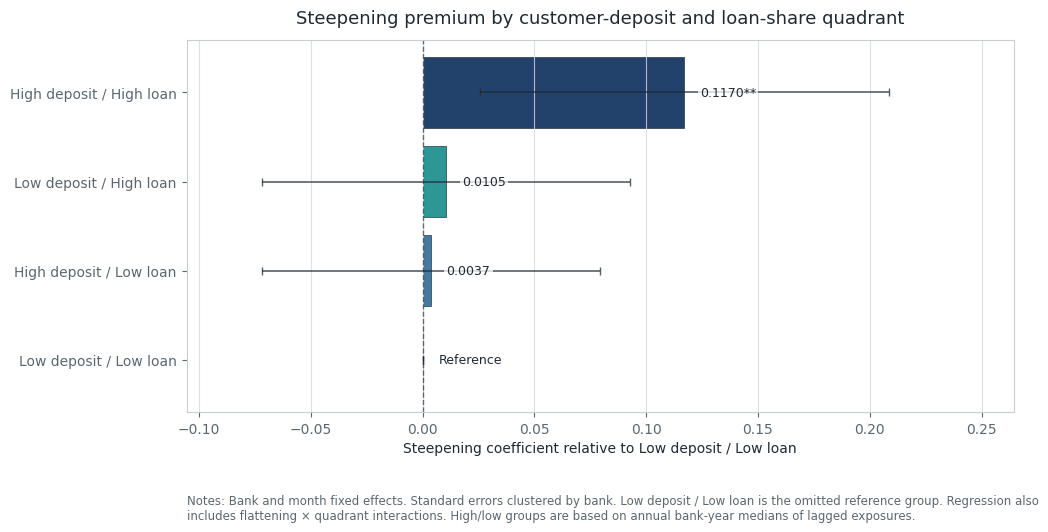

In [34]:
# ============================================================
# ROBUSTNESS / MECHANISM EXTENSION — CUSTDEP × LOANSHARE QUADRANT SPLIT
# Annual bank-year median construction:
#
#   X_tilde_{i,y} = Median_{t in y}(X_{i,t-12})
#   HighX_{i,y}   = 1[X_tilde_{i,y} >= Median_j(X_tilde_{j,y})]
#
# Tests whether the steepening premium is strongest when a bank has
# both high customer-deposit exposure and high loan-share exposure.
#
# ASYM extension:
# Adds flattening × quadrant interactions so the quadrant test is
# consistent with the main steepening/flattening framework.
#
# Reference group: Low deposit / Low loan
# Coefficients are therefore relative to Low deposit / Low loan.
# ============================================================

RUN_QUADRANT_SPLIT = True
ATTACH_WCB_QUADRANT = True  # Set True only for final/slower WCB run

if RUN_QUADRANT_SPLIT:

    # ------------------------------------------------------------
    # 0. Safe globals / setup
    # ------------------------------------------------------------
    all_results = globals().setdefault("all_results", {})
    all_tables = globals().setdefault("all_tables", {})
    all_wald = globals().setdefault("all_wald", {})

    def _qnum(x):
        if "as_numeric" in globals():
            return as_numeric(x)
        return pd.to_numeric(x, errors="coerce").replace([np.inf, -np.inf], np.nan)

    def _qstars(p):
        if "stars" in globals():
            return stars(p)
        if pd.isna(p):
            return ""
        return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""

    # Use loan-share sample if already created; otherwise fall back to main sample.
    df_quad_base = (
        df_loan.copy()
        if "df_loan" in globals() and isinstance(df_loan, pd.DataFrame) and not df_loan.empty
        else df_main.copy()
    )

    # ------------------------------------------------------------
    # 1. Detect required variables
    # ------------------------------------------------------------
    custdep_col = find_first(df_quad_base, [
        "custdep_ratio_reg",
        "custdep_zstd",
        "custdep_ratio",
        "customer_deposits_assets",
        "custdep_assets",
    ])

    loan_col = find_first(df_quad_base, [
        "loan_share_reg",
        "loan_share_zstd",
        "loan_asset_share_reg",
        "loans_share_reg",
        "loan_share",
    ])

    if custdep_col is None:
        raise KeyError("No customer-deposit exposure column found for quadrant split.")

    if loan_col is None:
        raise KeyError("No loan-share column found for quadrant split.")

    # Create ASYM slope components if absent
    if "steepening" not in df_quad_base.columns:
        if "delta_slope" not in df_quad_base.columns:
            raise KeyError("Neither 'steepening' nor 'delta_slope' found.")
        df_quad_base["steepening"] = _qnum(df_quad_base["delta_slope"]).clip(lower=0)

    if "flattening" not in df_quad_base.columns:
        if "delta_slope" not in df_quad_base.columns:
            raise KeyError("Neither 'flattening' nor 'delta_slope' found.")
        df_quad_base["flattening"] = _qnum(df_quad_base["delta_slope"]).clip(upper=0)

    split_date_col = DATE_COL if DATE_COL in df_quad_base.columns else MONTH_COL

    controls_quad = [
        c for c in globals().get("CONTROLS_MAIN", ["tier1_ratio_reg", "size_reg"])
        if c in df_quad_base.columns
    ]

    required_pre = [
        DEPENDENT_VAR,
        "steepening",
        "flattening",
        custdep_col,
        loan_col,
        *controls_quad,
    ]

    df_quad_base = subset_complete_case(
        df_quad_base,
        [BANK_COL, MONTH_COL, split_date_col, *required_pre],
        label="df_quadrant_pre_sample",
        allow_missing=False,
    ).copy()

    # ------------------------------------------------------------
    # 2. Annual bank-year median split
    # ------------------------------------------------------------
    def annual_bank_year_median_split(df, var_col, out_col, bank_col, date_col):
        """
        Creates annual high/low exposure dummy using:

            X_tilde_{i,y} = median of lagged exposure X_{i,t-12}
                             within bank i and year y.

            HighX_{i,y} = 1 if X_tilde_{i,y} >= yearly cross-bank median.

        The cross-sectional yearly median is computed across unique bank-year
        observations, not repeated monthly rows.
        """

        x = _qnum(df[var_col])

        year_col = f"{out_col}_split_year"
        bank_year_median_col = f"{out_col}_bank_year_median"
        year_cross_median_col = f"{out_col}_year_cross_bank_median"

        df[year_col] = pd.to_datetime(df[date_col]).dt.year

        df[bank_year_median_col] = (
            x.groupby([df[bank_col], df[year_col]]).transform("median")
        )

        bank_year_table = (
            df[[bank_col, year_col, bank_year_median_col]]
            .dropna(subset=[bank_year_median_col])
            .drop_duplicates(subset=[bank_col, year_col])
            .copy()
        )

        yearly_thresholds = (
            bank_year_table
            .groupby(year_col, as_index=False)[bank_year_median_col]
            .median()
            .rename(columns={bank_year_median_col: year_cross_median_col})
        )

        df_threshold_map = yearly_thresholds.set_index(year_col)[year_cross_median_col]
        df[year_cross_median_col] = df[year_col].map(df_threshold_map)

        df[out_col] = np.where(
            df[bank_year_median_col].notna() & df[year_cross_median_col].notna(),
            (df[bank_year_median_col] >= df[year_cross_median_col]).astype(int),
            np.nan,
        )

        return out_col, year_col, bank_year_median_col, year_cross_median_col

    HIGH_DEP_DYNAMIC = "quad_high_dep_annual"
    HIGH_LOAN_DYNAMIC = "quad_high_loan_annual"

    (
        HIGH_DEP_DYNAMIC,
        DEP_YEAR_COL,
        DEP_BANK_YEAR_MEDIAN_COL,
        DEP_YEAR_CROSS_MEDIAN_COL,
    ) = annual_bank_year_median_split(
        df_quad_base,
        custdep_col,
        HIGH_DEP_DYNAMIC,
        BANK_COL,
        split_date_col,
    )

    (
        HIGH_LOAN_DYNAMIC,
        LOAN_YEAR_COL,
        LOAN_BANK_YEAR_MEDIAN_COL,
        LOAN_YEAR_CROSS_MEDIAN_COL,
    ) = annual_bank_year_median_split(
        df_quad_base,
        loan_col,
        HIGH_LOAN_DYNAMIC,
        BANK_COL,
        split_date_col,
    )

    required_quad = [
        DEPENDENT_VAR,
        "steepening",
        "flattening",
        custdep_col,
        loan_col,
        HIGH_DEP_DYNAMIC,
        HIGH_LOAN_DYNAMIC,
        *controls_quad,
    ]

    df_quad = subset_complete_case(
        df_quad_base,
        [BANK_COL, MONTH_COL, split_date_col, *required_quad],
        label="df_quadrant_annual_bank_year_median_sample",
        allow_missing=False,
    ).copy()

    df_quad[HIGH_DEP_DYNAMIC] = df_quad[HIGH_DEP_DYNAMIC].astype(int)
    df_quad[HIGH_LOAN_DYNAMIC] = df_quad[HIGH_LOAN_DYNAMIC].astype(int)

    # ------------------------------------------------------------
    # 3. Four quadrant indicators
    # ------------------------------------------------------------
    Q_HH = "quad_highdep_highloan"
    Q_HL = "quad_highdep_lowloan"
    Q_LH = "quad_lowdep_highloan"
    Q_LL = "quad_lowdep_lowloan"  # omitted reference

    df_quad[Q_HH] = (
        (df_quad[HIGH_DEP_DYNAMIC] == 1) &
        (df_quad[HIGH_LOAN_DYNAMIC] == 1)
    ).astype(int)

    df_quad[Q_HL] = (
        (df_quad[HIGH_DEP_DYNAMIC] == 1) &
        (df_quad[HIGH_LOAN_DYNAMIC] == 0)
    ).astype(int)

    df_quad[Q_LH] = (
        (df_quad[HIGH_DEP_DYNAMIC] == 0) &
        (df_quad[HIGH_LOAN_DYNAMIC] == 1)
    ).astype(int)

    df_quad[Q_LL] = (
        (df_quad[HIGH_DEP_DYNAMIC] == 0) &
        (df_quad[HIGH_LOAN_DYNAMIC] == 0)
    ).astype(int)

    df_quad["quad_sum_check"] = df_quad[[Q_HH, Q_HL, Q_LH, Q_LL]].sum(axis=1)

    if not (df_quad["quad_sum_check"] == 1).all():
        raise ValueError(
            "Quadrant construction failed: some observations are not assigned to exactly one group."
        )

    df_quad["quadrant_label"] = np.select(
        [
            df_quad[Q_HH].eq(1),
            df_quad[Q_HL].eq(1),
            df_quad[Q_LH].eq(1),
            df_quad[Q_LL].eq(1),
        ],
        [
            "High deposit / High loan",
            "High deposit / Low loan",
            "Low deposit / High loan",
            "Low deposit / Low loan",
        ],
        default="Unassigned",
    )

    print("\nANNUAL BANK-YEAR QUADRANT SPLIT CHECK")
    print(f"Customer-deposit variable used : {custdep_col}")
    print(f"Loan-share variable used       : {loan_col}")
    print(f"Date variable used             : {split_date_col}")
    print("High-deposit and high-loan indicators are computed from bank-year medians.")
    print("Classification rule            : bank-year median >= yearly cross-bank median")
    print("Reference group                : Low deposit / Low loan")

    # ------------------------------------------------------------
    # 4. Split-threshold diagnostics
    # ------------------------------------------------------------
    split_thresholds = (
        df_quad[
            [
                DEP_YEAR_COL,
                DEP_YEAR_CROSS_MEDIAN_COL,
                LOAN_YEAR_CROSS_MEDIAN_COL,
            ]
        ]
        .drop_duplicates()
        .rename(columns={
            DEP_YEAR_COL: "year",
            DEP_YEAR_CROSS_MEDIAN_COL: "custdep_yearly_cross_bank_median",
            LOAN_YEAR_CROSS_MEDIAN_COL: "loan_share_yearly_cross_bank_median",
        })
        .sort_values("year")
        .reset_index(drop=True)
    )

    print("\nANNUAL SPLIT THRESHOLDS")
    show_df(split_thresholds)
    save_table(split_thresholds, "quadrant_annual_split_thresholds.csv", display_table=False)

    # ------------------------------------------------------------
    # 5. Steepening and flattening × quadrant interactions
    #    Low deposit / Low loan is omitted.
    #
    #    With month FE, the full set of four steepening interactions
    #    would sum to the common monthly steepening shock.
    #    Same logic applies to flattening.
    # ------------------------------------------------------------
    S_HH = "steepening_x_highdep_highloan"
    S_HL = "steepening_x_highdep_lowloan"
    S_LH = "steepening_x_lowdep_highloan"

    F_HH = "flattening_x_highdep_highloan"
    F_HL = "flattening_x_highdep_lowloan"
    F_LH = "flattening_x_lowdep_highloan"

    df_quad[S_HH] = _qnum(df_quad["steepening"]) * df_quad[Q_HH]
    df_quad[S_HL] = _qnum(df_quad["steepening"]) * df_quad[Q_HL]
    df_quad[S_LH] = _qnum(df_quad["steepening"]) * df_quad[Q_LH]

    df_quad[F_HH] = _qnum(df_quad["flattening"]) * df_quad[Q_HH]
    df_quad[F_HL] = _qnum(df_quad["flattening"]) * df_quad[Q_HL]
    df_quad[F_LH] = _qnum(df_quad["flattening"]) * df_quad[Q_LH]

    regs_quad = [
        Q_HH,
        Q_HL,
        Q_LH,
        S_HH,
        S_HL,
        S_LH,
        F_HH,
        F_HL,
        F_LH,
        *controls_quad,
    ]

    df_quad = make_complete_sample(
        df_quad,
        [DEPENDENT_VAR, *regs_quad],
        "df_quadrant — annual CustDep × LoanShare ASYM quadrant sample",
    )

    # ------------------------------------------------------------
    # 6. Quadrant coverage table
    # ------------------------------------------------------------
    quad_counts = (
        df_quad
        .groupby("quadrant_label")
        .agg(
            observations=(DEPENDENT_VAR, "size"),
            banks=(BANK_COL, "nunique"),
            months=(MONTH_COL, "nunique"),
            mean_excess_return=(DEPENDENT_VAR, "mean"),
            mean_steepening=("steepening", "mean"),
            mean_flattening=("flattening", "mean"),
            mean_custdep=(custdep_col, "mean"),
            mean_loan_share=(loan_col, "mean"),
        )
        .reset_index()
    )

    quad_order = [
        "Low deposit / Low loan",
        "High deposit / Low loan",
        "Low deposit / High loan",
        "High deposit / High loan",
    ]

    quad_counts["quadrant_label"] = pd.Categorical(
        quad_counts["quadrant_label"],
        categories=quad_order,
        ordered=True,
    )

    quad_counts = quad_counts.sort_values("quadrant_label").reset_index(drop=True)

    print("\nQUADRANT SAMPLE COVERAGE")
    show_df(quad_counts)
    save_table(quad_counts, "quadrant_sample_coverage.csv", display_table=False)

    # ------------------------------------------------------------
    # 7. Estimate quadrant regression
    # ------------------------------------------------------------
    specs_quad = {
        "Quadrant ASYM split": ModelSpec(
            df_quad,
            DEPENDENT_VAR,
            regs_quad,
            "Quadrant ASYM split: CustDep × LoanShare steepening and flattening exposure",
            keys=[S_HH, S_HL, S_LH, F_HH, F_HL, F_LH],
        )
    }

    res_quad = run_model_specs(specs_quad, attach_wcb=ATTACH_WCB_QUADRANT)

    coef_rows_quad = {
        "s_hh": S_HH,
        "s_hl": S_HL,
        "s_lh": S_LH,
        "f_hh": F_HH,
        "f_hl": F_HL,
        "f_lh": F_LH,
        "q_hh": Q_HH,
        "q_hl": Q_HL,
        "q_lh": Q_LH,
        "tier1": "tier1_ratio_reg",
        "size": "size_reg",
    }

    row_labels_quad = {
        "s_hh": "Steepening × High deposit / High loan",
        "s_hl": "Steepening × High deposit / Low loan",
        "s_lh": "Steepening × Low deposit / High loan",
        "f_hh": "Flattening × High deposit / High loan",
        "f_hl": "Flattening × High deposit / Low loan",
        "f_lh": "Flattening × Low deposit / High loan",
        "q_hh": "High deposit / High loan dummy",
        "q_hl": "High deposit / Low loan dummy",
        "q_lh": "Low deposit / High loan dummy",
        "tier1": "Tier 1 ratio",
        "size": "Size",
    }

    table_quad = print_multi_table(
        res_quad,
        ["Quadrant ASYM split"],
        coef_rows_quad,
        row_labels_quad,
        "ROBUSTNESS TABLE — CUSTDEP × LOANSHARE QUADRANT ASYM SPLIT",
        "quadrant_asym_split_custdep_loanshare.csv",
    )

    all_results["quadrant_asym_split_custdep_loanshare"] = res_quad
    all_tables["quadrant_asym_split_custdep_loanshare"] = table_quad

    # ============================================================
    # 8. Safe Wald tests
    # ============================================================
    import math
    import numpy as np
    import pandas as pd

    try:
        from scipy import stats as sp_stats
        SCIPY_STATS_SAFE = True
    except Exception:
        SCIPY_STATS_SAFE = False

    def safe_norm_pvalue(t_value):
        if pd.isna(t_value) or not np.isfinite(t_value):
            return np.nan

        if SCIPY_STATS_SAFE:
            return float(2 * sp_stats.norm.sf(abs(t_value)))

        return float(math.erfc(abs(t_value) / math.sqrt(2)))

    def safe_stars(p):
        if pd.isna(p):
            return ""
        if p < 0.01:
            return "***"
        if p < 0.05:
            return "**"
        if p < 0.10:
            return "*"
        return ""

    def safe_wald_linear_combination(res, terms, label=""):
        """
        terms = dict of {variable_name: weight}
        Example:
            {S_HH: 1, S_HL: -1} tests S_HH - S_HL = 0.
        """

        out = {
            "test": label or "linear combination = 0",
            "ok": False,
            "estimate": np.nan,
            "se": np.nan,
            "t_stat": np.nan,
            "p_value": np.nan,
            "stars": "",
            "error": "",
        }

        if res is None or not res.get("ok", False):
            out["error"] = "Model not estimated"
            return out

        params = res.get("params", pd.Series(dtype=float))
        cov = res.get("cov", pd.DataFrame())

        if cov is None or cov.empty:
            out["error"] = "Covariance matrix unavailable"
            return out

        missing_params = [v for v in terms if v not in params.index]
        missing_cov = [v for v in terms if v not in cov.index or v not in cov.columns]

        if missing_params:
            out["error"] = f"Missing parameter(s): {missing_params}"
            return out

        if missing_cov:
            out["error"] = f"Missing covariance entry/entries: {missing_cov}"
            return out

        try:
            vars_ = list(terms.keys())
            weights = np.array([terms[v] for v in vars_], dtype=float)

            beta = params.loc[vars_].astype(float).values
            cov_sub = cov.loc[vars_, vars_].astype(float).values

            estimate = float(weights @ beta)
            var_estimate = float(weights @ cov_sub @ weights)

            if pd.isna(var_estimate) or var_estimate <= 0:
                out["error"] = f"Invalid variance of linear combination: {var_estimate}"
                return out

            se = float(np.sqrt(var_estimate))
            t_stat = float(estimate / se)
            p_value = safe_norm_pvalue(t_stat)

            out.update({
                "ok": True,
                "estimate": estimate,
                "se": se,
                "t_stat": t_stat,
                "p_value": p_value,
                "stars": safe_stars(p_value),
                "error": "",
            })

            return out

        except Exception as exc:
            out["error"] = str(exc)
            return out

    quad_model = res_quad["Quadrant ASYM split"]

    quad_wald = pd.DataFrame([
        # Steepening quadrant contrasts
        safe_wald_linear_combination(
            quad_model,
            {S_HH: 1, S_HL: -1},
            "Steepening: HighDep/HighLoan − HighDep/LowLoan = 0",
        ),
        safe_wald_linear_combination(
            quad_model,
            {S_HH: 1, S_LH: -1},
            "Steepening: HighDep/HighLoan − LowDep/HighLoan = 0",
        ),
        safe_wald_linear_combination(
            quad_model,
            {S_HL: 1, S_LH: -1},
            "Steepening: HighDep/LowLoan − LowDep/HighLoan = 0",
        ),

        # Flattening quadrant contrasts
        safe_wald_linear_combination(
            quad_model,
            {F_HH: 1, F_HL: -1},
            "Flattening: HighDep/HighLoan − HighDep/LowLoan = 0",
        ),
        safe_wald_linear_combination(
            quad_model,
            {F_HH: 1, F_LH: -1},
            "Flattening: HighDep/HighLoan − LowDep/HighLoan = 0",
        ),
        safe_wald_linear_combination(
            quad_model,
            {F_HL: 1, F_LH: -1},
            "Flattening: HighDep/LowLoan − LowDep/HighLoan = 0",
        ),

        # Within-quadrant ASYM tests
        # Because flattening is coded as negative values, this tests whether
        # the estimated slope sensitivity differs between positive and negative slope moves.
        safe_wald_linear_combination(
            quad_model,
            {S_HH: 1, F_HH: -1},
            "ASYM: HighDep/HighLoan steepening − flattening = 0",
        ),
        safe_wald_linear_combination(
            quad_model,
            {S_HL: 1, F_HL: -1},
            "ASYM: HighDep/LowLoan steepening − flattening = 0",
        ),
        safe_wald_linear_combination(
            quad_model,
            {S_LH: 1, F_LH: -1},
            "ASYM: LowDep/HighLoan steepening − flattening = 0",
        ),
    ])

    quad_wald_display = quad_wald[
        [
            "test",
            "estimate",
            "se",
            "t_stat",
            "p_value",
            "stars",
            "ok",
            "error",
        ]
    ].copy()

    print("\nQUADRANT WALD TESTS — ASYM SPECIFICATION")
    show_df(quad_wald_display)

    save_table(
        quad_wald_display,
        "quadrant_asym_split_wald_tests.csv",
        display_table=False,
    )

    all_wald["quadrant_asym_split_custdep_loanshare"] = quad_wald_display

    # ------------------------------------------------------------
    # 9. Economic-magnitude table
    #    Steepening coefficients are still the main H5 interpretation.
    #    Coefficients are relative to LowDep/LowLoan.
    # ------------------------------------------------------------
    positive_steepening = _qnum(df_quad.loc[df_quad["steepening"] > 0, "steepening"])
    negative_flattening = _qnum(df_quad.loc[df_quad["flattening"] < 0, "flattening"])

    typical_steepening = positive_steepening.mean()
    typical_flattening = negative_flattening.mean()

    def _coef(var):
        return get_stat(quad_model, var, "coef")

    def _se(var):
        return get_stat(quad_model, var, "se")

    def _p(var):
        return get_stat(quad_model, var, "p")

    quad_effect_rows = [
        {
            "quadrant": "Low deposit / Low loan",
            "steepening_interaction": "Reference",
            "steepening_coef_vs_low_low": 0.0,
            "steepening_se": np.nan,
            "steepening_p_value": np.nan,
            "steepening_stars": "",
            "flattening_interaction": "Reference",
            "flattening_coef_vs_low_low": 0.0,
            "flattening_se": np.nan,
            "flattening_p_value": np.nan,
            "flattening_stars": "",
            "effect_in_typical_steepening_month": 0.0,
            "effect_in_typical_flattening_month": 0.0,
        },
        {
            "quadrant": "High deposit / Low loan",
            "steepening_interaction": S_HL,
            "steepening_coef_vs_low_low": _coef(S_HL),
            "steepening_se": _se(S_HL),
            "steepening_p_value": _p(S_HL),
            "steepening_stars": _qstars(_p(S_HL)),
            "flattening_interaction": F_HL,
            "flattening_coef_vs_low_low": _coef(F_HL),
            "flattening_se": _se(F_HL),
            "flattening_p_value": _p(F_HL),
            "flattening_stars": _qstars(_p(F_HL)),
            "effect_in_typical_steepening_month": _coef(S_HL) * typical_steepening,
            "effect_in_typical_flattening_month": _coef(F_HL) * typical_flattening,
        },
        {
            "quadrant": "Low deposit / High loan",
            "steepening_interaction": S_LH,
            "steepening_coef_vs_low_low": _coef(S_LH),
            "steepening_se": _se(S_LH),
            "steepening_p_value": _p(S_LH),
            "steepening_stars": _qstars(_p(S_LH)),
            "flattening_interaction": F_LH,
            "flattening_coef_vs_low_low": _coef(F_LH),
            "flattening_se": _se(F_LH),
            "flattening_p_value": _p(F_LH),
            "flattening_stars": _qstars(_p(F_LH)),
            "effect_in_typical_steepening_month": _coef(S_LH) * typical_steepening,
            "effect_in_typical_flattening_month": _coef(F_LH) * typical_flattening,
        },
        {
            "quadrant": "High deposit / High loan",
            "steepening_interaction": S_HH,
            "steepening_coef_vs_low_low": _coef(S_HH),
            "steepening_se": _se(S_HH),
            "steepening_p_value": _p(S_HH),
            "steepening_stars": _qstars(_p(S_HH)),
            "flattening_interaction": F_HH,
            "flattening_coef_vs_low_low": _coef(F_HH),
            "flattening_se": _se(F_HH),
            "flattening_p_value": _p(F_HH),
            "flattening_stars": _qstars(_p(F_HH)),
            "effect_in_typical_steepening_month": _coef(S_HH) * typical_steepening,
            "effect_in_typical_flattening_month": _coef(F_HH) * typical_flattening,
        },
    ]

    quad_effects = pd.DataFrame(quad_effect_rows)

    quad_effects["quadrant"] = pd.Categorical(
        quad_effects["quadrant"],
        categories=quad_order,
        ordered=True,
    )

    quad_effects = quad_effects.sort_values("quadrant").reset_index(drop=True)

    print(f"\nTypical positive steepening month: {typical_steepening:.4f}")
    print(f"Typical negative flattening month: {typical_flattening:.4f}")
    print("\nQUADRANT ECONOMIC MAGNITUDES — ASYM SPECIFICATION")
    show_df(quad_effects)

    save_table(
        quad_effects,
        "quadrant_asym_split_economic_magnitudes.csv",
        display_table=False,
    )

    all_tables["quadrant_asym_split_economic_magnitudes"] = quad_effects

    # ------------------------------------------------------------
    # 10. Thesis-ready coefficient plot
    #     Plot keeps focus on steepening because H5 concerns the
    #     joint deposit/loan valuation during steepening.
    # ------------------------------------------------------------
    import matplotlib.pyplot as plt

    plot_df = quad_effects.copy()

    plot_df["coef_vs_low_low"] = plot_df["steepening_coef_vs_low_low"]
    plot_df["se"] = plot_df["steepening_se"]
    plot_df["p_value"] = plot_df["steepening_p_value"]
    plot_df["interaction"] = plot_df["steepening_interaction"]

    plot_df["ci_low"] = plot_df["coef_vs_low_low"] - 1.96 * plot_df["se"]
    plot_df["ci_high"] = plot_df["coef_vs_low_low"] + 1.96 * plot_df["se"]

    plot_df.loc[
        plot_df["interaction"].eq("Reference"),
        ["ci_low", "ci_high"],
    ] = 0.0

    BG = globals().get("WP_FIG_BG", "#FFFFFF")
    AX_BG = globals().get("WP_AX_BG", "#F7F9FB")
    BLUE = globals().get("WP_BLUE", "#2F6B9A")
    TEAL = globals().get("WP_TEAL", "#2A9D8F")
    NAVY = globals().get("WP_NAVY", "#0B2D5B")
    MUTED = globals().get("WP_MUTED", "#5B6770")
    GRID = globals().get("WP_GRID", "#D8DEE9")
    TEXT = globals().get("WP_TEXT", "#1F2933")

    color_map = {
        "Low deposit / Low loan": MUTED,
        "High deposit / Low loan": BLUE,
        "Low deposit / High loan": TEAL,
        "High deposit / High loan": NAVY,
    }

    fig, ax = plt.subplots(figsize=(10.8, 5.4))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(AX_BG)

    y = np.arange(len(plot_df))

    ax.barh(
        y,
        plot_df["coef_vs_low_low"],
        color=[color_map[str(q)] for q in plot_df["quadrant"]],
        alpha=0.90,
        edgecolor=TEXT,
        linewidth=0.5,
    )

    ax.errorbar(
        plot_df["coef_vs_low_low"],
        y,
        xerr=[
            plot_df["coef_vs_low_low"] - plot_df["ci_low"],
            plot_df["ci_high"] - plot_df["coef_vs_low_low"],
        ],
        fmt="none",
        ecolor=TEXT,
        elinewidth=1.2,
        capsize=3,
        alpha=0.75,
    )

    ax.axvline(0, color=TEXT, linestyle="--", linewidth=1.0, alpha=0.65)

    # Dynamic label placement to avoid labels sitting on/inside bars
    x_min = min(plot_df["ci_low"].min(), plot_df["coef_vs_low_low"].min(), 0)
    x_max = max(plot_df["ci_high"].max(), plot_df["coef_vs_low_low"].max(), 0)
    x_range = x_max - x_min
    label_offset = 0.025 * x_range if x_range > 0 else 0.006

    for idx, row in plot_df.iterrows():
        coef = row["coef_vs_low_low"]
        pval = row["p_value"]

        if row["interaction"] == "Reference":
            label = "Reference"
        else:
            label = f"{coef:.4f}{_qstars(pval)}"

        if coef >= 0:
            x_pos = coef + label_offset
            ha = "left"
        else:
            x_pos = coef - label_offset
            ha = "right"

        ax.text(
            x_pos,
            idx,
            label,
            va="center",
            ha=ha,
            fontsize=9,
            color=TEXT,
            bbox=dict(facecolor=BG, edgecolor="none", alpha=0.75, pad=1.5),
        )

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["quadrant"], fontsize=10)

    ax.set_xlim(x_min - 0.12 * x_range, x_max + 0.20 * x_range)

    ax.set_xlabel("Steepening coefficient relative to Low deposit / Low loan", fontsize=10)

    ax.set_title(
        "Steepening premium by customer-deposit and loan-share quadrant",
        fontsize=13,
        pad=12,
        color=TEXT,
    )

    ax.grid(True, axis="x", color=GRID, linewidth=0.8, alpha=0.8)
    ax.grid(False, axis="y")

    note = (
        "Notes: Bank and month fixed effects. Standard errors clustered by bank. "
        "Low deposit / Low loan is the omitted reference group. "
        "Regression also includes flattening × quadrant interactions. "
        "High/low groups are based on annual bank-year medians of lagged exposures."
    )

    ax.text(
        0.0,
        -0.22,
        note,
        transform=ax.transAxes,
        fontsize=8.5,
        color=MUTED,
        ha="left",
        va="top",
        wrap=True,
    )

    fig.tight_layout()

    if "save_figure" in globals():
        save_figure(fig, "quadrant_asym_split_steepening_premium.png")
    else:
        plt.savefig(
            "quadrant_asym_split_steepening_premium.png",
            dpi=240,
            bbox_inches="tight",
        )

    plt.show()

## E.2 Table R2 — Continuous customer-deposit exposure

Replaces the high-customer-deposit dummy with a standardized customer-deposit exposure measure.


In [35]:
# ============================================================
# 17. TABLE R2 — CONTINUOUS AGGREGATE DEPOSIT SPECIFICATION
# ============================================================

CONT_CUST_STEEP = "steepening_x_custdep_zstd"
CONT_CUST_FLAT  = "flattening_x_custdep_zstd"
CONT_CUST_LEVEL = "custdep_zstd"                          # <-- standalone z-score

CONT_CUST_VARS = [DEPENDENT_VAR, CONT_CUST_STEEP, CONT_CUST_FLAT, CONT_CUST_LEVEL, *CONTROLS_MAIN]
df_cont_cust = make_complete_sample(
    df_main,
    CONT_CUST_VARS,
    "df_cont_cust — continuous aggregate customer-deposit sample nested inside df_quality",
)

specs_r2 = {
    "CustDep z-score": ModelSpec(
        df_cont_cust,
        DEPENDENT_VAR,
        [CONT_CUST_STEEP, CONT_CUST_FLAT, CONT_CUST_LEVEL, *CONTROLS_MAIN],
        "R2: continuous customer-deposit z-score",
        keys=[CONT_CUST_STEEP],
    ),
}
res_r2 = run_model_specs(specs_r2)

coef_rows_r2 = {
    "steepening": CONT_CUST_STEEP,
    "flattening": CONT_CUST_FLAT,
    "custdep_z":  CONT_CUST_LEVEL,
    "tier1":      "tier1_ratio_reg",
    "size":       "size_reg",
}
row_labels_r2 = {
    "steepening": "Steepening × CustDep z-score",
    "flattening": "Flattening × CustDep z-score",
    "custdep_z":  "CustDep z-score",
    "tier1":      "Tier 1 ratio",
    "size":       "Size",
}

table_r2 = print_multi_table(
    res_r2,
    ["CustDep z-score"],
    coef_rows_r2,
    row_labels_r2,
    "ROBUSTNESS TABLE R2 — CONTINUOUS AGGREGATE CUSTOMER-DEPOSIT SPECIFICATION",
    "13_table_r2_continuous_aggregate_deposit.csv",
)

all_results["table_r2_continuous_custdep"] = res_r2
all_tables["table_r2_continuous_custdep"] = table_r2

WCB: CustDep z-score | steepening_x_custdep_zstd

ROBUSTNESS TABLE R2 — CONTINUOUS AGGREGATE CUSTOMER-DEPOSIT SPECIFICATION
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
                    Variable       (1) CustDep z-score
Steepening × CustDep z-score                  0.0447**
                                              (0.0203)
                                             [p=0.028]
                                         [WCB p=0.024]
Flattening × CustDep z-score                   -0.0297
                                              (0.0187)
                                             [p=0.112]
             CustDep z-score                    0.0069
                                              (0.0065)
                                             [p=0.294]
                Tier 1 ratio                    0.0011
                                              (0.0009)
                                    

## E.3 Table R3 — Alternative slope definitions

Checks whether the ASYM result is specific to the 10Y–2Y slope or survives alternative curve definitions.


In [36]:

# ============================================================
# 18. TABLE R3 — ALTERNATIVE SLOPE DEFINITIONS
# ============================================================

ALT_SLOPE_SPECS = {
    "10Y–2Y baseline": {"slope": "delta_slope", "steep": "steepening", "flat": "flattening"},
    "5Y–2Y": {"candidates": ["delta_slope_5y_2y", "delta_5y_2y", "slope_5y_2y_delta"], "steep": "steepening_5y_2y", "flat": "flattening_5y_2y"},
    "10Y–Shadow DFR": {"candidates": ["delta_slope_10y_shadow_dfr", "delta_10y_shadow_dfr", "delta_slope_10y_dfr_shadow", "delta_10y_shadow"], "steep": "steepening_10y_shadow_dfr", "flat": "flattening_10y_shadow_dfr"},
}

alt_specs = {}
coef_rows_r3 = {}
row_labels_r3 = {}
df_alt_base = df_main.copy()

for label, spec in ALT_SLOPE_SPECS.items():
    slope_col = spec.get("slope") or find_first(df_alt_base, spec.get("candidates", []))
    if slope_col is None or slope_col not in df_alt_base.columns:
        warn_msg(f"Alternative slope missing on df_quality; skipping {label}.")
        continue

    steep_col = spec["steep"]
    flat_col = spec["flat"]

    df_alt_base[steep_col] = as_numeric(df_alt_base[slope_col]).clip(lower=0)
    df_alt_base[flat_col] = as_numeric(df_alt_base[slope_col]).clip(upper=0)

    steep_int = f"{steep_col}_x_high_custdep"
    flat_int = f"{flat_col}_x_high_custdep"

    ensure_interaction(df_alt_base, steep_int, steep_col, "high_custdep", overwrite=True, quiet=True)
    ensure_interaction(df_alt_base, flat_int, flat_col, "high_custdep", overwrite=True, quiet=True)

    needed = [DEPENDENT_VAR, steep_int, flat_int, *CONTROLS_MAIN]
    d_alt = make_complete_sample(
        df_alt_base,
        needed,
        f"df_alt_slope — {label}, nested inside df_quality",    )
    alt_specs[label] = ModelSpec(d_alt, DEPENDENT_VAR, [steep_int, flat_int, *CONTROLS_MAIN], f"R3: alternative slope — {label}", keys=[steep_int])
    coef_rows_r3[f"steep_{label}"] = {label: steep_int}
    coef_rows_r3[f"flat_{label}"] = {label: flat_int}
    row_labels_r3[f"steep_{label}"] = f"Steepening {label} × HighCustDep"
    row_labels_r3[f"flat_{label}"] = f"Flattening {label} × HighCustDep"

coef_rows_r3["tier1"] = "tier1_ratio_reg"
coef_rows_r3["size"] = "size_reg"
row_labels_r3["tier1"] = "Tier 1 ratio"
row_labels_r3["size"] = "Size"

if alt_specs:
    res_r3 = run_model_specs(alt_specs, attach_wcb=False)
    table_r3 = print_multi_table(
        res_r3,
        list(alt_specs.keys()),
        coef_rows_r3,
        row_labels_r3,
        "ROBUSTNESS TABLE R3 — ALTERNATIVE SLOPE DEFINITIONS",
        "14_table_r3_alternative_slope_definitions.csv",
    )
    all_results["table_r3_alt_slopes"] = res_r3
    all_tables["table_r3_alt_slopes"] = table_r3
else:
    warn_msg("Table R3 skipped because no slope definitions were available.")



ROBUSTNESS TABLE R3 — ALTERNATIVE SLOPE DEFINITIONS
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
                                Variable       (1) 10Y–2Y baseline                 (2) 5Y–2Y        (3) 10Y–Shadow DFR
Steepening 10Y–2Y baseline × HighCustDep                  0.0810**                                                    
                                                          (0.0392)                                                    
                                                         [p=0.039]                                                    
Flattening 10Y–2Y baseline × HighCustDep                   -0.0183                                                    
                                                          (0.0326)                                                    
                                                         [p=0.573]                                          

## E.4B Figure — Residual cross-sectional correlation diagnostics

Visual diagnostic for residual dependence across banks in the preferred aggregate and mechanism specifications.


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\15_table_r4_residual_cross_sectional_correlation.csv


,model,observations,banks,months,bank_pairs,mean_pairwise_corr,median_pairwise_corr,mean_abs_pairwise_corr,p90_abs_pairwise_corr,max_abs_pairwise_corr,status
0,Main ASYM,5318,36,165,630,-0.0161,-0.0450,0.1819,0.3946,0.8271,OK
1,ASYM + rate/sovereign,5318,36,165,630,-0.0161,-0.0487,0.1808,0.3854,0.8232,OK
2,ASYM + full macro/stress,5318,36,165,630,-0.0162,-0.0419,0.1783,0.3781,0.8078,OK
3,Preferred mechanism,3386,31,165,387,-0.0586,-0.0647,0.1890,0.4023,0.8882,OK
4,Main ASYM — Low CISS,2728,36,82,630,-0.0250,-0.0513,0.2072,0.4436,0.8477,OK
5,Main ASYM — High CISS,2590,36,83,621,-0.0046,-0.0341,0.1904,0.3862,0.8864,OK


Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\15_figure_r4_residual_cross_sectional_correlation.png


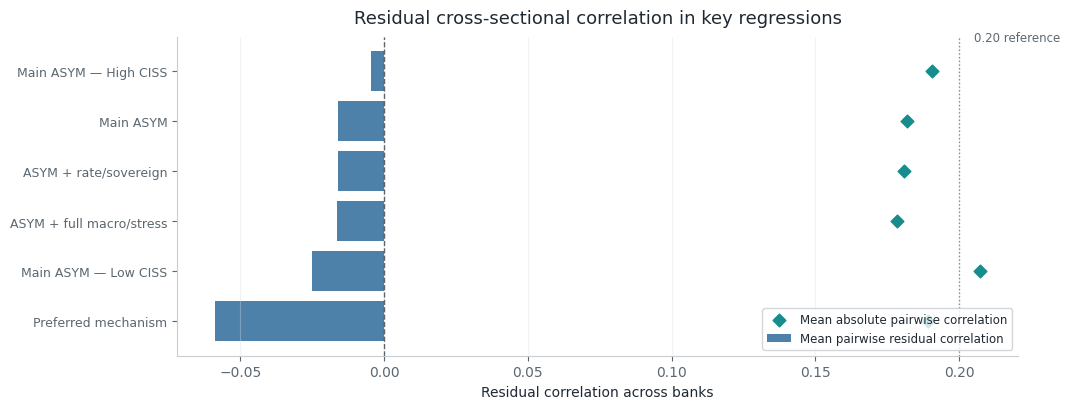

In [37]:
# ============================================================
# 19. RESIDUAL CROSS-SECTIONAL CORRELATION DIAGNOSTICS
# ============================================================

import re

RUN_RESIDUAL_CORR_DIAGNOSTICS = True
RESIDUAL_CORR_MIN_OVERLAP = 24

if RUN_RESIDUAL_CORR_DIAGNOSTICS:

    def safe_file_label(x):
        return re.sub(r"[^A-Za-z0-9]+", "_", str(x)).strip("_").lower()

    def residual_panel_from_spec(data, dep_var, regs, entity_effects=True, time_effects=True):
        work, regs = _prepare_work(data, dep_var, regs)

        bank_cat = pd.Categorical(work[BANK_COL].astype(str))
        month_cat = pd.Categorical(pd.to_datetime(work[MONTH_COL]).dt.strftime("%Y-%m"))

        bank_codes = bank_cat.codes
        month_codes = month_cat.codes

        y = work[dep_var].to_numpy(float)
        X = work[regs].to_numpy(float)

        y_w = within_transform(y, bank_codes, month_codes, entity_effects, time_effects).ravel()
        X_w = within_transform(X, bank_codes, month_codes, entity_effects, time_effects)

        keep = np.sqrt((X_w ** 2).sum(axis=0)) > 1e-12
        X_w = X_w[:, keep]

        beta = np.linalg.pinv(X_w.T @ X_w) @ X_w.T @ y_w
        resid = y_w - X_w @ beta

        out = work[[BANK_COL, MONTH_COL]].copy()
        out["residual"] = resid
        return out

    def residual_corr_summary(label, data, dep_var, regs, min_overlap=24):
        try:
            resid_df = residual_panel_from_spec(data, dep_var, regs)

            resid_mat = (
                resid_df
                .pivot_table(index=MONTH_COL, columns=BANK_COL, values="residual", aggfunc="mean")
                .sort_index()
            )

            corr = resid_mat.corr(min_periods=min_overlap)
            upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
            vals = upper.stack().dropna()

            corr.to_csv(OUT_DIR / f"15_residual_corr_matrix_{safe_file_label(label)}.csv")

            return {
                "model": label,
                "observations": int(len(resid_df)),
                "banks": int(resid_df[BANK_COL].nunique()),
                "months": int(resid_df[MONTH_COL].nunique()),
                "bank_pairs": int(len(vals)),
                "mean_pairwise_corr": vals.mean(),
                "median_pairwise_corr": vals.median(),
                "mean_abs_pairwise_corr": vals.abs().mean(),
                "p90_abs_pairwise_corr": vals.abs().quantile(0.90),
                "max_abs_pairwise_corr": vals.abs().max(),
                "status": "OK",
            }

        except Exception as exc:
            return {
                "model": label,
                "observations": np.nan,
                "banks": np.nan,
                "months": np.nan,
                "bank_pairs": np.nan,
                "mean_pairwise_corr": np.nan,
                "median_pairwise_corr": np.nan,
                "mean_abs_pairwise_corr": np.nan,
                "p90_abs_pairwise_corr": np.nan,
                "max_abs_pairwise_corr": np.nan,
                "status": str(exc),
            }

    # Key regressions for residual-dependence diagnostics.
    residual_corr_specs = {
        "Main ASYM": (df_main, DEPENDENT_VAR, regs_asym_main),
        "ASYM + rate/sovereign": (df_main, DEPENDENT_VAR, regs_asym_rate_sov),
        "ASYM + full macro/stress": (df_main, DEPENDENT_VAR, regs_asym_full_macro),
    }

    if MECH_READY and not df_mech.empty:
        residual_corr_specs["Preferred mechanism"] = (
            df_mech,
            DEPENDENT_VAR,
            [DEMAND_STEEP, TIME_STEEP, DEMAND_FLAT, TIME_FLAT, *CONTROLS_MAIN],
        )

    if "ciss_regime" in df_main.columns:
        for regime in ["Low CISS", "High CISS"]:
            d = df_main.loc[df_main["ciss_regime"] == regime].copy()
            residual_corr_specs[f"Main ASYM — {regime}"] = (d, DEPENDENT_VAR, regs_asym_main)

    residual_corr_table = pd.DataFrame([
        residual_corr_summary(label, data, dep, regs, RESIDUAL_CORR_MIN_OVERLAP)
        for label, (data, dep, regs) in residual_corr_specs.items()
    ])

    for c in [
        "mean_pairwise_corr",
        "median_pairwise_corr",
        "mean_abs_pairwise_corr",
        "p90_abs_pairwise_corr",
        "max_abs_pairwise_corr",
    ]:
        residual_corr_table[c] = pd.to_numeric(residual_corr_table[c], errors="coerce").round(4)

    save_table(
        residual_corr_table,
        "15_table_r4_residual_cross_sectional_correlation.csv",
    )

    all_tables["table_r4_residual_cross_sectional_correlation"] = residual_corr_table

    # -----------------------------
    # Visual summary
    # -----------------------------

    plot_df = (
        residual_corr_table
        .loc[lambda x: x["status"].eq("OK")]
        .sort_values("mean_pairwise_corr")
        .copy()
    )

    if plot_df.empty:
        warn_msg("Residual-correlation plot skipped because no models were estimated successfully.")

    else:
        fig, ax = plt.subplots(figsize=(10.8, max(4.2, 0.48 * len(plot_df))))
        fig.patch.set_facecolor(WP_FIG_BG)
        ax.set_facecolor(WP_AX_BG)

        y = np.arange(len(plot_df))

        ax.barh(
            y,
            plot_df["mean_pairwise_corr"],
            color=WP_BLUE,
            alpha=0.85,
            label="Mean pairwise residual correlation",
        )

        ax.scatter(
            plot_df["mean_abs_pairwise_corr"],
            y,
            marker="D",
            s=42,
            color=WP_TEAL,
            label="Mean absolute pairwise correlation",
            zorder=4,
        )

        ax.axvline(0, color=WP_TEXT, linestyle="--", linewidth=1, alpha=0.70)
        ax.axvline(0.20, color=WP_MUTED, linestyle=":", linewidth=1, alpha=0.75)
        ax.text(0.205, len(plot_df) - 0.4, "0.20 reference", fontsize=8.5, color=WP_MUTED)

        ax.set_yticks(y)
        ax.set_yticklabels(plot_df["model"], fontsize=9)
        ax.set_xlabel("Residual correlation across banks")
        ax.set_title("Residual cross-sectional correlation in key regressions", fontsize=13, pad=10)
        ax.grid(True, axis="x", color=WP_GRID, alpha=0.35)

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

        ax.legend(
            loc="lower right",
            frameon=True,
            facecolor=WP_AX_BG,
            edgecolor=WP_BORDER,
            fontsize=8.5,
        )

        fig.tight_layout()
        fig_path = OUT_DIR / "15_figure_r4_residual_cross_sectional_correlation.png"
        fig.savefig(fig_path, dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"Saved figure: {fig_path.resolve()}")

else:
    print("Residual-correlation diagnostics skipped.")


## E.5 Table/Figure R5 — Leave-one-out stability

Re-estimates the main ASYM model after dropping one bank or one country at a time. Figures use the full-sample estimate and confidence interval as visual references.


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\16_table_r5_leave_one_bank_out_main_quality_sample.csv
Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\16_figure_r5a_leave_one_bank_out_stability.png
Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\16b_leave_one_country_out_main_quality_sample.csv
Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\16b_figure_r5b_leave_one_country_out_stability.png


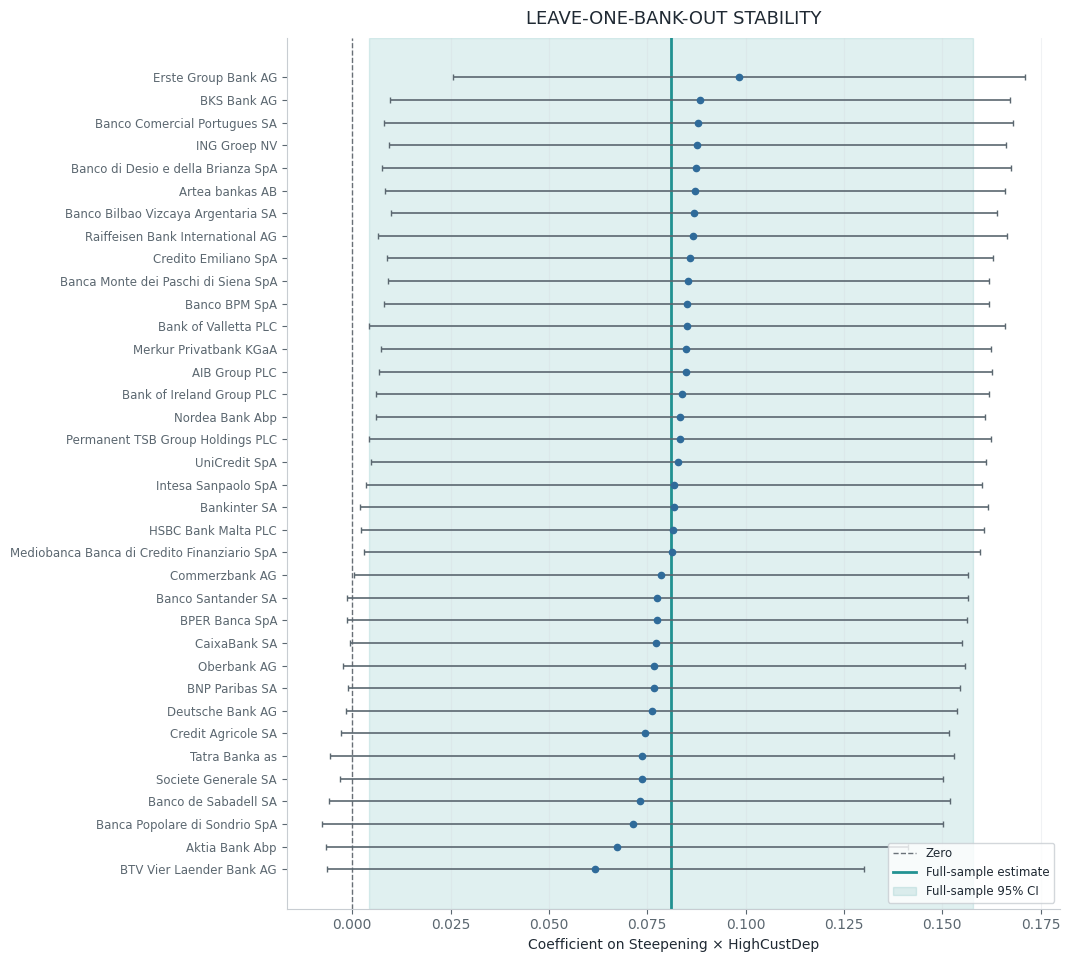

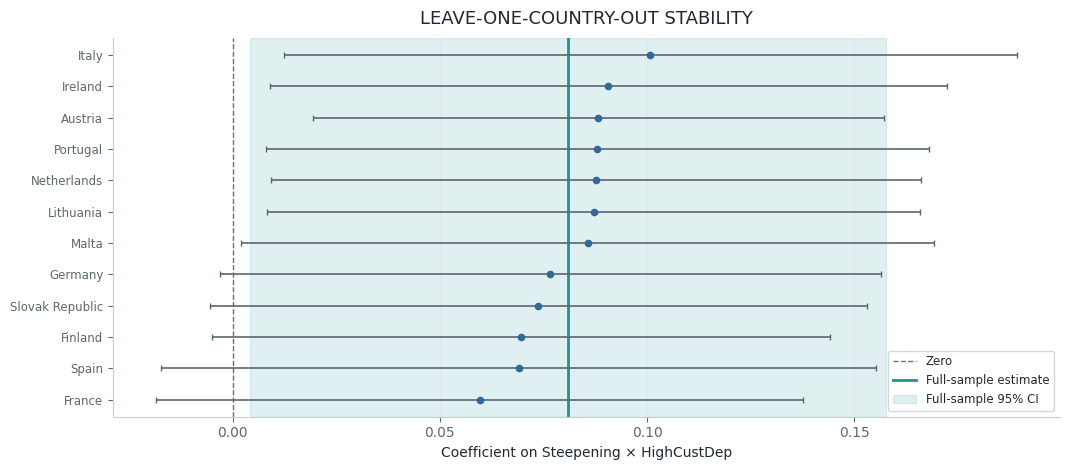

In [38]:
# ============================================================
# 20. TABLE/FIGURE R5 — LEAVE-ONE-OUT STABILITY
# ============================================================

if RUN_STABILITY_CHECKS and not df_main.empty:

    def loo_plot(table, label_col, coef_col, se_col, title, filename):
        plot = table.dropna(subset=[coef_col, se_col]).copy()
        if plot.empty:
            warn_msg(f"No valid rows to plot for {title}.")
            return None

        plot["ci_low"] = plot[coef_col] - 1.96 * plot[se_col]
        plot["ci_high"] = plot[coef_col] + 1.96 * plot[se_col]
        plot = plot.sort_values(coef_col)

        h = max(4.8, 0.27 * len(plot))
        fig, ax = plt.subplots(figsize=(10.8, h))
        fig.patch.set_facecolor(WP_FIG_BG)
        ax.set_facecolor(WP_AX_BG)

        y = np.arange(len(plot))

        ax.errorbar(
            plot[coef_col],
            y,
            xerr=1.96 * plot[se_col],
            fmt="o",
            markersize=4.5,
            linewidth=1.2,
            capsize=2.5,
            color=WP_BLUE,
            ecolor=WP_MUTED,
            zorder=3,
        )

        ax.axvline(0, color=WP_TEXT, linestyle="--", linewidth=1, alpha=0.65, label="Zero")
        ax.axvline(full_coef, color=WP_TEAL, linewidth=2, alpha=0.95, label="Full-sample estimate")
        ax.axvspan(full_ci_low, full_ci_high, color=WP_TEAL, alpha=0.13, label="Full-sample 95% CI")

        ax.set_yticks(y)
        ax.set_yticklabels(plot[label_col], fontsize=8.5)
        ax.set_title(title, fontsize=13, pad=10)
        ax.set_xlabel("Coefficient on Steepening × HighCustDep")
        ax.grid(True, axis="x", color=WP_GRID, alpha=0.35)

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

        ax.legend(
            loc="lower right",
            frameon=True,
            facecolor=WP_AX_BG,
            edgecolor=WP_BORDER,
            fontsize=8.5,
        )

        fig.tight_layout()
        path = OUT_DIR / filename
        fig.savefig(path, dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"Saved figure: {path.resolve()}")
        return fig

    # Full-sample benchmark.
    full_res = fit_panel(
        df_main,
        DEPENDENT_VAR,
        regs_asym_main,
        model_name="Full-sample benchmark for LOO",
        verbose=False,
    )

    full_coef = get_stat(full_res, STEPP_CUST, "coef")
    full_se = get_stat(full_res, STEPP_CUST, "se")
    full_ci_low = full_coef - 1.96 * full_se
    full_ci_high = full_coef + 1.96 * full_se

    # -----------------------------
    # Leave-one-bank-out
    # -----------------------------

    bank_name_col = find_first(df_main, ["bank_name", "name", "company_name"])
    bank_labels = (
        df_main[[BANK_COL, bank_name_col]]
        .dropna()
        .drop_duplicates(BANK_COL)
        .set_index(BANK_COL)[bank_name_col]
        .to_dict()
        if bank_name_col is not None else {}
    )

    loo_bank_rows = []

    for bank in sorted(df_main[BANK_COL].dropna().unique()):
        d = df_main.loc[df_main[BANK_COL] != bank].copy()

        res = fit_panel(
            d,
            DEPENDENT_VAR,
            regs_asym_main,
            model_name=f"Leave out bank {bank}",
            verbose=False,
        )

        loo_bank_rows.append({
            "left_out_bank": bank,
            "left_out_bank_label": bank_labels.get(bank, bank),
            "coef_steepening_highcustdep": get_stat(res, STEPP_CUST, "coef"),
            "se": get_stat(res, STEPP_CUST, "se"),
            "p": get_stat(res, STEPP_CUST, "p"),
            "nobs": res.get("nobs", np.nan),
            "n_banks": res.get("n_banks", np.nan),
            "status": "OK" if res.get("ok", False) else res.get("error", ""),
        })

    loo_bank_table = pd.DataFrame(loo_bank_rows)
    save_table(loo_bank_table, "16_table_r5_leave_one_bank_out_main_quality_sample.csv", display_table=False)
    all_tables["table_r5_leave_one_bank_out"] = loo_bank_table

    loo_plot(
        loo_bank_table,
        "left_out_bank_label",
        "coef_steepening_highcustdep",
        "se",
        "LEAVE-ONE-BANK-OUT STABILITY",
        "16_figure_r5a_leave_one_bank_out_stability.png",
    )

    # -----------------------------
    # Leave-one-country-out
    # -----------------------------

    if COUNTRY_COL is not None and COUNTRY_COL in df_main.columns:
        loo_country_rows = []

        for country in sorted(df_main[COUNTRY_COL].dropna().unique()):
            d = df_main.loc[df_main[COUNTRY_COL] != country].copy()

            res = fit_panel(
                d,
                DEPENDENT_VAR,
                regs_asym_main,
                model_name=f"Leave out country {country}",
                verbose=False,
            )

            loo_country_rows.append({
                "left_out_country": country,
                "coef_steepening_highcustdep": get_stat(res, STEPP_CUST, "coef"),
                "se": get_stat(res, STEPP_CUST, "se"),
                "p": get_stat(res, STEPP_CUST, "p"),
                "nobs": res.get("nobs", np.nan),
                "n_banks": res.get("n_banks", np.nan),
                "status": "OK" if res.get("ok", False) else res.get("error", ""),
            })

        loo_country_table = pd.DataFrame(loo_country_rows)
        save_table(loo_country_table, "16b_leave_one_country_out_main_quality_sample.csv", display_table=False)
        all_tables["leave_one_country_out"] = loo_country_table

        loo_plot(
            loo_country_table,
            "left_out_country",
            "coef_steepening_highcustdep",
            "se",
            "LEAVE-ONE-COUNTRY-OUT STABILITY",
            "16b_figure_r5b_leave_one_country_out_stability.png",
        )

else:
    print("Table/Figure R5 skipped. Set RUN_STABILITY_CHECKS=True and ensure df_main is non-empty.")


## E.6 Winsorized key regressions

Outlier-robust reruns of the main aggregate and mechanism specifications.


In [39]:
# ============================================================
# 20B. WINSORIZED KEY REGRESSIONS
# ============================================================

RUN_WINSORIZED_KEY_REGRESSIONS = True
WINSOR_LOWER = 0.01
WINSOR_UPPER = 0.99

if RUN_WINSORIZED_KEY_REGRESSIONS:

    def winsorize_series(s, lower=WINSOR_LOWER, upper=WINSOR_UPPER):
        x = as_numeric(s)
        lo, hi = x.quantile(lower), x.quantile(upper)
        return x.clip(lo, hi)

    def make_winsorized_regression_frame(data, label=""):
        d = data.copy()

        # Winsorize variables where outlier shocks/returns matter most.
        winsor_cols = [
            DEPENDENT_VAR,
            "delta_slope",
            "delta_short",
            "delta_sovspread",
            "delta_stress",
        ]

        for col in winsor_cols:
            if col in d.columns:
                d[col] = winsorize_series(d[col])

        # Reconstruct baseline ASYM decomposition.
        if "delta_slope" in d.columns:
            d["steepening"] = as_numeric(d["delta_slope"]).clip(lower=0)
            d["flattening"] = as_numeric(d["delta_slope"]).clip(upper=0)

        # Reconstruct aggregate customer-deposit interactions.
        for shock in ["steepening", "flattening", "delta_short", "delta_sovspread", "delta_stress"]:
            if shock in d.columns and "high_custdep" in d.columns:
                ensure_interaction(d, f"{shock}_x_high_custdep", shock, "high_custdep", overwrite=True, quiet=True)

        # Reconstruct mechanism interactions.
        if MECH_READY:
            if demand_high in d.columns:
                ensure_interaction(d, DEMAND_STEEP, "steepening", demand_high, overwrite=True, quiet=True)
                ensure_interaction(d, DEMAND_FLAT, "flattening", demand_high, overwrite=True, quiet=True)

            if time_high in d.columns:
                ensure_interaction(d, TIME_STEEP, "steepening", time_high, overwrite=True, quiet=True)
                ensure_interaction(d, TIME_FLAT, "flattening", time_high, overwrite=True, quiet=True)

        print(f"Winsorized frame created: {label} | rows={len(d):,}")
        return d

    # ------------------------------------------------------------
    # Winsorized samples
    # ------------------------------------------------------------

    df_main_w = make_winsorized_regression_frame(df_main, "df_main")
    df_mech_w = make_winsorized_regression_frame(df_mech, "df_mech") if MECH_READY and not df_mech.empty else df_mech.iloc[0:0].copy()

    # ------------------------------------------------------------
    # Key winsorized regressions
    # ------------------------------------------------------------

    specs_winsor = {
        "Main ASYM, winsorized": ModelSpec(
            df_main_w,
            DEPENDENT_VAR,
            regs_asym_main,
            "Winsorized main aggregate ASYM",
            keys=[STEPP_CUST],
        ),
        "+ rate/sovereign, winsorized": ModelSpec(
            df_main_w,
            DEPENDENT_VAR,
            regs_asym_rate_sov,
            "Winsorized ASYM + rate/sovereign channels",
            keys=[STEPP_CUST],
        ),
        "+ full macro/stress, winsorized": ModelSpec(
            df_main_w,
            DEPENDENT_VAR,
            regs_asym_full_macro,
            "Winsorized ASYM + full macro/stress channels",
            keys=[STEPP_CUST],
        ),
    }

    if MECH_READY and not df_mech_w.empty:
        specs_winsor["Preferred mechanism, winsorized"] = ModelSpec(
            df_mech_w,
            DEPENDENT_VAR,
            regs_mech_combined_asym,
            "Winsorized preferred deposit-composition mechanism",
            keys=[DEMAND_STEEP, TIME_STEEP],
        )

    res_winsor = run_model_specs(specs_winsor)

    coef_rows_winsor = {
        "steepening": {"Main ASYM, winsorized": STEPP_CUST, "+ rate/sovereign, winsorized": STEPP_CUST, "+ full macro/stress, winsorized": STEPP_CUST},
        "flattening": {"Main ASYM, winsorized": FLAT_CUST, "+ rate/sovereign, winsorized": FLAT_CUST, "+ full macro/stress, winsorized": FLAT_CUST},
        "short": {"+ rate/sovereign, winsorized": SHORT_CUST, "+ full macro/stress, winsorized": SHORT_CUST},
        "sov_level": {"+ rate/sovereign, winsorized": SOV, "+ full macro/stress, winsorized": SOV},
        "stress": {"+ full macro/stress, winsorized": STRESS_CUST},

        "demand_steep": {"Preferred mechanism, winsorized": DEMAND_STEEP},
        "time_steep": {"Preferred mechanism, winsorized": TIME_STEEP},
        "demand_flat": {"Preferred mechanism, winsorized": DEMAND_FLAT},
        "time_flat": {"Preferred mechanism, winsorized": TIME_FLAT},

        "tier1": "tier1_ratio_reg",
        "size": "size_reg",
    }

    row_labels_winsor = {
        "steepening": "Steepening × HighCustDep",
        "flattening": "Flattening × HighCustDep",
        "short": "ΔShort × HighCustDep",
        "sov_level": "ΔSovSpread",
        "sov_interaction": "ΔSovSpread × HighCustDep",
        "stress": "ΔStress/CISS × HighCustDep",

        "demand_steep": "Steepening × High Demand/Sight",
        "time_steep": "Steepening × High Time/Savings",
        "demand_flat": "Flattening × High Demand/Sight",
        "time_flat": "Flattening × High Time/Savings",

        "tier1": "Tier 1 ratio",
        "size": "Size",
    }

    table_winsor = print_multi_table(
        res_winsor,
        list(specs_winsor.keys()),
        coef_rows_winsor,
        row_labels_winsor,
        "ROBUSTNESS TABLE R6 — WINSORIZED KEY REGRESSIONS",
        "20b_table_r6_winsorized_key_regressions.csv",
    )

    all_results["table_r6_winsorized_key_regressions"] = res_winsor
    all_tables["table_r6_winsorized_key_regressions"] = table_winsor

    # ------------------------------------------------------------
    # Winsorized mechanism Wald differential
    # ------------------------------------------------------------

    if MECH_READY and "Preferred mechanism, winsorized" in res_winsor:
        if RUN_WALD_WCB:
            wald_winsor = fast_one_way_bank_wcb_linear_restriction(
                df_mech_w,
                DEPENDENT_VAR,
                regs_mech_combined_asym,
                DEMAND_STEEP,
                TIME_STEEP,
                "Winsorized steepening differential: Demand/Sight − Time/Savings",
                B=WCB_REPS,
                seed=WCB_SEED + 30_000,
            )
        else:
            wald_winsor = wald_equal_coefficients(
                res_winsor["Preferred mechanism, winsorized"],
                DEMAND_STEEP,
                TIME_STEEP,
                label="Winsorized steepening differential: Demand/Sight − Time/Savings",
            )

        table_winsor_wald = wald_result_table(
            [wald_winsor],
            "20b_table_r6_winsorized_wald_differential.csv",
        )

        all_wald["table_r6_winsorized_mechanism_wald"] = [wald_winsor]
        all_tables["table_r6_winsorized_wald_differential"] = table_winsor_wald

else:
    print("Winsorized key regressions skipped.")


Winsorized frame created: df_main | rows=5,318
Winsorized frame created: df_mech | rows=3,386
WCB: Main ASYM, winsorized | steepening_x_high_custdep
WCB: + rate/sovereign, winsorized | steepening_x_high_custdep
WCB: + full macro/stress, winsorized | steepening_x_high_custdep
WCB: Preferred mechanism, winsorized | steepening_x_high_demand_dep_share
WCB: Preferred mechanism, winsorized | steepening_x_high_savings_dep_share

ROBUSTNESS TABLE R6 — WINSORIZED KEY REGRESSIONS
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
                      Variable (1) Main ASYM, winsorized (2) + rate/sovereign, winsorized (3) + full macro/stress, winsorized (4) Preferred mechanism, winsorized
      Steepening × HighCustDep                  0.0685**                          0.0675*                              0.0513                                    
                                                (0.0342)                    

,Test,Contrast,Difference,SE(diff),t-stat,Analytic p,WCB p,Bootstrap draws,Observations,Banks,Months,Status
0,Winsorized steepening differential: Demand/Sig...,steepening_x_high_demand_dep_share − steepenin...,0.1108***,(0.0374),2.966,0.0030,0.0080,999/999,"3,386",31,165,OK


# F. Appendix and global diagnostics

Appendix-only specifications and notebook-wide diagnostic checks. These are useful for robustness documentation but should not replace the preferred main-specification interpretation.


## F.1 Appendix A — Broad generic slope baseline

Generic ΔSlope interactions before the steepening/flattening decomposition.


In [40]:

# ============================================================
# 21. APPENDIX A — BROAD GENERIC SLOPE BASELINE
# ============================================================

baseline_vars = [DEPENDENT_VAR, HIGH_CUSTDEP, DELTA_SLOPE_CUST, DELTA_SLOPE_BANKDEP, *CONTROLS_MAIN]
df_baseline = make_complete_sample(df_reg_full, baseline_vars, "df_appendix_a — broad generic slope baseline")

specs_app_a = {
    "ΔSlope × HighCustDep": ModelSpec(df_baseline, DEPENDENT_VAR, [HIGH_CUSTDEP, DELTA_SLOPE_CUST, *CONTROLS_MAIN], "Appendix A: ΔSlope × HighCustDep"),
    "ΔSlope × HighBankDep": ModelSpec(df_baseline, DEPENDENT_VAR, [DELTA_SLOPE_BANKDEP, *CONTROLS_MAIN], "Appendix A: ΔSlope × HighBankDep"),
}
res_app_a = run_model_specs(specs_app_a, attach_wcb=False)

coef_rows_app_a = {
    "custdep": DELTA_SLOPE_CUST,
    "bankdep": DELTA_SLOPE_BANKDEP,
    "tier1": "tier1_ratio_reg",
    "size": "size_reg",
}
row_labels_app_a = {
    "custdep": "ΔSlope × HighCustDep",
    "bankdep": "ΔSlope × HighBankDep",
    "tier1": "Tier 1 ratio",
    "size": "Size",
}

table_app_a = print_multi_table(
    res_app_a,
    ["ΔSlope × HighCustDep", "ΔSlope × HighBankDep"],
    coef_rows_app_a,
    row_labels_app_a,
    "APPENDIX TABLE A1 — BROAD GENERIC SLOPE BASELINE",
    "17_appendix_a1_broad_generic_slope_baseline.csv",
)

all_results["appendix_a_broad_baseline"] = res_app_a
all_tables["appendix_a_broad_baseline"] = table_app_a



APPENDIX TABLE A1 — BROAD GENERIC SLOPE BASELINE
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
            Variable  (1) ΔSlope × HighCustDep  (2) ΔSlope × HighBankDep
ΔSlope × HighCustDep                    0.0208                         —
                                      (0.0203)                          
                                     [p=0.307]                          
ΔSlope × HighBankDep                         —                  0.0356**
                                                                (0.0174)
                                                               [p=0.041]
        Tier 1 ratio                    0.0009                    0.0009
                                      (0.0009)                  (0.0009)
                                     [p=0.333]                 [p=0.330]
                Size                   -0.0071                   -0.0071
                      

## F.2 Appendix B — Bank-FE-only specifications

Appendix-only models without month fixed effects. These are useful for comparison but do not absorb common euro-area shocks.


In [41]:
# ============================================================
# 22. APPENDIX B — BANK-FE-ONLY ASYM SPECIFICATION
# ============================================================

if RUN_BANK_FE_ONLY_APPENDIX:

    regs_bankfe_asym = [
        "steepening",
        "flattening",
        HIGH_CUSTDEP,
        STEPP_CUST,
        FLAT_CUST,
        *CONTROLS_MAIN,
    ]

    specs_app_b = {
        "Bank FE ASYM": ModelSpec(
            df_main,
            DEPENDENT_VAR,
            regs_bankfe_asym,
            "Appendix B: Bank FE only — ASYM",
            entity_effects=True,
            time_effects=False,
            keys=[STEPP_CUST],
        ),
    }

    res_app_b = run_model_specs(specs_app_b, attach_wcb=False)

    coef_rows_app_b = {
        "steepening": "steepening",
        "flattening": "flattening",
        "steepening_x_high_custdep": STEPP_CUST,
        "flattening_x_high_custdep": FLAT_CUST,
        "tier1": "tier1_ratio_reg",
        "size": "size_reg",
    }

    row_labels_app_b = {
        "steepening": "Steepening",
        "flattening": "Flattening",
        "steepening_x_high_custdep": "Steepening × HighCustDep",
        "flattening_x_high_custdep": "Flattening × HighCustDep",
        "tier1": "Tier 1 ratio",
        "size": "Size",
    }

    table_app_b = print_multi_table(
        res_app_b,
        ["Bank FE ASYM"],
        coef_rows_app_b,
        row_labels_app_b,
        "APPENDIX TABLE B1 — BANK-FE-ONLY ASYM SPECIFICATION",
        "18_appendix_b1_bank_fe_only_asym.csv",
    )

    all_results["appendix_b_bankfe_only_asym"] = res_app_b
    all_tables["appendix_b_bankfe_only_asym"] = table_app_b

else:
    print("Appendix B skipped. Set RUN_BANK_FE_ONLY_APPENDIX=True to run.")



APPENDIX TABLE B1 — BANK-FE-ONLY ASYM SPECIFICATION
Dep. var.: r_excess | Fixed effects: Bank | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
                Variable          (1) Bank FE ASYM
              Steepening                -0.0757***
                                          (0.0236)
                                         [p=0.001]
              Flattening                 0.0948***
                                          (0.0289)
                                         [p=0.001]
Steepening × HighCustDep                  0.0811**
                                          (0.0383)
                                         [p=0.034]
Flattening × HighCustDep                   -0.0252
                                          (0.0425)
                                         [p=0.553]
            Tier 1 ratio                  0.0020**
                                          (0.0009)
                                         [p=0.026]
              

## F.3 Appendix C — HHI / competition triple interaction

Tests whether country-level market concentration amplifies the customer-deposit steepening effect.


In [42]:
# ============================================================
# 23. APPENDIX C — HHI / COMPETITION TRIPLE INTERACTION
# Runs on quality sample and includes full lower-order terms
# ============================================================

if RUN_HHI_APPENDIX:

    # ------------------------------------------------------------
    # 0. Restrict df_reg_full to the quality-sample bank-months
    #    This keeps all raw columns, including HHI, while using
    #    the same bank-month support as df_quality / df_main.
    # ------------------------------------------------------------

    quality_keys = df_quality[[BANK_COL, MONTH_COL]].drop_duplicates()

    df_hhi_base = (
        df_reg_full
        .merge(quality_keys, on=[BANK_COL, MONTH_COL], how="inner")
        .copy()
    )

    hhi_col = find_first(df_hhi_base, [
        "hhi_zstd",
        "hhi_assets_country_zstd",
        "hhi_assets_country_lag1_zstd",
        "hhi_assets_country",
        "hhi_reg",
        "banking_hhi",
        "market_hhi",
    ])

    if hhi_col is None:
        warn_msg("No HHI column found. Appendix C skipped.")

    else:
        # ------------------------------------------------------------
        # 1. Use z-scored HHI
        # ------------------------------------------------------------

        if hhi_col.endswith("zstd"):
            hhi_z = hhi_col
        else:
            hhi_z = "hhi_assets_country_appendix_zstd"
            ensure_zstd(df_hhi_base, hhi_z, hhi_col, overwrite=True)

        # ------------------------------------------------------------
        # 2. Construct lower-order and triple interactions
        #
        # Triple:
        #   Steepening × HighCustDep × HHI
        #
        # Required lower-order terms:
        #   HighCustDep
        #   HHI
        #   Steepening × HighCustDep
        #   Steepening × HHI
        #   HighCustDep × HHI
        #
        # Plus FLAT_CUST to preserve the ASYM baseline structure.
        # ------------------------------------------------------------

        ensure_interaction(
            df_hhi_base,
            "steepening_x_hhi_z",
            "steepening",
            hhi_z,
            overwrite=True,
            quiet=True,
        )

        ensure_interaction(
            df_hhi_base,
            "flattening_x_hhi_z",
            "flattening",
            hhi_z,
            overwrite=True,
            quiet=True,
        )

        ensure_interaction(
            df_hhi_base,
            "high_custdep_x_hhi_z",
            HIGH_CUSTDEP,
            hhi_z,
            overwrite=True,
            quiet=True,
        )

        ensure_interaction(
            df_hhi_base,
            "steepening_x_high_custdep_x_hhi_z",
            STEPP_CUST,
            hhi_z,
            overwrite=True,
            quiet=True,
        )

        # ------------------------------------------------------------
        # 3. Complete-case HHI sample, nested inside quality sample
        # ------------------------------------------------------------

        hhi_vars = [
            DEPENDENT_VAR,
            HIGH_CUSTDEP,
            hhi_z,
            STEPP_CUST,
            FLAT_CUST,
            "steepening_x_hhi_z",
            "flattening_x_hhi_z",
            "high_custdep_x_hhi_z",
            "steepening_x_high_custdep_x_hhi_z",
            *CONTROLS_MAIN,
        ]

        df_hhi = make_complete_sample(
            df_hhi_base,
            hhi_vars,
            "df_appendix_c — HHI triple interaction nested inside quality sample",
        )

        # ------------------------------------------------------------
        # 4. Hierarchical HHI triple-interaction specification
        # ------------------------------------------------------------

        regs_hhi_triple = [
            HIGH_CUSTDEP,
            hhi_z,
            STEPP_CUST,
            FLAT_CUST,
            "steepening_x_hhi_z",
            "flattening_x_hhi_z",
            "high_custdep_x_hhi_z",
            "steepening_x_high_custdep_x_hhi_z",
            *CONTROLS_MAIN,
        ]

        specs_app_c = {
            "HHI triple": ModelSpec(
                df_hhi,
                DEPENDENT_VAR,
                regs_hhi_triple,
                "Appendix C: HHI triple interaction, quality sample",
                keys=["steepening_x_high_custdep_x_hhi_z"],
            )
        }

        res_app_c = run_model_specs(specs_app_c, attach_wcb=False)

        # ------------------------------------------------------------
        # 5. Thesis-ready table rows
        # ------------------------------------------------------------

        coef_rows_app_c = {
            "high_custdep": HIGH_CUSTDEP,
            "hhi": hhi_z,
            "steep_custdep": STEPP_CUST,
            "flat_custdep": FLAT_CUST,
            "steep_hhi": "steepening_x_hhi_z",
            "flat_hhi": "flattening_x_hhi_z",
            "custdep_hhi": "high_custdep_x_hhi_z",
            "triple": "steepening_x_high_custdep_x_hhi_z",
            "tier1": "tier1_ratio_reg",
            "size": "size_reg",
        }

        row_labels_app_c = {
            "high_custdep": "HighCustDep",
            "hhi": "HHI z-score",
            "steep_custdep": "Steepening × HighCustDep",
            "flat_custdep": "Flattening × HighCustDep",
            "steep_hhi": "Steepening × HHI z-score",
            "flat_hhi": "Flattening × HHI z-score",
            "custdep_hhi": "HighCustDep × HHI z-score",
            "triple": "Steepening × HighCustDep × HHI z-score",
            "tier1": "Tier 1 ratio",
            "size": "Size",
        }

        table_app_c = print_multi_table(
            res_app_c,
            ["HHI triple"],
            coef_rows_app_c,
            row_labels_app_c,
            "APPENDIX TABLE C1 — HHI / COMPETITION TRIPLE INTERACTION, QUALITY SAMPLE",
            "19_appendix_c1_hhi_triple_interaction_quality_sample.csv",
        )

        all_results["appendix_c_hhi"] = res_app_c
        all_tables["appendix_c_hhi"] = table_app_c

else:
    print("Appendix C skipped. Set RUN_HHI_APPENDIX=True to run.")


APPENDIX TABLE C1 — HHI / COMPETITION TRIPLE INTERACTION, QUALITY SAMPLE
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
                              Variable            (1) HHI triple
                           HighCustDep                    0.0006
                                                        (0.0049)
                                                       [p=0.897]
                           HHI z-score                  0.0097**
                                                        (0.0038)
                                                       [p=0.011]
              Steepening × HighCustDep                  0.0864**
                                                        (0.0412)
                                                       [p=0.036]
              Flattening × HighCustDep                   -0.0150
                                                        (0.0313)
                     

## F.4 Appendix D — VIF full regression stack

Runs FE-residualized VIF diagnostics for every `ModelSpec` object created in the notebook.


In [43]:
# ============================================================
# 24. GLOBAL VIF / RESIDUALIZED-CORRELATION DIAGNOSTICS
# ============================================================

RUN_GLOBAL_VIF_DIAGNOSTICS = True

if RUN_GLOBAL_VIF_DIAGNOSTICS:

    def fe_residualized_X_from_spec(spec):
        work, regs = _prepare_work(spec.data, spec.dep, spec.regs)

        if work.empty:
            raise ValueError("No complete observations after _prepare_work().")

        bank_codes = pd.Categorical(work[BANK_COL].astype(str)).codes
        month_codes = pd.Categorical(pd.to_datetime(work[MONTH_COL]).dt.strftime("%Y-%m")).codes

        X = work[regs].to_numpy(float)

        Xw = within_transform(
            X,
            bank_codes,
            month_codes,
            entity_effects=spec.entity_effects,
            time_effects=spec.time_effects,
        )

        keep = np.sqrt((Xw ** 2).sum(axis=0)) > 1e-12
        kept_regs = [r for r, k in zip(regs, keep) if k]

        if len(kept_regs) == 0:
            raise ValueError("All regressors absorbed by fixed effects.")

        return work, pd.DataFrame(Xw[:, keep], columns=kept_regs, index=work.index)


    def vif_one_var(X, var):
        others = [c for c in X.columns if c != var]

        if len(others) == 0:
            return np.nan

        y = X[var].to_numpy(float)

        if np.nanstd(y) == 0:
            return np.nan

        Z = X[others].to_numpy(float)

        beta = np.linalg.pinv(Z.T @ Z) @ Z.T @ y
        resid = y - Z @ beta

        sst = float(np.sum(y ** 2))
        ssr = float(np.sum(resid ** 2))

        if sst <= 0:
            return np.nan

        r2 = max(0.0, min(1.0, 1.0 - ssr / sst))
        return np.inf if r2 >= 0.999999 else 1.0 / (1.0 - r2)


    def max_abs_pairwise_corr(X):
        if X.shape[1] < 2:
            return np.nan, "", ""

        C = X.corr().abs().copy()
        C_arr = C.to_numpy(copy=True)
        np.fill_diagonal(C_arr, np.nan)
        C = pd.DataFrame(C_arr, index=C.index, columns=C.columns)

        if C.isna().all().all():
            return np.nan, "", ""

        i, j = np.where(C.to_numpy() == np.nanmax(C.to_numpy()))
        return float(C.iloc[i[0], j[0]]), C.index[i[0]], C.columns[j[0]]


    def collect_model_specs_from_globals():
        """
        Finds all ModelSpec dictionaries created in the notebook.
        Includes normal specs_* objects plus appendix/alternative/CISS spec dicts.
        """
        out = []

        for obj_name, obj in list(globals().items()):
            if not isinstance(obj, dict):
                continue

            is_spec_dict = (
                obj_name.startswith("specs_")
                or obj_name in [
                    "alt_specs",
                    "ciss_asym_specs",
                    "specs_app_a",
                    "specs_app_b",
                    "specs_app_c",
                    "specs_winsor",
                    "specs_r1",
                    "specs_r2",
                    "specs_r4",
                ]
            )

            if not is_spec_dict:
                continue

            for model_key, spec in obj.items():
                if isinstance(spec, ModelSpec):
                    out.append((obj_name, model_key, spec))

        # Drop exact duplicates caused by reused references.
        seen = set()
        unique = []

        for obj_name, model_key, spec in out:
            key = (obj_name, model_key, id(spec))
            if key not in seen:
                seen.add(key)
                unique.append((obj_name, model_key, spec))

        return unique


    scanned_specs = collect_model_specs_from_globals()
    print(f"ModelSpec objects found for global VIF scan: {len(scanned_specs)}")

    if len(scanned_specs) == 0:
        warn_msg("No ModelSpec objects found. Run this cell after the regression tables have been created.")

    vif_long_rows = []
    vif_summary_rows = []

    for spec_group, model_key, spec in scanned_specs:
        try:
            work, Xw = fe_residualized_X_from_spec(spec)

            vif_values = {var: vif_one_var(Xw, var) for var in Xw.columns}
            max_corr, corr_var_a, corr_var_b = max_abs_pairwise_corr(Xw)

            for var, vif in vif_values.items():
                vif_long_rows.append({
                    "spec_group": spec_group,
                    "model": model_key,
                    "variable": var,
                    "vif_after_fe": vif,
                    "observations": int(len(work)),
                    "banks": int(work[BANK_COL].nunique()),
                    "months": int(work[MONTH_COL].nunique()),
                    "fixed_effects": _fe_label(spec.entity_effects, spec.time_effects),
                    "status": "OK",
                })

            finite_vifs = pd.Series(vif_values, dtype="float64").replace([np.inf, -np.inf], np.nan)

            vif_summary_rows.append({
                "spec_group": spec_group,
                "model": model_key,
                "max_vif_after_fe": finite_vifs.max(),
                "mean_vif_after_fe": finite_vifs.mean(),
                "variables_with_vif_gt_5": int((finite_vifs > 5).sum()),
                "variables_with_vif_gt_10": int((finite_vifs > 10).sum()),
                "max_abs_pairwise_corr_after_fe": max_corr,
                "max_corr_var_a": corr_var_a,
                "max_corr_var_b": corr_var_b,
                "observations": int(len(work)),
                "banks": int(work[BANK_COL].nunique()),
                "months": int(work[MONTH_COL].nunique()),
                "fixed_effects": _fe_label(spec.entity_effects, spec.time_effects),
                "status": "OK",
            })

        except Exception as exc:
            vif_summary_rows.append({
                "spec_group": spec_group,
                "model": model_key,
                "max_vif_after_fe": np.nan,
                "mean_vif_after_fe": np.nan,
                "variables_with_vif_gt_5": np.nan,
                "variables_with_vif_gt_10": np.nan,
                "max_abs_pairwise_corr_after_fe": np.nan,
                "max_corr_var_a": "",
                "max_corr_var_b": "",
                "observations": np.nan,
                "banks": np.nan,
                "months": np.nan,
                "fixed_effects": _fe_label(spec.entity_effects, spec.time_effects),
                "status": str(exc),
            })

    vif_long_table = pd.DataFrame(vif_long_rows)
    vif_summary_table = pd.DataFrame(vif_summary_rows)

    for table in [vif_long_table, vif_summary_table]:
        if not table.empty:
            for c in table.columns:
                if any(k in c for k in ["vif", "corr"]):
                    table[c] = pd.to_numeric(table[c], errors="coerce").round(4)

    if not vif_summary_table.empty and "max_vif_after_fe" in vif_summary_table.columns:
        vif_summary_sorted = vif_summary_table.sort_values(
            "max_vif_after_fe",
            ascending=False,
            na_position="last",
        )

        save_table(
            vif_summary_sorted,
            "24_global_vif_summary_by_regression.csv",
        )

        print("\nTop 15 regressions by max FE-residualized VIF:")
        show_df(vif_summary_sorted.head(15))

    else:
        warn_msg("Global VIF summary table is empty. No model-level VIF diagnostics were produced.")

    if not vif_long_table.empty and "vif_after_fe" in vif_long_table.columns:
        vif_long_sorted = vif_long_table.sort_values(
            ["vif_after_fe", "spec_group", "model"],
            ascending=[False, True, True],
            na_position="last",
        )

        save_table(
            vif_long_sorted,
            "24_global_vif_long_by_variable.csv",
            display_table=False,
        )

        print("\nTop 20 variables by FE-residualized VIF:")
        show_df(vif_long_sorted.head(20))

    else:
        warn_msg("Global VIF long table is empty. No variable-level VIF rows were produced.")

    all_tables["global_vif_summary"] = vif_summary_table
    all_tables["global_vif_long"] = vif_long_table

else:
    print("Global VIF diagnostics skipped.")


ModelSpec objects found for global VIF scan: 26
Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\24_global_vif_summary_by_regression.csv


,spec_group,model,max_vif_after_fe,mean_vif_after_fe,variables_with_vif_gt_5,variables_with_vif_gt_10,max_abs_pairwise_corr_after_fe,max_corr_var_a,max_corr_var_b,observations,banks,months,fixed_effects,status
8,specs_table4,Preferred ASYM mechanism,3.8798,2.6713,0,0,0.7938,NaN,NaN,3386,31,165,Bank + month,OK
21,specs_winsor,"Preferred mechanism, winsorized",3.6362,2.5981,0,0,0.7779,NaN,NaN,3386,31,165,Bank + month,OK
24,specs_app_b,Bank FE ASYM,2.4865,1.9508,0,0,0.6797,NaN,NaN,5318,36,165,Bank,OK
13,specs_quad,Quadrant ASYM split,2.4345,1.7416,0,0,0.4951,NaN,NaN,5318,36,165,Bank + month,OK
25,specs_app_c,HHI triple,1.8627,1.3544,0,0,0.5889,NaN,NaN,5318,36,165,Bank + month,OK
12,specs_r1,+ loan-share interactions,1.7392,1.4348,0,0,0.4543,NaN,NaN,5318,36,165,Bank + month,OK
20,specs_winsor,"+ full macro/stress, winsorized",1.5029,1.1879,0,0,0.3225,NaN,NaN,5318,36,165,Bank + month,OK
19,specs_winsor,"+ rate/sovereign, winsorized",1.4898,1.2026,0,0,0.3225,NaN,NaN,5318,36,165,Bank + month,OK
5,specs_table2,+ macro controls,1.4551,1.1759,0,0,0.3098,NaN,NaN,5318,36,165,Bank + month,OK
2,specs_table1,+ full macro/stress,1.4551,1.1759,0,0,0.3098,NaN,NaN,5318,36,165,Bank + month,OK



Top 15 regressions by max FE-residualized VIF:


,spec_group,model,max_vif_after_fe,mean_vif_after_fe,variables_with_vif_gt_5,variables_with_vif_gt_10,max_abs_pairwise_corr_after_fe,max_corr_var_a,max_corr_var_b,observations,banks,months,fixed_effects,status
8,specs_table4,Preferred ASYM mechanism,3.8798,2.6713,0,0,0.7938,NaN,NaN,3386,31,165,Bank + month,OK
21,specs_winsor,"Preferred mechanism, winsorized",3.6362,2.5981,0,0,0.7779,NaN,NaN,3386,31,165,Bank + month,OK
24,specs_app_b,Bank FE ASYM,2.4865,1.9508,0,0,0.6797,NaN,NaN,5318,36,165,Bank,OK
13,specs_quad,Quadrant ASYM split,2.4345,1.7416,0,0,0.4951,NaN,NaN,5318,36,165,Bank + month,OK
25,specs_app_c,HHI triple,1.8627,1.3544,0,0,0.5889,NaN,NaN,5318,36,165,Bank + month,OK
12,specs_r1,+ loan-share interactions,1.7392,1.4348,0,0,0.4543,NaN,NaN,5318,36,165,Bank + month,OK
20,specs_winsor,"+ full macro/stress, winsorized",1.5029,1.1879,0,0,0.3225,NaN,NaN,5318,36,165,Bank + month,OK
19,specs_winsor,"+ rate/sovereign, winsorized",1.4898,1.2026,0,0,0.3225,NaN,NaN,5318,36,165,Bank + month,OK
5,specs_table2,+ macro controls,1.4551,1.1759,0,0,0.3098,NaN,NaN,5318,36,165,Bank + month,OK
2,specs_table1,+ full macro/stress,1.4551,1.1759,0,0,0.3098,NaN,NaN,5318,36,165,Bank + month,OK


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\24_global_vif_long_by_variable.csv

Top 20 variables by FE-residualized VIF:


,spec_group,model,variable,vif_after_fe,observations,banks,months,fixed_effects,status
55,specs_table4,Preferred ASYM mechanism,flattening_x_high_savings_dep_share,3.8798,3386,31,165,Bank + month,OK
54,specs_table4,Preferred ASYM mechanism,flattening_x_high_demand_dep_share,3.8793,3386,31,165,Bank + month,OK
52,specs_table4,Preferred ASYM mechanism,steepening_x_high_demand_dep_share,3.6808,3386,31,165,Bank + month,OK
53,specs_table4,Preferred ASYM mechanism,steepening_x_high_savings_dep_share,3.6719,3386,31,165,Bank + month,OK
138,specs_winsor,"Preferred mechanism, winsorized",flattening_x_high_savings_dep_share,3.6362,3386,31,165,Bank + month,OK
137,specs_winsor,"Preferred mechanism, winsorized",flattening_x_high_demand_dep_share,3.6361,3386,31,165,Bank + month,OK
135,specs_winsor,"Preferred mechanism, winsorized",steepening_x_high_demand_dep_share,3.6288,3386,31,165,Bank + month,OK
136,specs_winsor,"Preferred mechanism, winsorized",steepening_x_high_savings_dep_share,3.6196,3386,31,165,Bank + month,OK
151,specs_app_b,Bank FE ASYM,steepening_x_high_custdep,2.4865,5318,36,165,Bank,OK
152,specs_app_b,Bank FE ASYM,flattening_x_high_custdep,2.4709,5318,36,165,Bank,OK


## F.5 Notebook run summary

Exports a compact model-run summary and the final sample registry.


In [44]:

# ============================================================
# F.6 NOTEBOOK RUN SUMMARY
# ============================================================

summary_rows = []
for group_name, result_group in all_results.items():
    if isinstance(result_group, dict):
        for model_name, res in result_group.items():
            if isinstance(res, dict):
                summary_rows.append({
                    "table_group": group_name,
                    "model": model_name,
                    "ok": res.get("ok", False),
                    "nobs": res.get("nobs", np.nan),
                    "n_banks": res.get("n_banks", np.nan),
                    "n_months": res.get("n_months", np.nan),
                    "sample_start": res.get("sample_start", pd.NaT),
                    "sample_end": res.get("sample_end", pd.NaT),
                    "fixed_effects": res.get("fe_label", ""),
                    "std_errors": res.get("se_label", ""),
                    "engine": res.get("engine", ""),
                    "error": res.get("error", ""),
                })

summary_table = pd.DataFrame(summary_rows)
for c in ["sample_start", "sample_end"]:
    if c in summary_table.columns:
        summary_table[c] = pd.to_datetime(summary_table[c], errors="coerce").dt.strftime("%Y-%m")

save_table(summary_table, "99_model_run_summary.csv")

# Final sample registry, including appendix samples appended after the early sample-definition table.
final_sample_table = pd.DataFrame(SAMPLE_REGISTRY)
save_table(final_sample_table, "99_sample_registry_final.csv", display_table=False)

print("\nDone.")
print(f"Input panel    : {panel_path}")
print(f"Sample window  : {SAMPLE_START:%Y-%m} to {SAMPLE_END:%Y-%m}")
print(f"Output folder  : {OUT_DIR.resolve()}")
print(f"CSV files      : {len(list(OUT_DIR.glob('*.csv'))):,}")
print(f"TXT files      : {len(list(OUT_DIR.glob('*.txt'))):,}")
print(f"PNG files      : {len(list(OUT_DIR.glob('*.png'))):,}")


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\99_model_run_summary.csv


,table_group,model,ok,nobs,n_banks,n_months,sample_start,sample_end,fixed_effects,std_errors,engine,error
0,table1_aggregate_asymmetry,Main ASYM,True,5318,36,165,2011-04,2024-12,Bank + month,One-way clustered by bank,linearmodels.PanelOLS,
1,table1_aggregate_asymmetry,+ short-rate + sovereign,True,5318,36,165,2011-04,2024-12,Bank + month,One-way clustered by bank,linearmodels.PanelOLS,
2,table1_aggregate_asymmetry,+ full macro/stress,True,5318,36,165,2011-04,2024-12,Bank + month,One-way clustered by bank,linearmodels.PanelOLS,
3,table2_quality_sample_controls,ASYM quality sample,True,5318,36,165,2011-04,2024-12,Bank + month,One-way clustered by bank,linearmodels.PanelOLS,
4,table2_quality_sample_controls,+ bank-quality controls,True,5318,36,165,2011-04,2024-12,Bank + month,One-way clustered by bank,linearmodels.PanelOLS,
5,table2_quality_sample_controls,+ macro controls,True,5318,36,165,2011-04,2024-12,Bank + month,One-way clustered by bank,linearmodels.PanelOLS,
6,table3_mechanism_sample_bridge,Main quality sample,True,5318,36,165,2011-04,2024-12,Bank + month,One-way clustered by bank,linearmodels.PanelOLS,
7,table3_mechanism_sample_bridge,Nested mechanism sample,True,3386,31,165,2011-04,2024-12,Bank + month,One-way clustered by bank,linearmodels.PanelOLS,
8,table4_deposit_composition_mechanism,Preferred ASYM mechanism,True,3386,31,165,2011-04,2024-12,Bank + month,One-way clustered by bank,linearmodels.PanelOLS,
9,table6_ciss_aggregate_asym,Low CISS,True,2728,36,82,2012-12,2024-12,Bank + month,One-way clustered by bank,linearmodels.PanelOLS,


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\99_sample_registry_final.csv

Done.
Input panel    : c:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\final_panel.csv
Sample window  : 2011-04 to 2024-12
Output folder  : C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored
CSV files      : 77
TXT files      : 28
PNG files      : 18


## F.6 Post-FE residualized VIF figures

White-paper styled VIF summary figures and residualized-correlation heatmaps.


ModelSpec objects found for post-FE VIF scan: 26
Saved summary VIF table: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\24a_post_fe_vif_summary_all_models.csv
Saved long VIF table:    C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\24b_post_fe_vif_all_variables_all_models.csv

Top 10 model-level max VIFs:


,Spec group,Model,Model display,Max post-FE VIF,Mean post-FE VIF,Variables with VIF > 5,Variables with VIF > 10,Max abs. post-FE pairwise corr.,Max corr variable A,Max corr variable B,Observations,Banks,Months,Fixed effects,Status
8,specs_table4,Preferred ASYM mechanism,table4: Preferred ASYM mechanism,3.8798,2.6713,0,0,0.7938,Flattening × High Demand/Sight,Flattening × High Time/Savings,3386,31,165,Bank + month,OK
21,specs_winsor,"Preferred mechanism, winsorized","winsor: Preferred mechanism, winsorized",3.6362,2.5981,0,0,0.7779,Flattening × High Demand/Sight,Flattening × High Time/Savings,3386,31,165,Bank + month,OK
24,specs_app_b,Bank FE ASYM,app_b: Bank FE ASYM,2.4865,1.9508,0,0,0.6797,Steepening,Steepening × HighCustDep,5318,36,165,Bank,OK
13,specs_quad,Quadrant ASYM split,quad: Quadrant ASYM split,2.4345,1.7416,0,0,0.4951,quad_highdep_highloan,quad_lowdep_highloan,5318,36,165,Bank + month,OK
25,specs_app_c,HHI triple,app_c: HHI triple,1.8627,1.3544,0,0,0.5889,Steepening × HHI,Steepening × HighCustDep × HHI,5318,36,165,Bank + month,OK
12,specs_r1,+ loan-share interactions,r1: + loan-share interactions,1.7392,1.4348,0,0,0.4543,Steepening × HighCustDep,Steepening × Loan Share,5318,36,165,Bank + month,OK
20,specs_winsor,"+ full macro/stress, winsorized","winsor: + full macro/stress, winsorized",1.5029,1.1879,0,0,0.3225,Flattening × HighCustDep,ΔShort × HighCustDep,5318,36,165,Bank + month,OK
19,specs_winsor,"+ rate/sovereign, winsorized","winsor: + rate/sovereign, winsorized",1.4898,1.2026,0,0,0.3225,Flattening × HighCustDep,ΔShort × HighCustDep,5318,36,165,Bank + month,OK
5,specs_table2,+ macro controls,table2: + macro controls,1.4551,1.1759,0,0,0.3098,high_custdep,Steepening × HighCustDep,5318,36,165,Bank + month,OK
2,specs_table1,+ full macro/stress,table1: + full macro/stress,1.4551,1.1759,0,0,0.3098,high_custdep,Steepening × HighCustDep,5318,36,165,Bank + month,OK



Top 15 variable-level VIFs:


,Spec group,Model,Model display,Variable,Raw variable,Post-FE VIF,Observations,Banks,Months,Fixed effects,Status
55,specs_table4,Preferred ASYM mechanism,table4: Preferred ASYM mechanism,Flattening × High Time/Savings,flattening_x_high_savings_dep_share,3.8798,3386,31,165,Bank + month,OK
54,specs_table4,Preferred ASYM mechanism,table4: Preferred ASYM mechanism,Flattening × High Demand/Sight,flattening_x_high_demand_dep_share,3.8793,3386,31,165,Bank + month,OK
52,specs_table4,Preferred ASYM mechanism,table4: Preferred ASYM mechanism,Steepening × High Demand/Sight,steepening_x_high_demand_dep_share,3.6808,3386,31,165,Bank + month,OK
53,specs_table4,Preferred ASYM mechanism,table4: Preferred ASYM mechanism,Steepening × High Time/Savings,steepening_x_high_savings_dep_share,3.6719,3386,31,165,Bank + month,OK
138,specs_winsor,"Preferred mechanism, winsorized","winsor: Preferred mechanism, winsorized",Flattening × High Time/Savings,flattening_x_high_savings_dep_share,3.6362,3386,31,165,Bank + month,OK
137,specs_winsor,"Preferred mechanism, winsorized","winsor: Preferred mechanism, winsorized",Flattening × High Demand/Sight,flattening_x_high_demand_dep_share,3.6361,3386,31,165,Bank + month,OK
135,specs_winsor,"Preferred mechanism, winsorized","winsor: Preferred mechanism, winsorized",Steepening × High Demand/Sight,steepening_x_high_demand_dep_share,3.6288,3386,31,165,Bank + month,OK
136,specs_winsor,"Preferred mechanism, winsorized","winsor: Preferred mechanism, winsorized",Steepening × High Time/Savings,steepening_x_high_savings_dep_share,3.6196,3386,31,165,Bank + month,OK
151,specs_app_b,Bank FE ASYM,app_b: Bank FE ASYM,Steepening × HighCustDep,steepening_x_high_custdep,2.4865,5318,36,165,Bank,OK
152,specs_app_b,Bank FE ASYM,app_b: Bank FE ASYM,Flattening × HighCustDep,flattening_x_high_custdep,2.4709,5318,36,165,Bank,OK


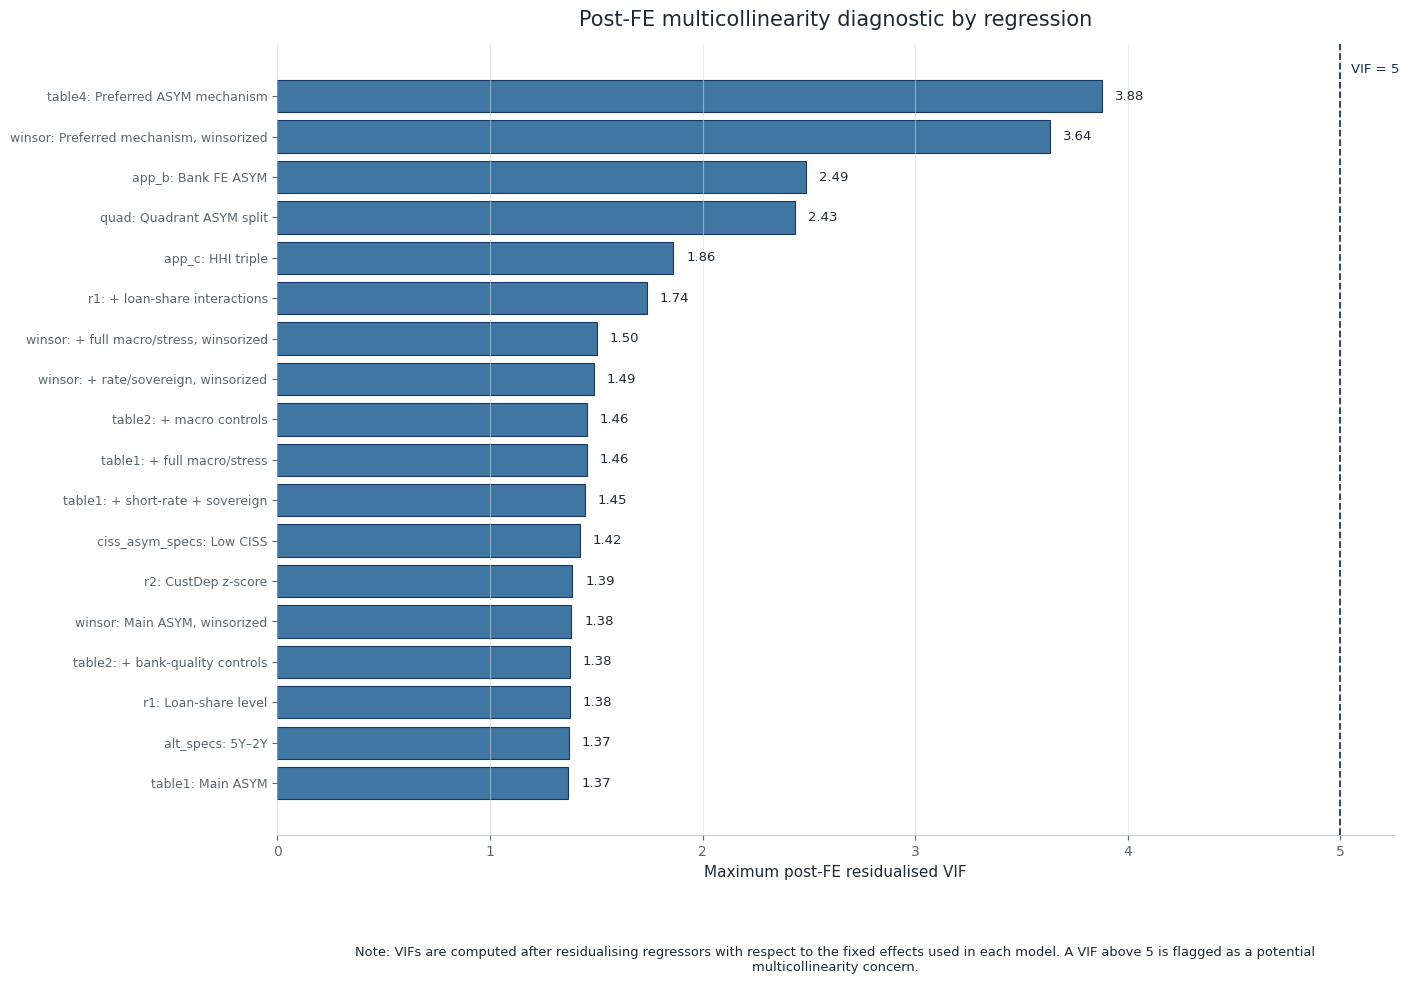

Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\24a_figure_post_fe_vif_by_model_blue_theme.png


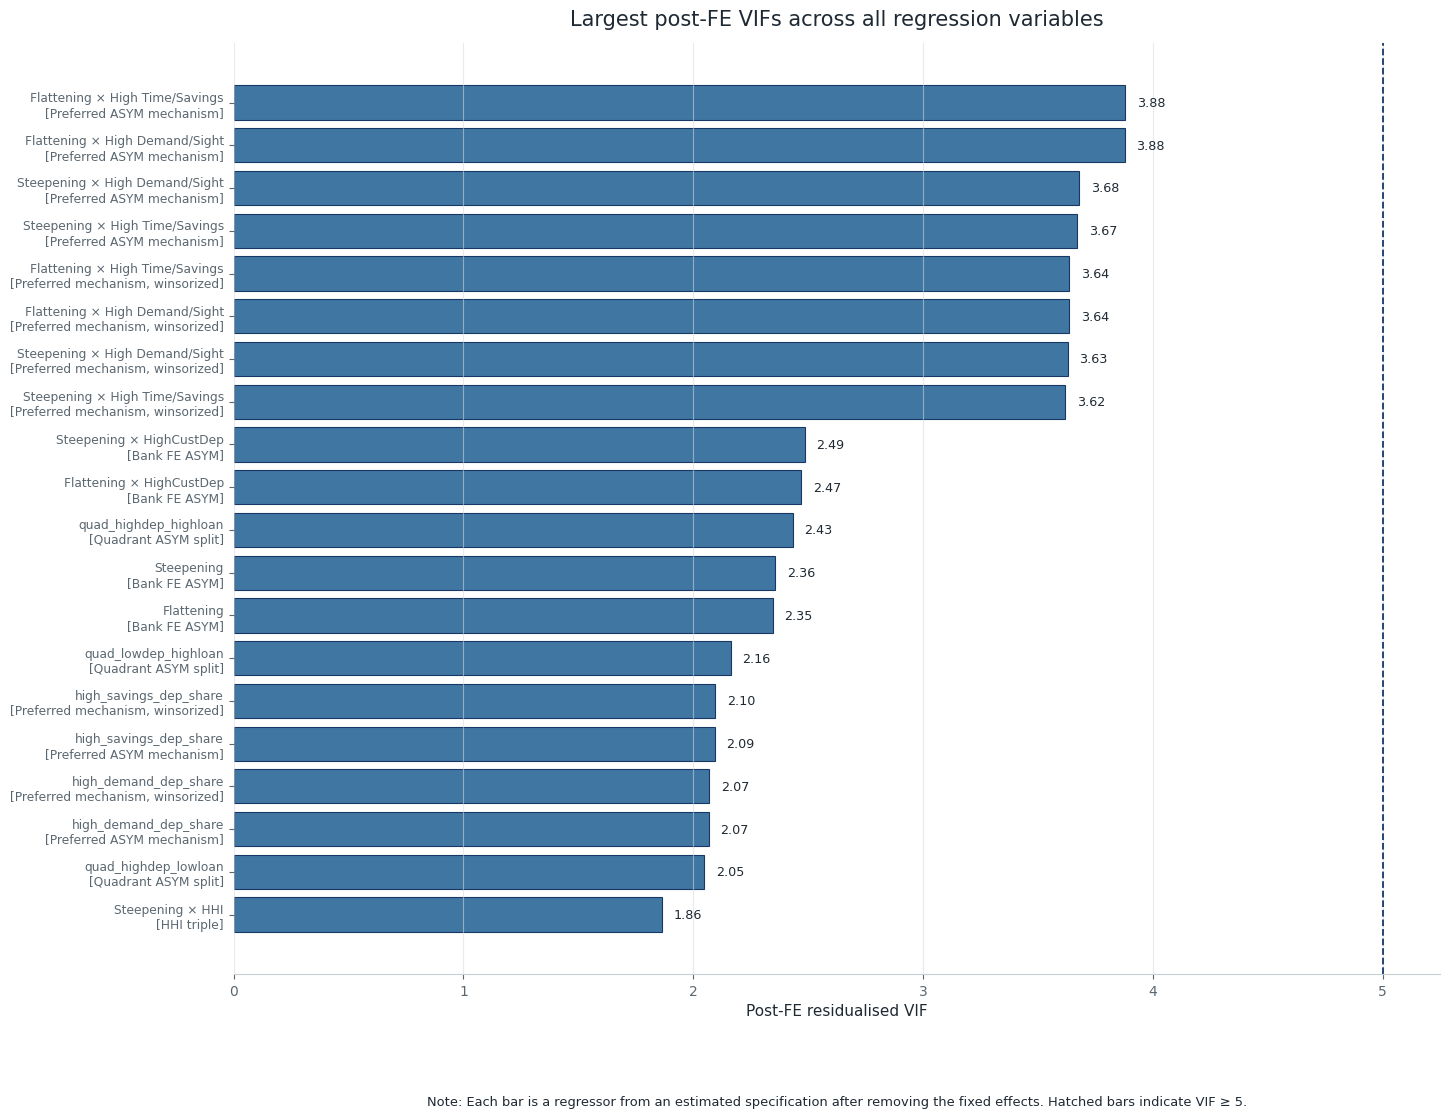

Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\24b_figure_top_post_fe_vif_variables_blue_theme.png


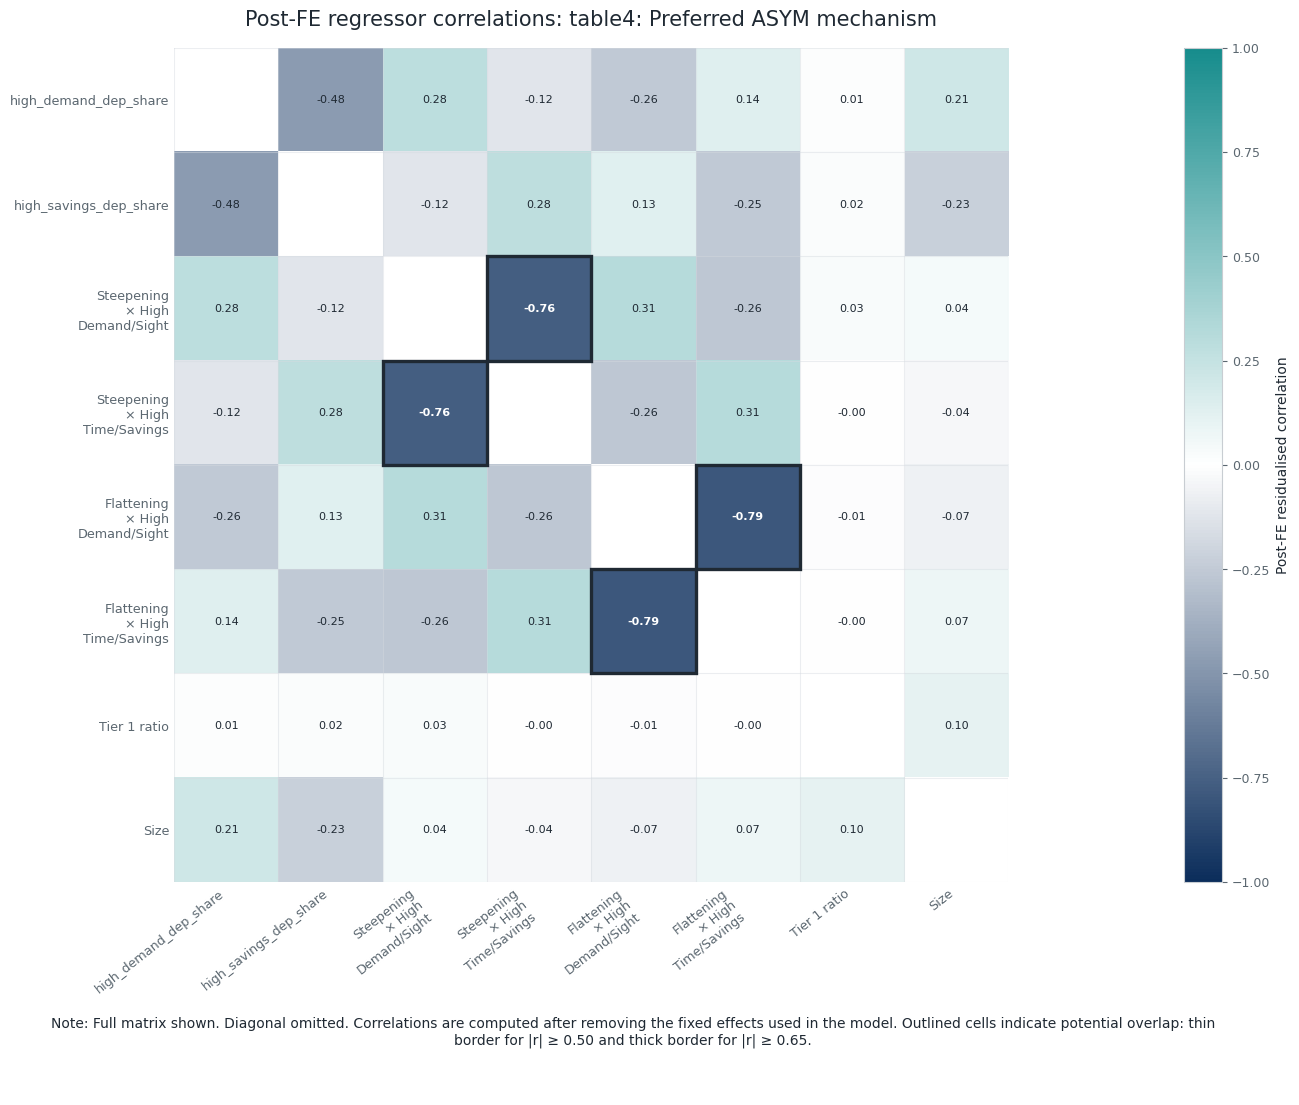

Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\24c_figure_post_fe_regressor_correlation_table4_preferred_asym_mechanism.png


In [45]:
# %%
# ============================================================
# APPENDIX D — POST-FE RESIDUALISED VIF DIAGNOSTICS
# All ModelSpec regressions + same thesis figure design
# ============================================================

RUN_GLOBAL_FE_VIF_DIAGNOSTICS = True

if RUN_GLOBAL_FE_VIF_DIAGNOSTICS:

    from matplotlib.patches import Rectangle
    from matplotlib.colors import LinearSegmentedColormap
    from textwrap import fill
    import re

    # ------------------------------------------------------------
    # 0. Theme
    # ------------------------------------------------------------

    BG = WP_FIG_BG
    AX_BG = WP_AX_BG
    NAVY = WP_NAVY
    BLUE = WP_BLUE
    TEAL = WP_TEAL
    GRID = WP_GRID
    TEXT = WP_TEXT

    vif_cmap = LinearSegmentedColormap.from_list(
        "navy_white_teal",
        [
            (0.00, NAVY),
            (0.50, WP_AX_BG),
            (1.00, TEAL),
        ],
    )

    def safe_file_label(x):
        return re.sub(r"[^A-Za-z0-9]+", "_", str(x)).strip("_").lower()

    # ------------------------------------------------------------
    # 1. Variable labels
    # ------------------------------------------------------------

    VIF_LABELS = {
        STEPP_CUST: "Steepening × HighCustDep",
        FLAT_CUST: "Flattening × HighCustDep",
        SHORT_CUST: "ΔShort × HighCustDep",
        STRESS_CUST: "ΔStress × HighCustDep",

        DEMAND_STEEP if "DEMAND_STEEP" in globals() else "": "Steepening × High Demand/Sight",
        TIME_STEEP if "TIME_STEEP" in globals() else "": "Steepening × High Time/Savings",
        DEMAND_FLAT if "DEMAND_FLAT" in globals() else "": "Flattening × High Demand/Sight",
        TIME_FLAT if "TIME_FLAT" in globals() else "": "Flattening × High Time/Savings",

        "delta_slope_x_high_custdep": "ΔSlope × HighCustDep",
        "delta_slope_x_high_bankdep": "ΔSlope × HighBankDep",
        "steepening_x_custdep_zstd": "Steepening × CustDep z-score",
        "flattening_x_custdep_zstd": "Flattening × CustDep z-score",

        "loan_share_zstd": "Loan Share z-score",
        "steepening_x_loan_share_zstd": "Steepening × Loan Share",
        "flattening_x_loan_share_zstd": "Flattening × Loan Share",

        "tier1_ratio_reg": "Tier 1 ratio",
        "size_reg": "Size",
        "roaa_reg": "ROAA",
        "credit_risk_reg": "Credit risk",

        "steepening_x_hhi_z": "Steepening × HHI",
        "high_custdep_x_hhi_z": "HighCustDep × HHI",
        "steepening_x_high_custdep_x_hhi_z": "Steepening × HighCustDep × HHI",

        "steepening": "Steepening",
        "flattening": "Flattening",
    }

    def pretty_var_name(x):
        return VIF_LABELS.get(x, x)

    def short_model_label(group, model):
        group_clean = str(group).replace("specs_", "").replace("spec_", "")
        return f"{group_clean}: {model}"

    # ------------------------------------------------------------
    # 2. Collect every ModelSpec dictionary in notebook
    # ------------------------------------------------------------

    def collect_all_model_specs():
        out = []

        for obj_name, obj in list(globals().items()):
            if not isinstance(obj, dict):
                continue

            for model_key, spec in obj.items():
                if isinstance(spec, ModelSpec):
                    out.append((obj_name, model_key, spec))

        # Remove exact duplicates
        seen = set()
        unique = []

        for obj_name, model_key, spec in out:
            key = (obj_name, model_key, id(spec))
            if key not in seen:
                seen.add(key)
                unique.append((obj_name, model_key, spec))

        return unique

    scanned_specs = collect_all_model_specs()

    print(f"ModelSpec objects found for post-FE VIF scan: {len(scanned_specs)}")

    if len(scanned_specs) == 0:
        raise RuntimeError("No ModelSpec objects found. Run this cell after the regression specification cells.")

    # ------------------------------------------------------------
    # 3. Post-FE design + VIF helpers
    # ------------------------------------------------------------

    def fe_residualized_design(spec):
        work, regs = _prepare_work(spec.data, spec.dep, spec.regs)

        if work.empty:
            raise ValueError("No complete observations.")

        bank_codes = pd.Categorical(work[BANK_COL].astype(str)).codes
        month_codes = pd.Categorical(pd.to_datetime(work[MONTH_COL]).dt.strftime("%Y-%m")).codes

        X = work[regs].to_numpy(float)

        Xw = within_transform(
            X,
            bank_codes,
            month_codes,
            entity_effects=spec.entity_effects,
            time_effects=spec.time_effects,
        )

        keep = np.sqrt((Xw ** 2).sum(axis=0)) > 1e-12
        kept_regs = [r for r, k in zip(regs, keep) if k]

        if len(kept_regs) == 0:
            raise ValueError("All regressors absorbed by fixed effects.")

        return work, pd.DataFrame(Xw[:, keep], columns=kept_regs, index=work.index)

    def vif_one_variable(X, var):
        others = [c for c in X.columns if c != var]

        if len(others) == 0:
            return np.nan

        y = X[var].to_numpy(float)
        Z = X[others].to_numpy(float)

        if np.nanstd(y) == 0:
            return np.nan

        beta = np.linalg.pinv(Z.T @ Z) @ Z.T @ y
        resid = y - Z @ beta

        sst = float(np.sum(y ** 2))
        ssr = float(np.sum(resid ** 2))

        if sst <= 0:
            return np.nan

        r2 = 1.0 - ssr / sst
        r2 = max(0.0, min(0.999999, r2))

        return 1.0 / (1.0 - r2)

    def max_abs_corr_pair(X):
        if X.shape[1] < 2:
            return np.nan, "", ""

        C = X.corr().abs()
        C_arr = C.to_numpy(copy=True)
        np.fill_diagonal(C_arr, np.nan)

        if np.isnan(C_arr).all():
            return np.nan, "", ""

        i, j = np.unravel_index(np.nanargmax(C_arr), C_arr.shape)

        return float(C_arr[i, j]), C.index[i], C.columns[j]

    # ------------------------------------------------------------
    # 4. Compute VIFs for every model and every regressor
    # ------------------------------------------------------------

    vif_rows = []
    vif_summary_rows = []
    fe_corr_matrices = {}

    for spec_group, model_key, spec in scanned_specs:

        model_display = short_model_label(spec_group, model_key)

        try:
            work, Xw = fe_residualized_design(spec)

            vif_values = {var: vif_one_variable(Xw, var) for var in Xw.columns}
            max_corr, corr_a, corr_b = max_abs_corr_pair(Xw)

            fe_corr_matrices[model_display] = Xw.corr()

            for var, vif in vif_values.items():
                vif_rows.append({
                    "Spec group": spec_group,
                    "Model": model_key,
                    "Model display": model_display,
                    "Variable": pretty_var_name(var),
                    "Raw variable": var,
                    "Post-FE VIF": vif,
                    "Observations": int(len(work)),
                    "Banks": int(work[BANK_COL].nunique()),
                    "Months": int(work[MONTH_COL].nunique()),
                    "Fixed effects": _fe_label(spec.entity_effects, spec.time_effects),
                    "Status": "OK",
                })

            finite_vifs = pd.Series(vif_values, dtype="float64").replace([np.inf, -np.inf], np.nan)

            vif_summary_rows.append({
                "Spec group": spec_group,
                "Model": model_key,
                "Model display": model_display,
                "Max post-FE VIF": finite_vifs.max(),
                "Mean post-FE VIF": finite_vifs.mean(),
                "Variables with VIF > 5": int((finite_vifs > 5).sum()),
                "Variables with VIF > 10": int((finite_vifs > 10).sum()),
                "Max abs. post-FE pairwise corr.": max_corr,
                "Max corr variable A": pretty_var_name(corr_a),
                "Max corr variable B": pretty_var_name(corr_b),
                "Observations": int(len(work)),
                "Banks": int(work[BANK_COL].nunique()),
                "Months": int(work[MONTH_COL].nunique()),
                "Fixed effects": _fe_label(spec.entity_effects, spec.time_effects),
                "Status": "OK",
            })

        except Exception as exc:
            vif_summary_rows.append({
                "Spec group": spec_group,
                "Model": model_key,
                "Model display": model_display,
                "Max post-FE VIF": np.nan,
                "Mean post-FE VIF": np.nan,
                "Variables with VIF > 5": np.nan,
                "Variables with VIF > 10": np.nan,
                "Max abs. post-FE pairwise corr.": np.nan,
                "Max corr variable A": "",
                "Max corr variable B": "",
                "Observations": np.nan,
                "Banks": np.nan,
                "Months": np.nan,
                "Fixed effects": _fe_label(spec.entity_effects, spec.time_effects),
                "Status": str(exc),
            })

    vif_long = pd.DataFrame(vif_rows)
    vif_summary = pd.DataFrame(vif_summary_rows)

    for c in ["Post-FE VIF"]:
        if c in vif_long.columns:
            vif_long[c] = pd.to_numeric(vif_long[c], errors="coerce").round(4)

    for c in ["Max post-FE VIF", "Mean post-FE VIF", "Max abs. post-FE pairwise corr."]:
        if c in vif_summary.columns:
            vif_summary[c] = pd.to_numeric(vif_summary[c], errors="coerce").round(4)

    # Save, but do not display giant tables
    vif_summary_sorted = vif_summary.sort_values("Max post-FE VIF", ascending=False, na_position="last")
    vif_long_sorted = vif_long.sort_values(["Post-FE VIF", "Model display"], ascending=[False, True], na_position="last")

    vif_summary_sorted.to_csv(OUT_DIR / "24a_post_fe_vif_summary_all_models.csv", index=False)
    vif_long_sorted.to_csv(OUT_DIR / "24b_post_fe_vif_all_variables_all_models.csv", index=False)

    print(f"Saved summary VIF table: {(OUT_DIR / '24a_post_fe_vif_summary_all_models.csv').resolve()}")
    print(f"Saved long VIF table:    {(OUT_DIR / '24b_post_fe_vif_all_variables_all_models.csv').resolve()}")

    # Small preview only
    print("\nTop 10 model-level max VIFs:")
    show_df(vif_summary_sorted.head(10))

    print("\nTop 15 variable-level VIFs:")
    show_df(vif_long_sorted.head(15))

    # ------------------------------------------------------------
    # 5. Figure A — Max VIF by model
    # ------------------------------------------------------------

    plot_summary = (
        vif_summary_sorted
        .loc[lambda x: x["Status"].eq("OK")]
        .dropna(subset=["Max post-FE VIF"])
        .head(18)
        .sort_values("Max post-FE VIF", ascending=True)
        .copy()
    )

    if not plot_summary.empty:

        fig, ax = plt.subplots(figsize=(14.2, max(6.4, 0.55 * len(plot_summary))))
        fig.patch.set_facecolor(BG)
        ax.set_facecolor(AX_BG)

        y = np.arange(len(plot_summary))

        bar_colors = np.where(plot_summary["Max post-FE VIF"] >= 5, TEAL, BLUE)

        bars = ax.barh(
            y,
            plot_summary["Max post-FE VIF"],
            color=bar_colors,
            alpha=0.92,
            edgecolor=NAVY,
            linewidth=0.8,
        )

        for bar, v in zip(bars, plot_summary["Max post-FE VIF"]):
            if v >= 5:
                bar.set_hatch("///")

        for i, v in enumerate(plot_summary["Max post-FE VIF"]):
            ax.text(
                v + 0.06,
                i,
                f"{v:.2f}",
                va="center",
                ha="left",
                fontsize=9.5,
                color=TEXT,
            )

        ax.axvline(5, color=NAVY, linestyle="--", linewidth=1.3, alpha=0.95)
        ax.text(5.05, len(plot_summary) - 0.35, "VIF = 5", fontsize=9.5, color=NAVY, va="center")

        ax.set_yticks(y)
        ax.set_yticklabels(plot_summary["Model display"], fontsize=9.0)
        ax.set_xlabel("Maximum post-FE residualised VIF", fontsize=11)
        ax.set_title("Post-FE multicollinearity diagnostic by regression", fontsize=15, pad=13)
        ax.grid(True, axis="x", color=GRID, alpha=0.55)

        for spine in ["top", "right", "left"]:
            ax.spines[spine].set_visible(False)

        note = (
            "Note: VIFs are computed after residualising regressors with respect to the fixed effects used in each model. "
            "A VIF above 5 is flagged as a potential multicollinearity concern."
        )

        ax.text(
            0.5,
            -0.14,
            fill(note, width=150),
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=9.4,
            color=TEXT,
        )

        fig.tight_layout()

        fig_path = OUT_DIR / "24a_figure_post_fe_vif_by_model_blue_theme.png"
        fig.savefig(fig_path, dpi=260, bbox_inches="tight", facecolor=fig.get_facecolor())
        plt.show()

        print(f"Saved figure: {fig_path.resolve()}")

    # ------------------------------------------------------------
    # 6. Figure B — Largest variable-level VIFs
    # ------------------------------------------------------------

    top_vif = (
        vif_long_sorted
        .loc[lambda x: x["Status"].eq("OK")]
        .dropna(subset=["Post-FE VIF"])
        .head(20)
        .sort_values("Post-FE VIF", ascending=True)
        .copy()
    )

    if not top_vif.empty:

        top_vif["Label"] = top_vif["Variable"] + "\n[" + top_vif["Model"] + "]"

        fig, ax = plt.subplots(figsize=(14.6, max(7.0, 0.56 * len(top_vif))))
        fig.patch.set_facecolor(BG)
        ax.set_facecolor(AX_BG)

        y = np.arange(len(top_vif))
        bar_colors = np.where(top_vif["Post-FE VIF"] >= 5, TEAL, BLUE)

        bars = ax.barh(
            y,
            top_vif["Post-FE VIF"],
            color=bar_colors,
            alpha=0.92,
            edgecolor=NAVY,
            linewidth=0.8,
        )

        for bar, v in zip(bars, top_vif["Post-FE VIF"]):
            if v >= 5:
                bar.set_hatch("///")

        for i, v in enumerate(top_vif["Post-FE VIF"]):
            ax.text(
                v + 0.05,
                i,
                f"{v:.2f}",
                va="center",
                ha="left",
                fontsize=9.2,
                color=TEXT,
            )

        ax.axvline(5, color=NAVY, linestyle="--", linewidth=1.3, alpha=0.95)

        ax.set_yticks(y)
        ax.set_yticklabels(top_vif["Label"], fontsize=8.8)
        ax.set_xlabel("Post-FE residualised VIF", fontsize=11)
        ax.set_title("Largest post-FE VIFs across all regression variables", fontsize=15, pad=13)
        ax.grid(True, axis="x", color=GRID, alpha=0.55)

        for spine in ["top", "right", "left"]:
            ax.spines[spine].set_visible(False)

        note = (
            "Note: Each bar is a regressor from an estimated specification after removing the fixed effects. "
            "Hatched bars indicate VIF ≥ 5."
        )

        ax.text(
            0.5,
            -0.13,
            fill(note, width=150),
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=9.4,
            color=TEXT,
        )

        fig.tight_layout()

        fig_path = OUT_DIR / "24b_figure_top_post_fe_vif_variables_blue_theme.png"
        fig.savefig(fig_path, dpi=260, bbox_inches="tight", facecolor=fig.get_facecolor())
        plt.show()

        print(f"Saved figure: {fig_path.resolve()}")

    # ------------------------------------------------------------
    # 7. Figure C — Full post-FE regressor correlation heatmap
    # Uses model with highest max VIF
    # ------------------------------------------------------------

    if not vif_summary_sorted.empty:

        heatmap_model = vif_summary_sorted.loc[
            vif_summary_sorted["Status"].eq("OK") & vif_summary_sorted["Max post-FE VIF"].notna(),
            "Model display"
        ].iloc[0]

        if heatmap_model in fe_corr_matrices:

            Cdf = fe_corr_matrices[heatmap_model].copy()
            Cdf.index = [pretty_var_name(x) for x in Cdf.index]
            Cdf.columns = [pretty_var_name(x) for x in Cdf.columns]

            labels_raw = Cdf.index.tolist()
            labels = [x.replace(" × ", "\n× ").replace("High ", "High\n") for x in labels_raw]

            C = Cdf.to_numpy(float)
            C_plot = C.copy()
            np.fill_diagonal(C_plot, np.nan)

            cmap = vif_cmap.copy()
            cmap.set_bad(color=AX_BG)

            fig = plt.figure(figsize=(15.2, 13.6), facecolor=BG)

            gs = fig.add_gridspec(
                nrows=2,
                ncols=2,
                width_ratios=[36, 1.25],
                height_ratios=[36, 4.0],
                wspace=0.08,
                hspace=0.26,
            )

            ax = fig.add_subplot(gs[0, 0])
            cax = fig.add_subplot(gs[0, 1])
            note_ax = fig.add_subplot(gs[1, :])
            note_ax.axis("off")

            ax.set_facecolor(AX_BG)

            im = ax.imshow(C_plot, vmin=-1, vmax=1, cmap=cmap, aspect="equal")

            n = len(labels)

            ax.set_xticks(np.arange(n))
            ax.set_yticks(np.arange(n))
            ax.set_xticklabels(labels, rotation=38, ha="right", fontsize=9.2)
            ax.set_yticklabels(labels, fontsize=9.2)

            ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
            ax.grid(which="minor", color=GRID, linestyle="-", linewidth=0.8)
            ax.tick_params(which="minor", bottom=False, left=False)
            ax.tick_params(axis="both", length=0)

            for i in range(n):
                for j in range(n):

                    if i == j:
                        continue

                    val = C[i, j]

                    if pd.isna(val):
                        continue

                    abs_val = abs(val)

                    if abs_val >= 0.50:
                        ax.add_patch(
                            Rectangle(
                                (j - 0.5, i - 0.5),
                                1,
                                1,
                                fill=False,
                                edgecolor=WP_TEXT,
                                linewidth=2.4 if abs_val >= 0.65 else 1.45,
                                zorder=4,
                            )
                        )

                    ax.text(
                        j,
                        i,
                        f"{val:.2f}",
                        ha="center",
                        va="center",
                        fontsize=8.0,
                        color="white" if abs_val >= 0.55 else TEXT,
                        fontweight="bold" if abs_val >= 0.50 else "normal",
                        zorder=5,
                    )

            cbar = fig.colorbar(im, cax=cax)
            cbar.set_label("Post-FE residualised correlation", fontsize=10)
            cbar.ax.tick_params(labelsize=9)

            ax.set_title(
                f"Post-FE regressor correlations: {heatmap_model}",
                fontsize=15,
                pad=16,
            )

            note = (
                "Note: Full matrix shown. Diagonal omitted. Correlations are computed after removing the fixed effects "
                "used in the model. Outlined cells indicate potential overlap: thin border for |r| ≥ 0.50 and thick border for |r| ≥ 0.65."
            )

            note_ax.text(
                0.50,
                0.68,
                fill(note, width=170),
                ha="center",
                va="center",
                fontsize=10.0,
                color=TEXT,
            )

            for spine in ["top", "right", "left", "bottom"]:
                ax.spines[spine].set_visible(False)

            fig_path = OUT_DIR / f"24c_figure_post_fe_regressor_correlation_{safe_file_label(heatmap_model)}.png"
            fig.savefig(fig_path, dpi=260, bbox_inches="tight", facecolor=fig.get_facecolor())
            plt.show()

            print(f"Saved figure: {fig_path.resolve()}")

else:
    print("Post-FE VIF diagnostics skipped.")


## F.7 Global Wald asymmetry tests

Tests whether an equal-sized steepening and flattening have symmetric opposite effects, using the β_steep - β_flat = 0 restriction.


In [46]:
# ============================================================
# GLOBAL WALD ASYMMETRY TESTS
# H0: β(Steepening interaction) - β(Flattening interaction) = 0
#
# Interpretation:
# Because Flattening = min(ΔSlope, 0), this is the correct
# mirror-response asymmetry test.
#
# A +x steepening gives:  β_steep × x
# A -x flattening gives: β_flat  × (-x)
#
# Equal mirror-response sensitivity implies β_steep = β_flat.
# Therefore the Wald null is:
#
# H0: β_steep - β_flat = 0
# ============================================================

RUN_GLOBAL_DIFF_WALD_TESTS = True

if RUN_GLOBAL_DIFF_WALD_TESTS:

    # ------------------------------------------------------------
    # 1. Analytic Wald test for H0: beta_a - beta_b = 0
    # ------------------------------------------------------------

    def wald_diff_zero(res, var_a, var_b, label=""):
        out = {
            "test": label or f"{var_a} - {var_b} = 0",
            "ok": False,
            "var_a": var_a,
            "var_b": var_b,
            "diff": np.nan,
            "se_diff": np.nan,
            "t_stat": np.nan,
            "p_value": np.nan,
            "stars": "",
            "error": "",
        }

        if res is None or not res.get("ok", False):
            out["error"] = "Model not estimated"
            return out

        params = res.get("params", pd.Series(dtype=float))
        cov = res.get("cov", pd.DataFrame())

        if var_a not in params.index or var_b not in params.index:
            out["error"] = "One or both variables absent from estimated params"
            return out

        if cov is None or cov.empty:
            out["error"] = "Covariance matrix unavailable"
            return out

        try:
            b_a = params.loc[var_a]
            b_b = params.loc[var_b]

            beta_diff = b_a - b_b
            var_diff = (
                cov.loc[var_a, var_a]
                + cov.loc[var_b, var_b]
                - 2 * cov.loc[var_a, var_b]
            )
            se_diff = np.sqrt(max(var_diff, 0))

            if se_diff <= 0 or pd.isna(se_diff):
                out["error"] = "Non-positive standard error"
                return out

            t_stat = beta_diff / se_diff
            p_value = normal_pvalue(t_stat)

            out.update({
                "ok": True,
                "diff": beta_diff,
                "se_diff": se_diff,
                "t_stat": t_stat,
                "p_value": p_value,
                "stars": stars(p_value),
                "error": "",
            })

            return out

        except Exception as exc:
            out["error"] = str(exc)
            return out


    # ------------------------------------------------------------
    # 2. One-way bank WCB for H0: beta_a - beta_b = 0
    #
    # Restricted model imposes:
    # beta_a = beta_b
    #
    # Therefore:
    # beta_a * X_a + beta_b * X_b
    # becomes:
    # beta_a * (X_a + X_b)
    # ------------------------------------------------------------

    def fast_one_way_bank_wcb_diff_zero(
        data,
        dep_var,
        full_regs,
        var_a,
        var_b,
        label,
        B=WCB_REPS,
        seed=WCB_SEED,
        entity_effects=True,
        time_effects=True,
    ):
        full_regs = list(dict.fromkeys([r for r in full_regs if r is not None]))

        try:
            work, full_regs = _prepare_work(data, dep_var, full_regs)

            if var_a not in full_regs or var_b not in full_regs:
                return {
                    "test": label,
                    "ok": False,
                    "error": "var_a or var_b not in full_regs",
                }

            bank_cat = pd.Categorical(work[BANK_COL].astype(str))
            month_cat = pd.Categorical(pd.to_datetime(work[MONTH_COL]).dt.strftime("%Y-%m"))

            bank_codes = bank_cat.codes
            month_codes = month_cat.codes

            y = work[dep_var].to_numpy(float)
            X_full_raw = work[full_regs].to_numpy(float)

            y_w = within_transform(
                y,
                bank_codes,
                month_codes,
                entity_effects=entity_effects,
                time_effects=time_effects,
            ).ravel()

            X_full = within_transform(
                X_full_raw,
                bank_codes,
                month_codes,
                entity_effects=entity_effects,
                time_effects=time_effects,
            )

            keep = np.sqrt((X_full ** 2).sum(axis=0)) > 1e-12
            regs_kept = [r for r, k in zip(full_regs, keep) if k]
            X_full = X_full[:, keep]

            if var_a not in regs_kept or var_b not in regs_kept:
                return {
                    "test": label,
                    "ok": False,
                    "error": "var_a or var_b absorbed",
                }

            idx_a = regs_kept.index(var_a)
            idx_b = regs_kept.index(var_b)

            XtX_inv = np.linalg.pinv(X_full.T @ X_full)
            beta = XtX_inv @ X_full.T @ y_w
            resid = y_w - X_full @ beta

            cov = clustered_covariance(
                X_full,
                resid,
                bank_codes,
                month_codes,
                cluster_entity=True,
                cluster_time=False,
            )

            beta_diff = beta[idx_a] - beta[idx_b]
            var_diff = (
                cov[idx_a, idx_a]
                + cov[idx_b, idx_b]
                - 2 * cov[idx_a, idx_b]
            )
            se_diff = np.sqrt(max(var_diff, 0))

            obs_t = beta_diff / se_diff if se_diff > 0 else np.nan
            analytic_p = normal_pvalue(obs_t)

            if not np.isfinite(obs_t):
                return {
                    "test": label,
                    "ok": False,
                    "error": "Observed t-stat unavailable",
                }

            # Restricted model under H0: beta_a - beta_b = 0
            # beta_a = beta_b, so combine X_a and X_b as X_a + X_b.
            rest = work[full_regs].copy()
            rest["_restriction_sum"] = rest[var_a] + rest[var_b]

            restricted_regs = [
                r for r in full_regs
                if r not in [var_a, var_b]
            ] + ["_restriction_sum"]

            X_rest_raw = rest[restricted_regs].to_numpy(float)

            X_rest = within_transform(
                X_rest_raw,
                bank_codes,
                month_codes,
                entity_effects=entity_effects,
                time_effects=time_effects,
            )

            keep_r = np.sqrt((X_rest ** 2).sum(axis=0)) > 1e-12
            X_rest = X_rest[:, keep_r]

            beta_r = np.linalg.pinv(X_rest.T @ X_rest) @ X_rest.T @ y_w
            fitted_r = X_rest @ beta_r
            resid_r = y_w - fitted_r

            rng = np.random.default_rng(seed)
            boot_t = []

            for _ in range(B):
                w = rng.choice([-1.0, 1.0], size=len(bank_cat.categories))[bank_codes]
                y_star = fitted_r + resid_r * w

                beta_boot = XtX_inv @ X_full.T @ y_star
                resid_b = y_star - X_full @ beta_boot

                cov_b = clustered_covariance(
                    X_full,
                    resid_b,
                    bank_codes,
                    month_codes,
                    cluster_entity=True,
                    cluster_time=False,
                )

                beta_diff_b = beta_boot[idx_a] - beta_boot[idx_b]
                var_diff_b = (
                    cov_b[idx_a, idx_a]
                    + cov_b[idx_b, idx_b]
                    - 2 * cov_b[idx_a, idx_b]
                )
                se_diff_b = np.sqrt(max(var_diff_b, 0))

                if se_diff_b > 0 and np.isfinite(se_diff_b):
                    boot_t.append(beta_diff_b / se_diff_b)

            boot_t = np.asarray(boot_t, dtype=float)
            wcb_p = float(np.mean(np.abs(boot_t) >= abs(obs_t))) if len(boot_t) else np.nan

            return {
                "test": label,
                "ok": True,
                "var_a": var_a,
                "var_b": var_b,
                "diff": beta_diff,
                "se_diff": se_diff,
                "t_stat": obs_t,
                "analytic_p": analytic_p,
                "wcb_p": wcb_p,
                "stars_analytic": stars(analytic_p),
                "stars_wcb": stars(wcb_p),
                "boot_draws": B,
                "successful_draws": len(boot_t),
                "nobs": len(work),
                "n_banks": work[BANK_COL].nunique(),
                "n_months": work[MONTH_COL].nunique(),
                "error": "",
            }

        except Exception as exc:
            return {
                "test": label,
                "ok": False,
                "var_a": var_a,
                "var_b": var_b,
                "diff": np.nan,
                "se_diff": np.nan,
                "t_stat": np.nan,
                "analytic_p": np.nan,
                "wcb_p": np.nan,
                "stars_analytic": "",
                "stars_wcb": "",
                "boot_draws": B,
                "successful_draws": 0,
                "nobs": np.nan,
                "n_banks": np.nan,
                "n_months": np.nan,
                "error": str(exc),
            }


    # ------------------------------------------------------------
    # 3. Global collector
    # ------------------------------------------------------------

    global_asymmetry_wald_rows = []

    def add_global_asymmetry_wald(
        family,
        model,
        res,
        data,
        regs,
        var_steep,
        var_flat,
        run_wcb=True,
        note="",
    ):
        if res is None or not isinstance(res, dict) or not res.get("ok", False):
            return

        if var_steep is None or var_flat is None:
            return

        params = res.get("params", pd.Series(dtype=float))

        if var_steep not in params.index or var_flat not in params.index:
            return

        label = f"{family} | {model}: β_steep - β_flat = 0"

        if run_wcb and RUN_WALD_WCB:
            r = fast_one_way_bank_wcb_diff_zero(
                data,
                DEPENDENT_VAR,
                regs,
                var_steep,
                var_flat,
                label,
                B=WCB_REPS,
                seed=WCB_SEED + 70_000 + len(global_asymmetry_wald_rows),
            )

            estimate = r.get("diff", np.nan)
            se = r.get("se_diff", np.nan)
            analytic_p = r.get("analytic_p", np.nan)
            wcb_p = r.get("wcb_p", np.nan)

        else:
            r = wald_diff_zero(
                res,
                var_steep,
                var_flat,
                label=label,
            )

            estimate = r.get("diff", np.nan)
            se = r.get("se_diff", np.nan)
            analytic_p = r.get("p_value", np.nan)
            wcb_p = np.nan

        global_asymmetry_wald_rows.append({
            "Family": family,
            "Model": model,
            "Test": "β_steep - β_flat = 0",
            "Interpretation": "Steepening and flattening sensitivities differ",
            "Steepening variable": var_steep,
            "Flattening variable": var_flat,
            "Difference": estimate,
            "SE(diff)": se,
            "t-stat": r.get("t_stat", np.nan),
            "Analytic p": analytic_p,
            "WCB p": wcb_p,
            "Stars": stars(wcb_p if pd.notna(wcb_p) else analytic_p),
            "Observations": r.get("nobs", res.get("nobs", np.nan)),
            "Banks": r.get("n_banks", res.get("n_banks", np.nan)),
            "Months": r.get("n_months", res.get("n_months", np.nan)),
            "WCB used": bool(run_wcb and RUN_WALD_WCB),
            "Note": note,
            "Status": "OK" if r.get("ok", False) else r.get("error", ""),
        })


    # ------------------------------------------------------------
    # 4. Add relevant regressions
    # ------------------------------------------------------------

    # Table 1: Aggregate ASYM
    if "res_table1" in globals():
        table1_reg_map = {
            "Main ASYM": regs_asym_main,
            "+ short-rate + sovereign": regs_asym_rate_sov,
            "+ full macro/stress": regs_asym_full_macro,
        }

        for model, regs in table1_reg_map.items():
            if model in res_table1:
                add_global_asymmetry_wald(
                    "Table 1 — Aggregate ASYM",
                    model,
                    res_table1[model],
                    df_main,
                    regs,
                    STEPP_CUST,
                    FLAT_CUST,
                )


    # Table 2: Quality sample controls
    # Uses latest Table 2 names:
    # "ASYM quality sample"
    # "+ bank-quality controls"
    # "+ macro controls"
    if "res_table2" in globals():
        table2_reg_map = {}

        if "regs_asym_quality" in globals():
            table2_reg_map["ASYM quality sample"] = regs_asym_quality

        if "regs_bank_quality" in globals():
            table2_reg_map["+ bank-quality controls"] = regs_bank_quality

        if "regs_macro_quality" in globals():
            table2_reg_map["+ macro controls"] = regs_macro_quality

        # Backward compatibility with older names, if still present
        if "regs_quality_baseline" in globals():
            table2_reg_map.setdefault("ASYM on quality sample", regs_quality_baseline)

        if "regs_quality_full" in globals():
            table2_reg_map.setdefault("+ expanded controls", regs_quality_full)

        for model, regs in table2_reg_map.items():
            if model in res_table2:
                add_global_asymmetry_wald(
                    "Table 2 — Quality sample controls",
                    model,
                    res_table2[model],
                    df_quality,
                    regs,
                    STEPP_CUST,
                    FLAT_CUST,
                )


    # Table 3: Common-sample bridge
    if "res_table3" in globals():
        table3_data_map = {}

        if "df_main" in globals():
            table3_data_map["Main quality sample"] = df_main

        if "df_common" in globals():
            table3_data_map["Nested mechanism sample"] = df_common

        for model, data in table3_data_map.items():
            if model in res_table3:
                add_global_asymmetry_wald(
                    "Table 3 — Common-sample bridge",
                    model,
                    res_table3[model],
                    data,
                    regs_asym_main,
                    STEPP_CUST,
                    FLAT_CUST,
                    run_wcb=False,
                    note="Diagnostic bridge; analytic Wald only.",
                )


    # Table 6: CISS regime split
    if "res_table6" in globals() and "ciss_regime" in df_main.columns:
        for regime in ["Low CISS", "High CISS"]:
            if regime in res_table6:
                add_global_asymmetry_wald(
                    "Table 6 — CISS regime",
                    regime,
                    res_table6[regime],
                    df_main.loc[df_main["ciss_regime"].eq(regime)].copy(),
                    regs_asym_main,
                    STEPP_CUST,
                    FLAT_CUST,
                )


    # R1: Loan-share horse race
    if "res_r1" in globals():
        r1_reg_map = {
            "Loan-share level": regs_loan_level,
            "+ loan-share interactions": regs_loan_interactions,
        }

        for model, regs in r1_reg_map.items():
            if model in res_r1:
                add_global_asymmetry_wald(
                    "R1 — Loan-share horse race",
                    model,
                    res_r1[model],
                    df_loan,
                    regs,
                    STEPP_CUST,
                    FLAT_CUST,
                )


    # R2: Continuous customer-deposit exposure
    if "res_r2" in globals() and "df_cont_cust" in globals():
        if "CustDep z-score" in res_r2:
            add_global_asymmetry_wald(
                "R2 — Continuous customer-deposit exposure",
                "CustDep z-score",
                res_r2["CustDep z-score"],
                df_cont_cust,
                [CONT_CUST_STEEP, CONT_CUST_FLAT, *CONTROLS_MAIN],
                CONT_CUST_STEEP,
                CONT_CUST_FLAT,
            )


    # R3: Alternative slope definitions
    if "res_r3" in globals() and "alt_specs" in globals():
        for model, spec in alt_specs.items():
            if model in res_r3 and isinstance(spec, ModelSpec):
                if len(spec.regs) >= 2:
                    add_global_asymmetry_wald(
                        "R3 — Alternative slope definitions",
                        model,
                        res_r3[model],
                        spec.data,
                        spec.regs,
                        spec.regs[0],
                        spec.regs[1],
                        run_wcb=False,
                        note="Alternative-slope diagnostic; analytic Wald only.",
                    )


    # R4: Two-way clustered SE
    if "res_r4" in globals():
        r4_reg_map = {
            "Aggregate ASYM main": regs_asym_main,
            "Aggregate ASYM full macro": regs_asym_full_macro,
            "Loan-share aggregate": regs_loan_interactions,
        }

        r4_data_map = {
            "Aggregate ASYM main": df_main,
            "Aggregate ASYM full macro": df_main,
            "Loan-share aggregate": df_loan,
        }

        for model, regs in r4_reg_map.items():
            if model in res_r4:
                add_global_asymmetry_wald(
                    "R4 — Two-way clustered SE",
                    model,
                    res_r4[model],
                    r4_data_map[model],
                    regs,
                    STEPP_CUST,
                    FLAT_CUST,
                    run_wcb=False,
                    note="Uses two-way clustered covariance; WCB skipped.",
                )


    # R6: Winsorized ASYM regressions
    if "res_winsor" in globals() and "df_main_w" in globals():
        winsor_reg_map = {
            "Main ASYM, winsorized": regs_asym_main,
            "+ rate/sovereign, winsorized": regs_asym_rate_sov,
            "+ full macro/stress, winsorized": regs_asym_full_macro,
        }

        for model, regs in winsor_reg_map.items():
            if model in res_winsor:
                add_global_asymmetry_wald(
                    "R6 — Winsorized ASYM",
                    model,
                    res_winsor[model],
                    df_main_w,
                    regs,
                    STEPP_CUST,
                    FLAT_CUST,
                )


    # Appendix B: Bank-FE-only ASYM
    if "res_app_b" in globals():
        if "Bank FE ASYM" in res_app_b:
            add_global_asymmetry_wald(
                "Appendix B — Bank-FE-only",
                "Bank FE ASYM",
                res_app_b["Bank FE ASYM"],
                df_main,
                regs_bankfe_asym,
                STEPP_CUST,
                FLAT_CUST,
                run_wcb=False,
                note="Appendix-only because month FE are excluded.",
            )


    # ------------------------------------------------------------
    # 5. Export final table
    # ------------------------------------------------------------

    global_asymmetry_wald_table = pd.DataFrame(global_asymmetry_wald_rows)

    for c in ["Difference", "SE(diff)", "t-stat", "Analytic p", "WCB p"]:
        if c in global_asymmetry_wald_table.columns:
            global_asymmetry_wald_table[c] = pd.to_numeric(
                global_asymmetry_wald_table[c],
                errors="coerce"
            ).round(4)

    save_table(
        global_asymmetry_wald_table,
        "26_global_wald_asymmetry_beta_steep_minus_beta_flat.csv",
        display_table=True,
    )

    all_tables["global_wald_asymmetry_beta_steep_minus_beta_flat"] = global_asymmetry_wald_table

    print("\nInterpretation:")
    print("- Rejecting H0 means steepening and flattening sensitivities differ.")
    print("- Because Flattening = min(ΔSlope, 0), β_steep - β_flat = 0 is the correct mirror-response asymmetry test.")
    print("- A positive difference means high-customer-deposit banks react more favourably to steepening than to flattening.")

Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\26_global_wald_asymmetry_beta_steep_minus_beta_flat.csv


,Family,Model,Test,Interpretation,Steepening variable,Flattening variable,Difference,SE(diff),t-stat,Analytic p,WCB p,Stars,Observations,Banks,Months,WCB used,Note,Status
0,Table 1 — Aggregate ASYM,Main ASYM,β_steep - β_flat = 0,Steepening and flattening sensitivities differ,steepening_x_high_custdep,flattening_x_high_custdep,0.0994,0.0577,1.7215,0.0852,0.0781,*,5318,36,165,True,,OK
1,Table 1 — Aggregate ASYM,+ short-rate + sovereign,β_steep - β_flat = 0,Steepening and flattening sensitivities differ,steepening_x_high_custdep,flattening_x_high_custdep,0.1166,0.0645,1.8085,0.0705,0.0851,*,5318,36,165,True,,OK
2,Table 1 — Aggregate ASYM,+ full macro/stress,β_steep - β_flat = 0,Steepening and flattening sensitivities differ,steepening_x_high_custdep,flattening_x_high_custdep,0.1095,0.0626,1.7481,0.0804,0.0811,*,5318,36,165,True,,OK
3,Table 2 — Quality sample controls,ASYM quality sample,β_steep - β_flat = 0,Steepening and flattening sensitivities differ,steepening_x_high_custdep,flattening_x_high_custdep,0.0994,0.0577,1.7215,0.0852,0.1091,,5318,36,165,True,,OK
4,Table 2 — Quality sample controls,+ bank-quality controls,β_steep - β_flat = 0,Steepening and flattening sensitivities differ,steepening_x_high_custdep,flattening_x_high_custdep,0.0973,0.0583,1.6685,0.0952,0.1191,,5318,36,165,True,,OK
5,Table 2 — Quality sample controls,+ macro controls,β_steep - β_flat = 0,Steepening and flattening sensitivities differ,steepening_x_high_custdep,flattening_x_high_custdep,0.1095,0.0626,1.7481,0.0804,0.0761,*,5318,36,165,True,,OK
6,Table 3 — Common-sample bridge,Main quality sample,β_steep - β_flat = 0,Steepening and flattening sensitivities differ,steepening_x_high_custdep,flattening_x_high_custdep,0.0994,0.0580,1.7126,0.0868,NaN,*,5318,36,165,False,Diagnostic bridge; analytic Wald only.,OK
7,Table 3 — Common-sample bridge,Nested mechanism sample,β_steep - β_flat = 0,Steepening and flattening sensitivities differ,steepening_x_high_custdep,flattening_x_high_custdep,0.1463,0.0611,2.3960,0.0166,NaN,**,3386,31,165,False,Diagnostic bridge; analytic Wald only.,OK
8,Table 6 — CISS regime,Low CISS,β_steep - β_flat = 0,Steepening and flattening sensitivities differ,steepening_x_high_custdep,flattening_x_high_custdep,-0.1104,0.0829,-1.3311,0.1831,0.1872,,2728,36,82,True,,OK
9,Table 6 — CISS regime,High CISS,β_steep - β_flat = 0,Steepening and flattening sensitivities differ,steepening_x_high_custdep,flattening_x_high_custdep,0.1964,0.0846,2.3230,0.0202,0.0390,**,2590,36,83,True,,OK



Interpretation:
- Rejecting H0 means steepening and flattening sensitivities differ.
- Because Flattening = min(ΔSlope, 0), β_steep - β_flat = 0 is the correct mirror-response asymmetry test.
- A positive difference means high-customer-deposit banks react more favourably to steepening than to flattening.


# G. Robustness Interacted Controls

In [ ]:
# ============================================================
# EXTRA ROBUSTNESS — BANK-CONTROL INTERACTION STACK
# Tests whether the deposit-franchise coefficients survive after
# Tier 1 and Size are allowed to condition slope/macro sensitivity.
# ============================================================

RUN_BANK_CONTROL_INTERACTION_STACK = True
ATTACH_WCB_CI = False          # Set True only if you want slower WCB p-values.
RUN_CI_WALD_TESTS = True

if RUN_BANK_CONTROL_INTERACTION_STACK:

    # ------------------------------------------------------------
    # 0. Safe global stores
    # ------------------------------------------------------------

    all_results = globals().setdefault("all_results", {})
    all_tables = globals().setdefault("all_tables", {})
    all_wald = globals().setdefault("all_wald", {})

    # ------------------------------------------------------------
    # 1. Helpers
    # ------------------------------------------------------------

    BANK_CONTROL_INTERACTION_BASES = {
        "tier1": {
            "base": "tier1_ratio_reg",
            "z": "tier1_ratio_ctrl_zstd",
            "label": "Tier 1 z-score",
        },
        "size": {
            "base": "size_reg",
            "z": "size_ctrl_zstd",
            "label": "Size z-score",
        },
    }

    SHOCK_LABELS = {
        "delta_slope": "ΔSlope",
        "steepening": "Steepening",
        "flattening": "Flattening",
        "delta_short": "ΔShort",
        "delta_sovspread": "ΔSovSpread",
        "delta_stress": "ΔStress/CISS",
    }

    def _dedupe(cols):
        return list(dict.fromkeys([c for c in cols if c is not None]))

    def _existing(cols, data):
        return [c for c in _dedupe(cols) if c in data.columns]

    def _global_zstd(data, src_col, out_col, ref_data=df_reg_full):
        """
        Creates z-score in data using full-regression-window mean/std.
        This keeps Tier 1 and Size scaling consistent across samples.
        """
        if src_col not in data.columns or src_col not in ref_data.columns:
            warn_msg(f"Cannot construct {out_col}; missing {src_col}.")
            return None

        ref_x = as_numeric(ref_data[src_col])
        mu = ref_x.mean(skipna=True)
        sd = ref_x.std(skipna=True)

        if pd.isna(sd) or sd == 0:
            warn_msg(f"Cannot construct {out_col}; zero or missing std for {src_col}.")
            data[out_col] = np.nan
            return out_col

        data[out_col] = (as_numeric(data[src_col]) - mu) / sd
        return out_col

    def add_bank_control_interactions(data, shock_cols, label=""):
        """
        Adds:
        shock × Tier1 z-score
        shock × Size z-score

        Returns copied dataframe and list of constructed interaction columns.
        """
        d = data.copy()
        built = []

        for _, info in BANK_CONTROL_INTERACTION_BASES.items():
            zcol = _global_zstd(d, info["base"], info["z"], ref_data=df_reg_full)
            if zcol is None:
                continue

            for shock in shock_cols:
                if shock is None or shock not in d.columns:
                    continue

                out_col = f"{shock}_x_{zcol}"
                out_col = ensure_interaction(
                    d,
                    out_col,
                    shock,
                    zcol,
                    overwrite=True,
                    quiet=True,
                )

                if out_col is not None:
                    built.append(out_col)

        if label:
            print(f"{label}: constructed {len(built)} bank-control interactions.")

        return d, _dedupe(built)

    def ctrl_int_names(shocks):
        names = []
        for shock in shocks:
            for _, info in BANK_CONTROL_INTERACTION_BASES.items():
                names.append(f"{shock}_x_{info['z']}")
        return _dedupe(names)

    def ctrl_coef_rows(shocks):
        rows = {}
        labels = {}

        for shock in shocks:
            shock_label = SHOCK_LABELS.get(shock, shock)

            for key, info in BANK_CONTROL_INTERACTION_BASES.items():
                var = f"{shock}_x_{info['z']}"
                row_key = f"{shock}_{key}"
                rows[row_key] = var
                labels[row_key] = f"{shock_label} × {info['label']}"

        return rows, labels

    def add_focal_summary(rows, result_dict, group, focal_vars_by_model):
        for model_name, vars_ in focal_vars_by_model.items():
            if isinstance(vars_, str):
                vars_ = [vars_]

            res = result_dict.get(model_name, {})
            for var in vars_:
                rows.append({
                    "Group": group,
                    "Model": model_name,
                    "Variable": var,
                    "Coef": res.get("params", pd.Series(dtype=float)).get(var, np.nan),
                    "p-value": res.get("pvalues", pd.Series(dtype=float)).get(var, np.nan),
                    "WCB p": res.get("wcb_pvalues", {}).get(var, np.nan),
                    "N": res.get("nobs", np.nan),
                    "Banks": res.get("n_banks", np.nan),
                    "Months": res.get("n_months", np.nan),
                    "OK": res.get("ok", False),
                    "Error": res.get("error", ""),
                })

    # ------------------------------------------------------------
    # 2. Construct interacted-control samples
    # ------------------------------------------------------------

    FULL_SHOCKS = [
        "delta_slope",
        "steepening",
        "flattening",
        "delta_short",
        "delta_sovspread",
        "delta_stress",
    ]

    df_reg_full_ci, _ = add_bank_control_interactions(df_reg_full, FULL_SHOCKS, "df_reg_full_ci")
    df_main_ci, _ = add_bank_control_interactions(df_main, FULL_SHOCKS, "df_main_ci")
    df_mech_ci, _ = add_bank_control_interactions(df_mech, FULL_SHOCKS, "df_mech_ci") if MECH_READY and not df_mech.empty else (df_mech.copy(), [])
    df_common_ci, _ = add_bank_control_interactions(df_common, FULL_SHOCKS, "df_common_ci") if MECH_READY and not df_common.empty else (df_common.copy(), [])
    df_loan_ci, _ = add_bank_control_interactions(df_loan, FULL_SHOCKS, "df_loan_ci") if not df_loan.empty else (df_loan.copy(), [])

    CTRL_GENERIC = ctrl_int_names(["delta_slope"])
    CTRL_ASYM = ctrl_int_names(["steepening", "flattening"])
    CTRL_RATE_SOV = ctrl_int_names(["steepening", "flattening", "delta_short", "delta_sovspread"])
    CTRL_FULL_MACRO = ctrl_int_names(["steepening", "flattening", "delta_short", "delta_sovspread", "delta_stress"])

    # ------------------------------------------------------------
    # 3. Generic slope baseline with interacted Tier 1 / Size
    # ------------------------------------------------------------

    specs_generic_ci = {}

    if DELTA_SLOPE_CUST in df_reg_full_ci.columns:
        specs_generic_ci["ΔSlope × HighCustDep + ctrl interactions"] = ModelSpec(
            df_reg_full_ci,
            DEPENDENT_VAR,
            _existing([DELTA_SLOPE_CUST, *CTRL_GENERIC, *CONTROLS_MAIN], df_reg_full_ci),
            "Generic slope HighCustDep with Tier1/Size interactions",
            keys=[DELTA_SLOPE_CUST],
        )

    if DELTA_SLOPE_BANKDEP in df_reg_full_ci.columns:
        specs_generic_ci["ΔSlope × HighBankDep + ctrl interactions"] = ModelSpec(
            df_reg_full_ci,
            DEPENDENT_VAR,
            _existing([DELTA_SLOPE_BANKDEP, *CTRL_GENERIC, *CONTROLS_MAIN], df_reg_full_ci),
            "Generic slope HighBankDep with Tier1/Size interactions",
            keys=[DELTA_SLOPE_BANKDEP],
        )

    if specs_generic_ci:
        res_generic_ci = run_model_specs(specs_generic_ci, attach_wcb=ATTACH_WCB_CI)

        coef_rows_generic_ci = {
            "custdep": DELTA_SLOPE_CUST,
            "bankdep": DELTA_SLOPE_BANKDEP,
            **ctrl_coef_rows(["delta_slope"])[0],
            "tier1": "tier1_ratio_reg",
            "size": "size_reg",
        }

        row_labels_generic_ci = {
            "custdep": "ΔSlope × HighCustDep",
            "bankdep": "ΔSlope × HighBankDep",
            **ctrl_coef_rows(["delta_slope"])[1],
            "tier1": "Tier 1 ratio",
            "size": "Size",
        }

        table_generic_ci = print_multi_table(
            res_generic_ci,
            list(specs_generic_ci.keys()),
            coef_rows_generic_ci,
            row_labels_generic_ci,
            "EXTRA TABLE CI-0 — GENERIC SLOPE WITH TIER 1 / SIZE INTERACTIONS",
            "ci_00_generic_slope_with_bank_control_interactions.csv",
        )

        all_results["ci_00_generic_slope"] = res_generic_ci
        all_tables["ci_00_generic_slope"] = table_generic_ci

    # ------------------------------------------------------------
    # 4. Main aggregate ASYM stack with interacted Tier 1 / Size
    # ------------------------------------------------------------

    regs_ci_asym_main = _existing([
        STEPP_CUST,
        FLAT_CUST,
        *CTRL_ASYM,
        *CONTROLS_MAIN,
    ], df_main_ci)

    regs_ci_asym_rate_sov = _existing([
    STEPP_CUST,
    FLAT_CUST,
    SHORT_CUST,
    SOV,
    *CTRL_RATE_SOV,
    *CONTROLS_MAIN,
    ], df_main_ci)

    regs_ci_asym_full_macro = _existing([
    STEPP_CUST,
    FLAT_CUST,
    SHORT_CUST,
    SOV,
    STRESS_CUST,
    *CTRL_FULL_MACRO,
    *CONTROLS_MAIN,
    ], df_main_ci)

    specs_table1_ci = {
        "Main ASYM + ctrl interactions": ModelSpec(
            df_main_ci,
            DEPENDENT_VAR,
            regs_ci_asym_main,
            "Main ASYM with Tier1/Size interactions",
            keys=[STEPP_CUST],
        ),
        "+ rate/sovereign + ctrl interactions": ModelSpec(
            df_main_ci,
            DEPENDENT_VAR,
            regs_ci_asym_rate_sov,
            "ASYM + rate/sovereign channels with Tier1/Size interactions",
            keys=[STEPP_CUST],
        ),
        "+ full macro/stress + ctrl interactions": ModelSpec(
            df_main_ci,
            DEPENDENT_VAR,
            regs_ci_asym_full_macro,
            "ASYM + full macro/stress channels with Tier1/Size interactions",
            keys=[STEPP_CUST],
        ),
    }

    res_table1_ci = run_model_specs(specs_table1_ci, attach_wcb=ATTACH_WCB_CI)

    coef_rows_table1_ci = {
        "steepening": STEPP_CUST,
        "flattening": FLAT_CUST,
        "short": SHORT_CUST,
        "stress": STRESS_CUST,
        **ctrl_coef_rows(["steepening", "flattening", "delta_short", "delta_sovspread", "delta_stress"])[0],
        "tier1": "tier1_ratio_reg",
        "size": "size_reg",
    }

    row_labels_table1_ci = {
        "steepening": "Steepening × HighCustDep",
        "flattening": "Flattening × HighCustDep",
        "short": "ΔShort × HighCustDep",
        "sov": "ΔSovSpread × HighCustDep",
        "stress": "ΔStress/CISS × HighCustDep",
        **ctrl_coef_rows(["steepening", "flattening", "delta_short", "delta_sovspread", "delta_stress"])[1],
        "tier1": "Tier 1 ratio",
        "size": "Size",
    }

    table1_ci = print_multi_table(
        res_table1_ci,
        list(specs_table1_ci.keys()),
        coef_rows_table1_ci,
        row_labels_table1_ci,
        "EXTRA TABLE CI-1 — AGGREGATE ASYM WITH TIER 1 / SIZE INTERACTIONS",
        "ci_01_aggregate_asym_with_bank_control_interactions.csv",
    )

    all_results["ci_01_aggregate_asym"] = res_table1_ci
    all_tables["ci_01_aggregate_asym"] = table1_ci

    # ------------------------------------------------------------
    # 5. Expanded bank-quality model with interacted Tier 1 / Size
    # ------------------------------------------------------------

    regs_ci_quality_full = _existing([
    STEPP_CUST,
    FLAT_CUST,
    SHORT_CUST,
    SOV,
    STRESS_CUST,
    "roaa_reg",
    "credit_risk_reg",
    *CTRL_FULL_MACRO,
    *CONTROLS_MAIN,
    ], df_main_ci)

    specs_quality_ci = {
        "+ expanded controls + ctrl interactions": ModelSpec(
            df_main_ci,
            DEPENDENT_VAR,
            regs_ci_quality_full,
            "Expanded macro/bank-quality controls with Tier1/Size interactions",
            keys=[STEPP_CUST],
        )
    }

    res_quality_ci = run_model_specs(specs_quality_ci, attach_wcb=ATTACH_WCB_CI)

    coef_rows_quality_ci = {
        "steepening": STEPP_CUST,
        "flattening": FLAT_CUST,
        "short": SHORT_CUST,
        "sov_level": SOV,
        "stress": STRESS_CUST,
        "roaa": "roaa_reg",
        "credit": "credit_risk_reg",
        **ctrl_coef_rows(["steepening", "flattening", "delta_short", "delta_sovspread", "delta_stress"])[0],
        "tier1": "tier1_ratio_reg",
        "size": "size_reg",
    }

    row_labels_quality_ci = {
        "steepening": "Steepening × HighCustDep",
        "flattening": "Flattening × HighCustDep",
        "short": "ΔShort × HighCustDep",
        "sov_level": "ΔSovSpread",
        "sov_interaction": "ΔSovSpread × HighCustDep",
        "stress": "ΔStress/CISS × HighCustDep",
        "roaa": "ROAA",
        "credit": "Credit risk",
        **ctrl_coef_rows(["steepening", "flattening", "delta_short", "delta_sovspread", "delta_stress"])[1],
        "tier1": "Tier 1 ratio",
        "size": "Size",
    }

    table_quality_ci = print_multi_table(
        res_quality_ci,
        list(specs_quality_ci.keys()),
        coef_rows_quality_ci,
        row_labels_quality_ci,
        "EXTRA TABLE CI-2 — EXPANDED CONTROLS WITH TIER 1 / SIZE INTERACTIONS",
        "ci_02_expanded_controls_with_bank_control_interactions.csv",
    )

    all_results["ci_02_expanded_controls"] = res_quality_ci
    all_tables["ci_02_expanded_controls"] = table_quality_ci

    # ------------------------------------------------------------
    # 6. Common-sample bridge with interacted Tier 1 / Size
    # ------------------------------------------------------------

    if MECH_READY and not df_common_ci.empty:
        specs_common_ci = {
            "Main sample + ctrl interactions": ModelSpec(
                df_main_ci,
                DEPENDENT_VAR,
                regs_ci_asym_main,
                "Main sample ASYM with Tier1/Size interactions",
                keys=[STEPP_CUST],
            ),
            "Mechanism sample + ctrl interactions": ModelSpec(
                df_common_ci,
                DEPENDENT_VAR,
                _existing([STEPP_CUST, FLAT_CUST, *CTRL_ASYM, *CONTROLS_MAIN], df_common_ci),
                "Mechanism-sample ASYM with Tier1/Size interactions",
                keys=[STEPP_CUST],
            ),
        }

        res_common_ci = run_model_specs(specs_common_ci, attach_wcb=ATTACH_WCB_CI)

        coef_rows_common_ci = {
            "steepening": STEPP_CUST,
            "flattening": FLAT_CUST,
            **ctrl_coef_rows(["steepening", "flattening"])[0],
            "tier1": "tier1_ratio_reg",
            "size": "size_reg",
        }

        row_labels_common_ci = {
            "steepening": "Steepening × HighCustDep",
            "flattening": "Flattening × HighCustDep",
            **ctrl_coef_rows(["steepening", "flattening"])[1],
            "tier1": "Tier 1 ratio",
            "size": "Size",
        }

        table_common_ci = print_multi_table(
            res_common_ci,
            list(specs_common_ci.keys()),
            coef_rows_common_ci,
            row_labels_common_ci,
            "EXTRA TABLE CI-3 — COMMON-SAMPLE BRIDGE WITH TIER 1 / SIZE INTERACTIONS",
            "ci_03_common_sample_bridge_with_bank_control_interactions.csv",
        )

        all_results["ci_03_common_sample_bridge"] = res_common_ci
        all_tables["ci_03_common_sample_bridge"] = table_common_ci

    # ------------------------------------------------------------
    # 7. Deposit-composition mechanism with interacted Tier 1 / Size
    # ------------------------------------------------------------

    if MECH_READY and not df_mech_ci.empty:
        regs_ci_mech_steep = _existing([
            DEMAND_STEEP,
            TIME_STEEP,
            *ctrl_int_names(["steepening"]),
            *CONTROLS_MAIN,
        ], df_mech_ci)

        regs_ci_mech_asym = _existing([
            DEMAND_STEEP,
            TIME_STEEP,
            DEMAND_FLAT,
            TIME_FLAT,
            *CTRL_ASYM,
            *CONTROLS_MAIN,
        ], df_mech_ci)

        specs_mech_ci = {
            "Combined steepening + ctrl interactions": ModelSpec(
                df_mech_ci,
                DEPENDENT_VAR,
                regs_ci_mech_steep,
                "Combined mechanism with Tier1/Size interactions",
                keys=[DEMAND_STEEP, TIME_STEEP],
            ),
            "Preferred ASYM mechanism + ctrl interactions": ModelSpec(
                df_mech_ci,
                DEPENDENT_VAR,
                regs_ci_mech_asym,
                "Preferred ASYM mechanism with Tier1/Size interactions",
                keys=[DEMAND_STEEP, TIME_STEEP],
            ),
        }

        res_mech_ci = run_model_specs(specs_mech_ci, attach_wcb=ATTACH_WCB_CI)

        coef_rows_mech_ci = {
            "demand_steep": DEMAND_STEEP,
            "time_steep": TIME_STEEP,
            "demand_flat": {"Preferred ASYM mechanism + ctrl interactions": DEMAND_FLAT},
            "time_flat": {"Preferred ASYM mechanism + ctrl interactions": TIME_FLAT},
            **ctrl_coef_rows(["steepening", "flattening"])[0],
            "tier1": "tier1_ratio_reg",
            "size": "size_reg",
        }

        row_labels_mech_ci = {
            "demand_steep": "Steepening × High Demand/Sight",
            "time_steep": "Steepening × High Time/Savings",
            "demand_flat": "Flattening × High Demand/Sight",
            "time_flat": "Flattening × High Time/Savings",
            **ctrl_coef_rows(["steepening", "flattening"])[1],
            "tier1": "Tier 1 ratio",
            "size": "Size",
        }

        table_mech_ci = print_multi_table(
            res_mech_ci,
            list(specs_mech_ci.keys()),
            coef_rows_mech_ci,
            row_labels_mech_ci,
            "EXTRA TABLE CI-4 — DEPOSIT COMPOSITION WITH TIER 1 / SIZE INTERACTIONS",
            "ci_04_mechanism_with_bank_control_interactions.csv",
        )

        all_results["ci_04_mechanism"] = res_mech_ci
        all_tables["ci_04_mechanism"] = table_mech_ci

    else:
        res_mech_ci = {}

    # ------------------------------------------------------------
    # 8. CISS regime split with interacted Tier 1 / Size
    # ------------------------------------------------------------

    if "ciss_regime" in df_main_ci.columns:
        specs_ciss_ci = {}

        for regime in ["Low CISS", "High CISS"]:
            d_regime = df_main_ci.loc[df_main_ci["ciss_regime"] == regime].copy()

            if not d_regime.empty:
                specs_ciss_ci[f"{regime} + ctrl interactions"] = ModelSpec(
                    d_regime,
                    DEPENDENT_VAR,
                    regs_ci_asym_main,
                    f"{regime} ASYM with Tier1/Size interactions",
                    keys=[STEPP_CUST],
                )

        if specs_ciss_ci:
            res_ciss_ci = run_model_specs(specs_ciss_ci, attach_wcb=ATTACH_WCB_CI)

            table_ciss_ci = print_multi_table(
                res_ciss_ci,
                list(specs_ciss_ci.keys()),
                {
                    "steepening": STEPP_CUST,
                    "flattening": FLAT_CUST,
                    **ctrl_coef_rows(["steepening", "flattening"])[0],
                    "tier1": "tier1_ratio_reg",
                    "size": "size_reg",
                },
                {
                    "steepening": "Steepening × HighCustDep",
                    "flattening": "Flattening × HighCustDep",
                    **ctrl_coef_rows(["steepening", "flattening"])[1],
                    "tier1": "Tier 1 ratio",
                    "size": "Size",
                },
                "EXTRA TABLE CI-5 — CISS REGIME SPLIT WITH TIER 1 / SIZE INTERACTIONS",
                "ci_05_ciss_regime_with_bank_control_interactions.csv",
            )

            all_results["ci_05_ciss_regime"] = res_ciss_ci
            all_tables["ci_05_ciss_regime"] = table_ciss_ci
    else:
        res_ciss_ci = {}

    # ------------------------------------------------------------
    # 9. Loan-share horse race with interacted Tier 1 / Size
    # ------------------------------------------------------------

    if not df_loan_ci.empty:
        regs_ci_loan_level = _existing([
            STEPP_CUST,
            FLAT_CUST,
            "loan_share_zstd",
            *CTRL_ASYM,
            *CONTROLS_MAIN,
        ], df_loan_ci)

        regs_ci_loan_interactions = _existing([
            STEPP_CUST,
            FLAT_CUST,
            "loan_share_zstd",
            "steepening_x_loan_share_zstd",
            "flattening_x_loan_share_zstd",
            *CTRL_ASYM,
            *CONTROLS_MAIN,
        ], df_loan_ci)

        specs_loan_ci = {
            "Loan-share level + ctrl interactions": ModelSpec(
                df_loan_ci,
                DEPENDENT_VAR,
                regs_ci_loan_level,
                "Loan-share level with Tier1/Size interactions",
                keys=[STEPP_CUST],
            ),
            "+ loan-share interactions + ctrl interactions": ModelSpec(
                df_loan_ci,
                DEPENDENT_VAR,
                regs_ci_loan_interactions,
                "Loan-share interactions with Tier1/Size interactions",
                keys=[STEPP_CUST, "steepening_x_loan_share_zstd"],
            ),
        }

        res_loan_ci = run_model_specs(specs_loan_ci, attach_wcb=ATTACH_WCB_CI)

        table_loan_ci = print_multi_table(
            res_loan_ci,
            list(specs_loan_ci.keys()),
            {
                "steepening": STEPP_CUST,
                "flattening": FLAT_CUST,
                "loan_level": "loan_share_zstd",
                "loan_steep": "steepening_x_loan_share_zstd",
                "loan_flat": "flattening_x_loan_share_zstd",
                **ctrl_coef_rows(["steepening", "flattening"])[0],
                "tier1": "tier1_ratio_reg",
                "size": "size_reg",
            },
            {
                "steepening": "Steepening × HighCustDep",
                "flattening": "Flattening × HighCustDep",
                "loan_level": "Loan share z-score",
                "loan_steep": "Steepening × Loan share z-score",
                "loan_flat": "Flattening × Loan share z-score",
                **ctrl_coef_rows(["steepening", "flattening"])[1],
                "tier1": "Tier 1 ratio",
                "size": "Size",
            },
            "EXTRA TABLE CI-6 — LOAN-SHARE HORSE RACE WITH TIER 1 / SIZE INTERACTIONS",
            "ci_06_loan_share_with_bank_control_interactions.csv",
        )

        all_results["ci_06_loan_share"] = res_loan_ci
        all_tables["ci_06_loan_share"] = table_loan_ci
    else:
        res_loan_ci = {}

    # ------------------------------------------------------------
    # 10. Continuous customer-deposit exposure with interacted Tier 1 / Size
    # ------------------------------------------------------------

    CONT_CUST_STEEP = globals().get("CONT_CUST_STEEP", "steepening_x_custdep_zstd")
    CONT_CUST_FLAT = globals().get("CONT_CUST_FLAT", "flattening_x_custdep_zstd")

    if CONT_CUST_STEEP in df_main_ci.columns and CONT_CUST_FLAT in df_main_ci.columns:
        specs_cont_ci = {
            "CustDep z-score + ctrl interactions": ModelSpec(
                df_main_ci,
                DEPENDENT_VAR,
                _existing([
                    CONT_CUST_STEEP,
                    CONT_CUST_FLAT,
                    *CTRL_ASYM,
                    *CONTROLS_MAIN,
                ], df_main_ci),
                "Continuous customer-deposit exposure with Tier1/Size interactions",
                keys=[CONT_CUST_STEEP],
            )
        }

        res_cont_ci = run_model_specs(specs_cont_ci, attach_wcb=ATTACH_WCB_CI)

        table_cont_ci = print_multi_table(
            res_cont_ci,
            list(specs_cont_ci.keys()),
            {
                "steepening": CONT_CUST_STEEP,
                "flattening": CONT_CUST_FLAT,
                **ctrl_coef_rows(["steepening", "flattening"])[0],
                "tier1": "tier1_ratio_reg",
                "size": "size_reg",
            },
            {
                "steepening": "Steepening × CustDep z-score",
                "flattening": "Flattening × CustDep z-score",
                **ctrl_coef_rows(["steepening", "flattening"])[1],
                "tier1": "Tier 1 ratio",
                "size": "Size",
            },
            "EXTRA TABLE CI-7 — CONTINUOUS CUSTDEP WITH TIER 1 / SIZE INTERACTIONS",
            "ci_07_continuous_custdep_with_bank_control_interactions.csv",
        )

        all_results["ci_07_continuous_custdep"] = res_cont_ci
        all_tables["ci_07_continuous_custdep"] = table_cont_ci
    else:
        res_cont_ci = {}

    # ------------------------------------------------------------
    # 11. Alternative slope definitions with interacted Tier 1 / Size
    # ------------------------------------------------------------

    ALT_SLOPE_SPECS_CI = globals().get("ALT_SLOPE_SPECS", {
        "10Y–2Y baseline": {
            "slope": "delta_slope",
            "steep": "steepening",
            "flat": "flattening",
        },
        "5Y–2Y": {
            "candidates": ["delta_slope_5y_2y", "delta_5y_2y", "slope_5y_2y_delta"],
            "steep": "steepening_5y_2y",
            "flat": "flattening_5y_2y",
        },
        "10Y–Shadow DFR": {
            "candidates": ["delta_slope_10y_shadow_dfr", "delta_10y_shadow_dfr", "delta_slope_10y_dfr_shadow", "delta_10y_shadow"],
            "steep": "steepening_10y_shadow_dfr",
            "flat": "flattening_10y_shadow_dfr",
        },
    })

    alt_specs_ci = {}
    coef_rows_alt_ci = {}
    row_labels_alt_ci = {}

    for label, spec in ALT_SLOPE_SPECS_CI.items():
        d_alt = df_main.copy()

        slope_col = spec.get("slope") or find_first(d_alt, spec.get("candidates", []))
        if slope_col is None or slope_col not in d_alt.columns:
            warn_msg(f"Alternative slope missing; skipping {label}.")
            continue

        steep_col = spec["steep"]
        flat_col = spec["flat"]

        d_alt[steep_col] = as_numeric(d_alt[slope_col]).clip(lower=0)
        d_alt[flat_col] = as_numeric(d_alt[slope_col]).clip(upper=0)

        steep_int = f"{steep_col}_x_high_custdep"
        flat_int = f"{flat_col}_x_high_custdep"

        ensure_interaction(d_alt, steep_int, steep_col, "high_custdep", overwrite=True, quiet=True)
        ensure_interaction(d_alt, flat_int, flat_col, "high_custdep", overwrite=True, quiet=True)

        d_alt, ctrl_alt = add_bank_control_interactions(d_alt, [steep_col, flat_col], f"alt slope {label}")

        regs_alt_ci = _existing([
            steep_int,
            flat_int,
            *ctrl_alt,
            *CONTROLS_MAIN,
        ], d_alt)

        alt_specs_ci[label] = ModelSpec(
            d_alt,
            DEPENDENT_VAR,
            regs_alt_ci,
            f"Alternative slope {label} with Tier1/Size interactions",
            keys=[steep_int],
        )

        coef_rows_alt_ci[f"steep_{label}"] = {label: steep_int}
        coef_rows_alt_ci[f"flat_{label}"] = {label: flat_int}
        row_labels_alt_ci[f"steep_{label}"] = f"Steepening {label} × HighCustDep"
        row_labels_alt_ci[f"flat_{label}"] = f"Flattening {label} × HighCustDep"

    coef_rows_alt_ci["tier1"] = "tier1_ratio_reg"
    coef_rows_alt_ci["size"] = "size_reg"
    row_labels_alt_ci["tier1"] = "Tier 1 ratio"
    row_labels_alt_ci["size"] = "Size"

    if alt_specs_ci:
        res_alt_ci = run_model_specs(alt_specs_ci, attach_wcb=False)

        table_alt_ci = print_multi_table(
            res_alt_ci,
            list(alt_specs_ci.keys()),
            coef_rows_alt_ci,
            row_labels_alt_ci,
            "EXTRA TABLE CI-8 — ALTERNATIVE SLOPES WITH TIER 1 / SIZE INTERACTIONS",
            "ci_08_alt_slopes_with_bank_control_interactions.csv",
        )

        all_results["ci_08_alt_slopes"] = res_alt_ci
        all_tables["ci_08_alt_slopes"] = table_alt_ci
    else:
        res_alt_ci = {}

    # ------------------------------------------------------------
    # 12. HHI / concentration triple interaction with interacted controls
    # ------------------------------------------------------------

    hhi_col = find_first(df_reg_full_ci, [
        "hhi_zstd",
        "hhi_assets_country_zstd",
        "hhi_assets_country_lag1_zstd",
        "hhi_assets_country",
        "hhi_reg",
        "banking_hhi",
        "market_hhi",
    ])

    if hhi_col is not None:
        df_hhi_ci = df_reg_full_ci.copy()

        if hhi_col.endswith("zstd"):
            hhi_z = hhi_col
        else:
            hhi_z = "hhi_assets_country_ci_zstd"
            ensure_zstd(df_hhi_ci, hhi_z, hhi_col, overwrite=True)

        ensure_interaction(df_hhi_ci, "steepening_x_hhi_z_ci", "steepening", hhi_z, overwrite=True, quiet=True)
        ensure_interaction(df_hhi_ci, "high_custdep_x_hhi_z_ci", "high_custdep", hhi_z, overwrite=True, quiet=True)
        ensure_interaction(df_hhi_ci, "steepening_x_high_custdep_x_hhi_z_ci", STEPP_CUST, hhi_z, overwrite=True, quiet=True)

        df_hhi_ci, ctrl_hhi = add_bank_control_interactions(df_hhi_ci, ["steepening"], "df_hhi_ci")

        specs_hhi_ci = {
            "HHI triple + ctrl interactions": ModelSpec(
                df_hhi_ci,
                DEPENDENT_VAR,
                _existing([
                    STEPP_CUST,
                    "steepening_x_hhi_z_ci",
                    "high_custdep_x_hhi_z_ci",
                    "steepening_x_high_custdep_x_hhi_z_ci",
                    *ctrl_hhi,
                    *CONTROLS_MAIN,
                ], df_hhi_ci),
                "HHI triple with Tier1/Size interactions",
                keys=["steepening_x_high_custdep_x_hhi_z_ci"],
            )
        }

        res_hhi_ci = run_model_specs(specs_hhi_ci, attach_wcb=False)

        table_hhi_ci = print_multi_table(
            res_hhi_ci,
            list(specs_hhi_ci.keys()),
            {
                "base": STEPP_CUST,
                "slope_hhi": "steepening_x_hhi_z_ci",
                "custdep_hhi": "high_custdep_x_hhi_z_ci",
                "triple": "steepening_x_high_custdep_x_hhi_z_ci",
                **ctrl_coef_rows(["steepening"])[0],
                "tier1": "tier1_ratio_reg",
                "size": "size_reg",
            },
            {
                "base": "Steepening × HighCustDep",
                "slope_hhi": "Steepening × HHI z-score",
                "custdep_hhi": "HighCustDep × HHI z-score",
                "triple": "Steepening × HighCustDep × HHI z-score",
                **ctrl_coef_rows(["steepening"])[1],
                "tier1": "Tier 1 ratio",
                "size": "Size",
            },
            "EXTRA TABLE CI-9 — HHI TRIPLE WITH TIER 1 / SIZE INTERACTIONS",
            "ci_09_hhi_triple_with_bank_control_interactions.csv",
        )

        all_results["ci_09_hhi"] = res_hhi_ci
        all_tables["ci_09_hhi"] = table_hhi_ci
    else:
        res_hhi_ci = {}

    # ------------------------------------------------------------
    # 13. Wald tests after interacted Tier 1 / Size
    # ------------------------------------------------------------

    ci_wald_rows = []

    if RUN_CI_WALD_TESTS:
        if "Main ASYM + ctrl interactions" in res_table1_ci:
            ci_wald_rows.append(
                wald_equal_coefficients(
                    res_table1_ci["Main ASYM + ctrl interactions"],
                    STEPP_CUST,
                    FLAT_CUST,
                    label="CI Main ASYM: β_steep − β_flat = 0",
                )
            )

        if "+ full macro/stress + ctrl interactions" in res_table1_ci:
            ci_wald_rows.append(
                wald_equal_coefficients(
                    res_table1_ci["+ full macro/stress + ctrl interactions"],
                    STEPP_CUST,
                    FLAT_CUST,
                    label="CI Full macro: β_steep − β_flat = 0",
                )
            )

        if MECH_READY and "Preferred ASYM mechanism + ctrl interactions" in res_mech_ci:
            ci_wald_rows.append(
                wald_equal_coefficients(
                    res_mech_ci["Preferred ASYM mechanism + ctrl interactions"],
                    DEMAND_STEEP,
                    TIME_STEEP,
                    label="CI Mechanism: Demand/Sight − Time/Savings = 0",
                )
            )

        if ci_wald_rows:
            table_ci_wald = wald_result_table(
                ci_wald_rows,
                "ci_10_wald_tests_after_bank_control_interactions.csv",
            )
            all_wald["ci_10_wald_tests_after_bank_control_interactions"] = ci_wald_rows
            all_tables["ci_10_wald_tests_after_bank_control_interactions"] = table_ci_wald

    # ------------------------------------------------------------
    # 14. Compact focal-coefficient summary
    # ------------------------------------------------------------

    ci_summary_rows = []

    if specs_generic_ci:
        add_focal_summary(
            ci_summary_rows,
            res_generic_ci,
            "Generic slope",
            {
                "ΔSlope × HighCustDep + ctrl interactions": DELTA_SLOPE_CUST,
                "ΔSlope × HighBankDep + ctrl interactions": DELTA_SLOPE_BANKDEP,
            },
        )

    add_focal_summary(
        ci_summary_rows,
        res_table1_ci,
        "Aggregate ASYM",
        {
            "Main ASYM + ctrl interactions": [STEPP_CUST, FLAT_CUST],
            "+ rate/sovereign + ctrl interactions": [STEPP_CUST, FLAT_CUST],
            "+ full macro/stress + ctrl interactions": [STEPP_CUST, FLAT_CUST],
        },
    )

    add_focal_summary(
        ci_summary_rows,
        res_quality_ci,
        "Expanded controls",
        {
            "+ expanded controls + ctrl interactions": [STEPP_CUST, FLAT_CUST],
        },
    )

    if MECH_READY and res_mech_ci:
        add_focal_summary(
            ci_summary_rows,
            res_mech_ci,
            "Mechanism",
            {
                "Combined steepening + ctrl interactions": [DEMAND_STEEP, TIME_STEEP],
                "Preferred ASYM mechanism + ctrl interactions": [DEMAND_STEEP, TIME_STEEP, DEMAND_FLAT, TIME_FLAT],
            },
        )

    if res_ciss_ci:
        add_focal_summary(
            ci_summary_rows,
            res_ciss_ci,
            "CISS regimes",
            {m: [STEPP_CUST, FLAT_CUST] for m in res_ciss_ci.keys()},
        )

    if res_loan_ci:
        add_focal_summary(
            ci_summary_rows,
            res_loan_ci,
            "Loan-share horse race",
            {
                "Loan-share level + ctrl interactions": [STEPP_CUST, FLAT_CUST],
                "+ loan-share interactions + ctrl interactions": [STEPP_CUST, FLAT_CUST, "steepening_x_loan_share_zstd"],
            },
        )

    if res_cont_ci:
        add_focal_summary(
            ci_summary_rows,
            res_cont_ci,
            "Continuous CustDep",
            {
                "CustDep z-score + ctrl interactions": [CONT_CUST_STEEP, CONT_CUST_FLAT],
            },
        )

    if res_alt_ci:
        for model_name, res in res_alt_ci.items():
            focal_vars = [v for v in res.get("regressors", []) if v.endswith("_x_high_custdep")]
            add_focal_summary(
                ci_summary_rows,
                res_alt_ci,
                "Alternative slopes",
                {model_name: focal_vars},
            )

    if res_hhi_ci:
        add_focal_summary(
            ci_summary_rows,
            res_hhi_ci,
            "HHI triple",
            {
                "HHI triple + ctrl interactions": [STEPP_CUST, "steepening_x_high_custdep_x_hhi_z_ci"],
            },
        )

    ci_focal_summary = pd.DataFrame(ci_summary_rows)

    if not ci_focal_summary.empty:
        ci_focal_summary["Coef"] = ci_focal_summary["Coef"].astype(float).round(4)
        ci_focal_summary["p-value"] = ci_focal_summary["p-value"].astype(float).round(4)
        ci_focal_summary["WCB p"] = ci_focal_summary["WCB p"].astype(float).round(4)

        save_table(
            ci_focal_summary,
            "ci_11_focal_coefficient_summary_after_bank_control_interactions.csv",
        )

        print("\nFOCAL COEFFICIENT SUMMARY — AFTER TIER 1 / SIZE INTERACTIONS")
        show_df(ci_focal_summary)

    print("\nBank-control interaction robustness stack completed.")

df_reg_full_ci: constructed 12 bank-control interactions.
df_main_ci: constructed 12 bank-control interactions.
df_mech_ci: constructed 12 bank-control interactions.
df_common_ci: constructed 12 bank-control interactions.
df_loan_ci: constructed 12 bank-control interactions.

EXTRA TABLE CI-0 — GENERIC SLOPE WITH TIER 1 / SIZE INTERACTIONS
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
               Variable (1) ΔSlope × HighCustDep + ctrl interactions (2) ΔSlope × HighBankDep + ctrl interactions
   ΔSlope × HighCustDep                                      0.0412*                                            —
                                                            (0.0218)                                             
                                                           [p=0.058]                                             
   ΔSlope × HighBankDep                                            —         

,Test,Contrast,Difference,SE(diff),t-stat,Analytic p,WCB p,Bootstrap draws,Observations,Banks,Months,Status
0,CI Main ASYM: β_steep − β_flat = 0,steepening_x_high_custdep − flattening_x_high_...,0.0441,(0.0727),0.607,0.5439,,,,,,OK
1,CI Full macro: β_steep − β_flat = 0,steepening_x_high_custdep − flattening_x_high_...,0.0491,(0.0810),0.606,0.5443,,,,,,OK
2,CI Mechanism: Demand/Sight − Time/Savings = 0,steepening_x_high_demand_dep_share − steepenin...,0.0995***,(0.0380),2.620,0.0088,,,,,,OK


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\ci_11_focal_coefficient_summary_after_bank_control_interactions.csv


,Group,Model,Variable,Coef,p-value,WCB p,N,Banks,Months,OK,Error
0,Generic slope,ΔSlope × HighCustDep + ctrl interactions,delta_slope_x_high_custdep,0.0412,0.0582,NaN,5474,36,165,True,
1,Generic slope,ΔSlope × HighBankDep + ctrl interactions,delta_slope_x_high_bankdep,0.0370,0.0321,NaN,5429,36,165,True,
2,Aggregate ASYM,Main ASYM + ctrl interactions,steepening_x_high_custdep,0.0677,0.1778,NaN,5318,36,165,True,
3,Aggregate ASYM,Main ASYM + ctrl interactions,flattening_x_high_custdep,0.0236,0.4976,NaN,5318,36,165,True,
4,Aggregate ASYM,+ rate/sovereign + ctrl interactions,steepening_x_high_custdep,0.0656,0.2312,NaN,5318,36,165,True,
5,Aggregate ASYM,+ rate/sovereign + ctrl interactions,flattening_x_high_custdep,0.0275,0.4898,NaN,5318,36,165,True,
6,Aggregate ASYM,+ full macro/stress + ctrl interactions,steepening_x_high_custdep,0.0858,0.1012,NaN,5318,36,165,True,
7,Aggregate ASYM,+ full macro/stress + ctrl interactions,flattening_x_high_custdep,0.0367,0.3949,NaN,5318,36,165,True,
8,Expanded controls,+ expanded controls + ctrl interactions,steepening_x_high_custdep,0.0852,0.1020,NaN,5318,36,165,True,
9,Expanded controls,+ expanded controls + ctrl interactions,flattening_x_high_custdep,0.0342,0.4344,NaN,5318,36,165,True,



FOCAL COEFFICIENT SUMMARY — AFTER TIER 1 / SIZE INTERACTIONS


,Group,Model,Variable,Coef,p-value,WCB p,N,Banks,Months,OK,Error
0,Generic slope,ΔSlope × HighCustDep + ctrl interactions,delta_slope_x_high_custdep,0.0412,0.0582,NaN,5474,36,165,True,
1,Generic slope,ΔSlope × HighBankDep + ctrl interactions,delta_slope_x_high_bankdep,0.0370,0.0321,NaN,5429,36,165,True,
2,Aggregate ASYM,Main ASYM + ctrl interactions,steepening_x_high_custdep,0.0677,0.1778,NaN,5318,36,165,True,
3,Aggregate ASYM,Main ASYM + ctrl interactions,flattening_x_high_custdep,0.0236,0.4976,NaN,5318,36,165,True,
4,Aggregate ASYM,+ rate/sovereign + ctrl interactions,steepening_x_high_custdep,0.0656,0.2312,NaN,5318,36,165,True,
5,Aggregate ASYM,+ rate/sovereign + ctrl interactions,flattening_x_high_custdep,0.0275,0.4898,NaN,5318,36,165,True,
6,Aggregate ASYM,+ full macro/stress + ctrl interactions,steepening_x_high_custdep,0.0858,0.1012,NaN,5318,36,165,True,
7,Aggregate ASYM,+ full macro/stress + ctrl interactions,flattening_x_high_custdep,0.0367,0.3949,NaN,5318,36,165,True,
8,Expanded controls,+ expanded controls + ctrl interactions,steepening_x_high_custdep,0.0852,0.1020,NaN,5318,36,165,True,
9,Expanded controls,+ expanded controls + ctrl interactions,flattening_x_high_custdep,0.0342,0.4344,NaN,5318,36,165,True,



Bank-control interaction robustness stack completed.


## Full control tests for mechanism regressions

In [48]:
# ============================================================
# CLEAN MECHANISM ROBUSTNESS STACK
# Demand/Sight vs Time/Savings only.
#
# Includes:
# 1. Baseline + expanded controls + macro controls
# 2. CISS regime split
# 3. Continuous mechanism specification
# 4. Alternative slope definitions
#
# Excludes:
# - Loan-share horse race
# - Quadrant / asset-side tests
# - Rolling window, already handled elsewhere
#
# Main test:
# H0: Steepening × Demand/Sight − Steepening × Time/Savings = 0
# ============================================================

RUN_CLEAN_MECHANISM_STACK = True

# Main inference settings
ATTACH_WCB_MECH_COEFS = True      # coefficient-level WCB; usually not needed if using WCB differential tests
RUN_WCB_MECH_DIFFERENTIALS = True      # WCB for Demand/Sight − Time/Savings differential
REPORT_FLATTENING_DIFFS = True         # set False if you only want the main steepening differential
if RUN_CLEAN_MECHANISM_STACK:

    # ------------------------------------------------------------
    # 0. Safe globals / fallbacks
    # ------------------------------------------------------------

    all_results = globals().setdefault("all_results", {})
    all_tables = globals().setdefault("all_tables", {})
    all_wald = globals().setdefault("all_wald", {})

    try:
        as_numeric
    except NameError:
        def as_numeric(x):
            return pd.to_numeric(x, errors="coerce")

    try:
        warn_msg
    except NameError:
        def warn_msg(msg):
            print(f"WARNING: {msg}")

    def _dedupe(cols):
        return list(dict.fromkeys([c for c in cols if c is not None]))

    def _existing(cols, data):
        return [c for c in _dedupe(cols) if c in data.columns]

    def _find_first_local(data, candidates):
        for c in candidates:
            if c in data.columns:
                return c
        return None

    def _safe_save(table, filename, display_table=False):
        if "save_table" in globals():
            return save_table(table, filename, display_table=display_table)
        table.to_csv(filename, index=False)
        if display_table:
            print(table)
        return table

    def _safe_show(table):
        if "show_df" in globals():
            show_df(table)
        else:
            print(table)

    def _make_interaction_safe(data, out_col, lhs, rhs):
        if lhs is None or rhs is None or lhs not in data.columns or rhs not in data.columns:
            warn_msg(f"Skipping {out_col}; missing {lhs} or {rhs}.")
            return None

        try:
            return ensure_interaction(
                data,
                out_col,
                lhs,
                rhs,
                overwrite=True,
                quiet=True,
            )
        except NameError:
            data[out_col] = as_numeric(data[lhs]) * as_numeric(data[rhs])
            return out_col

    def _zstd_local(data, src_col, out_col, ref_data=None):
        if src_col is None or src_col not in data.columns:
            warn_msg(f"Cannot construct {out_col}; missing {src_col}.")
            data[out_col] = np.nan
            return out_col

        if ref_data is not None and src_col in ref_data.columns:
            ref_x = as_numeric(ref_data[src_col])
        else:
            ref_x = as_numeric(data[src_col])

        mu = ref_x.mean(skipna=True)
        sd = ref_x.std(skipna=True)

        if pd.isna(sd) or sd == 0:
            warn_msg(f"Cannot construct {out_col}; zero/missing std for {src_col}.")
            data[out_col] = np.nan
            return out_col

        data[out_col] = (as_numeric(data[src_col]) - mu) / sd
        return out_col

    def _infer_dummy_from_interaction(data, interaction_col, shock="steepening", kind="demand"):
        prefix = f"{shock}_x_"

        if isinstance(interaction_col, str) and interaction_col.startswith(prefix):
            cand = interaction_col.replace(prefix, "", 1)
            if cand in data.columns:
                return cand

        if kind == "demand":
            candidates = [
                globals().get("HIGH_DEMAND"),
                globals().get("HIGH_DEMAND_DEP"),
                globals().get("HIGH_DEMAND_DEP_SHARE"),
                globals().get("HIGH_DEMAND_SIGHT"),
                globals().get("HIGH_DEMAND_SIGHT_SHARE"),
            ]
            pattern_candidates = [
                c for c in data.columns
                if ("high" in c.lower())
                and (("demand" in c.lower()) or ("sight" in c.lower()) or ("transaction" in c.lower()))
                and "_x_" not in c.lower()
            ]
        else:
            candidates = [
                globals().get("HIGH_TIME"),
                globals().get("HIGH_SAVINGS"),
                globals().get("HIGH_TIME_SAVINGS"),
                globals().get("HIGH_TIME_SAVINGS_SHARE"),
                globals().get("HIGH_SAVINGS_DEP_SHARE"),
            ]
            pattern_candidates = [
                c for c in data.columns
                if ("high" in c.lower())
                and (("time" in c.lower()) or ("saving" in c.lower()) or ("savings" in c.lower()) or ("term" in c.lower()))
                and "_x_" not in c.lower()
            ]

        for cand in [*candidates, *pattern_candidates]:
            if cand is not None and cand in data.columns:
                return cand

        raise KeyError(
            f"Could not infer {kind} exposure dummy from {interaction_col}."
        )

    def _infer_z_from_globals_or_data(data, kind="demand"):
        if kind == "demand":
            global_candidates = [
                globals().get("demand_z"),
                globals().get("DEMAND_Z"),
                "demand_dep_share_zstd",
                "sight_dep_share_zstd",
                "sight_dep_ratio_zstd",
                "non_maturity_dep_share_zstd",
                "transaction_dep_share_zstd",
            ]
            base_candidates = [
                globals().get("demand_base"),
                "demand_dep_share_py",
                "demand_dep_share_reg",
                "demand_dep_share",
                "sight_dep_share_reg",
                "sight_dep_share",
                "sight_dep_ratio_reg",
                "sight_dep_ratio",
                "non_maturity_dep_share_reg",
                "transaction_dep_share_reg",
            ]
            out_col = "demand_dep_share_zstd"
        else:
            global_candidates = [
                globals().get("time_z"),
                globals().get("TIME_Z"),
                "time_savings_dep_share_zstd",
                "savings_dep_share_zstd",
                "time_dep_share_zstd",
                "term_dep_share_zstd",
                "fixed_term_dep_share_zstd",
            ]
            base_candidates = [
                globals().get("time_base"),
                "savings_dep_share_py",
                "savings_dep_share_reg",
                "savings_dep_share",
                "time_dep_share_reg",
                "time_dep_share",
                "time_savings_dep_share_reg",
                "time_savings_dep_share",
                "term_dep_share_reg",
                "term_dep_share",
                "fixed_term_dep_share_reg",
                "fixed_term_dep_share",
            ]
            out_col = "time_savings_dep_share_zstd"

        for cand in global_candidates:
            if cand is not None and cand in data.columns:
                return cand

        base_col = _find_first_local(data, [c for c in base_candidates if c is not None])
        if base_col is not None:
            ref = df_reg_full if "df_reg_full" in globals() and base_col in df_reg_full.columns else data
            return _zstd_local(data, base_col, out_col, ref_data=ref)

        return None

    def _make_composition_macro_interactions(data, demand_exposure, time_exposure, suffix=""):
        """
        Creates macro interactions for either binary dummies or continuous z-scores.
        """
        out = {"demand": {}, "time": {}}

        for shock in ["delta_short", "delta_sovspread", "delta_stress"]:
            if shock not in data.columns:
                warn_msg(f"Macro shock missing in mechanism sample: {shock}")
                continue

            d_col = f"{shock}_x_{demand_exposure}{suffix}"
            t_col = f"{shock}_x_{time_exposure}{suffix}"

            out["demand"][shock] = _make_interaction_safe(data, d_col, shock, demand_exposure)
            out["time"][shock] = _make_interaction_safe(data, t_col, shock, time_exposure)

        return out

    def _mechanism_diff_test(
        data,
        dep_var,
        regs,
        fitted_res,
        var_a,
        var_b,
        label,
        use_wcb=True,
        seed_add=0,
    ):
        """
        Runs WCB Wald test for beta_a - beta_b = 0 where possible.
        Falls back to analytic Wald test.
        """
        if var_a is None or var_b is None:
            return {
                "test": label,
                "ok": False,
                "var_a": var_a,
                "var_b": var_b,
                "error": "Missing variable for differential test",
            }

        if use_wcb and "fast_one_way_bank_wcb_linear_restriction" in globals():
            return fast_one_way_bank_wcb_linear_restriction(
                data,
                dep_var,
                regs,
                var_a,
                var_b,
                label,
                B=globals().get("WCB_REPS", 999),
                seed=globals().get("WCB_SEED", 42) + seed_add,
            )

        return wald_equal_coefficients(
            fitted_res,
            var_a,
            var_b,
            label=label,
        )

    def _run_diff_suite(results, specs, diff_pairs, filename, use_wcb=True, seed_base=0):
        rows = []

        for m_i, (model_name, res) in enumerate(results.items(), start=1):
            if model_name not in specs:
                continue

            spec = specs[model_name]

            for p_i, pair in enumerate(diff_pairs, start=1):
                var_a = pair["a"]
                var_b = pair["b"]
                label = f"{model_name}: {pair['label']}"

                if (
                    res.get("ok", False)
                    and var_a is not None
                    and var_b is not None
                    and var_a in res.get("params", pd.Series(dtype=float)).index
                    and var_b in res.get("params", pd.Series(dtype=float)).index
                ):
                    rows.append(
                        _mechanism_diff_test(
                            spec.data,
                            spec.dep,
                            spec.regs,
                            res,
                            var_a,
                            var_b,
                            label,
                            use_wcb=use_wcb,
                            seed_add=seed_base + 1000 * m_i + p_i,
                        )
                    )
                else:
                    rows.append({
                        "test": label,
                        "ok": False,
                        "var_a": var_a,
                        "var_b": var_b,
                        "error": "Variables absent or model failed",
                    })

        if rows:
            table = wald_result_table(rows, filename)
        else:
            table = pd.DataFrame()

        return rows, table

    # ------------------------------------------------------------
    # 1. Guardrails
    # ------------------------------------------------------------

    if "MECH_READY" in globals() and not MECH_READY:
        raise ValueError("MECH_READY is False. Build the mechanism sample before running this block.")

    if "df_mech" not in globals() or df_mech.empty:
        raise ValueError("df_mech is missing or empty.")

    required_mech_terms = [
        HIGH_DEMAND,
        HIGH_TIME_SAVINGS,
        DEMAND_STEEP,
        TIME_STEEP,
        DEMAND_FLAT,
        TIME_FLAT,
    ]

    missing_required = [c for c in required_mech_terms if c is None or c not in df_mech.columns]
    if missing_required:
        raise ValueError(f"Missing required binary mechanism terms: {missing_required}")

    # ------------------------------------------------------------
    # 2. Build working mechanism data
    # ------------------------------------------------------------

    df_mech_work = df_mech.copy()

    demand_dummy = _infer_dummy_from_interaction(
        df_mech_work,
        DEMAND_STEEP,
        shock="steepening",
        kind="demand",
    )

    time_dummy = _infer_dummy_from_interaction(
        df_mech_work,
        TIME_STEEP,
        shock="steepening",
        kind="time",
    )

    print(f"Demand/Sight dummy detected: {demand_dummy}")
    print(f"Time/Savings dummy detected: {time_dummy}")

    expanded_controls = _existing(
        [
            "roaa_reg",
            "credit_risk_reg",
        ],
        df_mech_work,
    )

    controls_main = _existing(
        globals().get("CONTROLS_MAIN", ["tier1_ratio_reg", "size_reg"]),
        df_mech_work,
    )

    sov_var = globals().get("SOV", "delta_sovspread")
    sov_control = [sov_var] if sov_var in df_mech_work.columns else []

    macro_ints = _make_composition_macro_interactions(
        df_mech_work,
        demand_exposure=demand_dummy,
        time_exposure=time_dummy,
    )

    macro_comp_terms = _existing(
        [
            macro_ints["demand"].get("delta_short"),
            macro_ints["time"].get("delta_short"),
            *sov_control,
            macro_ints["demand"].get("delta_sovspread"),
            macro_ints["time"].get("delta_sovspread"),
            macro_ints["demand"].get("delta_stress"),
            macro_ints["time"].get("delta_stress"),
        ],
        df_mech_work,
    )

    # ------------------------------------------------------------
    # 3. Binary mechanism: baseline, expanded controls, macro controls
    # ------------------------------------------------------------

    regs_mech_baseline = _existing(
        [
            demand_dummy,
            time_dummy,
            DEMAND_STEEP,
            TIME_STEEP,
            DEMAND_FLAT,
            TIME_FLAT,
            *controls_main,
        ],
        df_mech_work,
    )

    regs_mech_expanded = _existing(
        [
            demand_dummy,
            time_dummy,
            DEMAND_STEEP,
            TIME_STEEP,
            DEMAND_FLAT,
            TIME_FLAT,
            *expanded_controls,
            *controls_main,
        ],
        df_mech_work,
    )

    regs_mech_macro = _existing(
        [
            demand_dummy,
            time_dummy,
            DEMAND_STEEP,
            TIME_STEEP,
            DEMAND_FLAT,
            TIME_FLAT,
            *macro_comp_terms,
            *controls_main,
        ],
        df_mech_work,
    )

    regs_mech_macro_expanded = _existing(
        [
            demand_dummy,
            time_dummy,
            DEMAND_STEEP,
            TIME_STEEP,
            DEMAND_FLAT,
            TIME_FLAT,
            *macro_comp_terms,
            *expanded_controls,
            *controls_main,
        ],
        df_mech_work,
    )

    specs_mech_controls_clean = {
        "Mechanism baseline": ModelSpec(
            df_mech_work,
            DEPENDENT_VAR,
            regs_mech_baseline,
            "Mechanism baseline: Demand/Sight vs Time/Savings",
            keys=[DEMAND_STEEP, TIME_STEEP],
        ),
        "+ expanded controls": ModelSpec(
            df_mech_work,
            DEPENDENT_VAR,
            regs_mech_expanded,
            "Mechanism with ROAA and credit risk",
            keys=[DEMAND_STEEP, TIME_STEEP],
        ),
        "+ macro composition controls": ModelSpec(
            df_mech_work,
            DEPENDENT_VAR,
            regs_mech_macro,
            "Mechanism with composition-specific macro controls",
            keys=[DEMAND_STEEP, TIME_STEEP],
        ),
        "+ macro + expanded controls": ModelSpec(
            df_mech_work,
            DEPENDENT_VAR,
            regs_mech_macro_expanded,
            "Mechanism with macro, ROAA and credit risk",
            keys=[DEMAND_STEEP, TIME_STEEP],
        ),
    }

    res_mech_controls_clean = run_model_specs(
        specs_mech_controls_clean,
        attach_wcb=ATTACH_WCB_MECH_COEFS,
    )

    all_results["mechanism_controls_clean"] = res_mech_controls_clean

    coef_rows_mech_controls_clean = {
        "high_demand": demand_dummy,
        "high_time_savings": time_dummy,
        "demand_steep": DEMAND_STEEP,
        "time_steep": TIME_STEEP,
        "demand_flat": DEMAND_FLAT,
        "time_flat": TIME_FLAT,

        "short_demand": macro_ints["demand"].get("delta_short"),
        "short_time": macro_ints["time"].get("delta_short"),
        "sov_level": sov_var,
        "sov_demand": macro_ints["demand"].get("delta_sovspread"),
        "sov_time": macro_ints["time"].get("delta_sovspread"),
        "stress_demand": macro_ints["demand"].get("delta_stress"),
        "stress_time": macro_ints["time"].get("delta_stress"),

        "roaa": "roaa_reg",
        "credit": "credit_risk_reg",
        "tier1": "tier1_ratio_reg",
        "size": "size_reg",
    }

    row_labels_mech_controls_clean = {
        "high_demand": "High Demand/Sight",
        "high_time_savings": "High Time/Savings",
        "demand_steep": "Steepening × High Demand/Sight",
        "time_steep": "Steepening × High Time/Savings",
        "demand_flat": "Flattening × High Demand/Sight",
        "time_flat": "Flattening × High Time/Savings",

        "short_demand": "ΔShort × High Demand/Sight",
        "short_time": "ΔShort × High Time/Savings",
        "sov_level": "ΔSovSpread",
        "sov_demand": "ΔSovSpread × High Demand/Sight",
        "sov_time": "ΔSovSpread × High Time/Savings",
        "stress_demand": "ΔStress/CISS × High Demand/Sight",
        "stress_time": "ΔStress/CISS × High Time/Savings",

        "roaa": "ROAA",
        "credit": "Credit risk",
        "tier1": "Tier 1 ratio",
        "size": "Size",
    }

    table_mech_controls_clean = print_multi_table(
        res_mech_controls_clean,
        list(specs_mech_controls_clean.keys()),
        coef_rows_mech_controls_clean,
        row_labels_mech_controls_clean,
        "MECHANISM CONTROL STACK — DEMAND/SIGHT VS TIME/SAVINGS",
        "mechanism_controls_clean.csv",
    )

    all_tables["mechanism_controls_clean"] = table_mech_controls_clean

    diff_pairs_binary = [
        {
            "a": DEMAND_STEEP,
            "b": TIME_STEEP,
            "label": "Steepening differential: Demand/Sight − Time/Savings",
        },
    ]

    if REPORT_FLATTENING_DIFFS:
        diff_pairs_binary.append({
            "a": DEMAND_FLAT,
            "b": TIME_FLAT,
            "label": "Flattening differential: Demand/Sight − Time/Savings",
        })

    wald_mech_controls_clean, table_wald_mech_controls_clean = _run_diff_suite(
        res_mech_controls_clean,
        specs_mech_controls_clean,
        diff_pairs_binary,
        "mechanism_controls_clean_wald_wcb_differentials.csv",
        use_wcb=RUN_WCB_MECH_DIFFERENTIALS,
        seed_base=10_000,
    )

    all_wald["mechanism_controls_clean"] = wald_mech_controls_clean
    all_tables["mechanism_controls_clean_wald"] = table_wald_mech_controls_clean

    # ------------------------------------------------------------
    # 4. CISS regime split: binary mechanism
    # ------------------------------------------------------------

    if "ciss_regime" in df_mech_work.columns:
        regimes = [
            r for r in ["Low CISS", "High CISS"]
            if r in set(df_mech_work["ciss_regime"].dropna().unique())
        ]

        # Use expanded controls in the regime split, but not full macro interactions by default.
        # This keeps the regime test interpretable and avoids overloading smaller subsamples.
        regs_mech_regime = regs_mech_expanded

        specs_mech_ciss = {}

        for regime in regimes:
            d_regime = df_mech_work.loc[df_mech_work["ciss_regime"] == regime].copy()

            specs_mech_ciss[regime] = ModelSpec(
                d_regime,
                DEPENDENT_VAR,
                regs_mech_regime,
                f"Mechanism by CISS regime — {regime}",
                keys=[DEMAND_STEEP, TIME_STEEP],
            )

        res_mech_ciss = run_model_specs(
            specs_mech_ciss,
            attach_wcb=ATTACH_WCB_MECH_COEFS,
        )

        all_results["mechanism_ciss_regime"] = res_mech_ciss

        table_mech_ciss = print_multi_table(
            res_mech_ciss,
            regimes,
            {
                "high_demand": demand_dummy,
                "high_time_savings": time_dummy,
                "demand_steep": DEMAND_STEEP,
                "time_steep": TIME_STEEP,
                "demand_flat": DEMAND_FLAT,
                "time_flat": TIME_FLAT,
                "roaa": "roaa_reg",
                "credit": "credit_risk_reg",
                "tier1": "tier1_ratio_reg",
                "size": "size_reg",
            },
            {
                "high_demand": "High Demand/Sight",
                "high_time_savings": "High Time/Savings",
                "demand_steep": "Steepening × High Demand/Sight",
                "time_steep": "Steepening × High Time/Savings",
                "demand_flat": "Flattening × High Demand/Sight",
                "time_flat": "Flattening × High Time/Savings",
                "roaa": "ROAA",
                "credit": "Credit risk",
                "tier1": "Tier 1 ratio",
                "size": "Size",
            },
            "MECHANISM — DEMAND/SIGHT VS TIME/SAVINGS BY CISS REGIME",
            "mechanism_ciss_regime_split.csv",
        )

        all_tables["mechanism_ciss_regime"] = table_mech_ciss

        wald_mech_ciss, table_wald_mech_ciss = _run_diff_suite(
            res_mech_ciss,
            specs_mech_ciss,
            diff_pairs_binary,
            "mechanism_ciss_regime_wald_wcb_differentials.csv",
            use_wcb=RUN_WCB_MECH_DIFFERENTIALS,
            seed_base=20_000,
        )

        all_wald["mechanism_ciss_regime"] = wald_mech_ciss
        all_tables["mechanism_ciss_regime_wald"] = table_wald_mech_ciss

    else:
        warn_msg("CISS regime split skipped because ciss_regime is missing from df_mech.")

    # ------------------------------------------------------------
    # 5. Continuous mechanism specification
    # ------------------------------------------------------------

    df_mech_cont = df_main.copy() if "df_main" in globals() else df_mech_work.copy()

    demand_z_col = _infer_z_from_globals_or_data(df_mech_cont, kind="demand")
    time_z_col = _infer_z_from_globals_or_data(df_mech_cont, kind="time")

    if demand_z_col is not None and time_z_col is not None:

        demand_z_steep = globals().get("DEMAND_Z_STEEP")
        time_z_steep = globals().get("TIME_Z_STEEP")
        demand_z_flat = globals().get("DEMAND_Z_FLAT")
        time_z_flat = globals().get("TIME_Z_FLAT")

        if demand_z_steep is None or demand_z_steep not in df_mech_cont.columns:
            demand_z_steep = _make_interaction_safe(
                df_mech_cont,
                f"steepening_x_{demand_z_col}",
                "steepening",
                demand_z_col,
            )

        if time_z_steep is None or time_z_steep not in df_mech_cont.columns:
            time_z_steep = _make_interaction_safe(
                df_mech_cont,
                f"steepening_x_{time_z_col}",
                "steepening",
                time_z_col,
            )

        if demand_z_flat is None or demand_z_flat not in df_mech_cont.columns:
            demand_z_flat = _make_interaction_safe(
                df_mech_cont,
                f"flattening_x_{demand_z_col}",
                "flattening",
                demand_z_col,
            )

        if time_z_flat is None or time_z_flat not in df_mech_cont.columns:
            time_z_flat = _make_interaction_safe(
                df_mech_cont,
                f"flattening_x_{time_z_col}",
                "flattening",
                time_z_col,
            )

        macro_ints_cont = _make_composition_macro_interactions(
            df_mech_cont,
            demand_exposure=demand_z_col,
            time_exposure=time_z_col,
            suffix="_cont",
        )

        macro_cont_terms = _existing(
            [
                macro_ints_cont["demand"].get("delta_short"),
                macro_ints_cont["time"].get("delta_short"),
                *sov_control,
                macro_ints_cont["demand"].get("delta_sovspread"),
                macro_ints_cont["time"].get("delta_sovspread"),
                macro_ints_cont["demand"].get("delta_stress"),
                macro_ints_cont["time"].get("delta_stress"),
            ],
            df_mech_cont,
        )

        regs_cont_baseline = _existing(
            [
                demand_z_col,
                time_z_col,
                demand_z_steep,
                time_z_steep,
                demand_z_flat,
                time_z_flat,
                *controls_main,
            ],
            df_mech_cont,
        )

        regs_cont_full = _existing(
            [
                demand_z_col,
                time_z_col,
                demand_z_steep,
                time_z_steep,
                demand_z_flat,
                time_z_flat,
                *macro_cont_terms,
                *expanded_controls,
                *controls_main,
            ],
            df_mech_cont,
        )

        cont_needed = _existing(
            [
                DEPENDENT_VAR,
                demand_z_col,
                time_z_col,
                demand_z_steep,
                time_z_steep,
                demand_z_flat,
                time_z_flat,
                *macro_cont_terms,
                *expanded_controls,
                *controls_main,
            ],
            df_mech_cont,
        )

        df_mech_cont = make_complete_sample(
            df_mech_cont,
            cont_needed,
            "df_mech_cont — continuous Demand/Sight vs Time/Savings mechanism sample",
        )

        specs_mech_cont = {
            "Continuous mechanism": ModelSpec(
                df_mech_cont,
                DEPENDENT_VAR,
                regs_cont_baseline,
                "Continuous mechanism: Demand/Sight z-score vs Time/Savings z-score",
                keys=[demand_z_steep, time_z_steep],
            ),
            "Continuous + macro + expanded": ModelSpec(
                df_mech_cont,
                DEPENDENT_VAR,
                regs_cont_full,
                "Continuous mechanism with macro and expanded controls",
                keys=[demand_z_steep, time_z_steep],
            ),
        }

        res_mech_cont = run_model_specs(
            specs_mech_cont,
            attach_wcb=ATTACH_WCB_MECH_COEFS,
        )

        all_results["mechanism_continuous"] = res_mech_cont

        table_mech_cont = print_multi_table(
            res_mech_cont,
            list(specs_mech_cont.keys()),
            {
                "demand_z": demand_z_col,
                "time_z": time_z_col,
                "demand_z_steep": demand_z_steep,
                "time_z_steep": time_z_steep,
                "demand_z_flat": demand_z_flat,
                "time_z_flat": time_z_flat,
                "short_demand_z": macro_ints_cont["demand"].get("delta_short"),
                "short_time_z": macro_ints_cont["time"].get("delta_short"),
                "sov_level": sov_var,
                "sov_demand_z": macro_ints_cont["demand"].get("delta_sovspread"),
                "sov_time_z": macro_ints_cont["time"].get("delta_sovspread"),
                "stress_demand_z": macro_ints_cont["demand"].get("delta_stress"),
                "stress_time_z": macro_ints_cont["time"].get("delta_stress"),
                "roaa": "roaa_reg",
                "credit": "credit_risk_reg",
                "tier1": "tier1_ratio_reg",
                "size": "size_reg",
            },
            {
                "demand_z": "Demand/Sight z-score",
                "time_z": "Time/Savings z-score",
                "demand_z_steep": "Steepening × Demand/Sight z-score",
                "time_z_steep": "Steepening × Time/Savings z-score",
                "demand_z_flat": "Flattening × Demand/Sight z-score",
                "time_z_flat": "Flattening × Time/Savings z-score",
                "short_demand_z": "ΔShort × Demand/Sight z-score",
                "short_time_z": "ΔShort × Time/Savings z-score",
                "sov_level": "ΔSovSpread",
                "sov_demand_z": "ΔSovSpread × Demand/Sight z-score",
                "sov_time_z": "ΔSovSpread × Time/Savings z-score",
                "stress_demand_z": "ΔStress/CISS × Demand/Sight z-score",
                "stress_time_z": "ΔStress/CISS × Time/Savings z-score",
                "roaa": "ROAA",
                "credit": "Credit risk",
                "tier1": "Tier 1 ratio",
                "size": "Size",
            },
            "MECHANISM — CONTINUOUS DEMAND/SIGHT VS TIME/SAVINGS",
            "mechanism_continuous.csv",
        )

        all_tables["mechanism_continuous"] = table_mech_cont

        diff_pairs_cont = [
            {
                "a": demand_z_steep,
                "b": time_z_steep,
                "label": "Steepening differential: Demand/Sight z-score − Time/Savings z-score",
            },
        ]

        if REPORT_FLATTENING_DIFFS:
            diff_pairs_cont.append({
                "a": demand_z_flat,
                "b": time_z_flat,
                "label": "Flattening differential: Demand/Sight z-score − Time/Savings z-score",
            })

        wald_mech_cont, table_wald_mech_cont = _run_diff_suite(
            res_mech_cont,
            specs_mech_cont,
            diff_pairs_cont,
            "mechanism_continuous_wald_wcb_differentials.csv",
            use_wcb=RUN_WCB_MECH_DIFFERENTIALS,
            seed_base=40_000,
        )

        all_wald["mechanism_continuous"] = wald_mech_cont
        all_tables["mechanism_continuous_wald"] = table_wald_mech_cont

    else:
        warn_msg("Continuous mechanism skipped because demand/time z-score variables could not be detected.")

    # ------------------------------------------------------------
    # 6. Alternative slope definitions for mechanism
    # ------------------------------------------------------------

    ALT_SLOPE_SPECS_MECH = {
        "10Y–2Y baseline": {
            "slope": "delta_slope",
            "steep": "steepening",
            "flat": "flattening",
        },
        "5Y–2Y": {
            "candidates": ["delta_slope_5y_2y", "delta_5y_2y", "slope_5y_2y_delta"],
            "steep": "steepening_5y_2y",
            "flat": "flattening_5y_2y",
        },
        "10Y–Shadow DFR": {
            "candidates": [
                "delta_slope_10y_shadow_dfr",
                "delta_10y_shadow_dfr",
                "delta_slope_10y_dfr_shadow",
                "delta_10y_shadow",
            ],
            "steep": "steepening_10y_shadow_dfr",
            "flat": "flattening_10y_shadow_dfr",
        },
    }

    df_mech_alt_base = df_mech_work.copy()
    alt_mech_specs = {}
    alt_mech_diff_pairs_by_model = {}
    coef_rows_alt_mech = {}
    row_labels_alt_mech = {}

    for label, spec in ALT_SLOPE_SPECS_MECH.items():

        slope_col = spec.get("slope") or _find_first_local(df_mech_alt_base, spec.get("candidates", []))

        if slope_col is None or slope_col not in df_mech_alt_base.columns:
            warn_msg(f"Alternative slope missing in mechanism sample; skipping {label}.")
            continue

        steep_col = spec["steep"]
        flat_col = spec["flat"]

        df_mech_alt_base[steep_col] = as_numeric(df_mech_alt_base[slope_col]).clip(lower=0)
        df_mech_alt_base[flat_col] = as_numeric(df_mech_alt_base[slope_col]).clip(upper=0)

        d_steep_alt = _make_interaction_safe(
            df_mech_alt_base,
            f"{steep_col}_x_{demand_dummy}",
            steep_col,
            demand_dummy,
        )

        t_steep_alt = _make_interaction_safe(
            df_mech_alt_base,
            f"{steep_col}_x_{time_dummy}",
            steep_col,
            time_dummy,
        )

        d_flat_alt = _make_interaction_safe(
            df_mech_alt_base,
            f"{flat_col}_x_{demand_dummy}",
            flat_col,
            demand_dummy,
        )

        t_flat_alt = _make_interaction_safe(
            df_mech_alt_base,
            f"{flat_col}_x_{time_dummy}",
            flat_col,
            time_dummy,
        )

        regs_alt_mech = _existing(
            [
                demand_dummy,
                time_dummy,
                d_steep_alt,
                t_steep_alt,
                d_flat_alt,
                t_flat_alt,
                *controls_main,
            ],
            df_mech_alt_base,
        )

        needed_alt = _existing(
            [
                DEPENDENT_VAR,
                demand_dummy,
                time_dummy,
                d_steep_alt,
                t_steep_alt,
                d_flat_alt,
                t_flat_alt,
                *controls_main,
            ],
            df_mech_alt_base,
        )

        d_alt = make_complete_sample(
            df_mech_alt_base,
            needed_alt,
            f"df_mech_alt_slope — {label}",
        )

        alt_mech_specs[label] = ModelSpec(
            d_alt,
            DEPENDENT_VAR,
            regs_alt_mech,
            f"Mechanism alternative slope — {label}",
            keys=[d_steep_alt, t_steep_alt],
        )

        alt_mech_diff_pairs_by_model[label] = [
            {
                "a": d_steep_alt,
                "b": t_steep_alt,
                "label": f"{label}: Steepening differential Demand/Sight − Time/Savings",
            },
        ]

        if REPORT_FLATTENING_DIFFS:
            alt_mech_diff_pairs_by_model[label].append({
                "a": d_flat_alt,
                "b": t_flat_alt,
                "label": f"{label}: Flattening differential Demand/Sight − Time/Savings",
            })

        coef_rows_alt_mech[f"demand_steep_{label}"] = {label: d_steep_alt}
        coef_rows_alt_mech[f"time_steep_{label}"] = {label: t_steep_alt}
        coef_rows_alt_mech[f"demand_flat_{label}"] = {label: d_flat_alt}
        coef_rows_alt_mech[f"time_flat_{label}"] = {label: t_flat_alt}

        row_labels_alt_mech[f"demand_steep_{label}"] = f"Steepening {label} × High Demand/Sight"
        row_labels_alt_mech[f"time_steep_{label}"] = f"Steepening {label} × High Time/Savings"
        row_labels_alt_mech[f"demand_flat_{label}"] = f"Flattening {label} × High Demand/Sight"
        row_labels_alt_mech[f"time_flat_{label}"] = f"Flattening {label} × High Time/Savings"

    coef_rows_alt_mech["high_demand"] = demand_dummy
    coef_rows_alt_mech["high_time_savings"] = time_dummy
    coef_rows_alt_mech["tier1"] = "tier1_ratio_reg"
    coef_rows_alt_mech["size"] = "size_reg"

    row_labels_alt_mech["high_demand"] = "High Demand/Sight"
    row_labels_alt_mech["high_time_savings"] = "High Time/Savings"
    row_labels_alt_mech["tier1"] = "Tier 1 ratio"
    row_labels_alt_mech["size"] = "Size"

    if alt_mech_specs:
        res_mech_alt = run_model_specs(
            alt_mech_specs,
            attach_wcb=ATTACH_WCB_MECH_COEFS,
        )

        all_results["mechanism_alt_slopes"] = res_mech_alt

        table_mech_alt = print_multi_table(
            res_mech_alt,
            list(alt_mech_specs.keys()),
            coef_rows_alt_mech,
            row_labels_alt_mech,
            "MECHANISM — ALTERNATIVE SLOPE DEFINITIONS",
            "mechanism_alternative_slope_definitions.csv",
        )

        all_tables["mechanism_alt_slopes"] = table_mech_alt

        # Alt-slope WCB/Wald differentials
        alt_wald_rows = []

        for m_i, (model_name, res) in enumerate(res_mech_alt.items(), start=1):
            spec = alt_mech_specs[model_name]
            pairs = alt_mech_diff_pairs_by_model.get(model_name, [])

            for p_i, pair in enumerate(pairs, start=1):
                alt_wald_rows.append(
                    _mechanism_diff_test(
                        spec.data,
                        spec.dep,
                        spec.regs,
                        res,
                        pair["a"],
                        pair["b"],
                        pair["label"],
                        use_wcb=RUN_WCB_MECH_DIFFERENTIALS,
                        seed_add=50_000 + 1000 * m_i + p_i,
                    )
                )

        table_wald_mech_alt = wald_result_table(
            alt_wald_rows,
            "mechanism_alt_slopes_wald_wcb_differentials.csv",
        )

        all_wald["mechanism_alt_slopes"] = alt_wald_rows
        all_tables["mechanism_alt_slopes_wald"] = table_wald_mech_alt

    else:
        warn_msg("Alternative slope mechanism table skipped because no slope definitions were available.")

    # ------------------------------------------------------------
    # 7. Compact focal summary
    # ------------------------------------------------------------

    focal_rows = []

    def _add_focal_rows(result_group, results, key_vars):
        for model_name, res in results.items():
            params = res.get("params", pd.Series(dtype=float))
            pvals = res.get("pvalues", pd.Series(dtype=float))
            ses = res.get("std_errors", pd.Series(dtype=float))
            wcb = res.get("wcb_pvalues", {}) or {}

            for var in key_vars:
                if var is None or var not in params.index:
                    continue

                focal_rows.append({
                    "Group": result_group,
                    "Model": model_name,
                    "Variable": var,
                    "Coef": params.get(var, np.nan),
                    "SE": ses.get(var, np.nan),
                    "p-value": pvals.get(var, np.nan),
                    "WCB p": wcb.get(var, np.nan),
                    "N": res.get("nobs", np.nan),
                    "Banks": res.get("n_banks", np.nan),
                    "Months": res.get("n_months", np.nan),
                    "OK": res.get("ok", False),
                })

    _add_focal_rows(
        "Binary controls",
        res_mech_controls_clean,
        [DEMAND_STEEP, TIME_STEEP, DEMAND_FLAT, TIME_FLAT],
    )

    if "res_mech_ciss" in locals():
        _add_focal_rows(
            "CISS regime",
            res_mech_ciss,
            [DEMAND_STEEP, TIME_STEEP, DEMAND_FLAT, TIME_FLAT],
        )

    if "res_mech_cont" in locals():
        _add_focal_rows(
            "Continuous",
            res_mech_cont,
            [demand_z_steep, time_z_steep, demand_z_flat, time_z_flat],
        )

    if "res_mech_alt" in locals():
        alt_key_vars = []
        for pairs in alt_mech_diff_pairs_by_model.values():
            for pair in pairs:
                alt_key_vars.extend([pair["a"], pair["b"]])
        _add_focal_rows(
            "Alternative slopes",
            res_mech_alt,
            _dedupe(alt_key_vars),
        )

    mechanism_focal_summary = pd.DataFrame(focal_rows)

    if not mechanism_focal_summary.empty:
        for c in ["Coef", "SE", "p-value", "WCB p"]:
            mechanism_focal_summary[c] = pd.to_numeric(
                mechanism_focal_summary[c],
                errors="coerce",
            ).round(4)

        _safe_save(
            mechanism_focal_summary,
            "mechanism_clean_stack_focal_summary.csv",
            display_table=False,
        )

        print("\nFOCAL SUMMARY — CLEAN MECHANISM STACK")
        _safe_show(mechanism_focal_summary)

    print("\nClean mechanism robustness stack completed.")

Demand/Sight dummy detected: high_demand_dep_share
Time/Savings dummy detected: high_savings_dep_share
WCB: Mechanism baseline | steepening_x_high_demand_dep_share
WCB: Mechanism baseline | steepening_x_high_savings_dep_share
WCB: + expanded controls | steepening_x_high_demand_dep_share
WCB: + expanded controls | steepening_x_high_savings_dep_share
WCB: + macro composition controls | steepening_x_high_demand_dep_share
WCB: + macro composition controls | steepening_x_high_savings_dep_share
WCB: + macro + expanded controls | steepening_x_high_demand_dep_share
WCB: + macro + expanded controls | steepening_x_high_savings_dep_share

MECHANISM CONTROL STACK — DEMAND/SIGHT VS TIME/SAVINGS
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
                        Variable    (1) Mechanism baseline   (2) + expanded controls (3) + macro composition controls (4) + macro + expanded controls
               High Demand/Sight  

,Test,Contrast,Difference,SE(diff),t-stat,Analytic p,WCB p,Bootstrap draws,Observations,Banks,Months,Status
0,Mechanism baseline: Steepening differential: D...,steepening_x_high_demand_dep_share − steepenin...,0.1127***,(0.0378),2.981,0.0029,0.0050,999/999,"3,386",31,165,OK
1,Mechanism baseline: Flattening differential: D...,flattening_x_high_demand_dep_share − flattenin...,-0.0033,(0.0356),-0.094,0.9251,0.9109,999/999,"3,386",31,165,OK
2,+ expanded controls: Steepening differential: ...,steepening_x_high_demand_dep_share − steepenin...,0.1056**,(0.0368),2.866,0.0042,0.0140,999/999,"3,386",31,165,OK
3,+ expanded controls: Flattening differential: ...,flattening_x_high_demand_dep_share − flattenin...,0.0030,(0.0362),0.084,0.9332,0.9309,999/999,"3,386",31,165,OK
4,+ macro composition controls: Steepening diffe...,steepening_x_high_demand_dep_share − steepenin...,0.1115**,(0.0445),2.507,0.0122,0.0240,999/999,"3,386",31,165,OK
5,+ macro composition controls: Flattening diffe...,flattening_x_high_demand_dep_share − flattenin...,-0.0057,(0.0403),-0.142,0.8873,0.8919,999/999,"3,386",31,165,OK
6,+ macro + expanded controls: Steepening differ...,steepening_x_high_demand_dep_share − steepenin...,0.1031**,(0.0427),2.413,0.0158,0.0220,999/999,"3,386",31,165,OK
7,+ macro + expanded controls: Flattening differ...,flattening_x_high_demand_dep_share − flattenin...,-0.0024,(0.0403),-0.060,0.9524,0.9520,999/999,"3,386",31,165,OK


WCB: Low CISS | steepening_x_high_demand_dep_share
WCB: Low CISS | steepening_x_high_savings_dep_share
WCB: High CISS | steepening_x_high_demand_dep_share
WCB: High CISS | steepening_x_high_savings_dep_share

MECHANISM — DEMAND/SIGHT VS TIME/SAVINGS BY CISS REGIME
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
                      Variable              (1) Low CISS             (2) High CISS
             High Demand/Sight                   -0.0012                    0.0048
                                                (0.0117)                  (0.0122)
                                               [p=0.917]                 [p=0.693]
             High Time/Savings                   0.0195*                    0.0131
                                                (0.0112)                  (0.0090)
                                               [p=0.081]                 [p=0.145]
Steepening × High Demand/Sigh

,Test,Contrast,Difference,SE(diff),t-stat,Analytic p,WCB p,Bootstrap draws,Observations,Banks,Months,Status
0,Low CISS: Steepening differential: Demand/Sigh...,steepening_x_high_demand_dep_share − steepenin...,0.1207**,(0.0597),2.020,0.0434,0.0490,999/999,"1,695",31,82,OK
1,Low CISS: Flattening differential: Demand/Sigh...,flattening_x_high_demand_dep_share − flattenin...,-0.0717,(0.0756),-0.949,0.3429,0.3554,999/999,"1,695",31,82,OK
2,High CISS: Steepening differential: Demand/Sig...,steepening_x_high_demand_dep_share − steepenin...,0.1025*,(0.0585),1.754,0.0794,0.0811,999/999,"1,691",31,83,OK
3,High CISS: Flattening differential: Demand/Sig...,flattening_x_high_demand_dep_share − flattenin...,0.0178,(0.0440),0.405,0.6857,0.6917,999/999,"1,691",31,83,OK


WCB: Continuous mechanism | steepening_x_demand_dep_share_zstd
WCB: Continuous mechanism | steepening_x_savings_dep_share_zstd
WCB: Continuous + macro + expanded | steepening_x_demand_dep_share_zstd
WCB: Continuous + macro + expanded | steepening_x_savings_dep_share_zstd

MECHANISM — CONTINUOUS DEMAND/SIGHT VS TIME/SAVINGS
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
                           Variable  (1) Continuous mechanism (2) Continuous + macro + expanded
               Demand/Sight z-score                   -0.0029                           -0.0052
                                                     (0.0096)                          (0.0090)
                                                    [p=0.764]                         [p=0.559]
               Time/Savings z-score                    0.0036                            0.0003
                                                     (0.0093)         

...

WCB: 10Y–2Y baseline | steepening_x_high_demand_dep_share
WCB: 10Y–2Y baseline | steepening_x_high_savings_dep_share
WCB: 5Y–2Y | steepening_5y_2y_x_high_demand_dep_share
WCB: 5Y–2Y | steepening_5y_2y_x_high_savings_dep_share
WCB: 10Y–Shadow DFR | steepening_10y_shadow_dfr_x_high_demand_dep_share
WCB: 10Y–Shadow DFR | steepening_10y_shadow_dfr_x_high_savings_dep_share

MECHANISM — ALTERNATIVE SLOPE DEFINITIONS
Dep. var.: r_excess | Fixed effects: Bank + month | Std. errors: One-way clustered by bank
*** p<0.01   ** p<0.05   * p<0.10
                                      Variable       (1) 10Y–2Y baseline                 (2) 5Y–2Y        (3) 10Y–Shadow DFR
Steepening 10Y–2Y baseline × High Demand/Sight                   -0.0057                                                    
                                                                (0.0587)                                                    
                                                               [p=0.922]              

,Test,Contrast,Difference,SE(diff),t-stat,Analytic p,WCB p,Bootstrap draws,Observations,Banks,Months,Status
0,10Y–2Y baseline: Steepening differential Deman...,steepening_x_high_demand_dep_share − steepenin...,0.1127***,(0.0378),2.981,0.0029,0.0070,999/999,"3,386",31,165,OK
1,10Y–2Y baseline: Flattening differential Deman...,flattening_x_high_demand_dep_share − flattenin...,-0.0033,(0.0356),-0.094,0.9251,0.9239,999/999,"3,386",31,165,OK
2,5Y–2Y: Steepening differential Demand/Sight − ...,steepening_5y_2y_x_high_demand_dep_share − ste...,0.1916***,(0.0679),2.820,0.0048,0.0070,999/999,"3,386",31,165,OK
3,5Y–2Y: Flattening differential Demand/Sight − ...,flattening_5y_2y_x_high_demand_dep_share − fla...,0.0190,(0.0690),0.276,0.7825,0.7698,999/999,"3,386",31,165,OK
4,10Y–Shadow DFR: Steepening differential Demand...,steepening_10y_shadow_dfr_x_high_demand_dep_sh...,-0.0079,(0.0227),-0.348,0.7282,0.7327,999/999,"3,386",31,165,OK
5,10Y–Shadow DFR: Flattening differential Demand...,flattening_10y_shadow_dfr_x_high_demand_dep_sh...,-0.0045,(0.0111),-0.402,0.6880,0.6987,999/999,"3,386",31,165,OK


Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\mechanism_clean_stack_focal_summary.csv

FOCAL SUMMARY — CLEAN MECHANISM STACK


,Group,Model,Variable,Coef,SE,p-value,WCB p,N,Banks,Months,OK
0,Binary controls,Mechanism baseline,steepening_x_high_demand_dep_share,-0.0057,0.0587,0.9221,0.9279,3386,31,165,True
1,Binary controls,Mechanism baseline,steepening_x_high_savings_dep_share,-0.1185,0.0493,0.0163,0.0200,3386,31,165,True
2,Binary controls,Mechanism baseline,flattening_x_high_demand_dep_share,-0.0118,0.0916,0.8975,NaN,3386,31,165,True
3,Binary controls,Mechanism baseline,flattening_x_high_savings_dep_share,-0.0084,0.0925,0.9272,NaN,3386,31,165,True
4,Binary controls,+ expanded controls,steepening_x_high_demand_dep_share,-0.0216,0.0575,0.7074,0.7518,3386,31,165,True
5,Binary controls,+ expanded controls,steepening_x_high_savings_dep_share,-0.1272,0.0486,0.0090,0.0060,3386,31,165,True
6,Binary controls,+ expanded controls,flattening_x_high_demand_dep_share,0.0034,0.0895,0.9697,NaN,3386,31,165,True
7,Binary controls,+ expanded controls,flattening_x_high_savings_dep_share,0.0004,0.0903,0.9967,NaN,3386,31,165,True
8,Binary controls,+ macro composition controls,steepening_x_high_demand_dep_share,-0.0141,0.0676,0.8350,0.8368,3386,31,165,True
9,Binary controls,+ macro composition controls,steepening_x_high_savings_dep_share,-0.1256,0.0551,0.0228,0.0310,3386,31,165,True



Clean mechanism robustness stack completed.



MECHANISM FULL-SAMPLE BENCHMARK
Model: preferred baseline mechanism
Demand/Sight − Time/Savings differential: 0.1127
SE: 0.0383
p-value: 0.0033
Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\mechanism_leave_one_bank_out_stability.csv

MECHANISM LEAVE-ONE-BANK-OUT — STEEPENING DIFFERENTIAL


,left_out_bank,left_out_bank_label,model,coef_demand_steep,coef_time_steep,p_demand_steep,p_time_steep,diff_demand_minus_time,se_diff,t_stat,p_diff,nobs,n_banks,n_months,status
0,AT0000606306,Raiffeisen Bank International AG,preferred baseline mechanism,-0.0143,-0.1239,0.8171,0.0182,0.1096,0.0393,2.7907,0.0053,3233,30,165,OK
1,AT0000624705,BKS Bank AG,preferred baseline mechanism,-0.0037,-0.1226,0.9496,0.0122,0.1189,0.0378,3.1436,0.0017,3362,30,165,OK
2,AT0000625108,Oberbank AG,preferred baseline mechanism,0.0086,-0.1089,0.8802,0.0235,0.1175,0.0380,3.0926,0.0020,3353,30,165,OK
3,AT0000625504,BTV Vier Laender Bank AG,preferred baseline mechanism,0.0048,-0.1069,0.9344,0.0257,0.1117,0.0392,2.8487,0.0044,3353,30,165,OK
4,AT0000652011,Erste Group Bank AG,preferred baseline mechanism,-0.0042,-0.1117,0.9446,0.0270,0.1075,0.0390,2.7567,0.0058,3242,30,165,OK
5,DE0005140008,Deutsche Bank AG,preferred baseline mechanism,0.0149,-0.1082,0.7911,0.0235,0.1231,0.0378,3.2519,0.0011,3221,30,165,OK
6,DE0008148206,Merkur Privatbank KGaA,preferred baseline mechanism,-0.0387,-0.1516,0.4984,0.0015,0.1129,0.0383,2.9448,0.0032,3314,30,165,OK
7,DE000CBK1001,Commerzbank AG,preferred baseline mechanism,-0.0022,-0.1226,0.9702,0.0143,0.1204,0.0383,3.1409,0.0017,3353,30,165,OK
8,ES0113211835,Banco Bilbao Vizcaya Argentaria SA,preferred baseline mechanism,-0.0046,-0.1234,0.9404,0.0188,0.1188,0.0380,3.1220,0.0018,3353,30,165,OK
9,ES0113679I37,Bankinter SA,preferred baseline mechanism,-0.0093,-0.1150,0.8770,0.0193,0.1057,0.0418,2.5307,0.0114,3221,30,165,OK


Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\mechanism_figure_lobo_steepening_differential.png
Saved: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\mechanism_leave_one_country_out_stability.csv

MECHANISM LEAVE-ONE-COUNTRY-OUT — STEEPENING DIFFERENTIAL


,left_out_country,model,coef_demand_steep,coef_time_steep,p_demand_steep,p_time_steep,diff_demand_minus_time,se_diff,t_stat,p_diff,nobs,n_banks,n_months,status
0,Austria,preferred baseline mechanism,0.0201,-0.0947,0.7357,0.0531,0.1148,0.0398,2.8882,0.0039,2999,26,165,OK
1,France,preferred baseline mechanism,-0.0195,-0.1053,0.7516,0.0467,0.0858,0.0394,2.1781,0.0294,2924,28,165,OK
2,Germany,preferred baseline mechanism,-0.0124,-0.1445,0.8212,0.0018,0.1321,0.0380,3.4744,0.0005,3116,28,165,OK
3,Ireland,preferred baseline mechanism,-0.0339,-0.1469,0.6277,0.0160,0.1130,0.0384,2.9422,0.0033,3278,29,165,OK
4,Italy,preferred baseline mechanism,-0.0334,-0.1371,0.7372,0.0156,0.1037,0.0905,1.1457,0.2519,2001,22,165,OK
5,Lithuania,preferred baseline mechanism,-0.0076,-0.1177,0.8980,0.0189,0.1101,0.0392,2.8061,0.0050,3254,30,165,OK
6,Netherlands,preferred baseline mechanism,-0.0062,-0.1190,0.9226,0.0279,0.1128,0.0384,2.9397,0.0033,3362,30,165,OK
7,Portugal,preferred baseline mechanism,-0.0053,-0.1171,0.9280,0.0180,0.1117,0.0396,2.8233,0.0048,3221,30,165,OK
8,Slovak Republic,preferred baseline mechanism,-0.0097,-0.1153,0.8685,0.0206,0.1056,0.0384,2.7480,0.0060,3353,30,165,OK
9,Spain,preferred baseline mechanism,0.0261,-0.1005,0.6254,0.0492,0.1266,0.0403,3.1434,0.0017,2966,26,165,OK


Saved figure: C:\Users\rijul\OneDrive\Desktop\Thesis Mid\Thesis Code Consolidated\final panel\steepening_regression_outputs_201104_202412_refactored\mechanism_figure_loco_steepening_differential.png


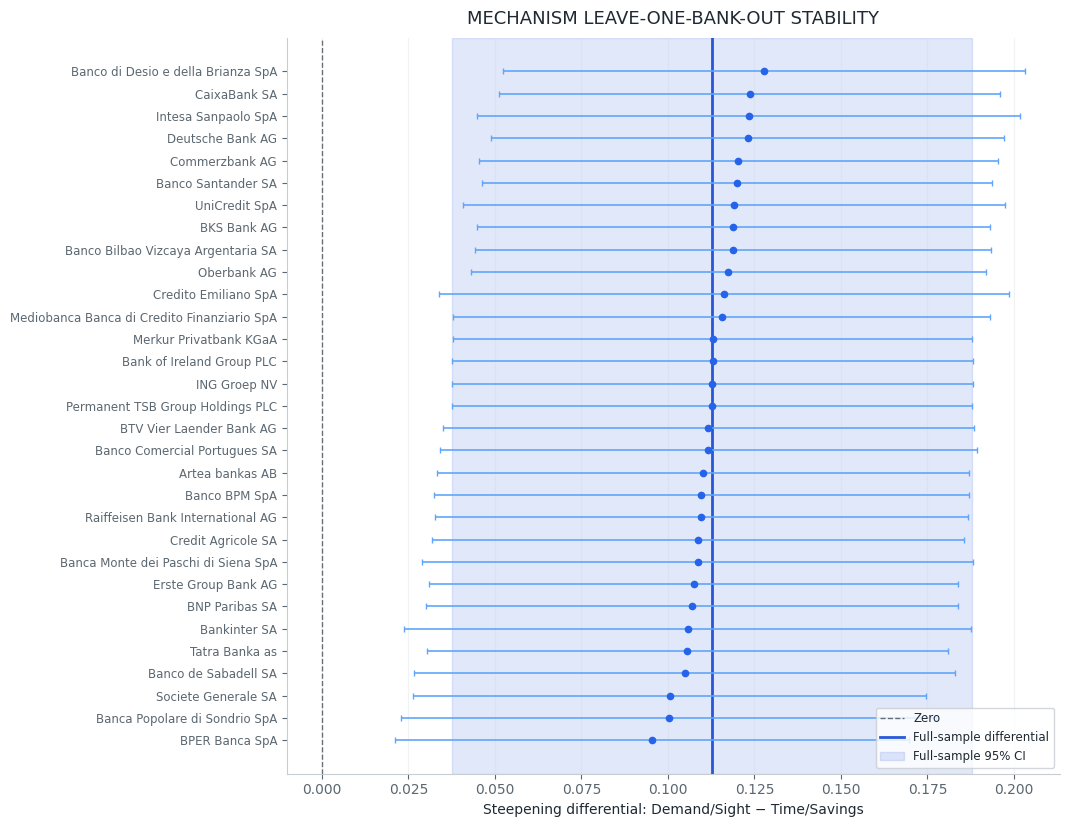

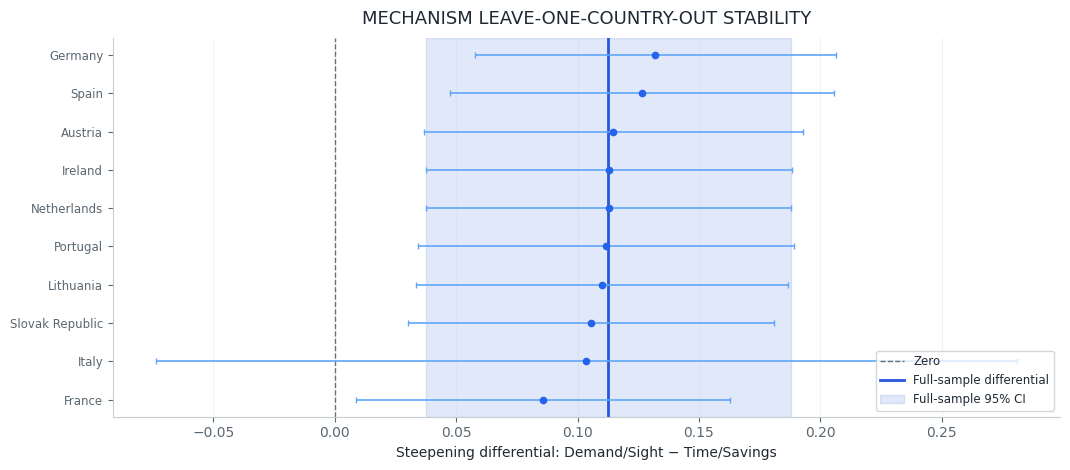

In [49]:
# ============================================================
# MECHANISM FIGURES — LEAVE-ONE-OUT STABILITY
# Demand/Sight − Time/Savings differential
#
# Separate from the clean mechanism robustness stack.
# Mirrors the baseline ASYM LOBO/LOCO figure structure, but plots
# the mechanism differential:
#   Steepening × High Demand/Sight − Steepening × High Time/Savings
#
# Uses a slightly different blue shade from the ASYM figure.
# ============================================================

RUN_MECHANISM_STABILITY_CHECKS = True

# False = preferred binary mechanism model.
# True  = macro + expanded mechanism model, if available.
USE_FULL_CONTROL_MODEL_FOR_MECH_LOO = False

# Different shade from WP_BLUE used in the ASYM figure.
WP_MECH_BLUE = "#2563EB"
WP_MECH_BLUE_LIGHT = "#60A5FA"
WP_MECH_BLUE_DARK = "#1D4ED8"

if RUN_MECHANISM_STABILITY_CHECKS:

    # ------------------------------------------------------------
    # 0. Guardrails / fallbacks
    # ------------------------------------------------------------

    if "df_mech_work" not in globals() or df_mech_work.empty:
        raise ValueError("df_mech_work is missing or empty. Run the clean mechanism stack first.")

    if "DEMAND_STEEP" not in globals() or "TIME_STEEP" not in globals():
        raise ValueError("DEMAND_STEEP and/or TIME_STEEP are missing.")

    if DEMAND_STEEP not in df_mech_work.columns or TIME_STEEP not in df_mech_work.columns:
        raise ValueError(f"Missing mechanism terms in df_mech_work: {DEMAND_STEEP}, {TIME_STEEP}")

    if "fit_panel" not in globals():
        raise ValueError("fit_panel is missing.")

    if "wald_equal_coefficients" not in globals():
        raise ValueError("wald_equal_coefficients is missing.")

    try:
        OUT_DIR
    except NameError:
        OUT_DIR = Path(".")
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    all_tables = globals().setdefault("all_tables", {})

    def _mech_warn(msg):
        if "warn_msg" in globals():
            warn_msg(msg)
        else:
            print(f"WARNING: {msg}")

    def _mech_find_first(data, candidates):
        if "find_first" in globals():
            return find_first(data, candidates)
        for c in candidates:
            if c in data.columns:
                return c
        return None

    def _mech_save_table(table, filename, display_table=False):
        if "save_table" in globals():
            return save_table(table, filename, display_table=display_table)

        path = OUT_DIR / filename
        table.to_csv(path, index=False)

        if display_table:
            print(table)

        print(f"Saved table: {path.resolve()}")
        return table

    def _mech_show(table):
        if "show_df" in globals():
            show_df(table)
        else:
            print(table)

    def _mech_wald_diff(res, label):
        """
        Returns the analytic Wald differential:
        beta(Steepening × High Demand/Sight) − beta(Steepening × High Time/Savings).
        """
        if res is None or not res.get("ok", False):
            return {
                "ok": False,
                "diff": np.nan,
                "se_diff": np.nan,
                "t_stat": np.nan,
                "p_value": np.nan,
                "error": res.get("error", "Model failed") if isinstance(res, dict) else "Model failed",
            }

        params = res.get("params", pd.Series(dtype=float))

        if DEMAND_STEEP not in params.index or TIME_STEEP not in params.index:
            return {
                "ok": False,
                "diff": np.nan,
                "se_diff": np.nan,
                "t_stat": np.nan,
                "p_value": np.nan,
                "error": "Demand/Sight or Time/Savings steepening coefficient absent",
            }

        return wald_equal_coefficients(
            res,
            DEMAND_STEEP,
            TIME_STEEP,
            label=label,
        )

    def mechanism_loo_plot(table, label_col, diff_col, se_col, title, filename):
        plot = table.dropna(subset=[diff_col, se_col]).copy()

        if plot.empty:
            _mech_warn(f"No valid rows to plot for {title}.")
            return None

        plot["ci_low"] = plot[diff_col] - 1.96 * plot[se_col]
        plot["ci_high"] = plot[diff_col] + 1.96 * plot[se_col]
        plot = plot.sort_values(diff_col)

        h = max(4.8, 0.27 * len(plot))
        fig, ax = plt.subplots(figsize=(10.8, h))

        fig.patch.set_facecolor(globals().get("WP_FIG_BG", "white"))
        ax.set_facecolor(globals().get("WP_AX_BG", "white"))

        y = np.arange(len(plot))

        ax.errorbar(
            plot[diff_col],
            y,
            xerr=1.96 * plot[se_col],
            fmt="o",
            markersize=4.5,
            linewidth=1.2,
            capsize=2.5,
            color=WP_MECH_BLUE,
            ecolor=WP_MECH_BLUE_LIGHT,
            zorder=3,
        )

        ax.axvline(
            0,
            color=globals().get("WP_TEXT", "black"),
            linestyle="--",
            linewidth=1,
            alpha=0.65,
            label="Zero",
        )

        if pd.notna(full_mech_diff):
            ax.axvline(
                full_mech_diff,
                color=WP_MECH_BLUE_DARK,
                linewidth=2,
                alpha=0.95,
                label="Full-sample differential",
            )

        if pd.notna(full_mech_ci_low) and pd.notna(full_mech_ci_high):
            ax.axvspan(
                full_mech_ci_low,
                full_mech_ci_high,
                color=WP_MECH_BLUE_DARK,
                alpha=0.13,
                label="Full-sample 95% CI",
            )

        ax.set_yticks(y)
        ax.set_yticklabels(plot[label_col], fontsize=8.5)
        ax.set_title(title, fontsize=13, pad=10)
        ax.set_xlabel("Steepening differential: Demand/Sight − Time/Savings")
        ax.grid(True, axis="x", color=globals().get("WP_GRID", "#D0D0D0"), alpha=0.35)

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

        ax.legend(
            loc="lower right",
            frameon=True,
            facecolor=globals().get("WP_AX_BG", "white"),
            edgecolor=globals().get("WP_BORDER", "#D0D0D0"),
            fontsize=8.5,
        )

        fig.tight_layout()

        path = OUT_DIR / filename
        fig.savefig(path, dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())

        print(f"Saved figure: {path.resolve()}")
        return fig

    # ------------------------------------------------------------
    # 1. Choose mechanism model
    # ------------------------------------------------------------

    if USE_FULL_CONTROL_MODEL_FOR_MECH_LOO:
        if "regs_mech_macro_expanded" in globals():
            mech_loo_regs = regs_mech_macro_expanded
            mech_loo_model_label = "macro + expanded controls"
        else:
            _mech_warn("regs_mech_macro_expanded missing; falling back to regs_mech_baseline.")
            mech_loo_regs = regs_mech_baseline
            mech_loo_model_label = "preferred baseline mechanism"
    else:
        mech_loo_regs = regs_mech_baseline
        mech_loo_model_label = "preferred baseline mechanism"

    # ------------------------------------------------------------
    # 2. Full-sample benchmark differential
    # ------------------------------------------------------------

    full_mech_res = fit_panel(
        df_mech_work,
        DEPENDENT_VAR,
        mech_loo_regs,
        model_name="Full-sample mechanism benchmark for LOO",
        verbose=False,
    )

    full_mech_wald = _mech_wald_diff(
        full_mech_res,
        "Full sample: Demand/Sight − Time/Savings during steepening",
    )

    full_mech_diff = full_mech_wald.get("diff", np.nan)
    full_mech_se = full_mech_wald.get("se_diff", np.nan)
    full_mech_ci_low = full_mech_diff - 1.96 * full_mech_se if pd.notna(full_mech_diff) and pd.notna(full_mech_se) else np.nan
    full_mech_ci_high = full_mech_diff + 1.96 * full_mech_se if pd.notna(full_mech_diff) and pd.notna(full_mech_se) else np.nan

    print("\nMECHANISM FULL-SAMPLE BENCHMARK")
    print(f"Model: {mech_loo_model_label}")
    print(f"Demand/Sight − Time/Savings differential: {full_mech_diff:.4f}")
    print(f"SE: {full_mech_se:.4f}")
    print(f"p-value: {full_mech_wald.get('p_value', np.nan):.4f}")

    # ------------------------------------------------------------
    # 3. Leave-one-bank-out
    # ------------------------------------------------------------

    bank_name_col = _mech_find_first(df_mech_work, ["bank_name", "name", "company_name"])

    bank_labels = (
        df_mech_work[[BANK_COL, bank_name_col]]
        .dropna()
        .drop_duplicates(BANK_COL)
        .set_index(BANK_COL)[bank_name_col]
        .to_dict()
        if bank_name_col is not None else {}
    )

    mech_lobo_rows = []

    for bank in sorted(df_mech_work[BANK_COL].dropna().unique()):
        d = df_mech_work.loc[df_mech_work[BANK_COL] != bank].copy()

        res = fit_panel(
            d,
            DEPENDENT_VAR,
            mech_loo_regs,
            model_name=f"Mechanism leave out bank {bank}",
            verbose=False,
        )

        diff = _mech_wald_diff(
            res,
            f"Leave out bank {bank}: Demand/Sight − Time/Savings during steepening",
        )

        params = res.get("params", pd.Series(dtype=float))
        pvals = res.get("pvalues", pd.Series(dtype=float))

        mech_lobo_rows.append({
            "left_out_bank": bank,
            "left_out_bank_label": bank_labels.get(bank, bank),
            "model": mech_loo_model_label,
            "coef_demand_steep": params.get(DEMAND_STEEP, np.nan),
            "coef_time_steep": params.get(TIME_STEEP, np.nan),
            "p_demand_steep": pvals.get(DEMAND_STEEP, np.nan),
            "p_time_steep": pvals.get(TIME_STEEP, np.nan),
            "diff_demand_minus_time": diff.get("diff", np.nan),
            "se_diff": diff.get("se_diff", np.nan),
            "t_stat": diff.get("t_stat", np.nan),
            "p_diff": diff.get("p_value", np.nan),
            "nobs": res.get("nobs", np.nan),
            "n_banks": res.get("n_banks", np.nan),
            "n_months": res.get("n_months", np.nan),
            "status": "OK" if res.get("ok", False) and diff.get("ok", False) else diff.get("error", res.get("error", "")),
        })

    mech_lobo_table = pd.DataFrame(mech_lobo_rows)

    for c in [
        "coef_demand_steep",
        "coef_time_steep",
        "p_demand_steep",
        "p_time_steep",
        "diff_demand_minus_time",
        "se_diff",
        "t_stat",
        "p_diff",
    ]:
        if c in mech_lobo_table.columns:
            mech_lobo_table[c] = pd.to_numeric(mech_lobo_table[c], errors="coerce").round(4)

    _mech_save_table(
        mech_lobo_table,
        "mechanism_leave_one_bank_out_stability.csv",
        display_table=False,
    )

    all_tables["mechanism_leave_one_bank_out_stability"] = mech_lobo_table

    print("\nMECHANISM LEAVE-ONE-BANK-OUT — STEEPENING DIFFERENTIAL")
    _mech_show(mech_lobo_table)

    mechanism_loo_plot(
        mech_lobo_table,
        "left_out_bank_label",
        "diff_demand_minus_time",
        "se_diff",
        "MECHANISM LEAVE-ONE-BANK-OUT STABILITY",
        "mechanism_figure_lobo_steepening_differential.png",
    )

    # ------------------------------------------------------------
    # 4. Leave-one-country-out
    # ------------------------------------------------------------

    if COUNTRY_COL is not None and COUNTRY_COL in df_mech_work.columns:

        mech_loco_rows = []

        for country in sorted(df_mech_work[COUNTRY_COL].dropna().unique()):
            d = df_mech_work.loc[df_mech_work[COUNTRY_COL] != country].copy()

            res = fit_panel(
                d,
                DEPENDENT_VAR,
                mech_loo_regs,
                model_name=f"Mechanism leave out country {country}",
                verbose=False,
            )

            diff = _mech_wald_diff(
                res,
                f"Leave out country {country}: Demand/Sight − Time/Savings during steepening",
            )

            params = res.get("params", pd.Series(dtype=float))
            pvals = res.get("pvalues", pd.Series(dtype=float))

            mech_loco_rows.append({
                "left_out_country": country,
                "model": mech_loo_model_label,
                "coef_demand_steep": params.get(DEMAND_STEEP, np.nan),
                "coef_time_steep": params.get(TIME_STEEP, np.nan),
                "p_demand_steep": pvals.get(DEMAND_STEEP, np.nan),
                "p_time_steep": pvals.get(TIME_STEEP, np.nan),
                "diff_demand_minus_time": diff.get("diff", np.nan),
                "se_diff": diff.get("se_diff", np.nan),
                "t_stat": diff.get("t_stat", np.nan),
                "p_diff": diff.get("p_value", np.nan),
                "nobs": res.get("nobs", np.nan),
                "n_banks": res.get("n_banks", np.nan),
                "n_months": res.get("n_months", np.nan),
                "status": "OK" if res.get("ok", False) and diff.get("ok", False) else diff.get("error", res.get("error", "")),
            })

        mech_loco_table = pd.DataFrame(mech_loco_rows)

        for c in [
            "coef_demand_steep",
            "coef_time_steep",
            "p_demand_steep",
            "p_time_steep",
            "diff_demand_minus_time",
            "se_diff",
            "t_stat",
            "p_diff",
        ]:
            if c in mech_loco_table.columns:
                mech_loco_table[c] = pd.to_numeric(mech_loco_table[c], errors="coerce").round(4)

        _mech_save_table(
            mech_loco_table,
            "mechanism_leave_one_country_out_stability.csv",
            display_table=False,
        )

        all_tables["mechanism_leave_one_country_out_stability"] = mech_loco_table

        print("\nMECHANISM LEAVE-ONE-COUNTRY-OUT — STEEPENING DIFFERENTIAL")
        _mech_show(mech_loco_table)

        mechanism_loo_plot(
            mech_loco_table,
            "left_out_country",
            "diff_demand_minus_time",
            "se_diff",
            "MECHANISM LEAVE-ONE-COUNTRY-OUT STABILITY",
            "mechanism_figure_loco_steepening_differential.png",
        )

    else:
        _mech_warn("Mechanism LOCO skipped because COUNTRY_COL is missing.")

else:
    print("Mechanism LOBO/LOCO figures skipped. Set RUN_MECHANISM_STABILITY_CHECKS=True.")

## Asymetry Mechanism wald

In [51]:
# ============================================================
# COMPOSITION-BASED ASYM TEST — ALL MECHANISM SPECIFICATIONS
# H0: (Steepening×Demand − Steepening×Savings)
#     − (Flattening×Demand − Flattening×Savings) = 0
#
# Interpretation:
# Tests whether the Demand–Savings pricing differential is itself
# asymmetric between steepening and flattening episodes.
# ============================================================

RUN_COMPOSITION_ASYM_ALL_MODELS = True

if RUN_COMPOSITION_ASYM_ALL_MODELS:

    import numpy as np
    import pandas as pd
    from pathlib import Path

    required_globals = [
        "res_mech_controls_clean",
        "specs_mech_controls_clean",
        "DEMAND_STEEP",
        "TIME_STEEP",
        "DEMAND_FLAT",
        "TIME_FLAT",
    ]

    missing_globals = [g for g in required_globals if g not in globals()]
    if missing_globals:
        raise ValueError(
            f"Missing required objects: {missing_globals}. "
            "Run the clean mechanism robustness stack first."
        )

    # Contrast:
    # (D_steep - S_steep) - (D_flat - S_flat)
    composition_asym_contrast = {
        DEMAND_STEEP: 1.0,
        TIME_STEEP: -1.0,
        DEMAND_FLAT: -1.0,
        TIME_FLAT: 1.0,
    }

    contrast_label = (
        "(Steepening Demand − Steepening Savings) − "
        "(Flattening Demand − Flattening Savings)"
    )

    # ------------------------------------------------------------
    # Test all main mechanism specifications
    # ------------------------------------------------------------

    preferred_model_order = [
        "Deposit-Composition Mechanism",
        "Baseline mechanism",
        "baseline mechanism",
        "Mechanism baseline",
        "mechanism baseline",
        "+ expanded controls",
        "Expanded controls",
        "expanded controls",
        "+ macro composition controls",
        "Macro composition controls",
        "macro composition controls",
        "+ macro controls",
        "Macro controls",
        "macro controls",
        "+ macro + expanded controls",
        "+ expanded + macro controls",
        "Expanded + macro controls",
        "expanded + macro controls",
    ]

    available_models = list(res_mech_controls_clean.keys())

    # Keep only models that actually exist, preserving preferred order.
    models_to_test = []
    for m in preferred_model_order:
        if m in available_models and m not in models_to_test:
            models_to_test.append(m)

    # Fallback: include all mechanism models if naming differs.
    if not models_to_test:
        models_to_test = available_models

    print("Available mechanism models:")
    for m in available_models:
        print(" -", m)

    print("\nModels selected for composition-based ASYM test:")
    for m in models_to_test:
        print(" -", m)

    # ------------------------------------------------------------
    # Helper functions
    # ------------------------------------------------------------

    def _stars_local(p):
        if pd.isna(p):
            return ""
        if p < 0.01:
            return "***"
        if p < 0.05:
            return "**"
        if p < 0.10:
            return "*"
        return ""

    def _normal_p_local(t):
        if "normal_pvalue" in globals():
            return normal_pvalue(t)
        from scipy.stats import norm
        return 2 * (1 - norm.cdf(abs(t)))

    def analytic_linear_contrast(res, contrast, label):
        out = {
            "test": label,
            "ok": False,
            "estimate": np.nan,
            "se": np.nan,
            "t_stat": np.nan,
            "analytic_p": np.nan,
            "stars_analytic": "",
            "error": "",
        }

        if res is None or not res.get("ok", False):
            out["error"] = "Model not estimated."
            return out

        params = res.get("params", pd.Series(dtype=float))
        cov = res.get("cov", pd.DataFrame())

        needed = list(contrast.keys())
        missing = [v for v in needed if v not in params.index]
        if missing:
            out["error"] = f"Missing variables in estimated params: {missing}"
            return out

        if cov is None or cov.empty:
            out["error"] = "Covariance matrix unavailable."
            return out

        try:
            c = pd.Series(0.0, index=params.index)
            for var, weight in contrast.items():
                c.loc[var] = weight

            estimate = float(c @ params)
            var_est = float(
                c.values
                @ cov.loc[params.index, params.index].values
                @ c.values
            )
            se = np.sqrt(max(var_est, 0.0))

            if se <= 0 or not np.isfinite(se):
                out["error"] = "Non-positive or invalid standard error."
                return out

            t_stat = estimate / se
            pval = _normal_p_local(t_stat)

            out.update({
                "ok": True,
                "estimate": estimate,
                "se": se,
                "t_stat": t_stat,
                "analytic_p": pval,
                "stars_analytic": _stars_local(pval),
            })
            return out

        except Exception as exc:
            out["error"] = str(exc)
            return out

    def fast_wcb_linear_contrast(
        data,
        dep_var,
        full_regs,
        contrast,
        label,
        B=None,
        seed=None,
        entity_effects=True,
        time_effects=True,
    ):
        B = globals().get("WCB_REPS", 999) if B is None else B
        seed = globals().get("WCB_SEED", 42) + 77_777 if seed is None else seed

        out = {
            "test": label,
            "ok": False,
            "estimate": np.nan,
            "se": np.nan,
            "t_stat": np.nan,
            "analytic_p": np.nan,
            "wcb_p": np.nan,
            "stars_analytic": "",
            "stars_wcb": "",
            "boot_draws": B,
            "successful_draws": 0,
            "nobs": np.nan,
            "n_banks": np.nan,
            "n_months": np.nan,
            "error": "",
        }

        try:
            full_regs = list(dict.fromkeys([r for r in full_regs if r is not None]))

            if "_prepare_work" in globals():
                work, full_regs = _prepare_work(data, dep_var, full_regs)
            else:
                needed = [dep_var, *full_regs, BANK_COL, MONTH_COL]
                work = data.dropna(subset=[c for c in needed if c in data.columns]).copy()

            if work.empty:
                out["error"] = "No complete-case observations."
                return out

            missing = [v for v in contrast if v not in full_regs]
            if missing:
                out["error"] = f"Contrast variables missing from full_regs: {missing}"
                return out

            bank_cat = pd.Categorical(work[BANK_COL].astype(str))
            month_cat = pd.Categorical(pd.to_datetime(work[MONTH_COL]).dt.strftime("%Y-%m"))
            bank_codes = bank_cat.codes
            month_codes = month_cat.codes

            y = work[dep_var].to_numpy(float)
            X_raw = work[full_regs].to_numpy(float)

            y_w = within_transform(
                y,
                bank_codes,
                month_codes,
                entity_effects=entity_effects,
                time_effects=time_effects,
            ).ravel()

            X_w = within_transform(
                X_raw,
                bank_codes,
                month_codes,
                entity_effects=entity_effects,
                time_effects=time_effects,
            )

            keep = np.sqrt((X_w ** 2).sum(axis=0)) > 1e-12
            regs_kept = [r for r, k in zip(full_regs, keep) if k]
            X = X_w[:, keep]

            c = np.array([contrast.get(r, 0.0) for r in regs_kept], dtype=float)

            if not np.any(np.abs(c) > 0):
                out["error"] = "All contrast variables were absorbed or absent."
                return out

            XtX_inv = np.linalg.pinv(X.T @ X)
            beta = XtX_inv @ X.T @ y_w
            resid = y_w - X @ beta

            cov = clustered_covariance(
                X,
                resid,
                bank_codes,
                month_codes,
                cluster_entity=True,
                cluster_time=False,
            )

            estimate = float(c @ beta)
            var_est = float(c @ cov @ c)
            se = np.sqrt(max(var_est, 0.0))

            if se <= 0 or not np.isfinite(se):
                out["error"] = "Invalid unrestricted contrast standard error."
                return out

            obs_t = estimate / se
            analytic_p = _normal_p_local(obs_t)

            # Restricted design under c'beta = 0.
            pivot = int(np.argmax(np.abs(c)))
            c_p = c[pivot]

            if c_p == 0:
                out["error"] = "Invalid pivot in contrast vector."
                return out

            others = [j for j in range(X.shape[1]) if j != pivot]
            c_others = c[others]

            X_restricted = X[:, others] - np.outer(X[:, pivot], c_others / c_p)

            beta_r = (
                np.linalg.pinv(X_restricted.T @ X_restricted)
                @ X_restricted.T
                @ y_w
            )
            fitted_r = X_restricted @ beta_r
            resid_r = y_w - fitted_r

            rng = np.random.default_rng(seed)
            boot_t = []

            for _ in range(B):
                weights = rng.choice([-1.0, 1.0], size=len(bank_cat.categories))[bank_codes]
                y_star = fitted_r + resid_r * weights

                beta_b = XtX_inv @ X.T @ y_star
                resid_b = y_star - X @ beta_b

                cov_b = clustered_covariance(
                    X,
                    resid_b,
                    bank_codes,
                    month_codes,
                    cluster_entity=True,
                    cluster_time=False,
                )

                est_b = float(c @ beta_b)
                var_b = float(c @ cov_b @ c)
                se_b = np.sqrt(max(var_b, 0.0))

                if se_b > 0 and np.isfinite(se_b):
                    boot_t.append(est_b / se_b)

            boot_t = np.asarray(boot_t, dtype=float)
            wcb_p = float(np.mean(np.abs(boot_t) >= abs(obs_t))) if len(boot_t) else np.nan

            out.update({
                "ok": True,
                "estimate": estimate,
                "se": se,
                "t_stat": obs_t,
                "analytic_p": analytic_p,
                "wcb_p": wcb_p,
                "stars_analytic": _stars_local(analytic_p),
                "stars_wcb": _stars_local(wcb_p),
                "successful_draws": len(boot_t),
                "nobs": len(work),
                "n_banks": work[BANK_COL].nunique(),
                "n_months": work[MONTH_COL].nunique(),
            })

            return out

        except Exception as exc:
            out["error"] = str(exc)
            return out

    # ------------------------------------------------------------
    # Run tests
    # ------------------------------------------------------------

    rows = []

    for idx, model_name in enumerate(models_to_test):

        if model_name not in res_mech_controls_clean:
            print(f"Skipping missing result model: {model_name}")
            continue

        if model_name not in specs_mech_controls_clean:
            print(f"Skipping missing spec model: {model_name}")
            continue

        res = res_mech_controls_clean[model_name]
        spec = specs_mech_controls_clean[model_name]

        analytic = analytic_linear_contrast(
            res,
            composition_asym_contrast,
            contrast_label,
        )

        wcb = fast_wcb_linear_contrast(
            spec.data,
            spec.dep,
            spec.regs,
            composition_asym_contrast,
            contrast_label,
            B=globals().get("WCB_REPS", 999),
            seed=globals().get("WCB_SEED", 42) + 88_000 + idx,
            entity_effects=spec.entity_effects,
            time_effects=spec.time_effects,
        )

        rows.append({
            "Model": model_name,
            "Contrast": contrast_label,
            "Estimate": wcb.get("estimate", analytic.get("estimate", np.nan)),
            "SE": wcb.get("se", analytic.get("se", np.nan)),
            "t-stat": wcb.get("t_stat", analytic.get("t_stat", np.nan)),
            "Analytic p": wcb.get("analytic_p", analytic.get("analytic_p", np.nan)),
            "WCB p": wcb.get("wcb_p", np.nan),
            "Analytic stars": _stars_local(
                wcb.get("analytic_p", analytic.get("analytic_p", np.nan))
            ),
            "WCB stars": _stars_local(wcb.get("wcb_p", np.nan)),
            "Bootstrap draws": (
                f"{wcb.get('successful_draws', 0)}/"
                f"{wcb.get('boot_draws', globals().get('WCB_REPS', 999))}"
            ),
            "Observations": wcb.get("nobs", res.get("nobs", np.nan)),
            "Banks": wcb.get("n_banks", res.get("n_banks", np.nan)),
            "Months": wcb.get("n_months", res.get("n_months", np.nan)),
            "OK": wcb.get("ok", False),
            "Error": wcb.get("error", analytic.get("error", "")),
        })

    composition_asym_all_models_table = pd.DataFrame(rows)

    for col in ["Estimate", "SE", "t-stat", "Analytic p", "WCB p"]:
        if col in composition_asym_all_models_table.columns:
            composition_asym_all_models_table[col] = pd.to_numeric(
                composition_asym_all_models_table[col],
                errors="coerce",
            ).round(4)

    print("\nCOMPOSITION-BASED ASYM TEST — ALL MECHANISM MODELS")
    print(composition_asym_all_models_table.to_string(index=False))

    # ------------------------------------------------------------
    # Save outputs
    # ------------------------------------------------------------

    out_dir = globals().get("OUT_DIR", Path("."))
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    out_file = out_dir / "composition_asymmetry_all_mechanism_models.csv"
    composition_asym_all_models_table.to_csv(out_file, index=False)

    all_tables = globals().setdefault("all_tables", {})
    all_wald = globals().setdefault("all_wald", {})

    all_tables["composition_asymmetry_all_mechanism_models"] = composition_asym_all_models_table
    all_wald["composition_asymmetry_all_mechanism_models"] = rows

    print(f"\nSaved: {out_file.resolve()}")

Available mechanism models:
 - Mechanism baseline
 - + expanded controls
 - + macro composition controls
 - + macro + expanded controls

Models selected for composition-based ASYM test:
 - Mechanism baseline
 - + expanded controls
 - + macro composition controls
 - + macro + expanded controls

COMPOSITION-BASED ASYM TEST — ALL MECHANISM MODELS
                       Model                                                                            Contrast  Estimate     SE  t-stat  Analytic p  WCB p Analytic stars WCB stars Bootstrap draws  Observations  Banks  Months   OK Error
          Mechanism baseline (Steepening Demand − Steepening Savings) − (Flattening Demand − Flattening Savings)    0.1161 0.0572  2.0303      0.0423 0.0651             **         *         999/999          3386     31     165 True      
         + expanded controls (Steepening Demand − Steepening Savings) − (Flattening Demand − Flattening Savings)    0.1025 0.0574  1.7870      0.0739 0.0851              *       